In [1]:
import numpy as np
from sklearn.decomposition import PCA

In [7]:
filename = 'COMPILE_R_quant.csv'
dense_coding_table = []
for line in open(filename):
    dense_coding_table.append(line.strip('\n').split(','))
for x in dense_coding_table:
    print(x)

['relation', 'eng_in', 'eng_on', 'eng_at', 'cyn_yn', 'cym_ar', 'cym_mewn', 'cym_zero', 'cym_wrth', 'cym_other', 'deu_in', 'deu_auf', 'deu_zu', 'deu_an', 'deu_nach', 'deu_zero', 'deu_other', 'pol_w', 'pol_na', 'pol_z', 'pol_u', 'pol_przy', 'pol_podczas', 'pol_zaś', 'pol_zero', 'pol_other', 'fra_en', 'fra_à', 'fra_dans', 'fra_lors_de', 'fra_de', 'fra_sur', 'fra_zero', 'fra_other', 'spa_en', 'spa_a', 'spa_sobre', 'spa_de', 'spa_por', 'spa_zero', 'spa_other', 'srp_u', 'srp_na', 'srp_za', 'srp_zero', 'hun_-ban', 'hun_-n', 'hun_-kor', 'hun_szal', 'hun_mulva', 'hun_alatt', 'hun_other', 'hun_zero', 'swe_i', 'swe_på', 'swe_vid', 'swe_om', 'swe_under', 'swe_other', 'swe_zero']
['c-lff', '14', '0', '0', '11', '0', '1', '0', '0', '0', '9', '4', '0', '0', '0', '0', '0', '7', '5', '0', '0', '0', '0', '0', '0', '0', '1', '4', '6', '0', '0', '1', '0', '0', '12', '1', '0', '0', '0', '0', '0', '9', '3', '0', '0', '7', '3', '0', '0', '0', '0', '0', '0', '7', '4', '0', '0', '0', '0', '0']
['c-lfp', '1', '

In [3]:
def get_sparse_coding(dense_coding_table, no_response):
    languages = dense_coding_table[0][1:]
    sparse_dict = { language : {} for language in languages }
    sparse_coding_table = []
    for i,language in enumerate(languages, start=1):
        for row in dense_coding_table[1:]:
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                elif morpheme not in sparse_dict[language]: 
                    sparse_dict[language][morpheme] = len(sparse_dict[language])
    header = [language + '_' + morpheme for language in languages 
              for morpheme in sorted(sparse_dict[language], key = lambda k : sparse_dict[language][k])]
    for row in dense_coding_table[1:]:
        sparse_row = []
        for i,language in enumerate(languages, start=1):
            sparse_row_i = [0 for j in range(len(sparse_dict[language]))]
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                else:
                    index = sparse_dict[language][morpheme]
                    sparse_row_i[index] = 1
            sparse_row.extend(sparse_row_i)
        sparse_coding_table.append(sparse_row)
    return header, sparse_coding_table, sparse_dict
            

header, sparse_coding_table, sparse_dict = get_sparse_coding(dense_coding_table, no_response = '--')
print('>>> sparse dict', sparse_dict)
print('>>> header', header)
for i in sparse_coding_table[:10]:
    print(i)

>>> sparse dict {'eng_in': {'14': 0, '1': 1, '9': 2, '0': 3, '2': 4, '13': 5, '4': 6, '29': 7, '10': 8}, 'eng_on': {'0': 0, '7': 1, '2': 2, '28': 3, '1': 4}, 'eng_at': {'0': 0, '5': 1, '11': 2, '2': 3, '1': 4, '29': 5}, 'cyn_yn': {'11': 0, '1': 1, '0': 2, '8': 3, '3': 4, '6': 5, '2': 6, '17': 7, '21': 8}, 'cym_ar': {'0': 0, '7': 1, '2': 2, '1': 3, '3': 4, '17': 5}, 'cym_mewn': {'1': 0, '0': 1, '2': 2, '8': 3}, 'cym_zero': {'0': 0, '2': 1, '5': 2, '6': 3, '4': 4}, 'cym_wrth': {'0': 0, '3': 1}, 'cym_other': {'0': 0, '4': 1, '6': 2, '2': 3, '1': 4}, 'deu_in': {'9': 0, '1': 1, '0': 2, '8': 3, '2': 4, '22': 5, '4': 6}, 'deu_auf': {'4': 0, '0': 1, '1': 2, '7': 3}, 'deu_zu': {'0': 0, '2': 1, '11': 2, '3': 3}, 'deu_an': {'0': 0, '1': 1, '5': 2, '9': 3, '24': 4, '2': 5}, 'deu_nach': {'0': 0, '1': 1, '2': 2}, 'deu_zero': {'0': 0, '3': 1, '2': 2}, 'deu_other': {'0': 0, '1': 1, '2': 2}, 'pol_w': {'7': 0, '1': 1, '0': 2, '3': 3, '2': 4, '20': 5, '14': 6, '19': 7, '6': 8}, 'pol_na': {'5': 0, '0': 1,

In [4]:
P = PCA()
coordinates = P.fit_transform(sparse_coding_table)
print(P.explained_variance_ratio_)

[1.41928593e-01 1.09844484e-01 1.03570273e-01 9.39588906e-02
 8.43788951e-02 7.25429640e-02 7.03900230e-02 6.40700601e-02
 5.68448643e-02 5.05719794e-02 4.07353749e-02 3.63381803e-02
 3.18146116e-02 2.82552712e-02 1.47555352e-02 1.21188089e-32]


-1.5496916471617754 0.3273287972957504 c-lff
-1.140008114324221 -0.7170746650881299 c-lfp
-1.7483444415621976 -0.48904791182931673 c-tfp
-0.7622502987951757 0.12077937373488061 c-loc
-1.909134740464425 0.6371209968006091 s-grav
-1.2689565208319342 0.6260189017561877 s-hang
-1.2169223552652255 2.0442081872692115 a-cl
0.8697698022541319 -0.22193270291086095 sim-hour
2.447252986479734 -1.3265505826326855 sim-part
0.5741293062624268 0.37776027471855966 sim-day
-1.0297920687614208 -0.1563881660686308 sim-seas
-1.1713484074624116 0.8949973440940219 sim-fest
2.8660249391426933 3.9018947173231586 sim-point
4.750019559578679 -0.3786696686024784 sim-cont
-0.6797026094297342 -2.1934002653393265 dist-fut
0.9689546103408523 -3.4470446305209554 ext-tel


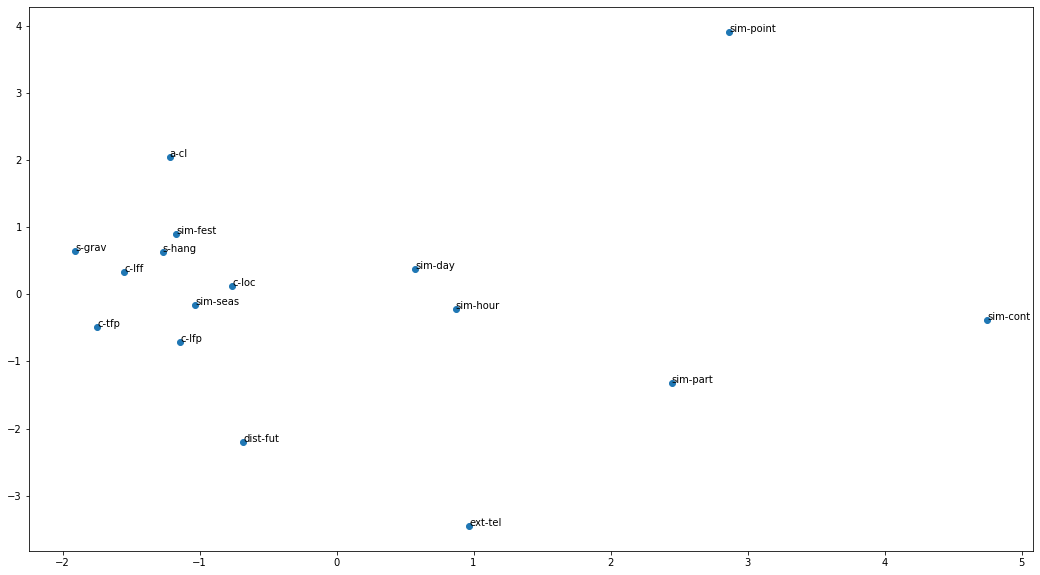

0 eng_in_14


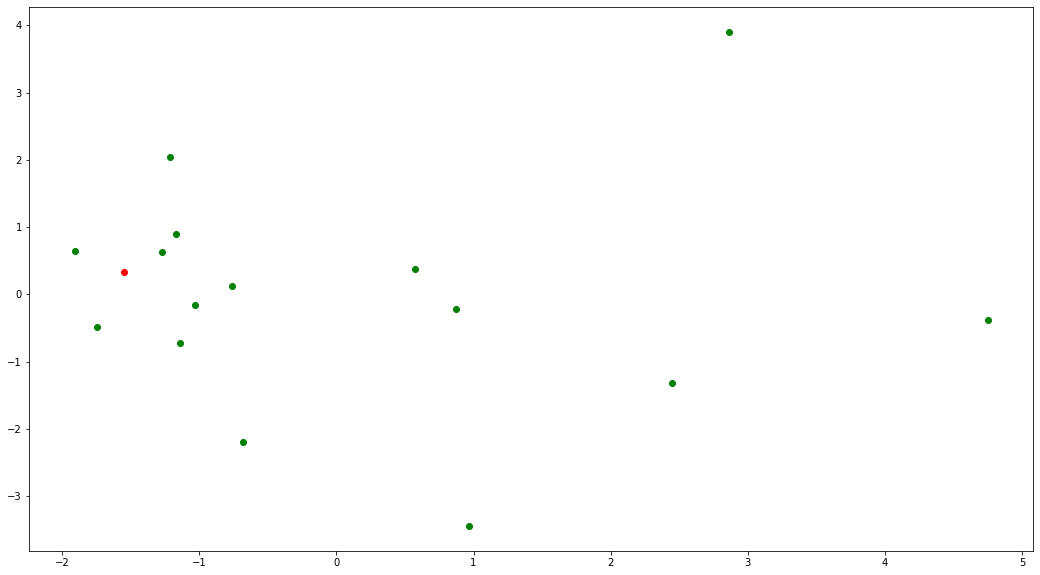

1 eng_in_1


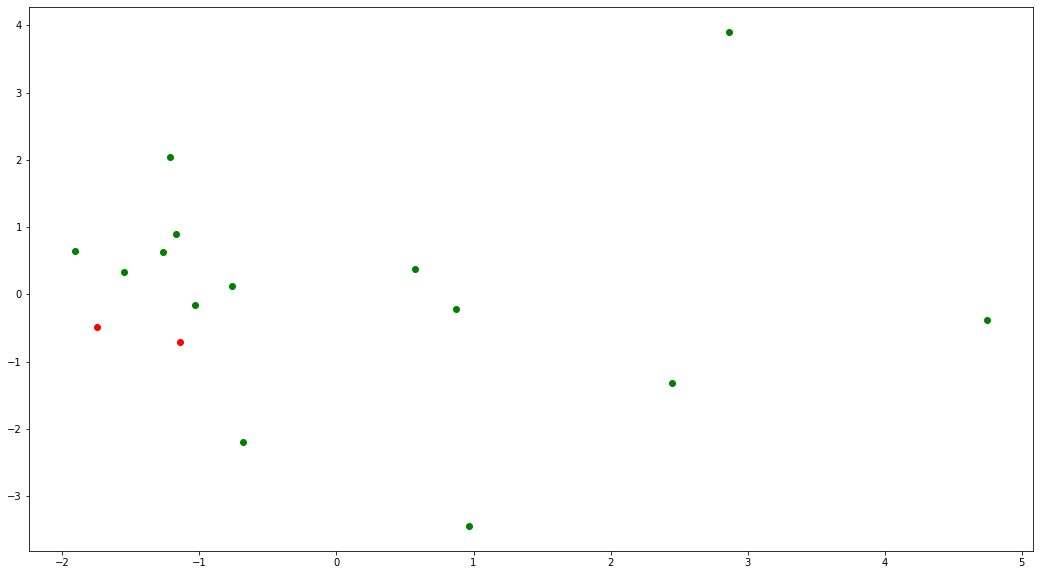

2 eng_in_9


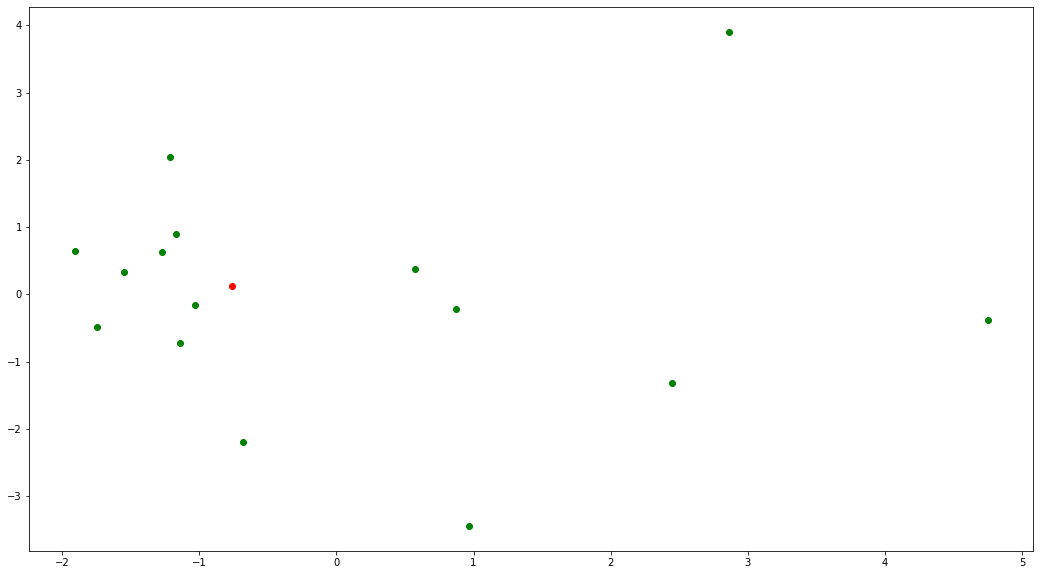

3 eng_in_0


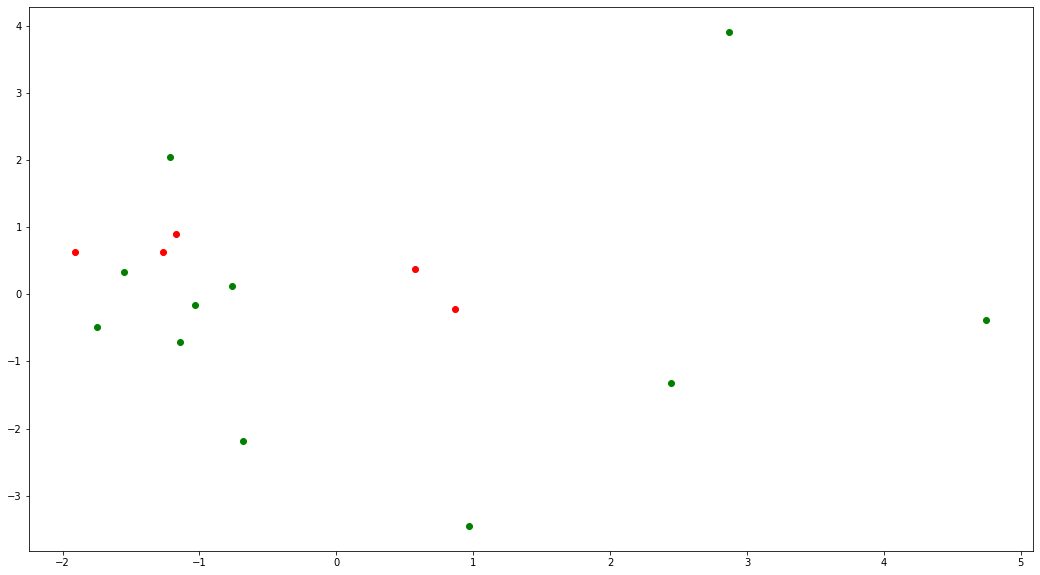

4 eng_in_2


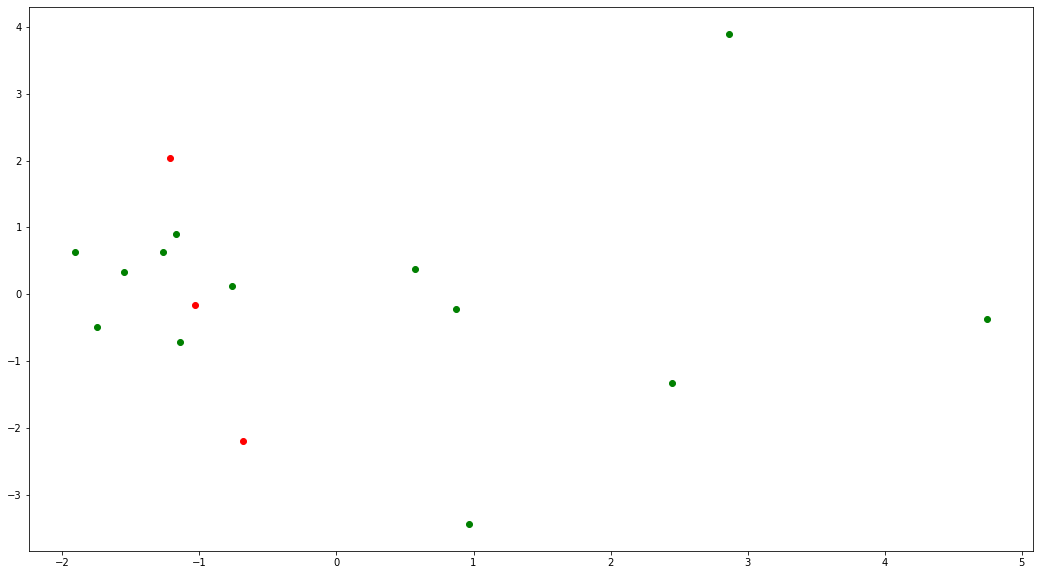

5 eng_in_13


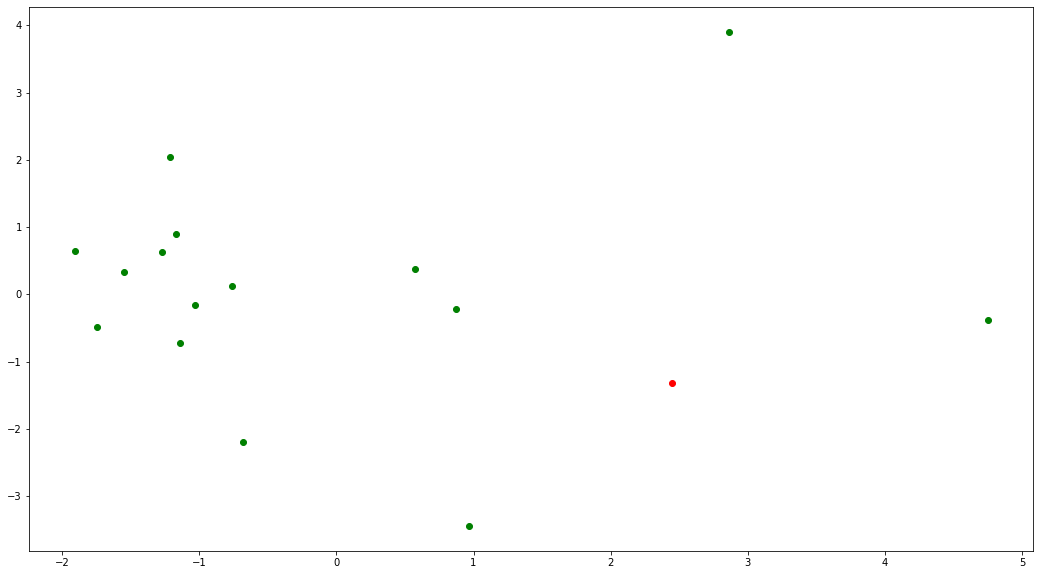

6 eng_in_4


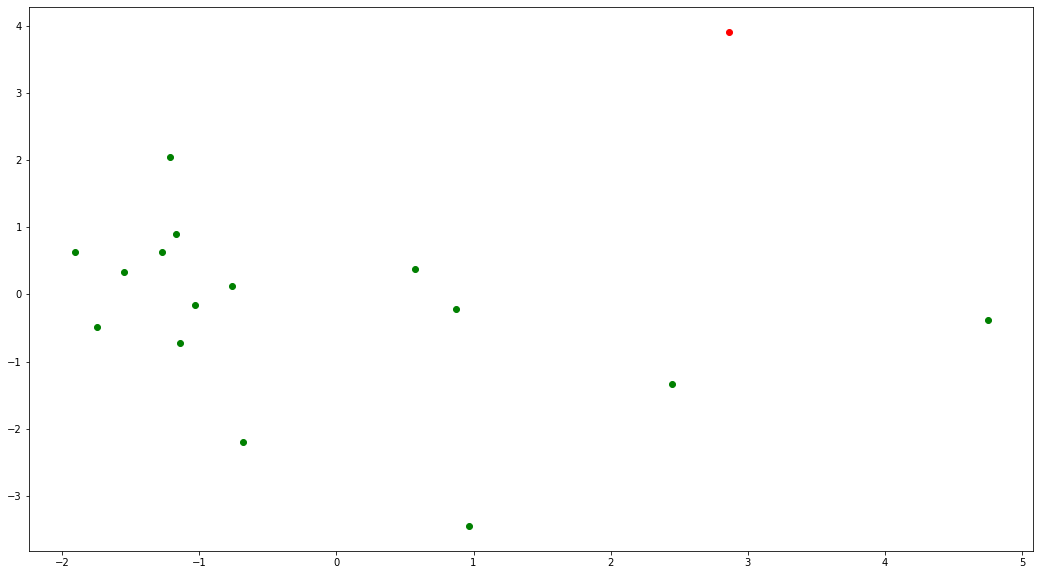

7 eng_in_29


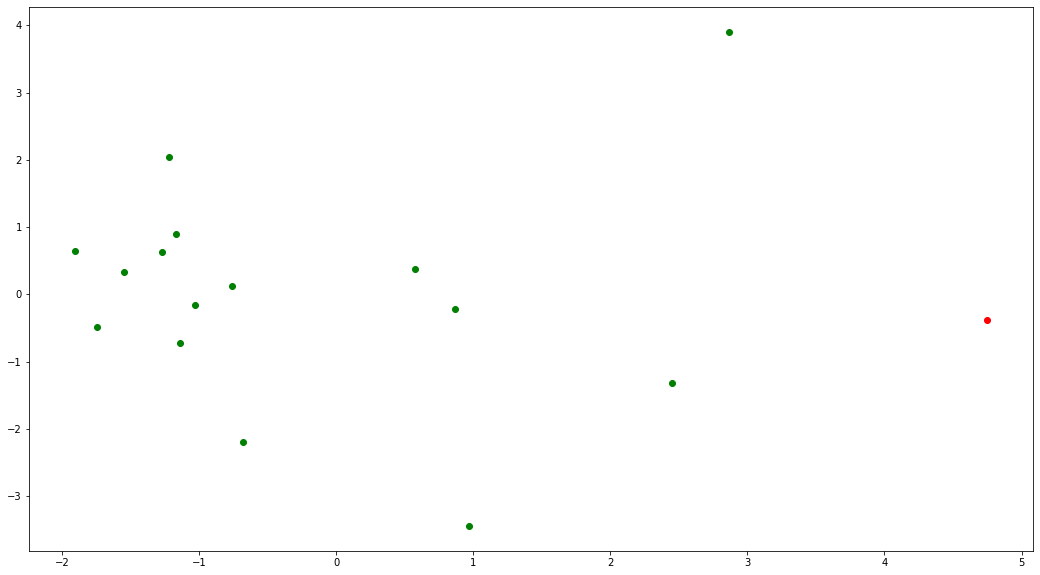

8 eng_in_10


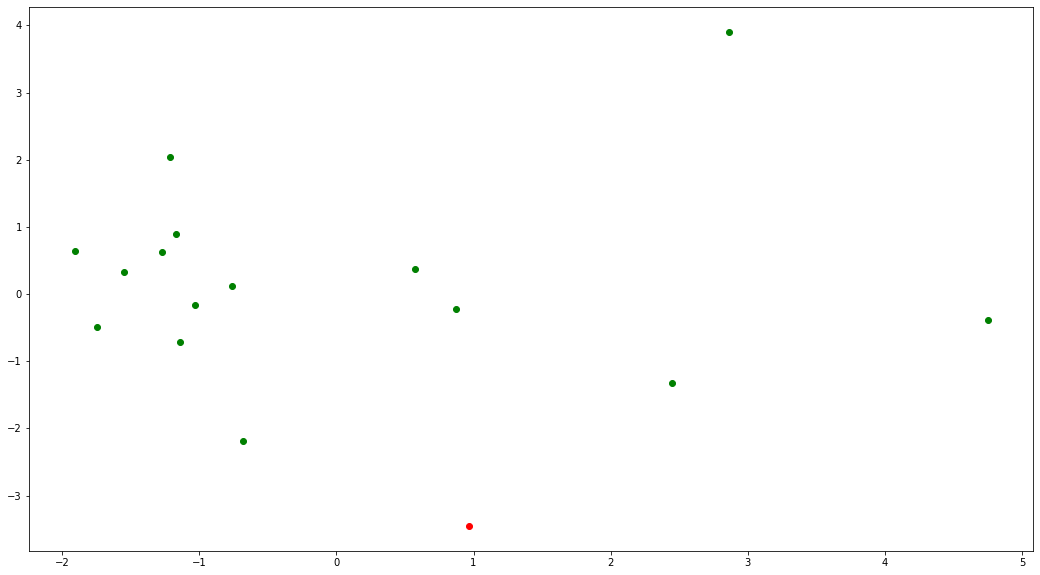

9 eng_on_0


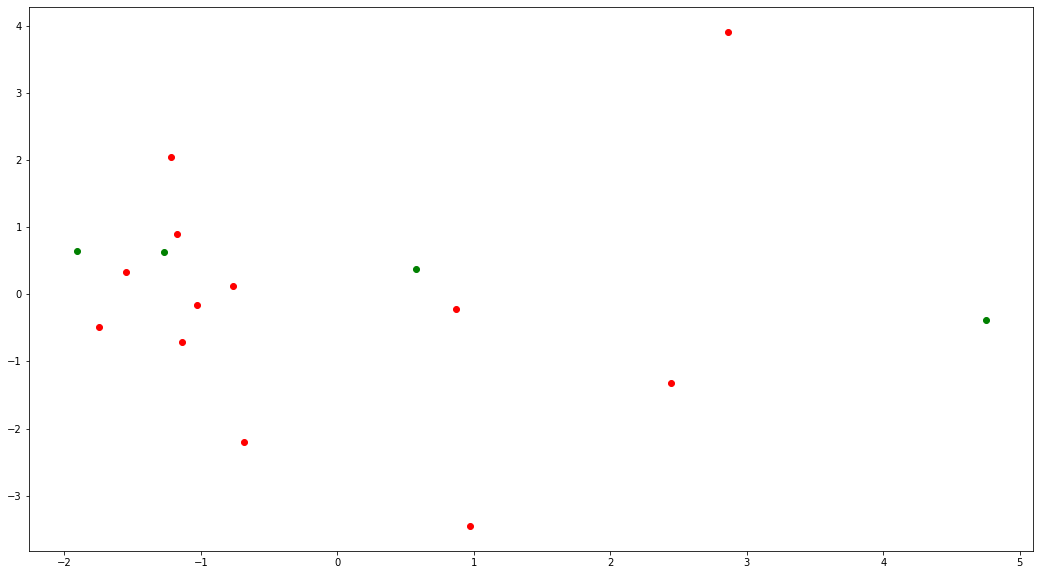

10 eng_on_7


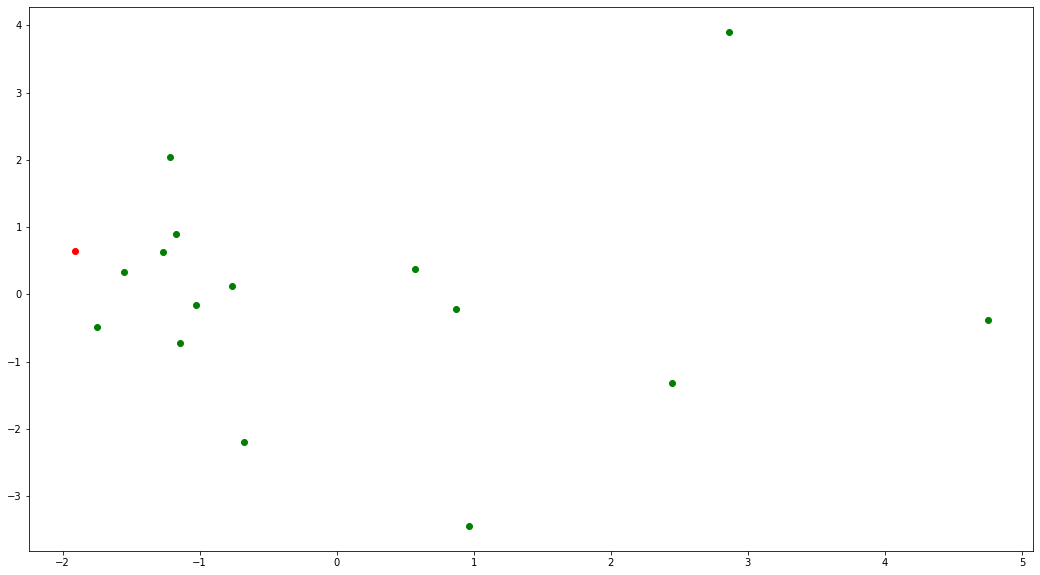

11 eng_on_2


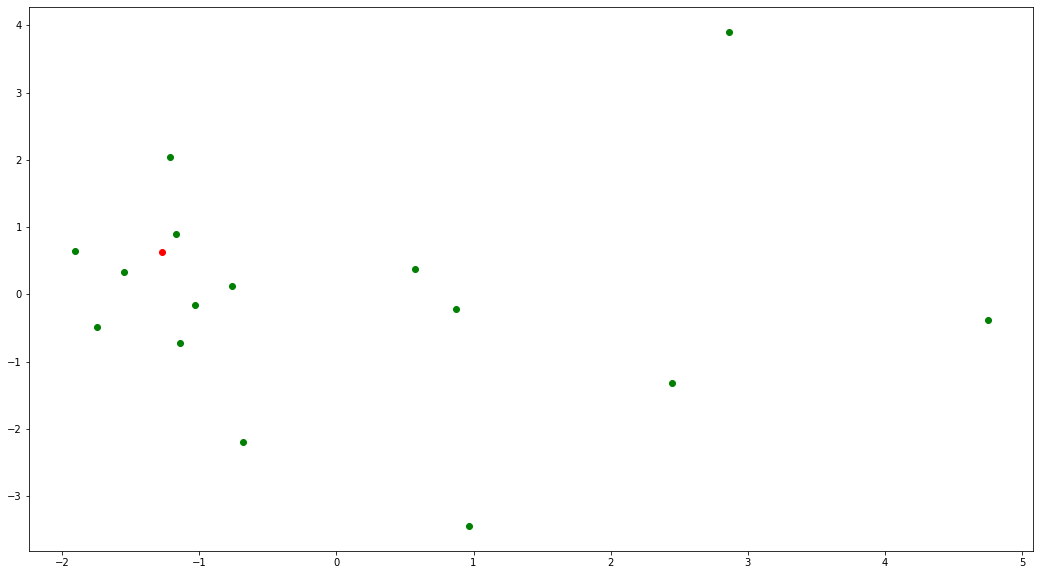

12 eng_on_28


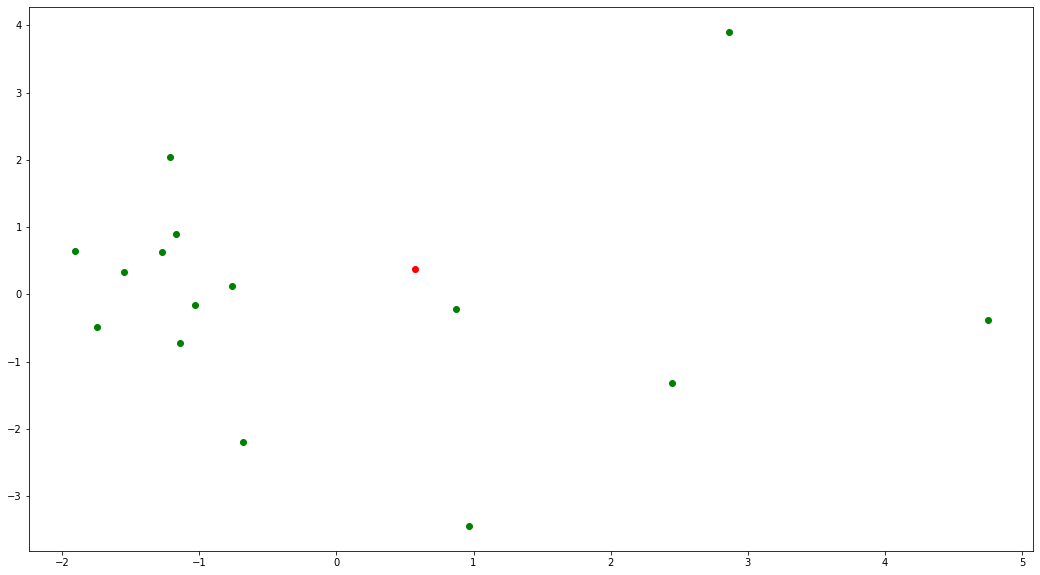

13 eng_on_1


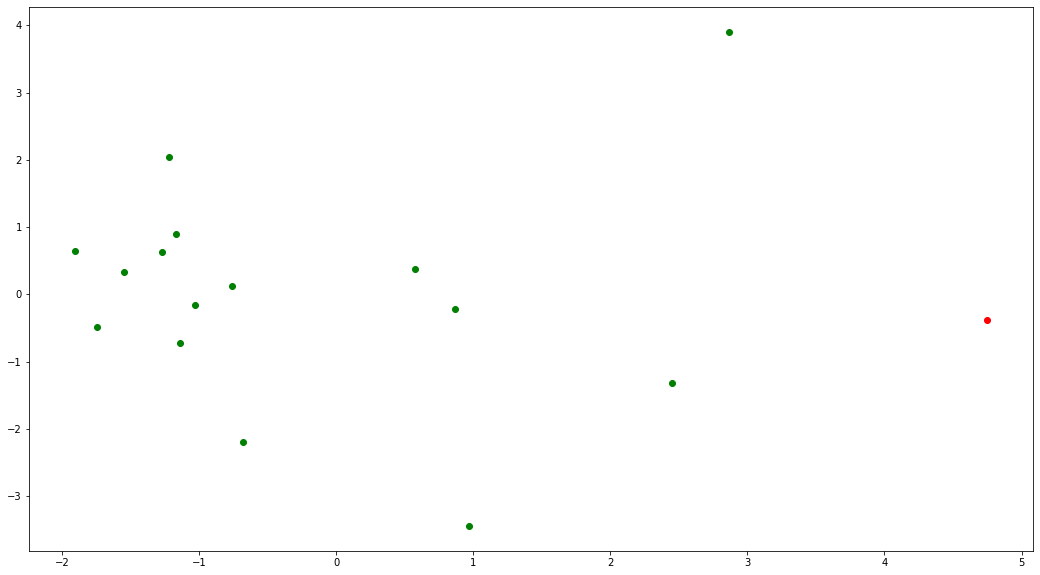

14 eng_at_0


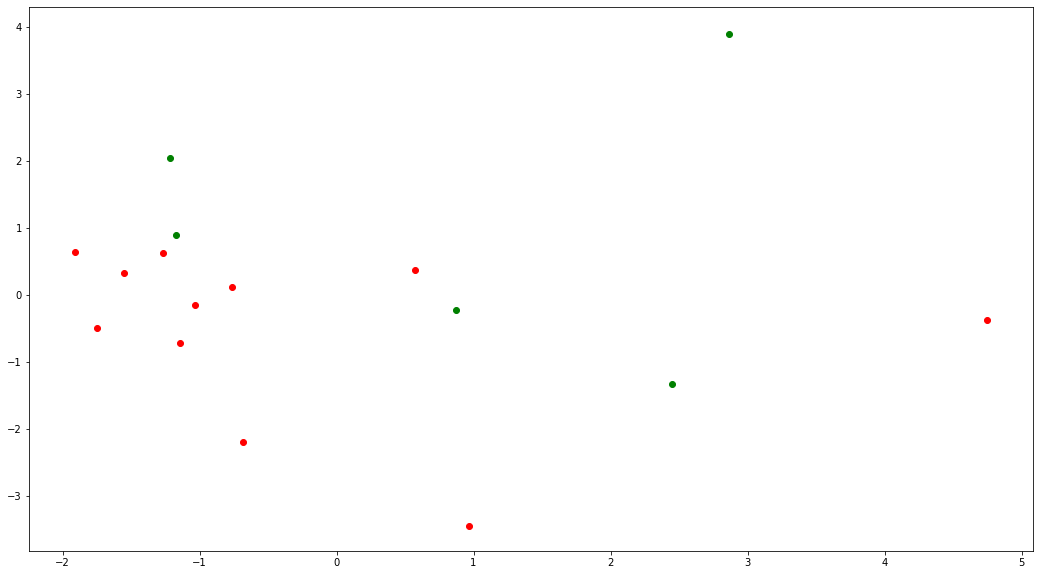

15 eng_at_5


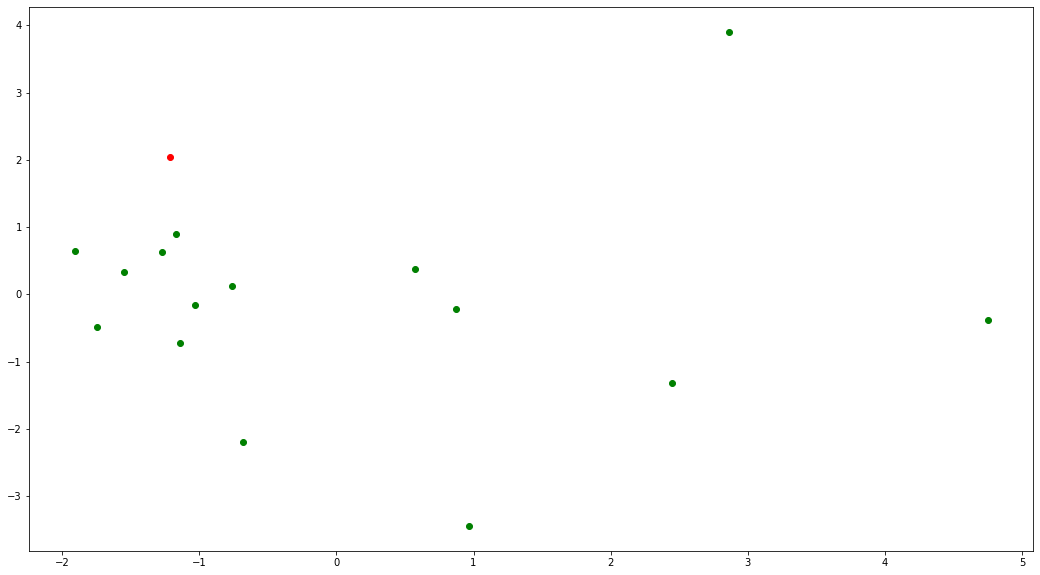

16 eng_at_11


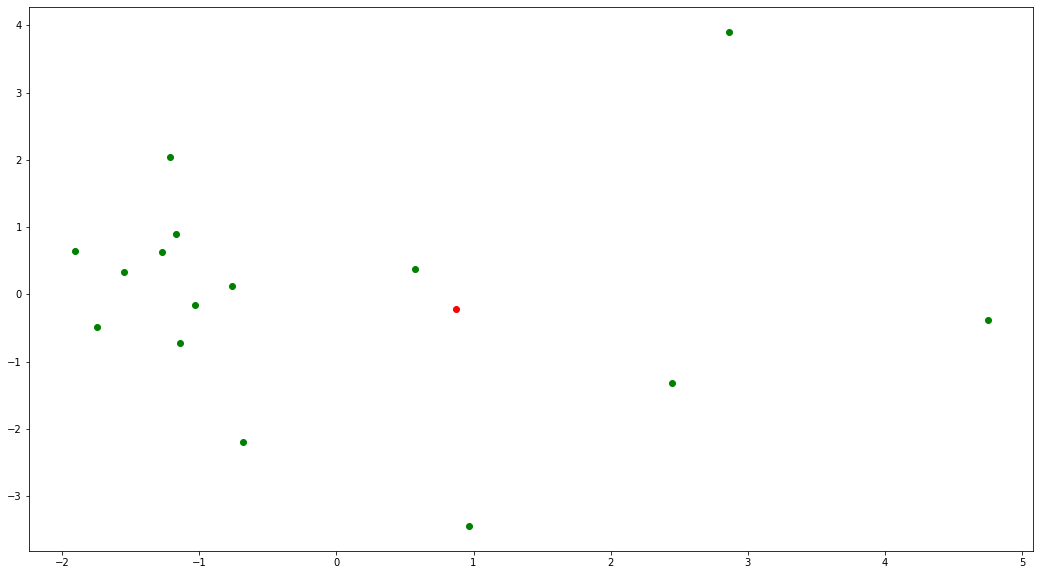

17 eng_at_2


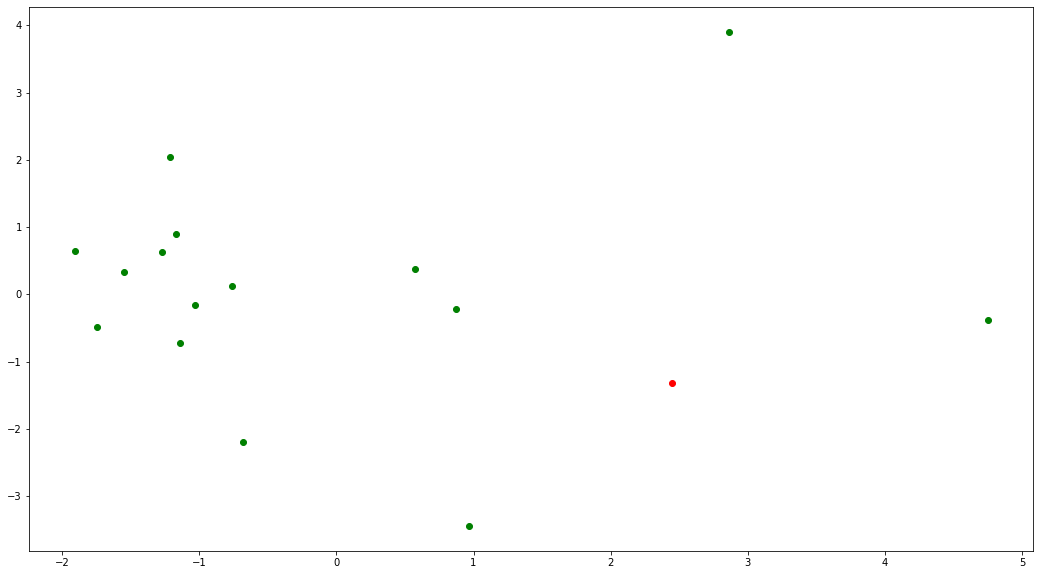

18 eng_at_1


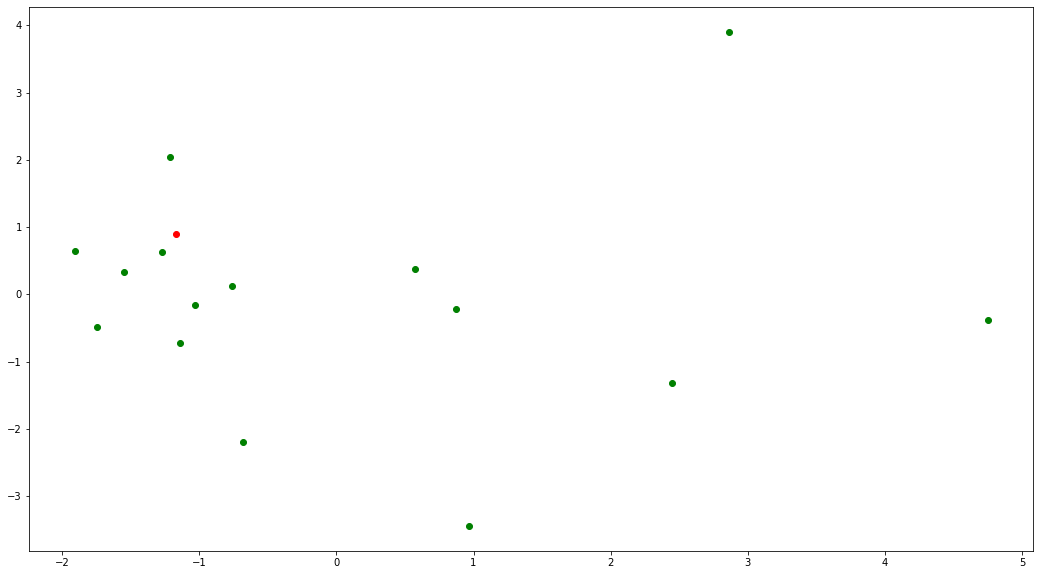

19 eng_at_29


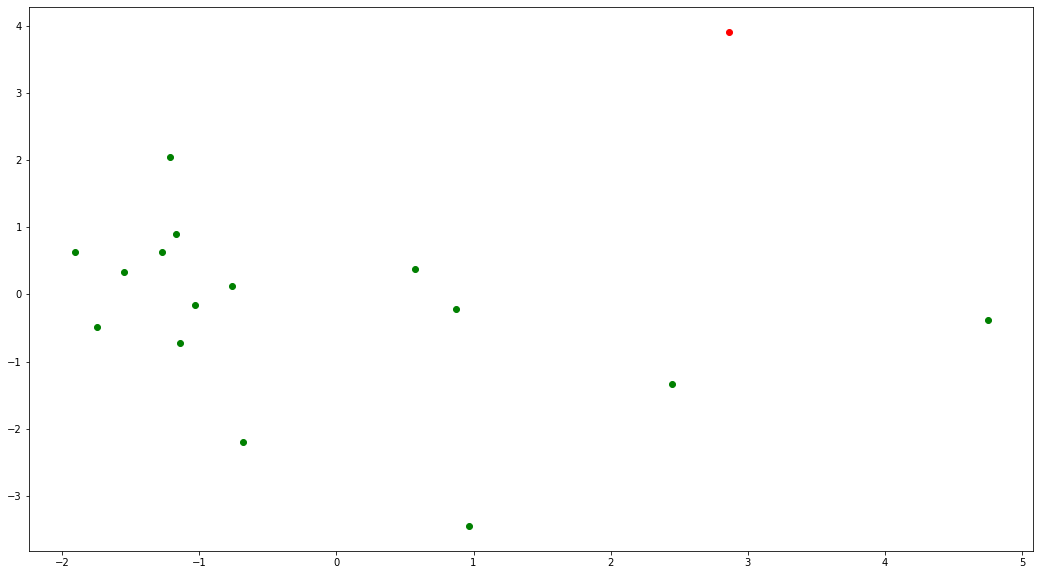

20 cyn_yn_11


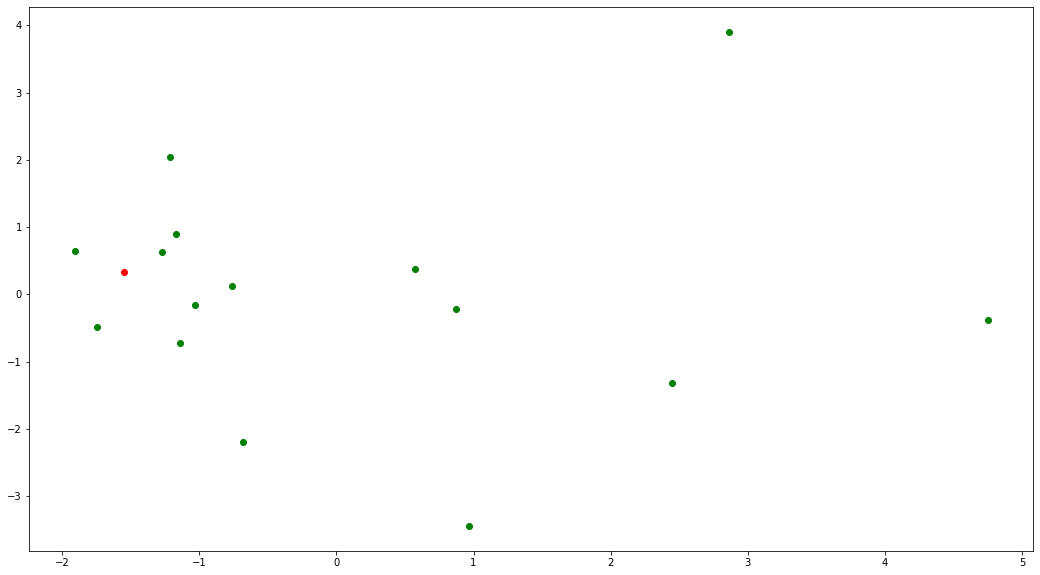

21 cyn_yn_1


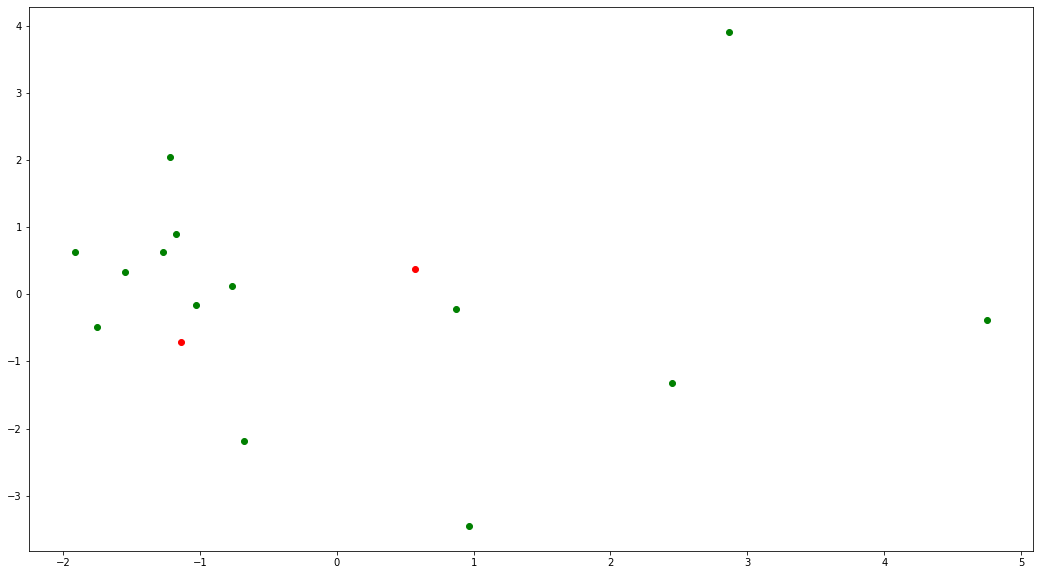

22 cyn_yn_0


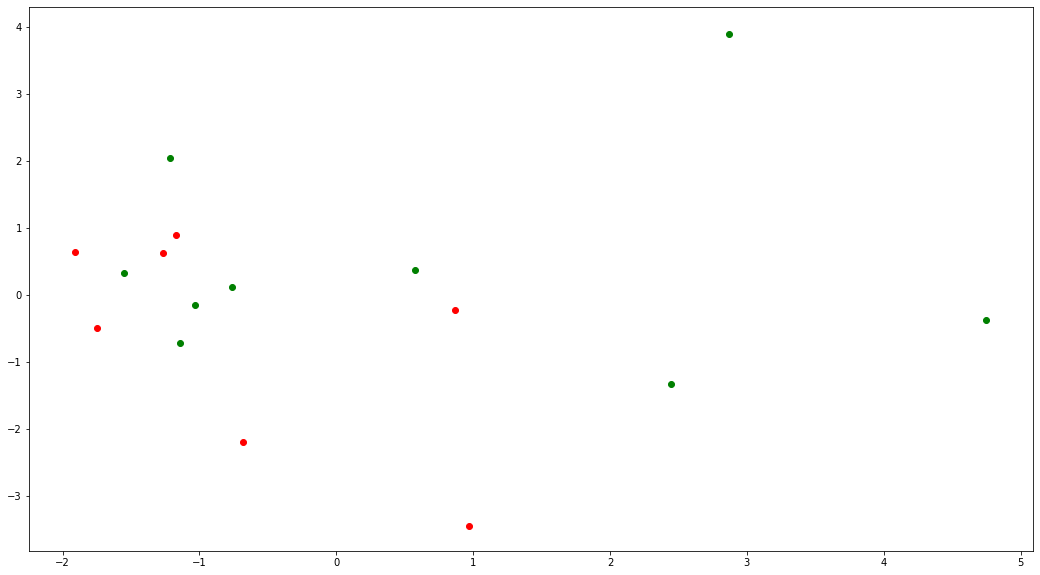

23 cyn_yn_8


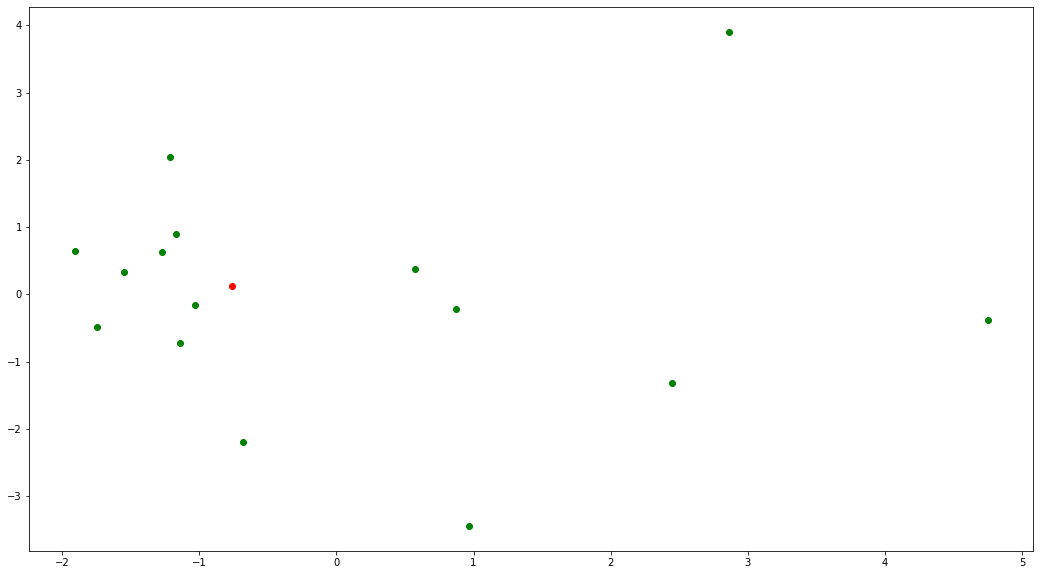

24 cyn_yn_3


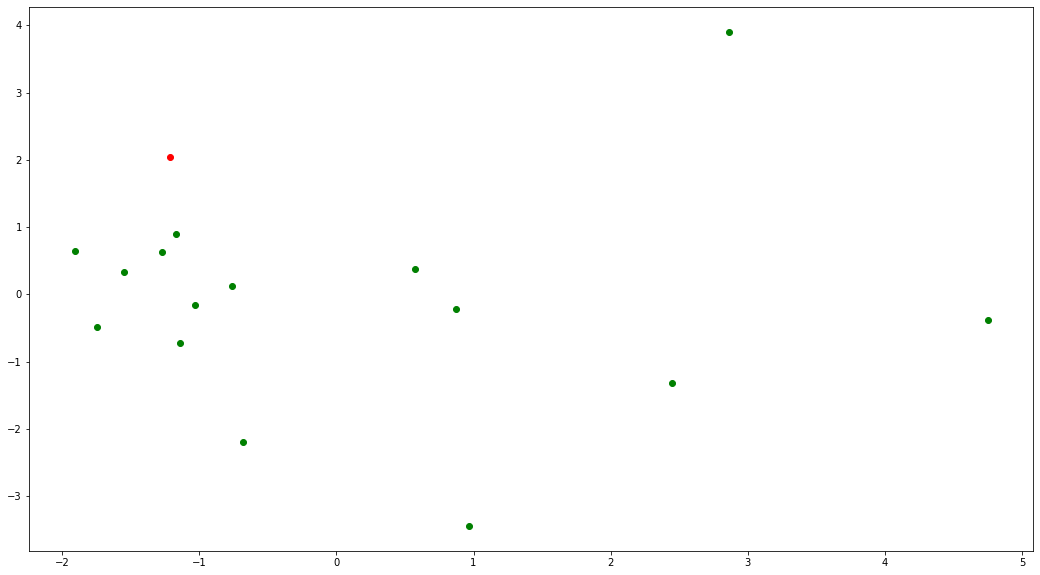

25 cyn_yn_6


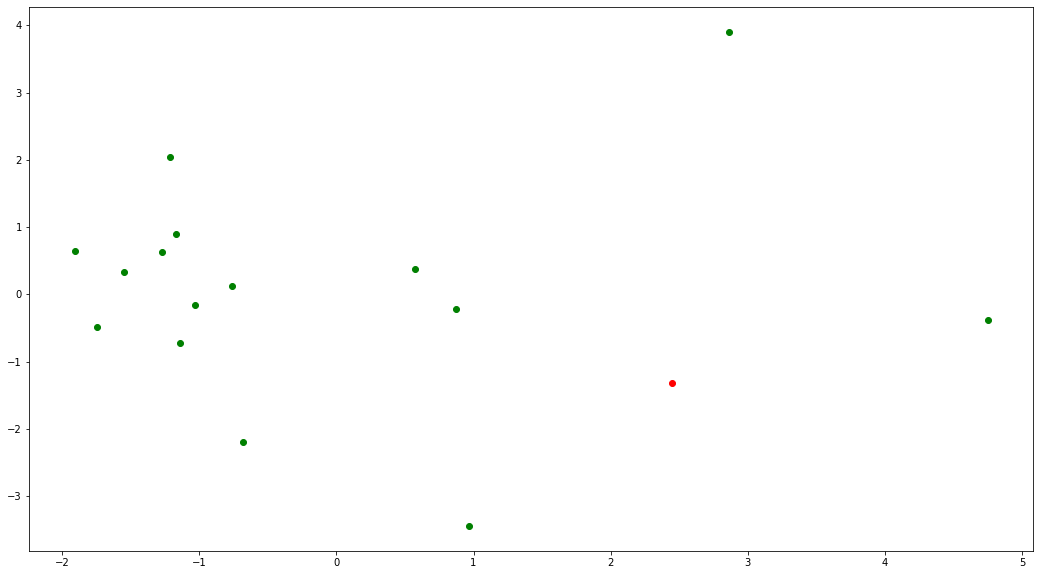

26 cyn_yn_2


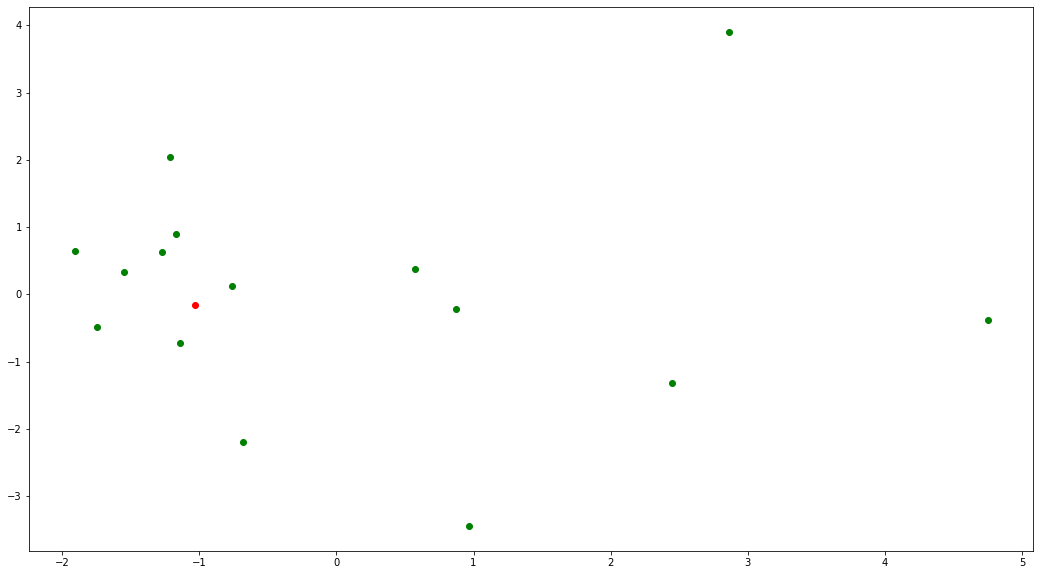

27 cyn_yn_17


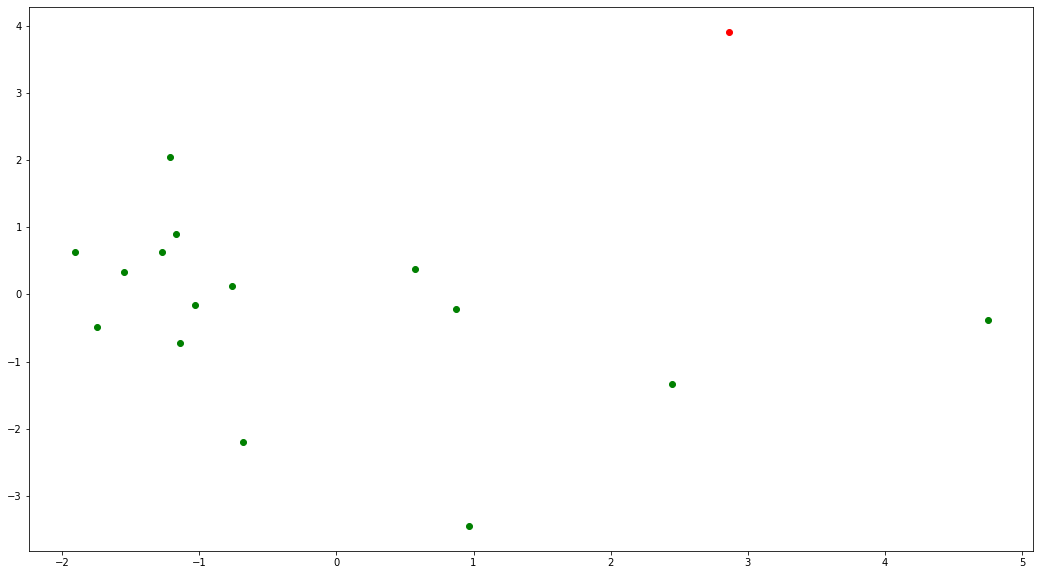

28 cyn_yn_21


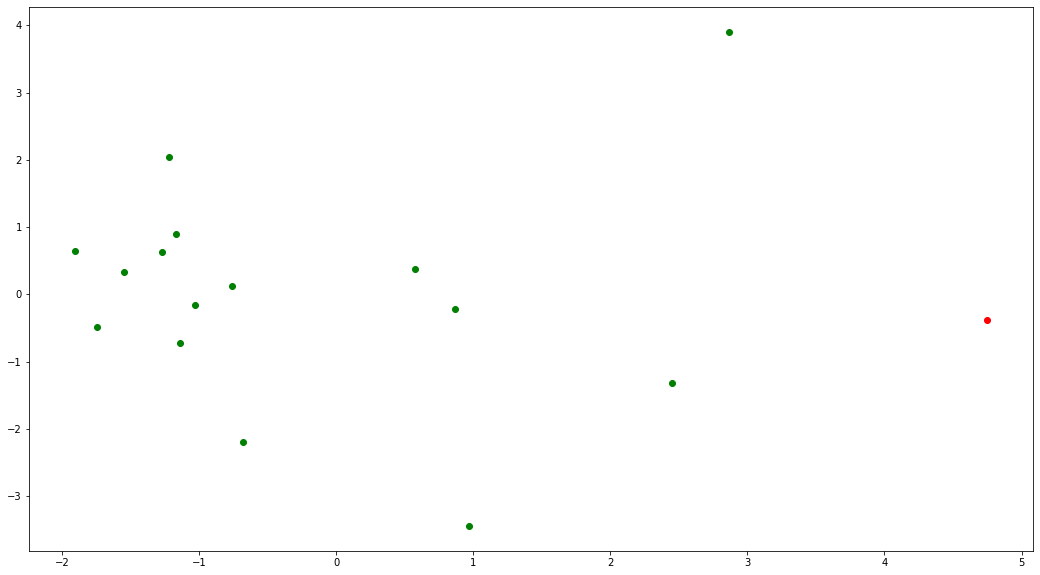

29 cym_ar_0


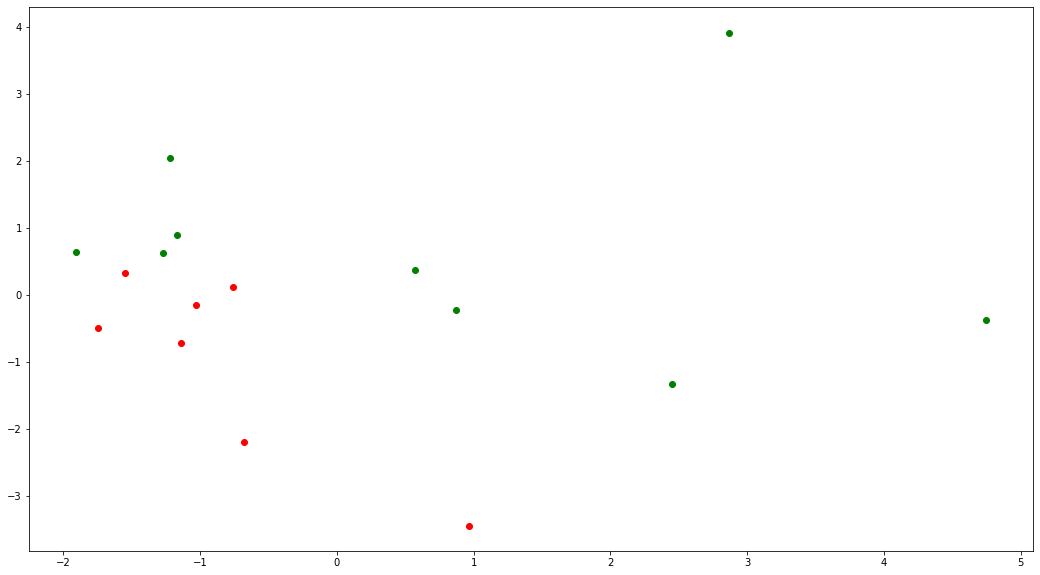

30 cym_ar_7


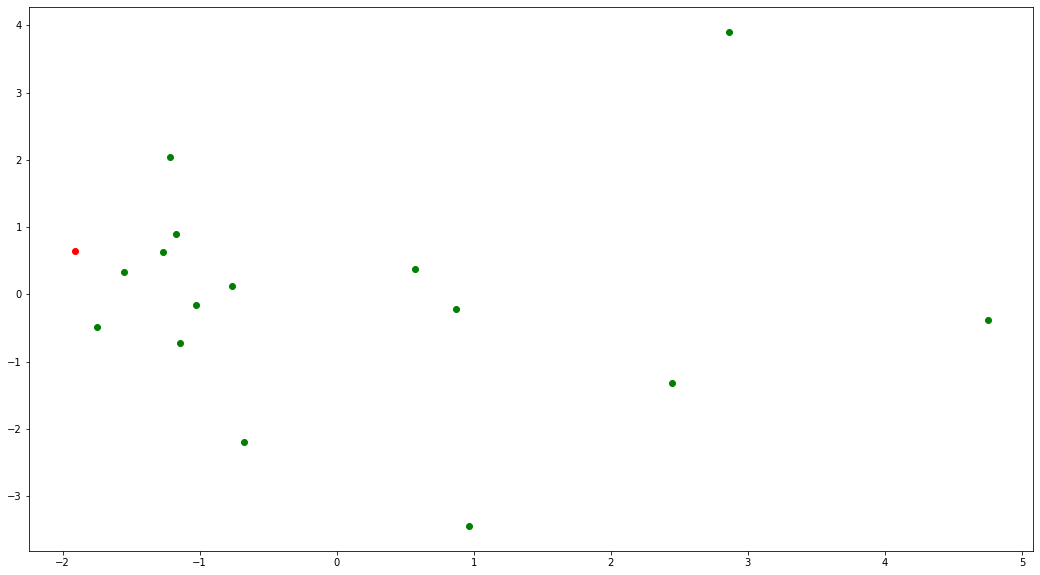

31 cym_ar_2


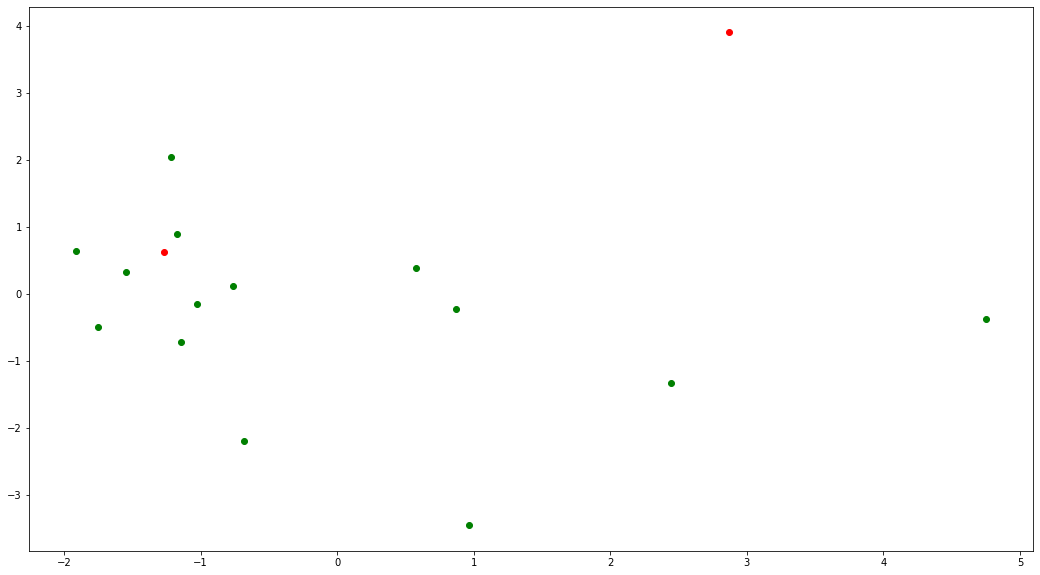

32 cym_ar_1


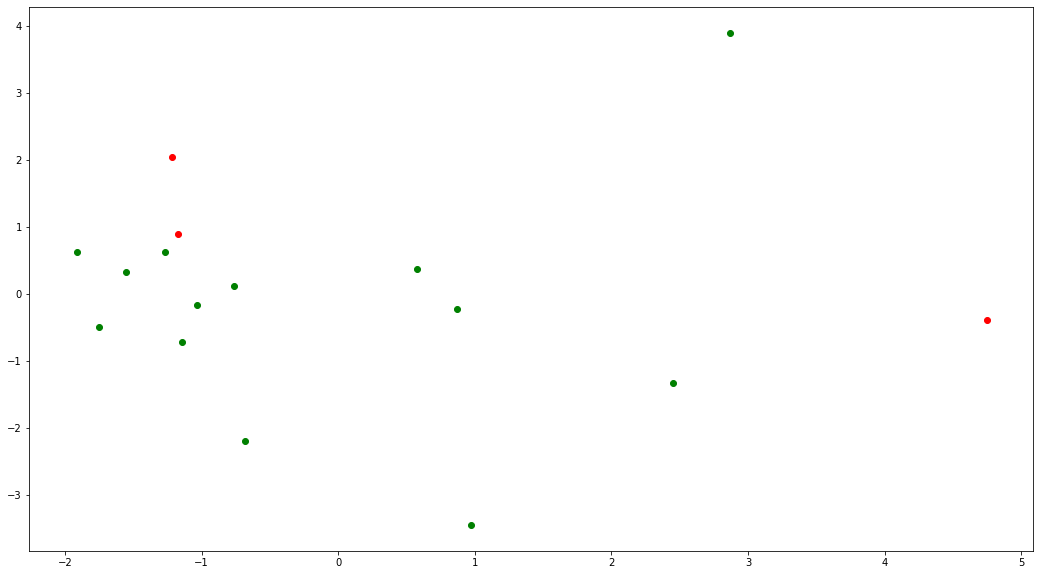

33 cym_ar_3


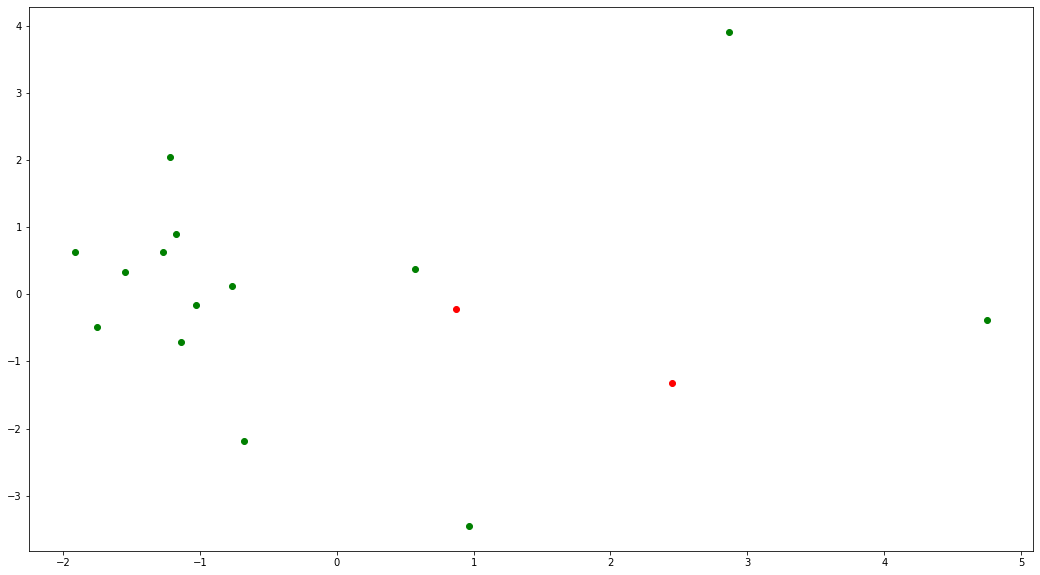

34 cym_ar_17


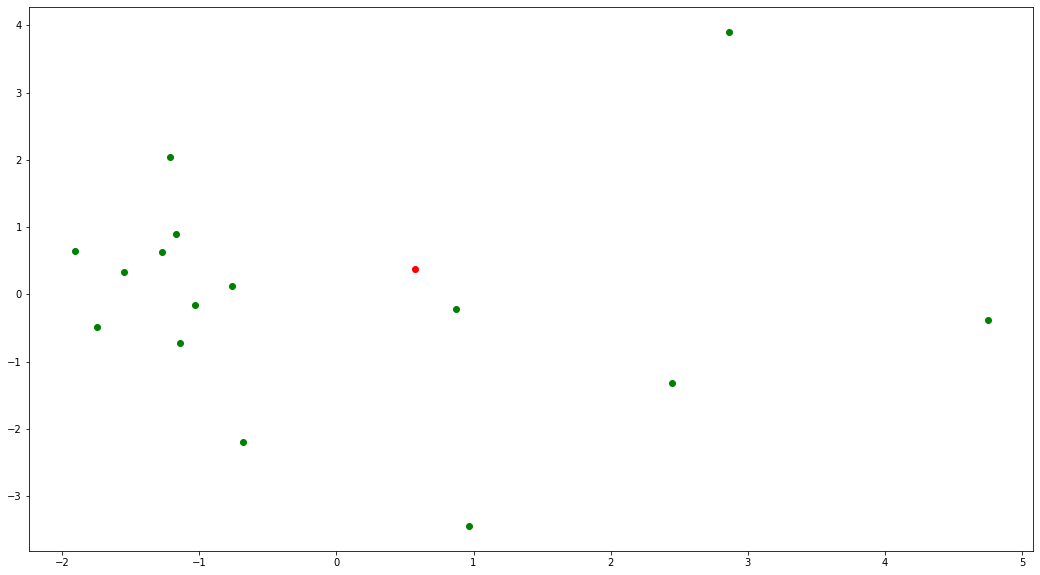

35 cym_mewn_1


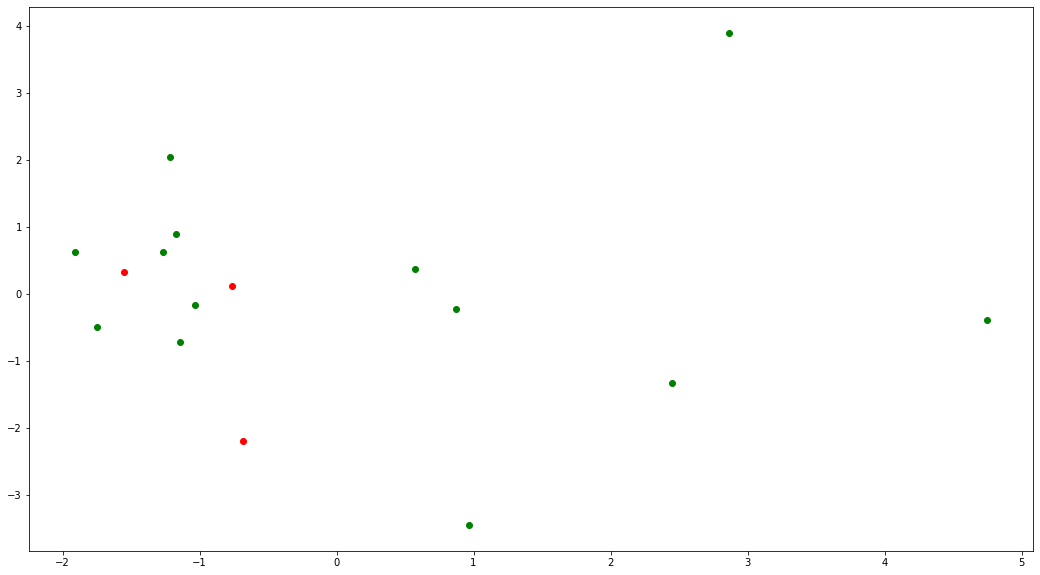

36 cym_mewn_0


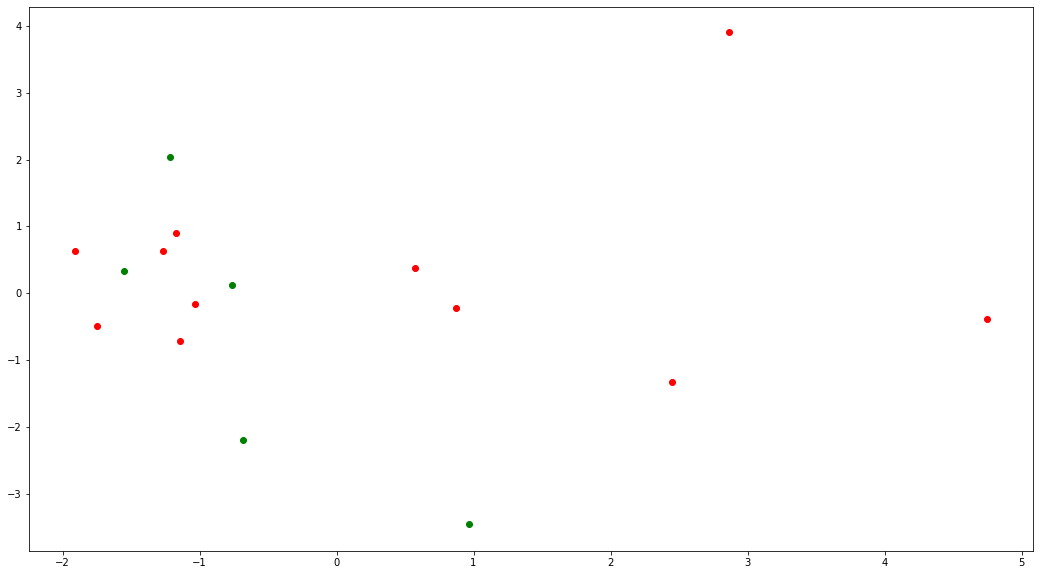

37 cym_mewn_2


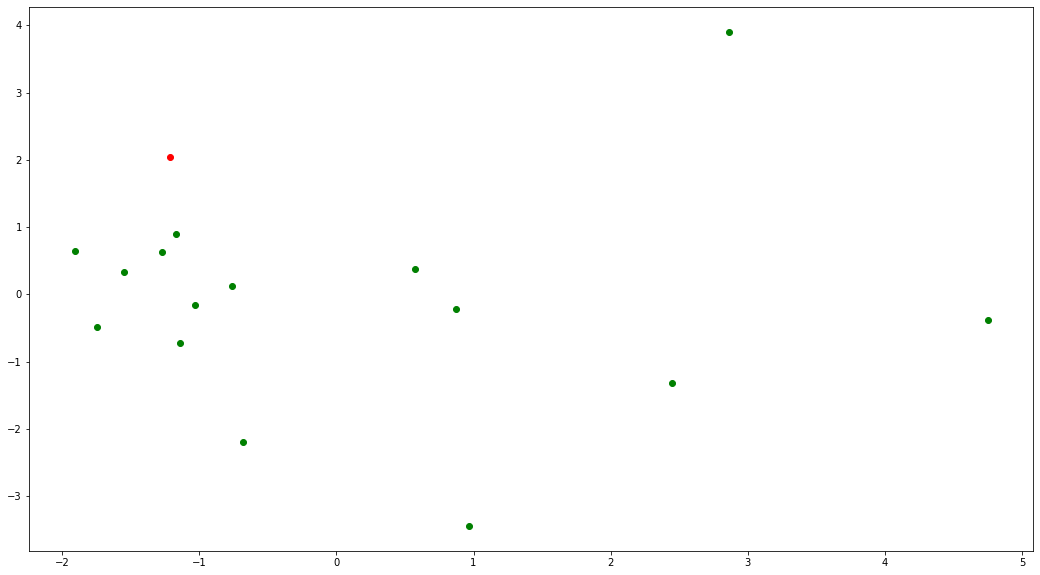

38 cym_mewn_8


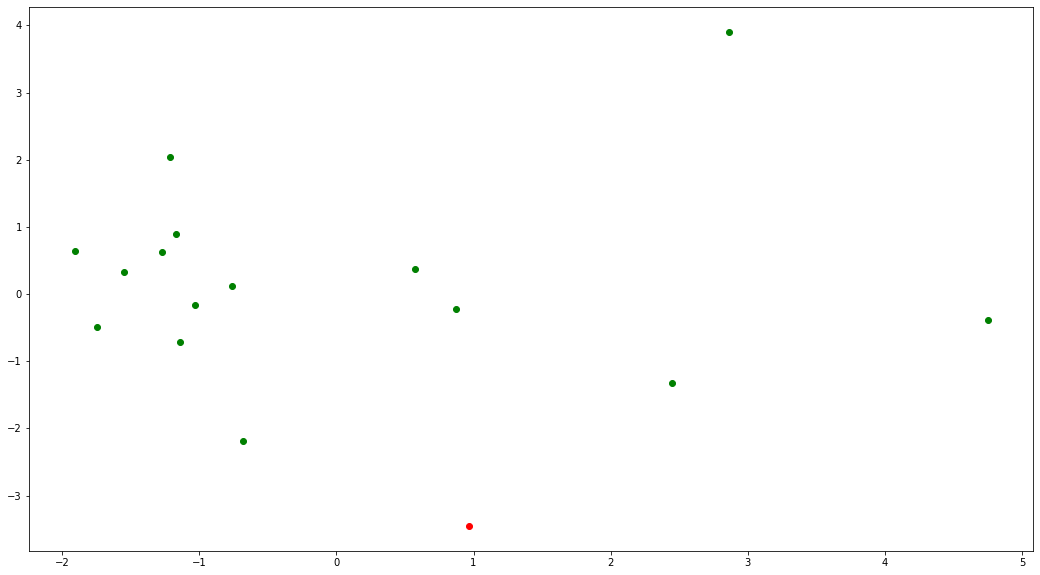

39 cym_zero_0


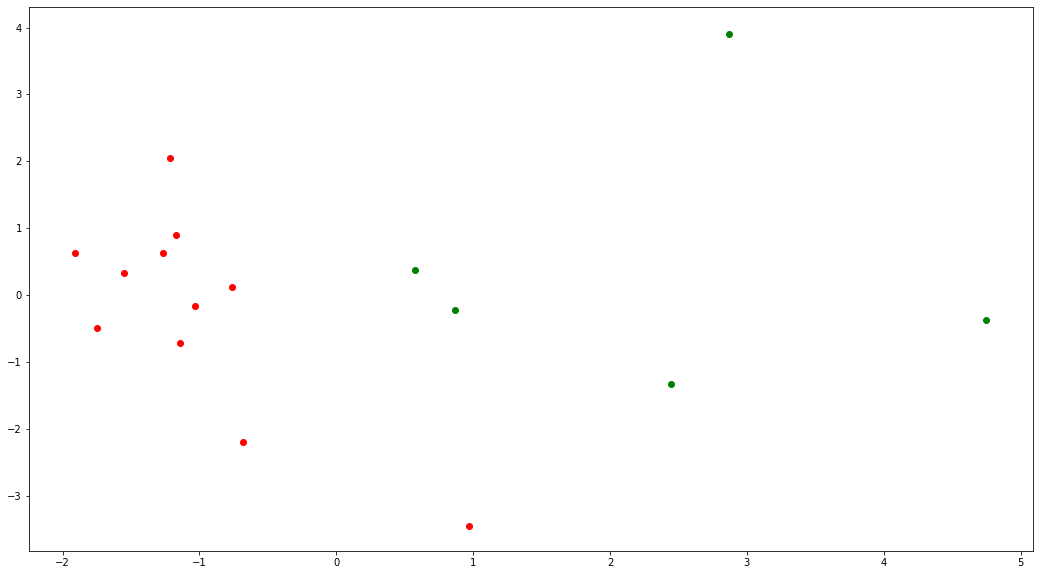

40 cym_zero_2


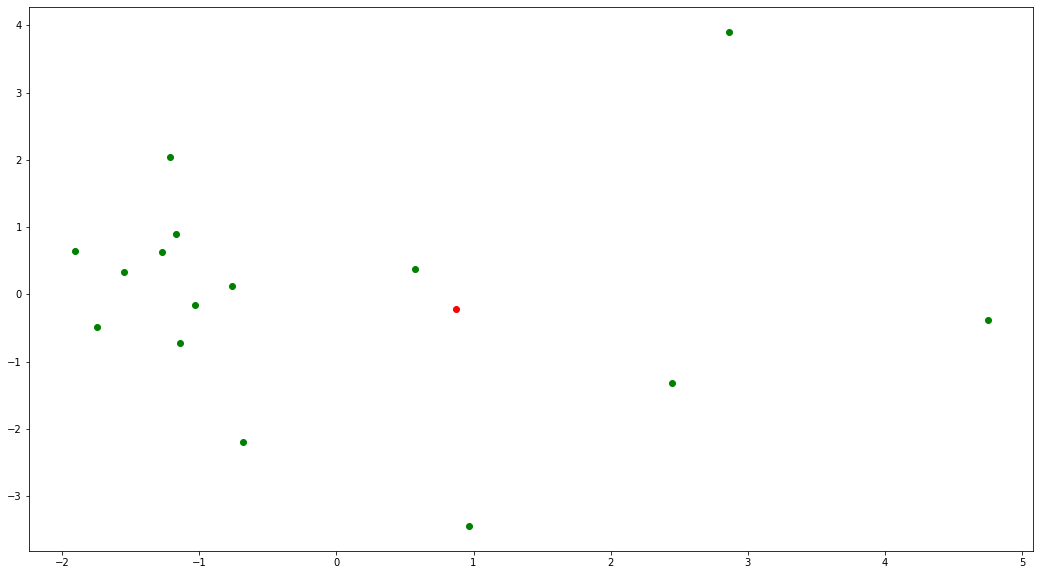

41 cym_zero_5


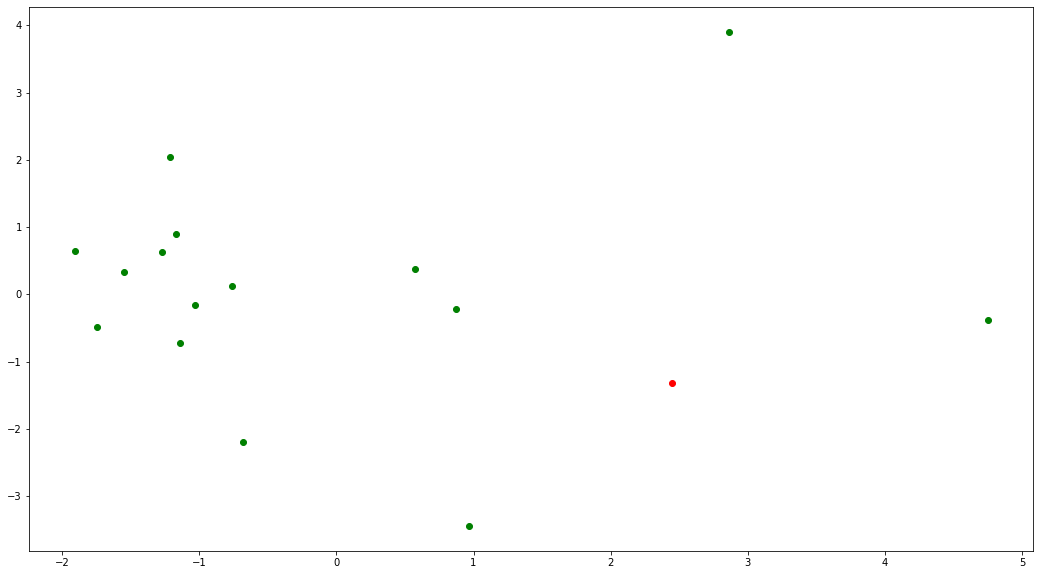

42 cym_zero_6


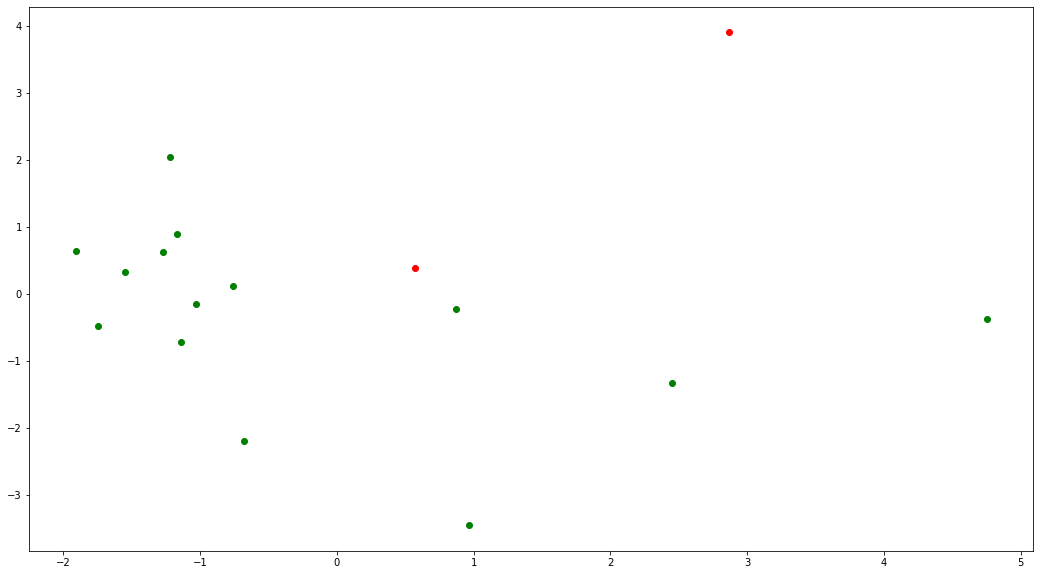

43 cym_zero_4


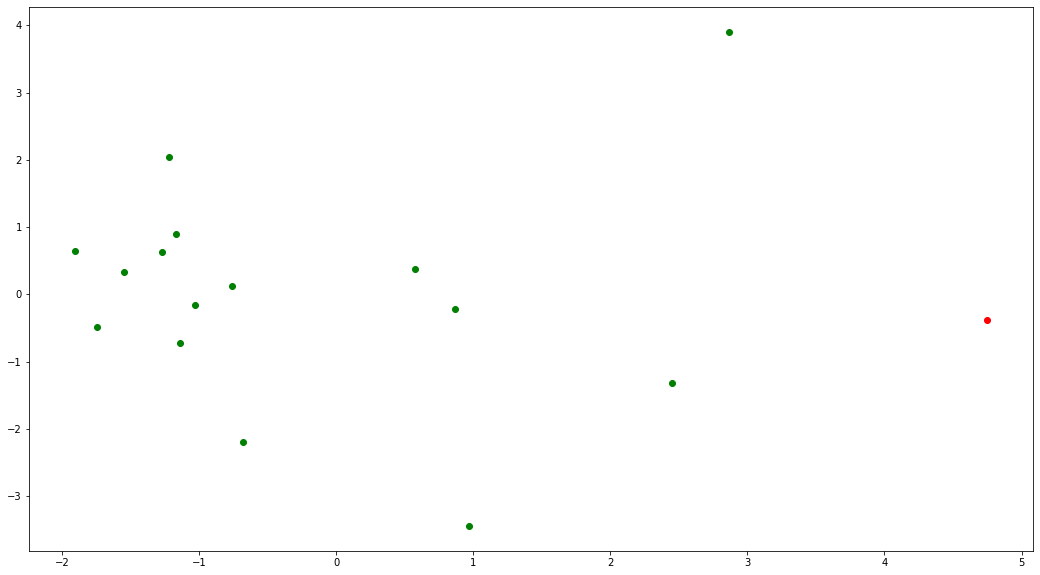

44 cym_wrth_0


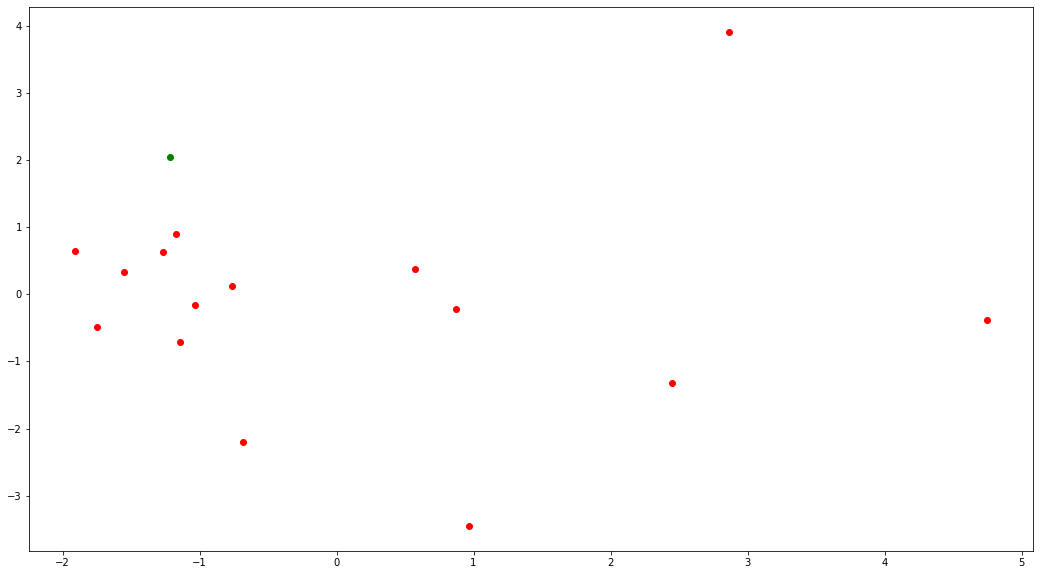

45 cym_wrth_3


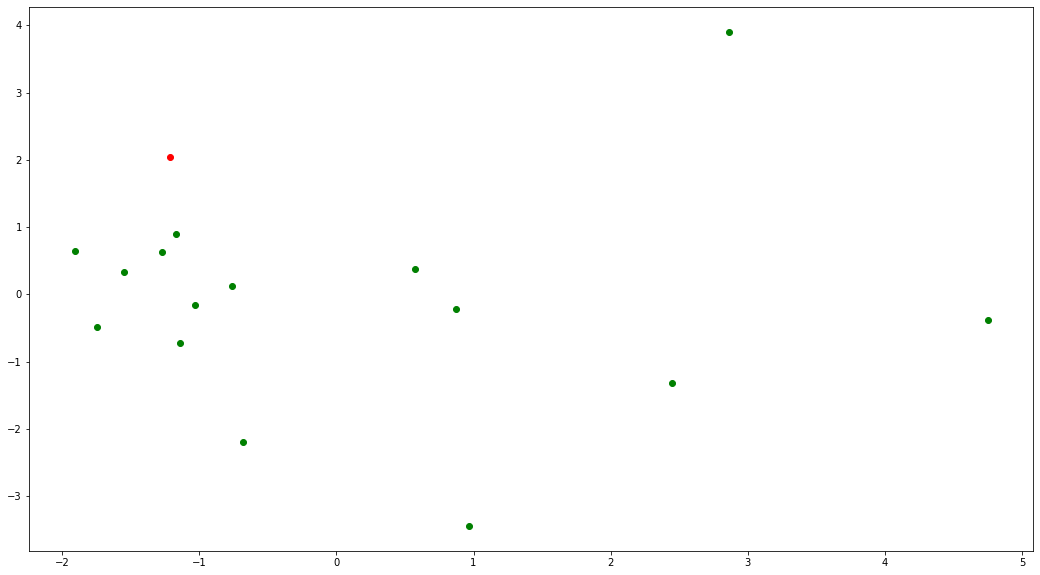

46 cym_other_0


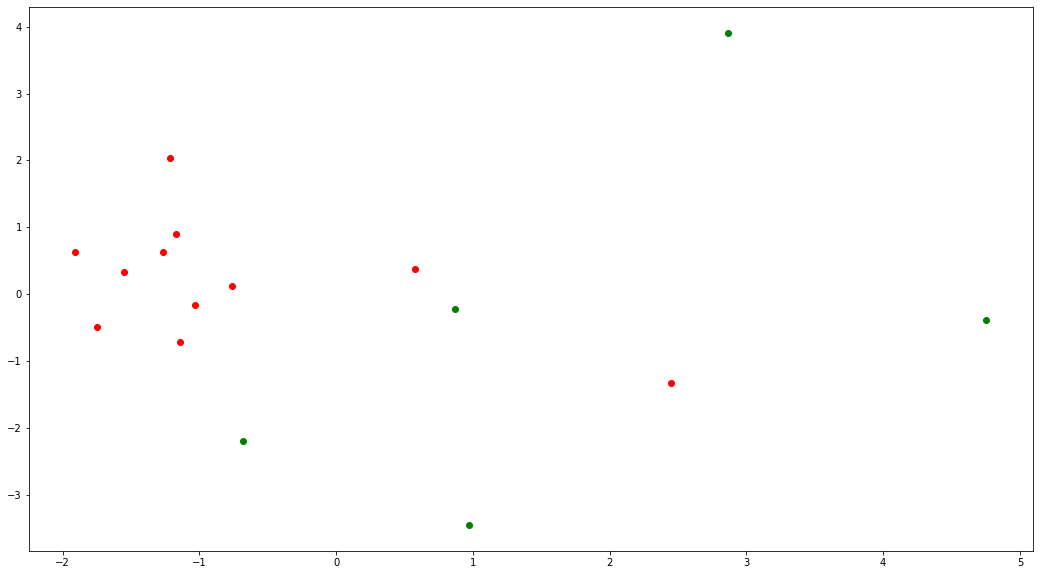

47 cym_other_4


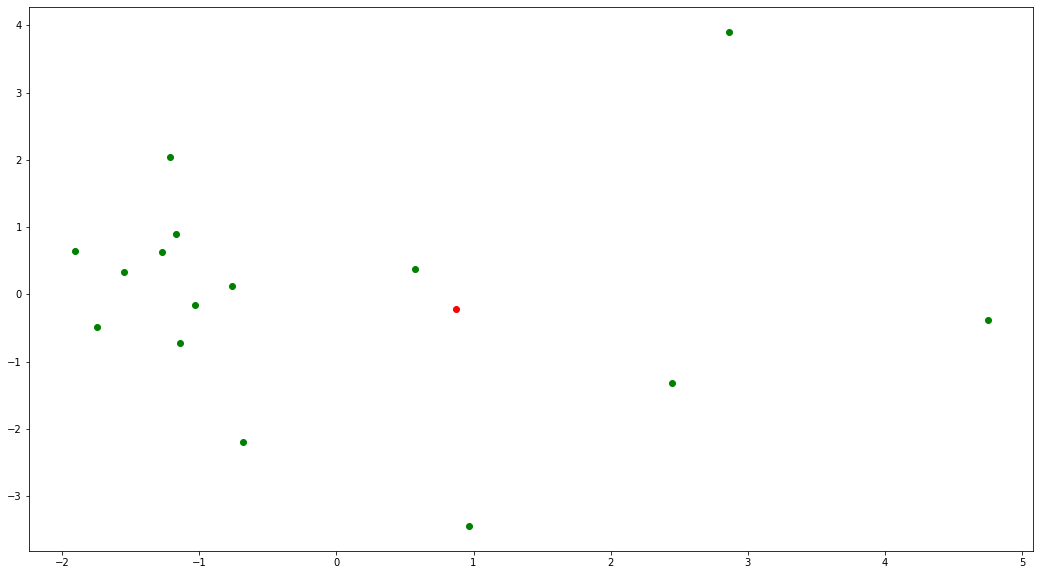

48 cym_other_6


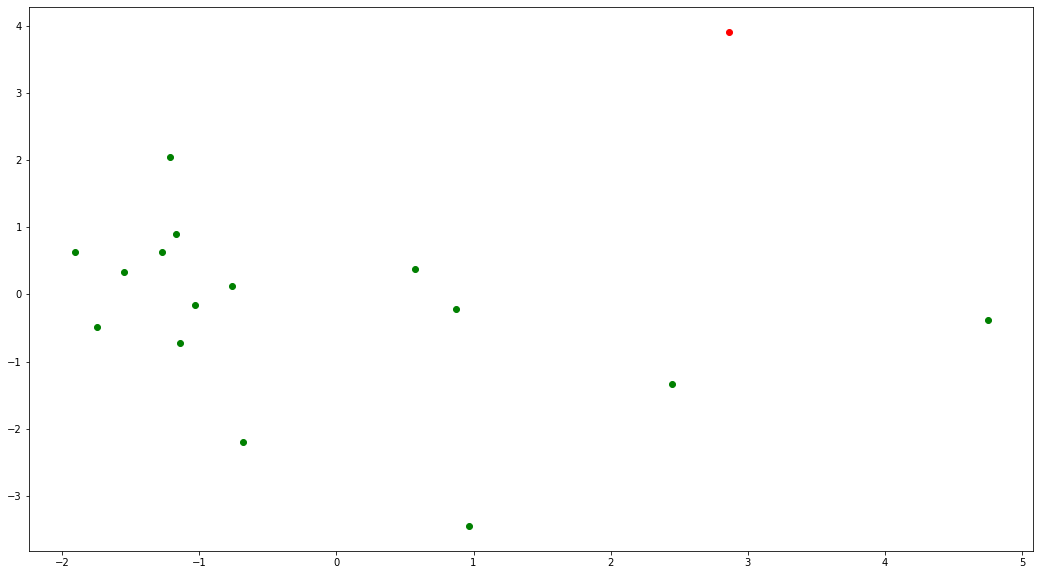

49 cym_other_2


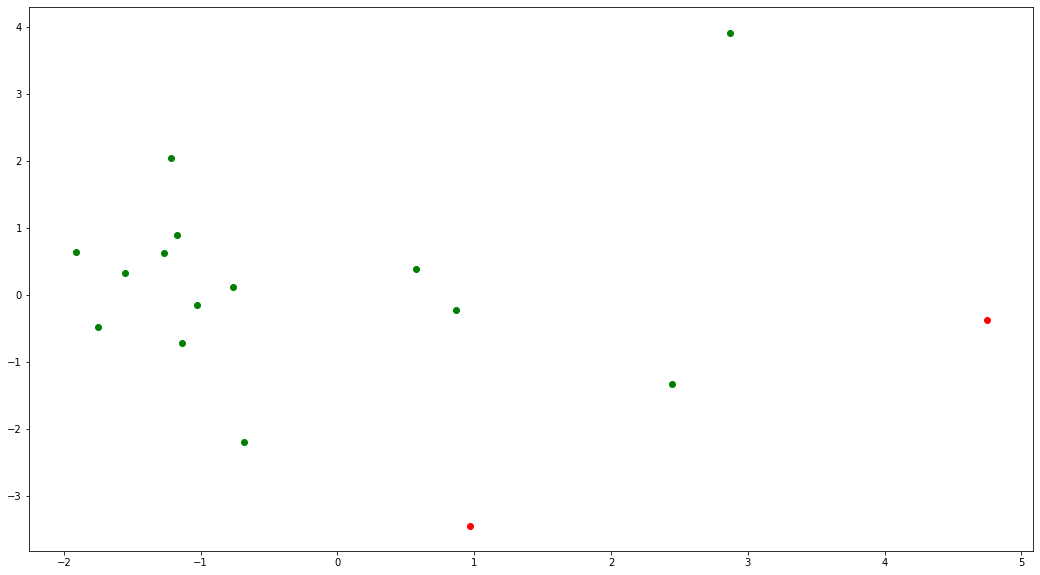

50 cym_other_1


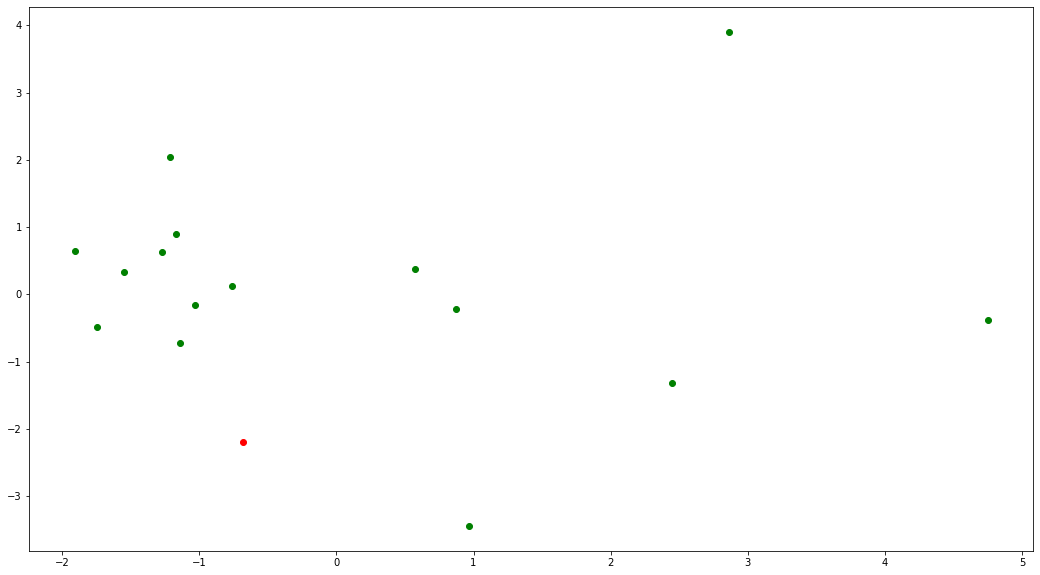

51 deu_in_9


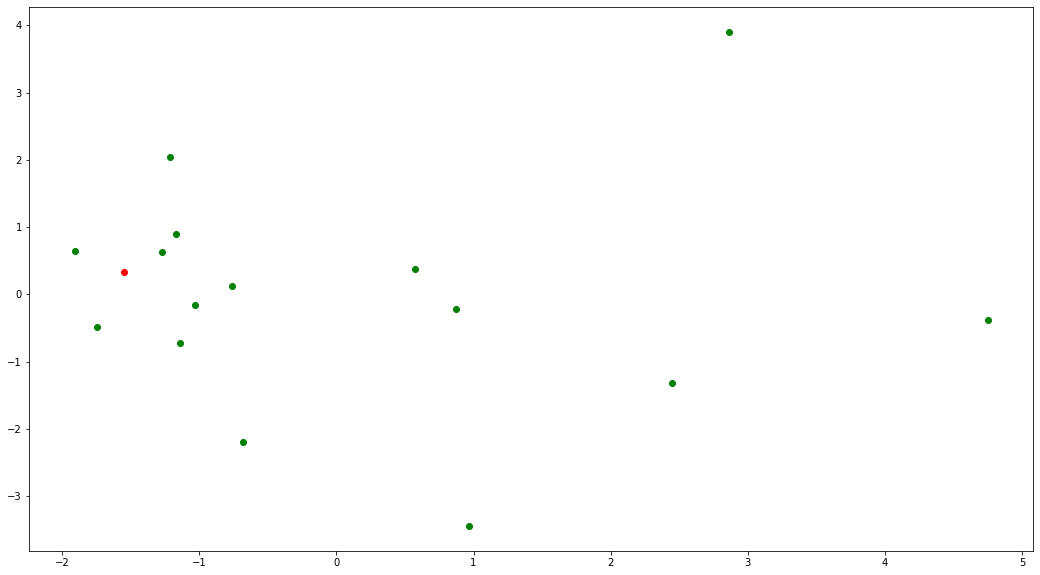

52 deu_in_1


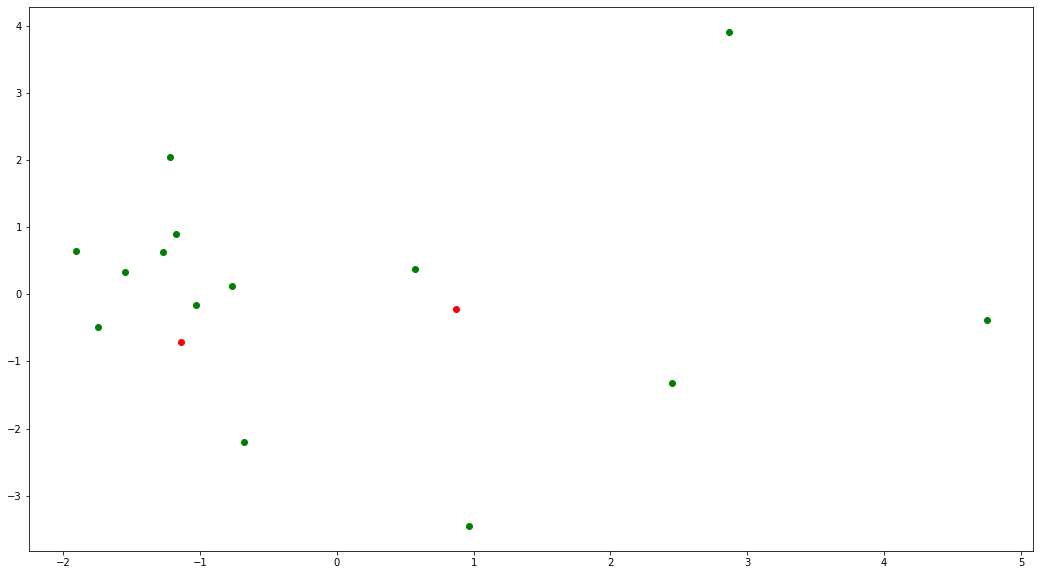

53 deu_in_0


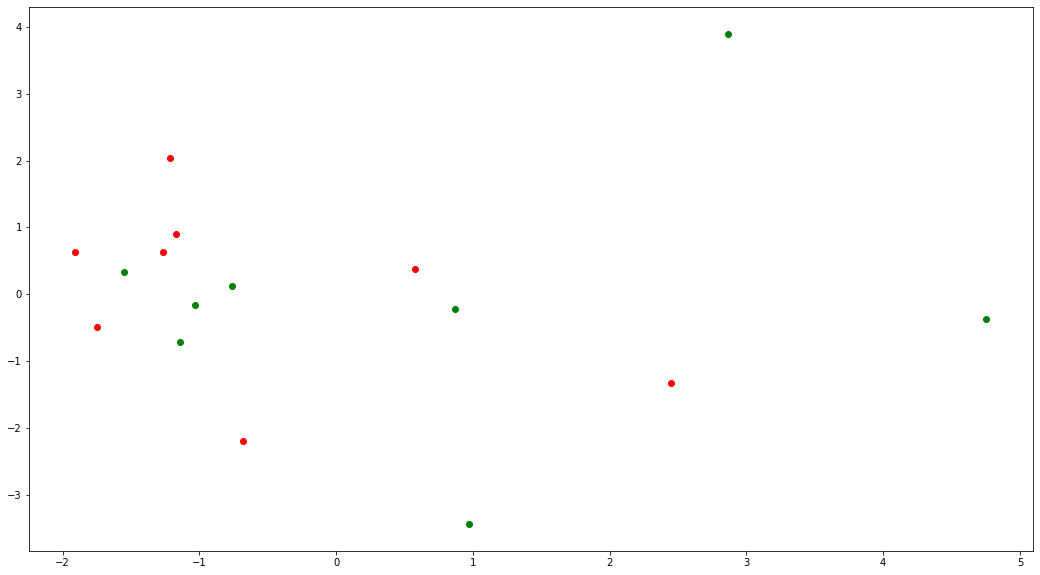

54 deu_in_8


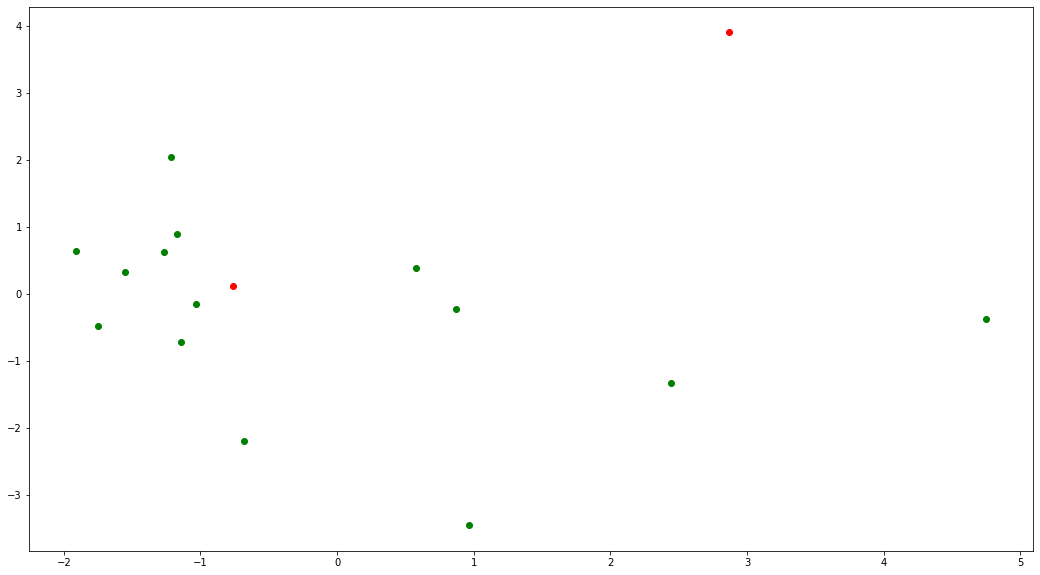

55 deu_in_2


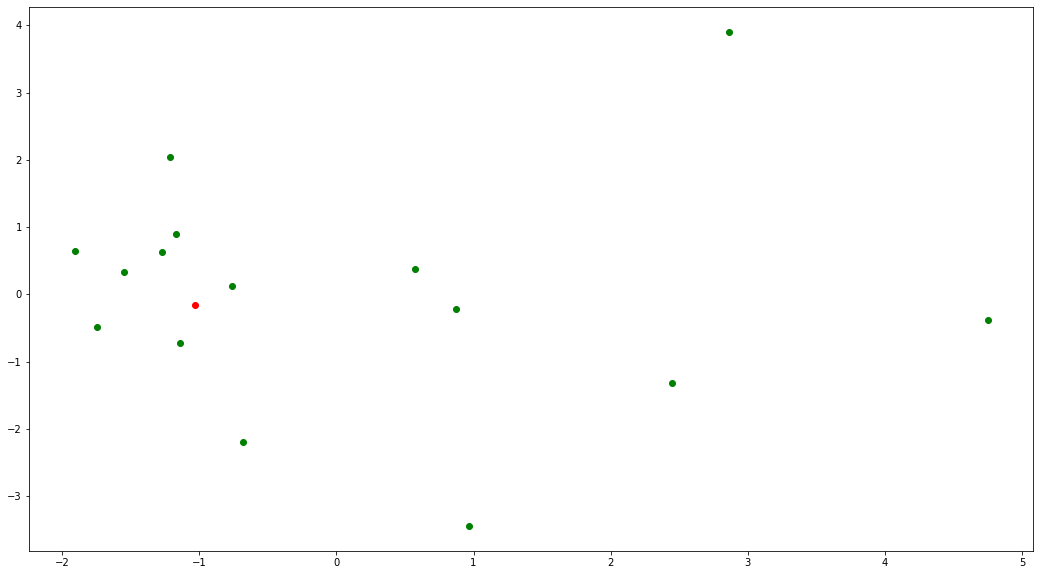

56 deu_in_22


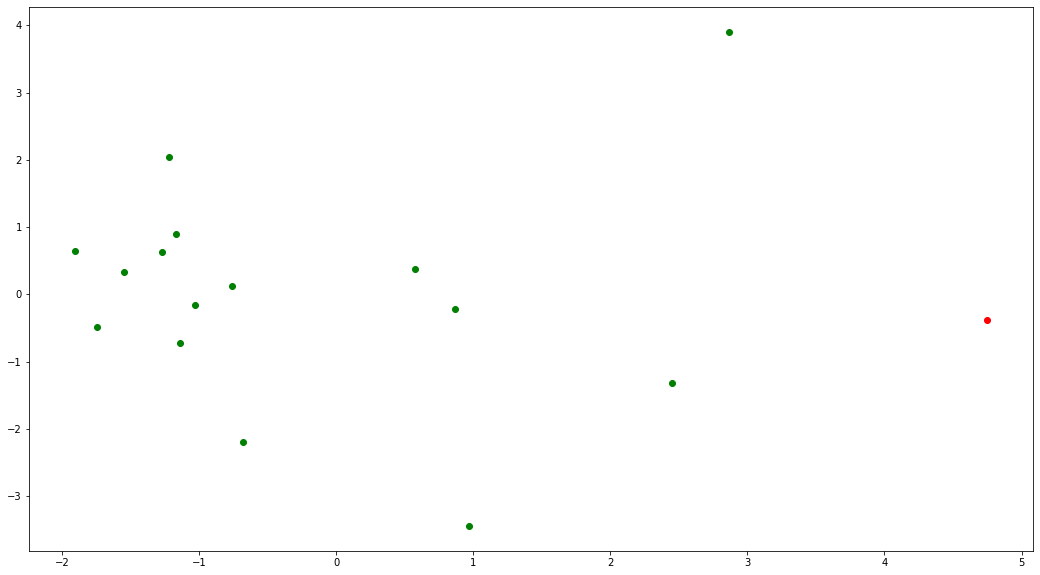

57 deu_in_4


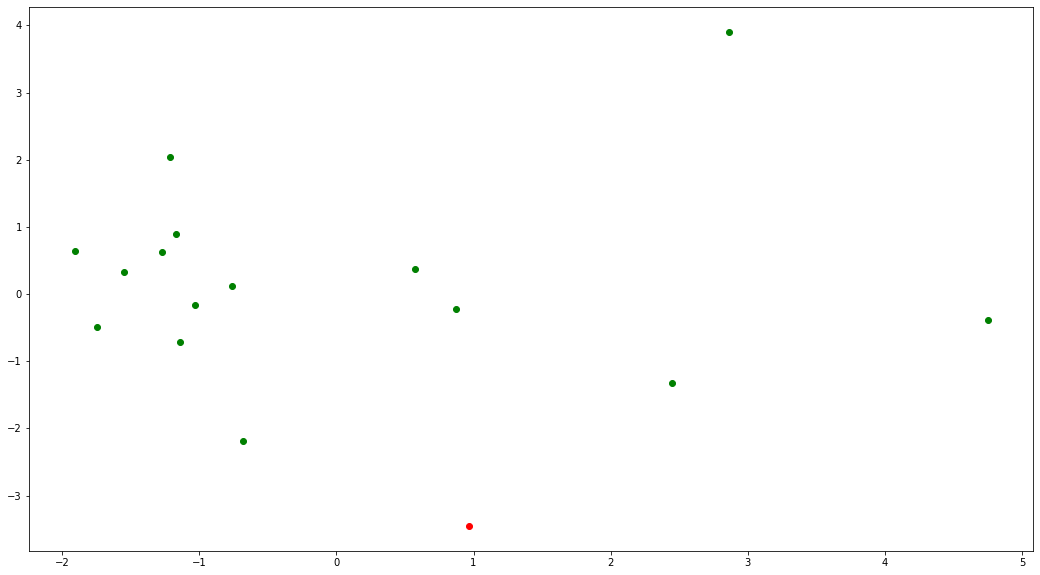

58 deu_auf_4


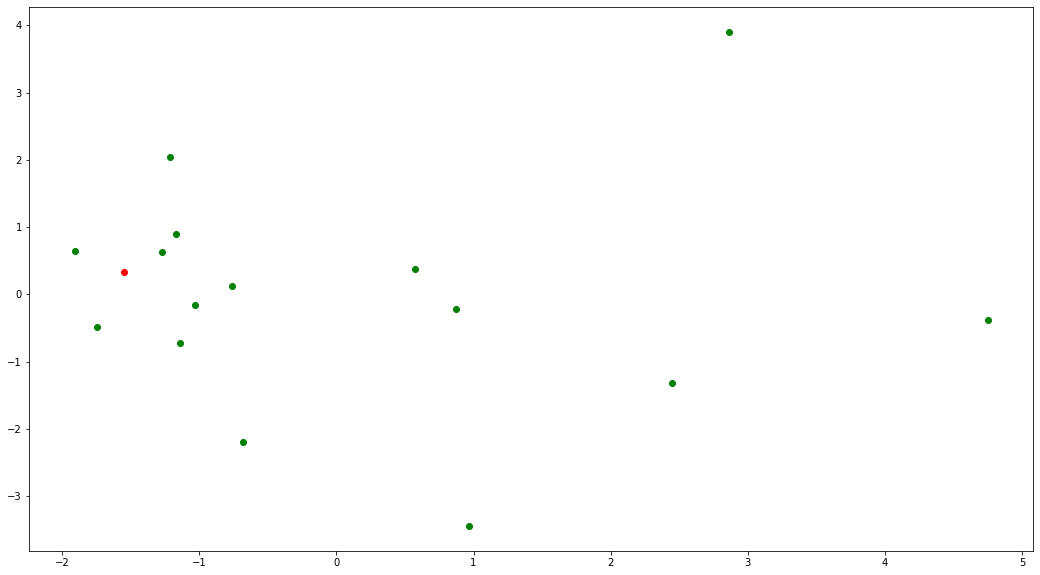

59 deu_auf_0


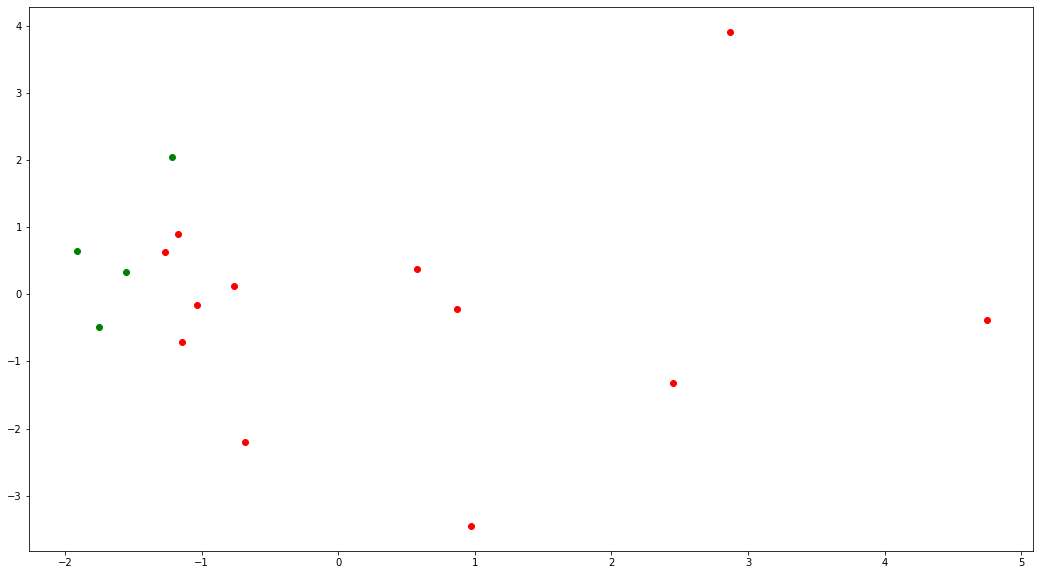

60 deu_auf_1


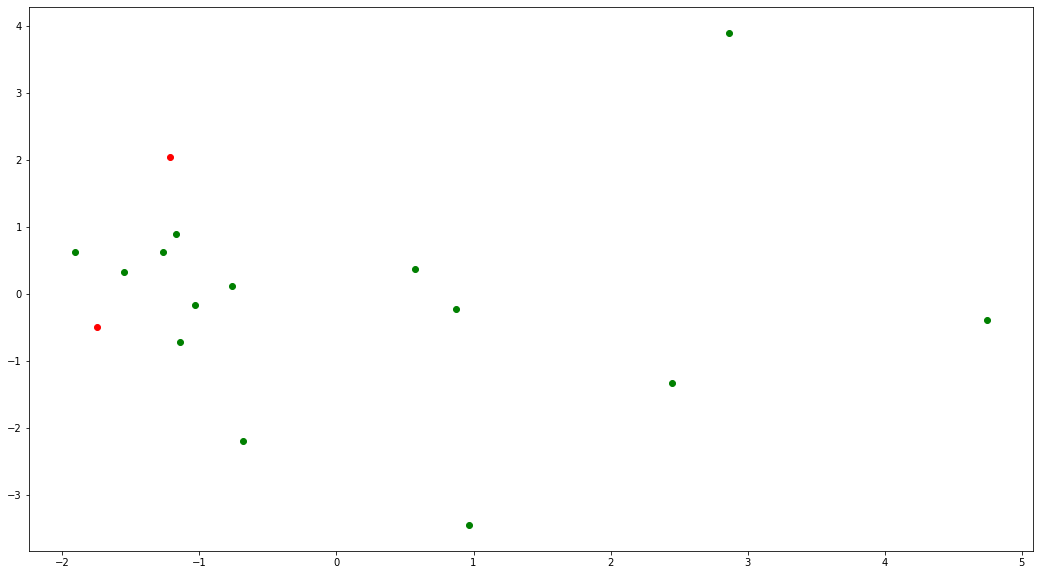

61 deu_auf_7


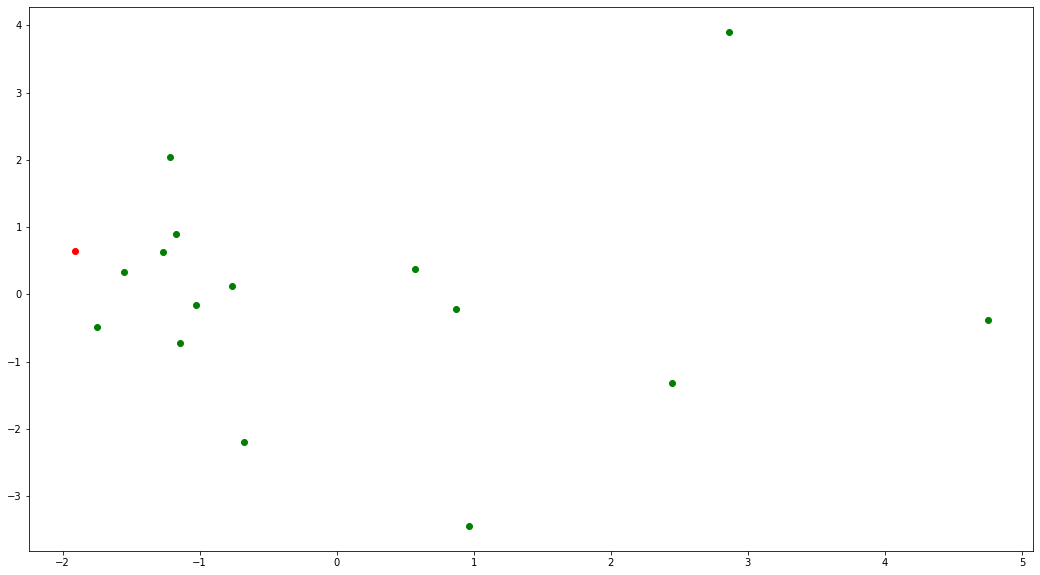

62 deu_zu_0


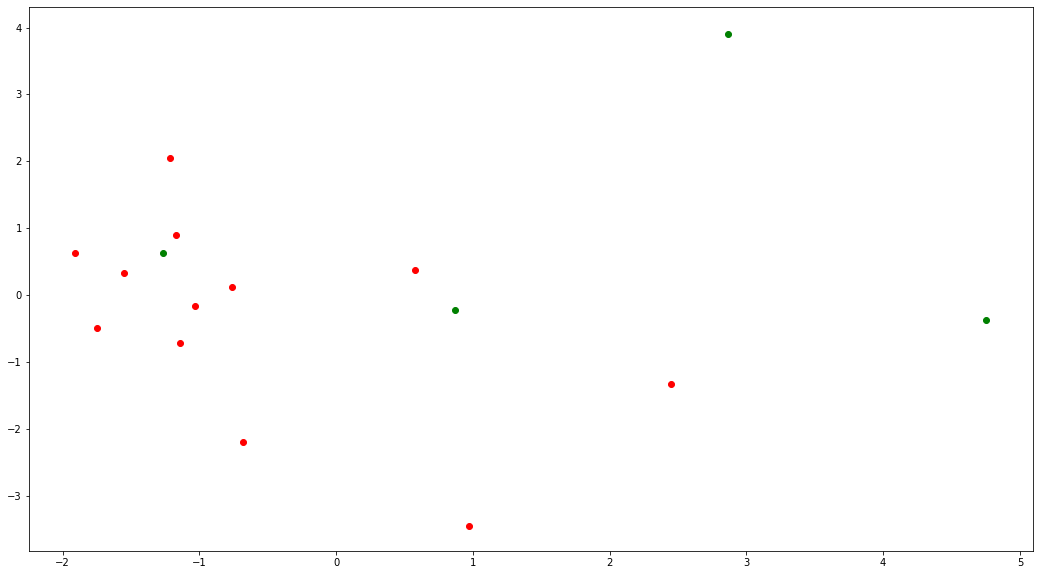

63 deu_zu_2


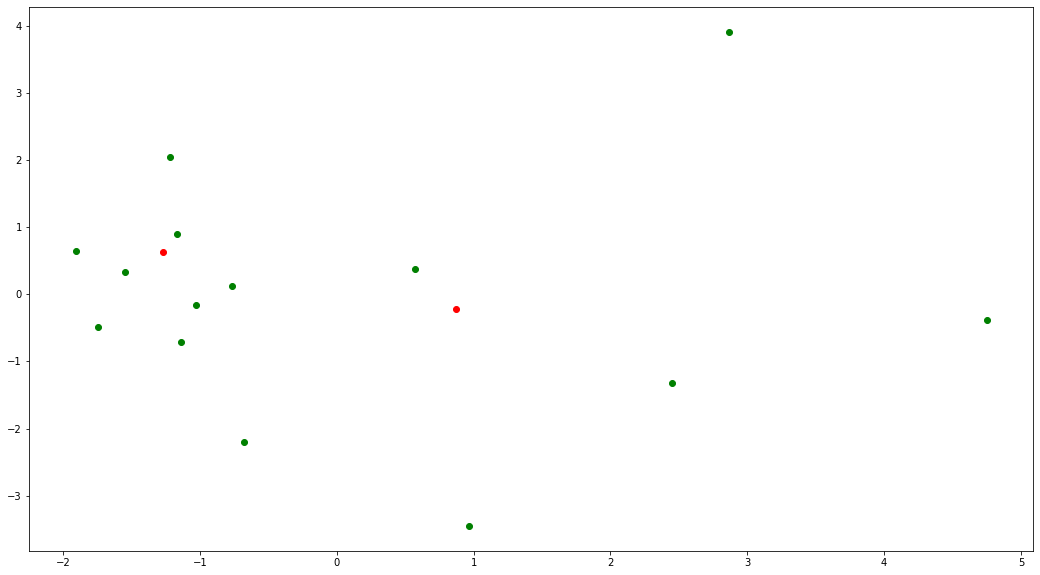

64 deu_zu_11


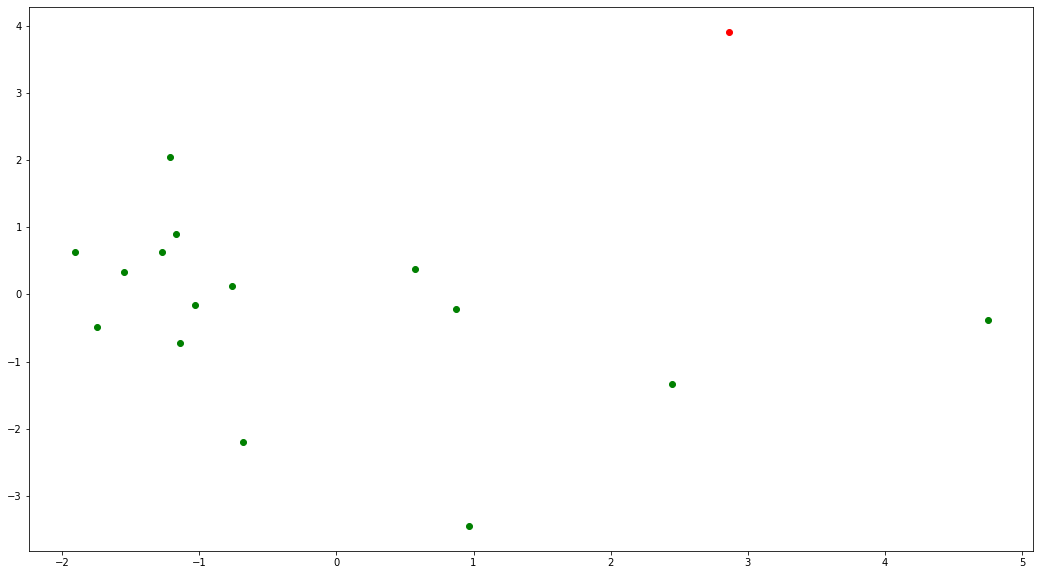

65 deu_zu_3


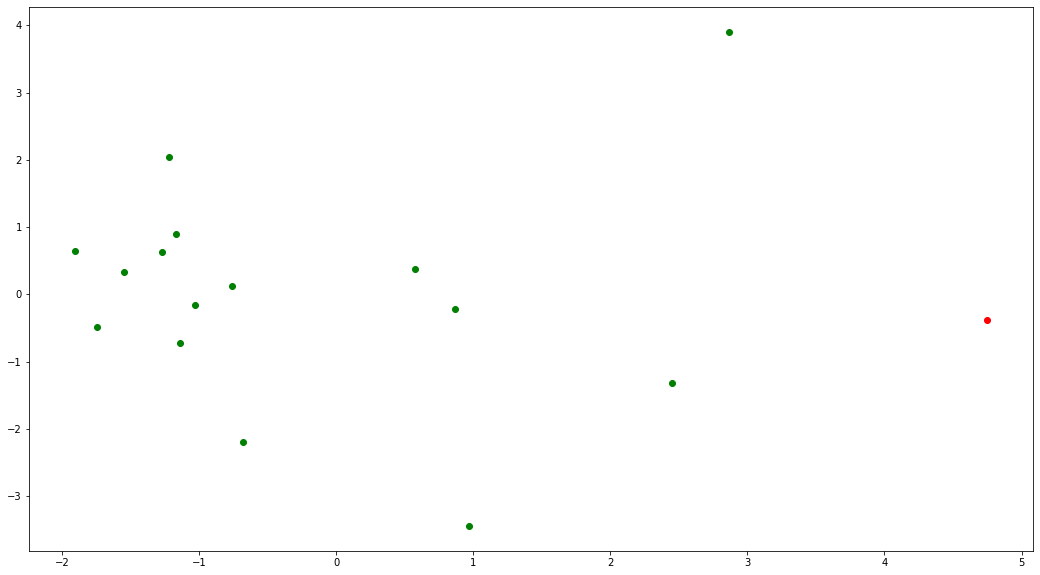

66 deu_an_0


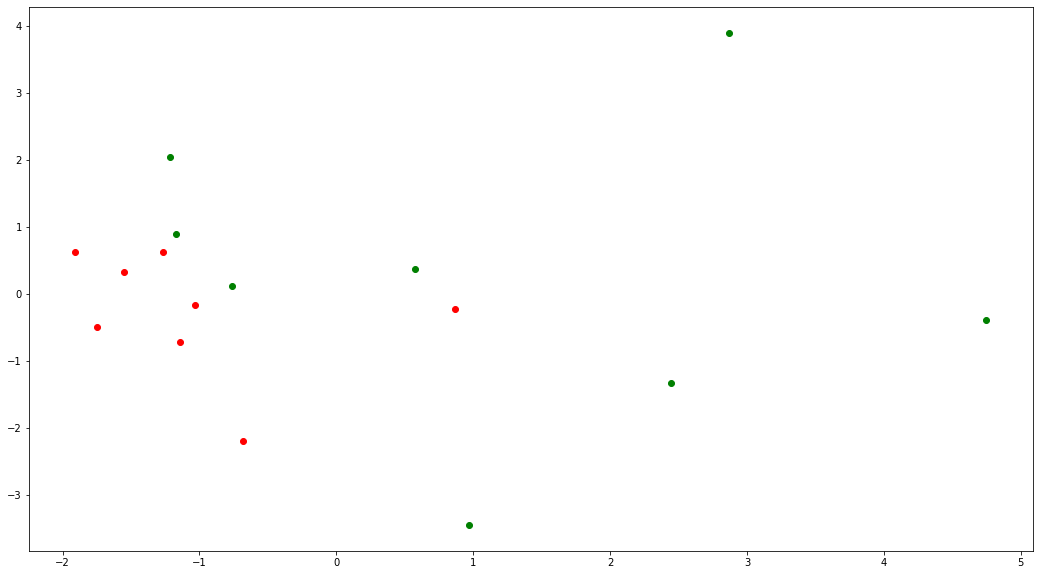

67 deu_an_1


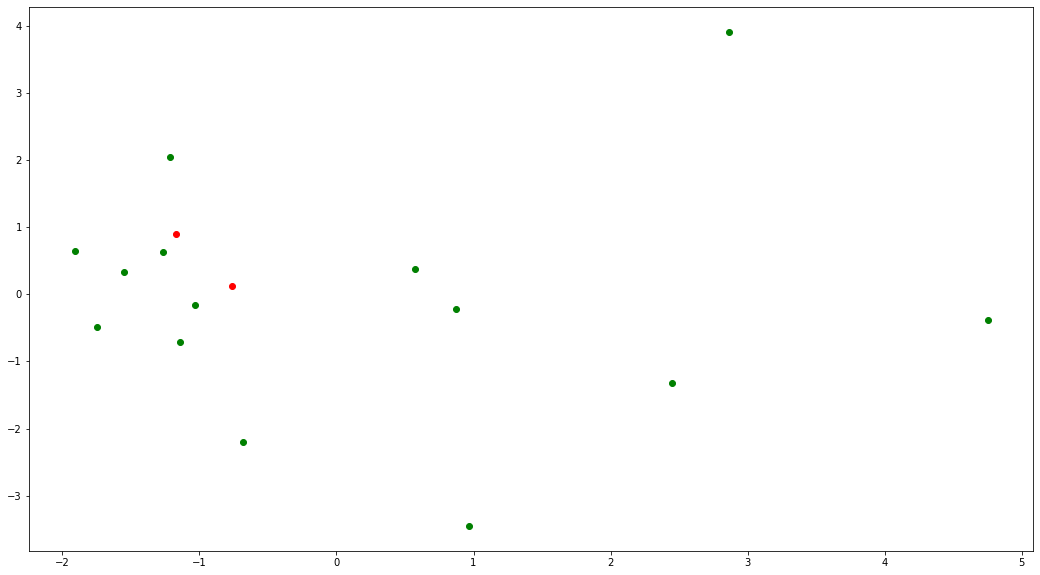

68 deu_an_5


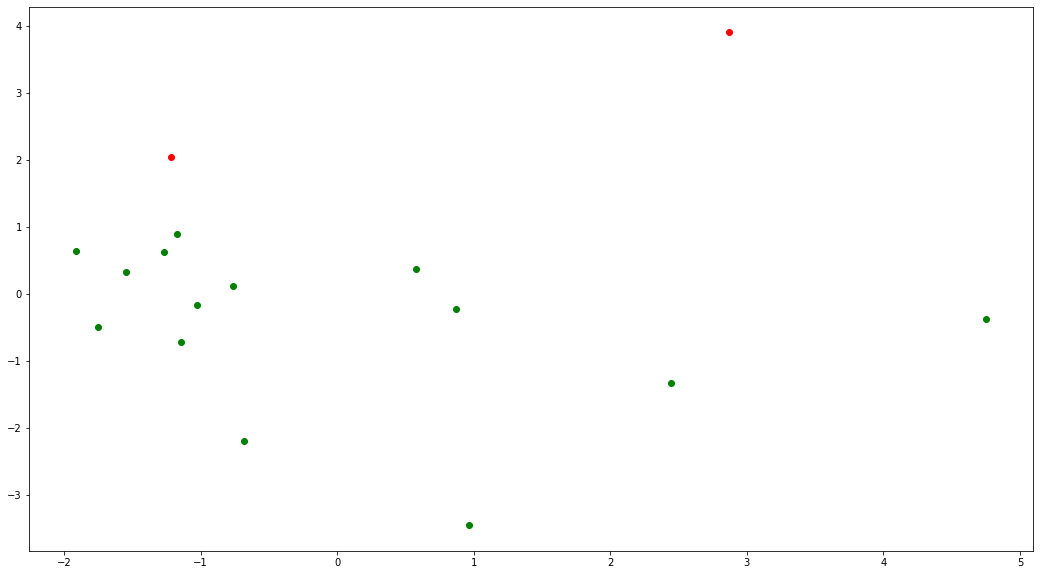

69 deu_an_9


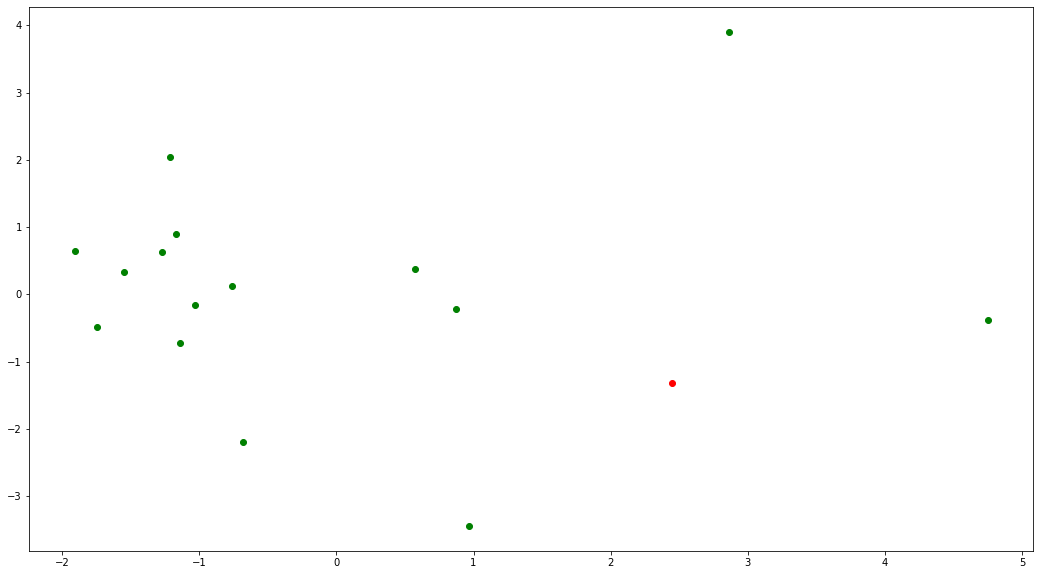

70 deu_an_24


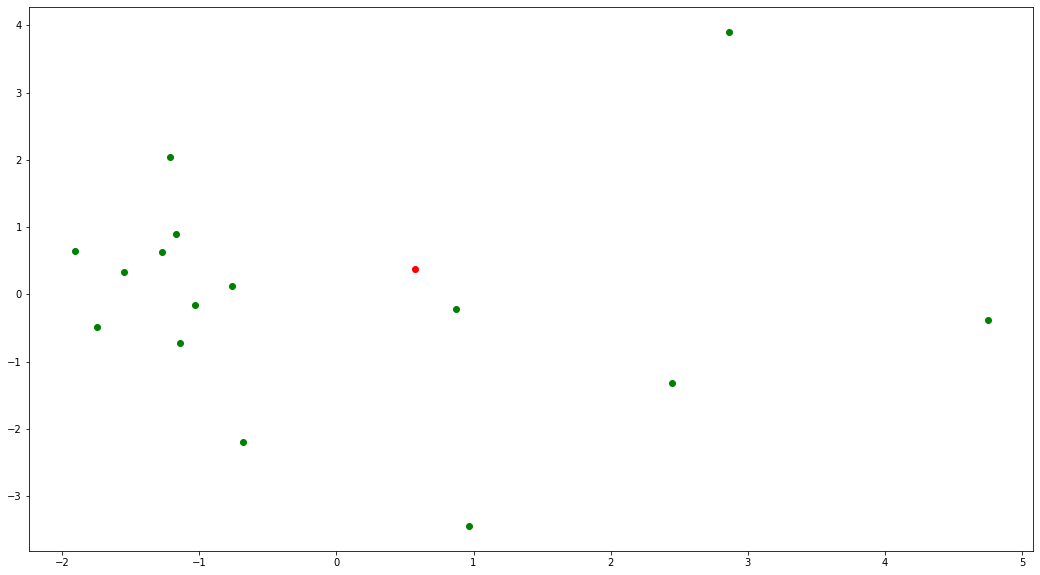

71 deu_an_2


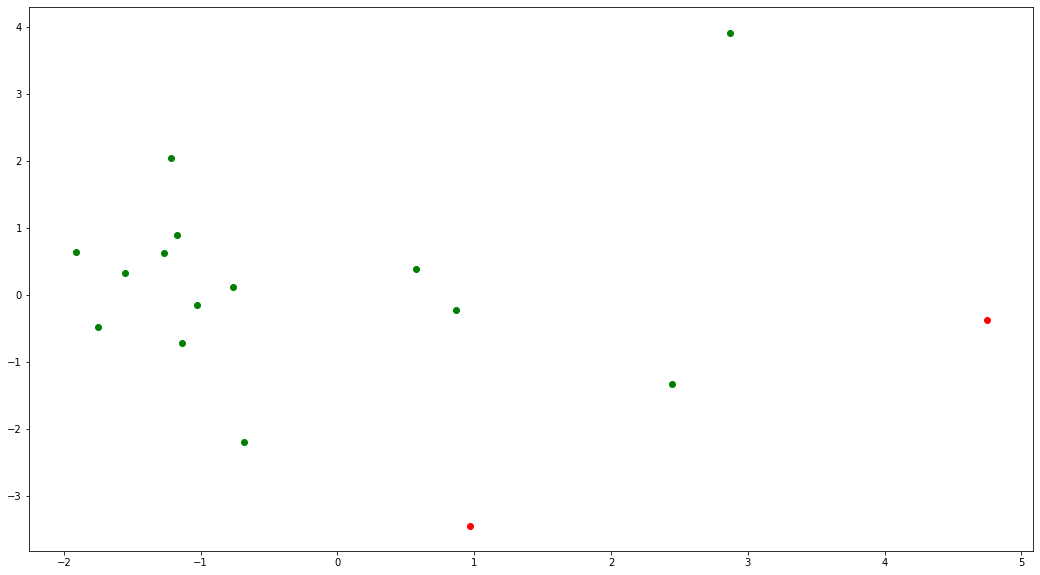

72 deu_nach_0


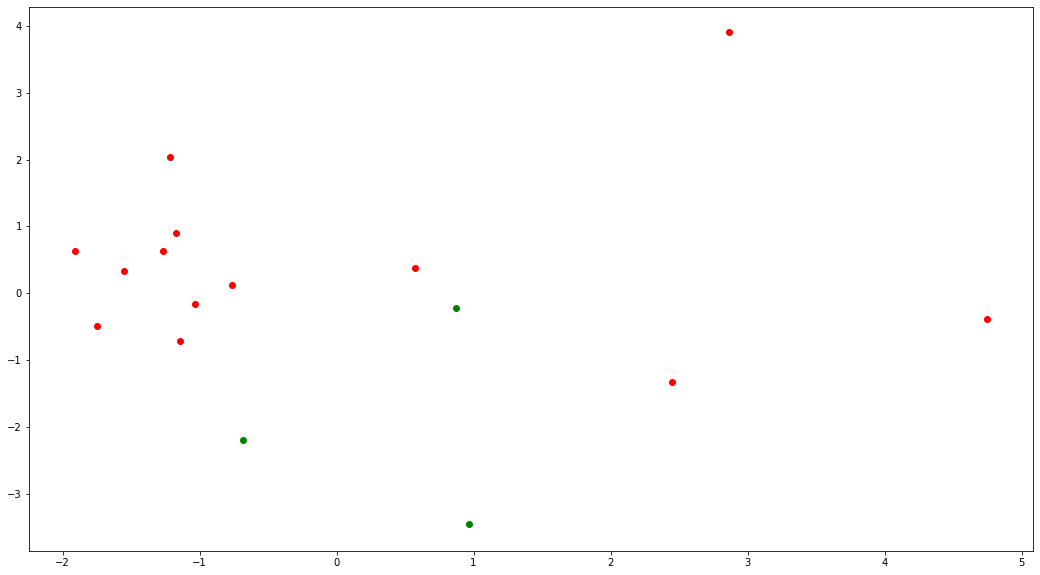

73 deu_nach_1


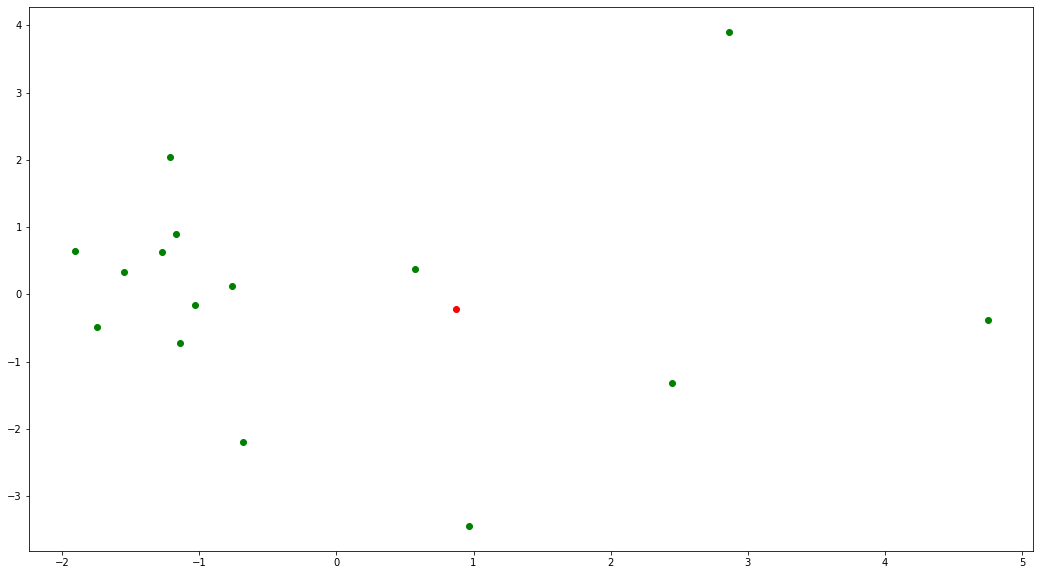

74 deu_nach_2


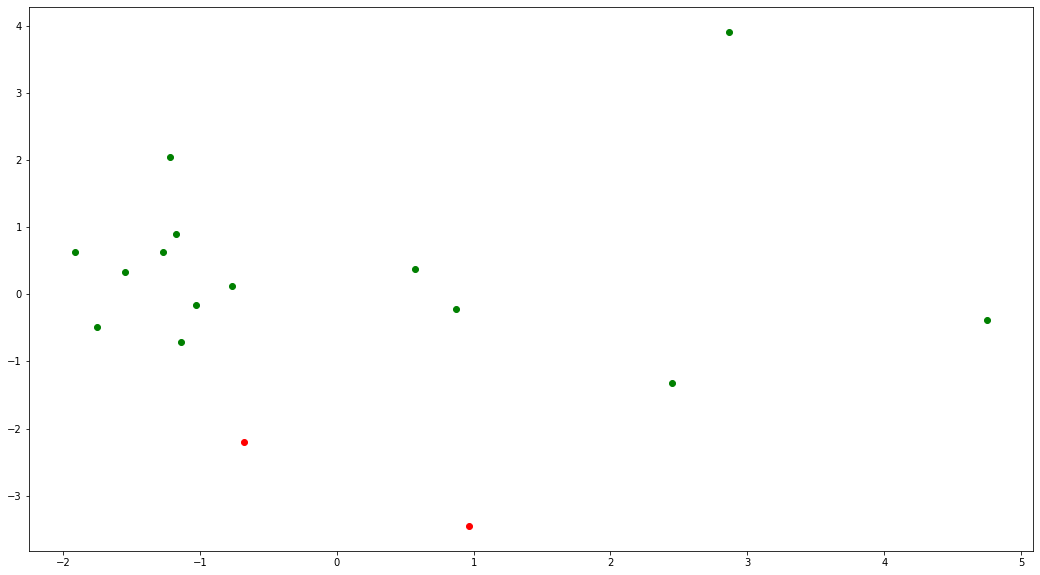

75 deu_zero_0


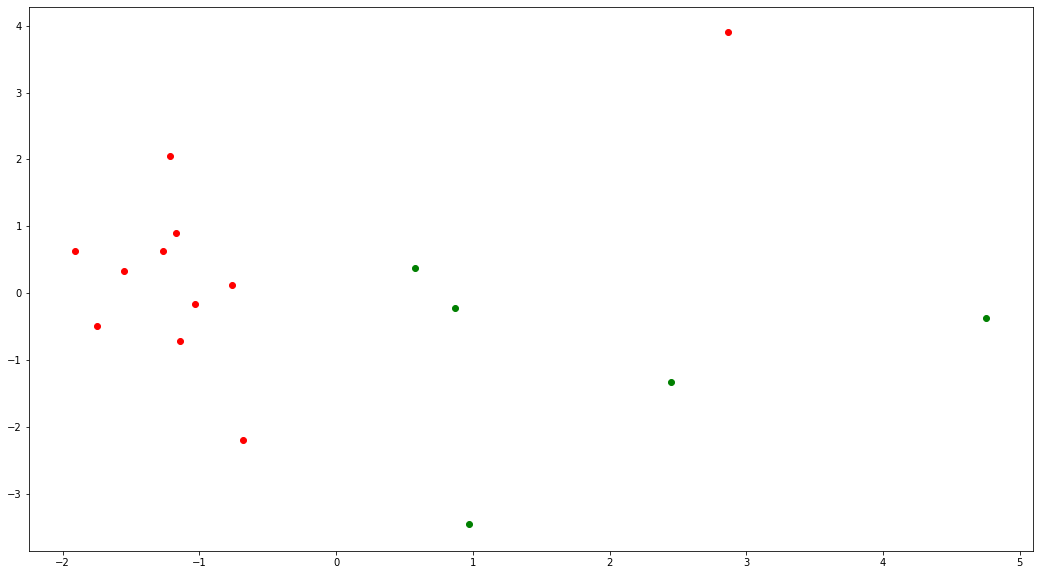

76 deu_zero_3


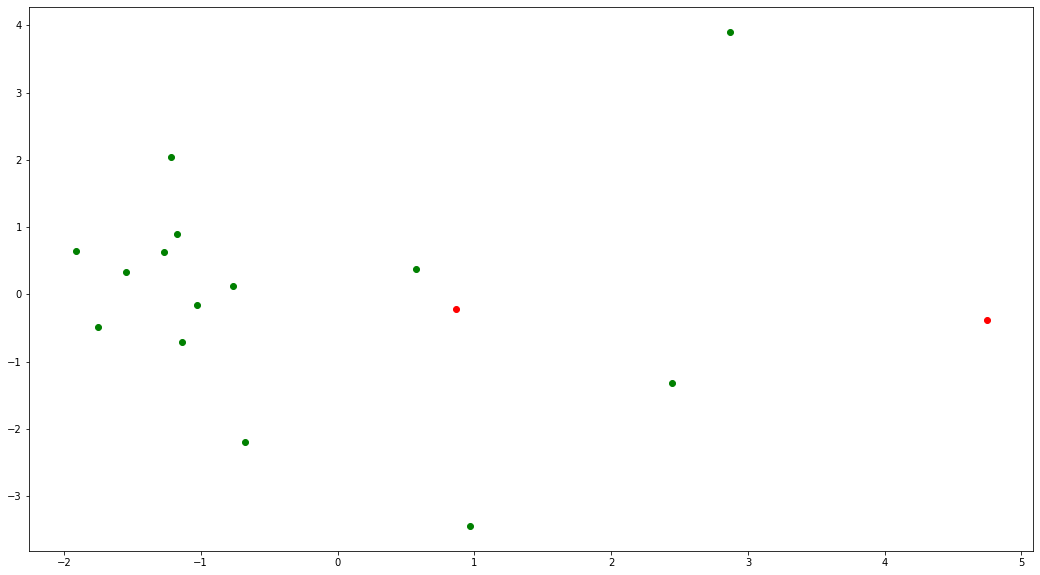

77 deu_zero_2


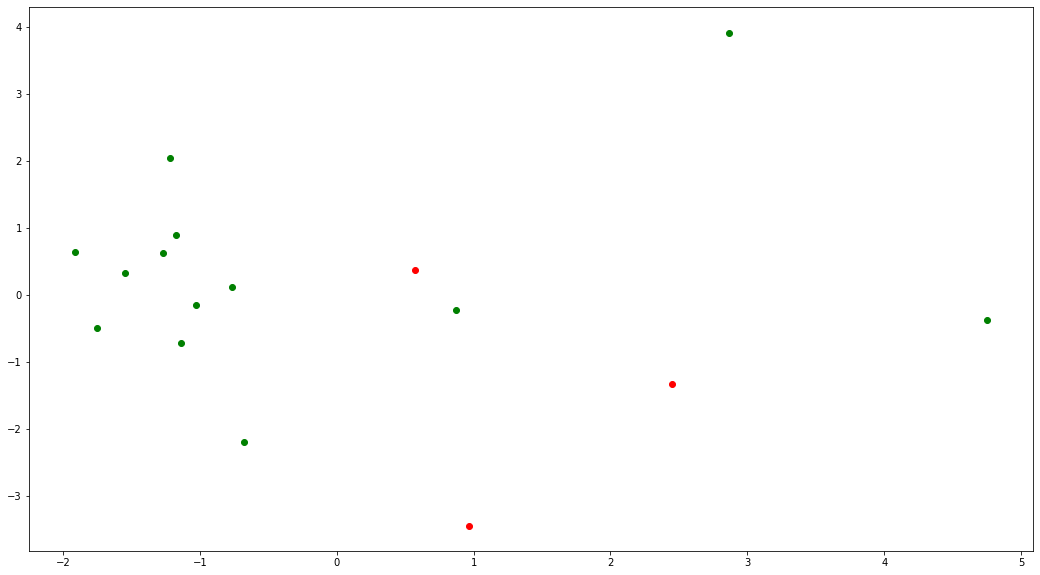

78 deu_other_0


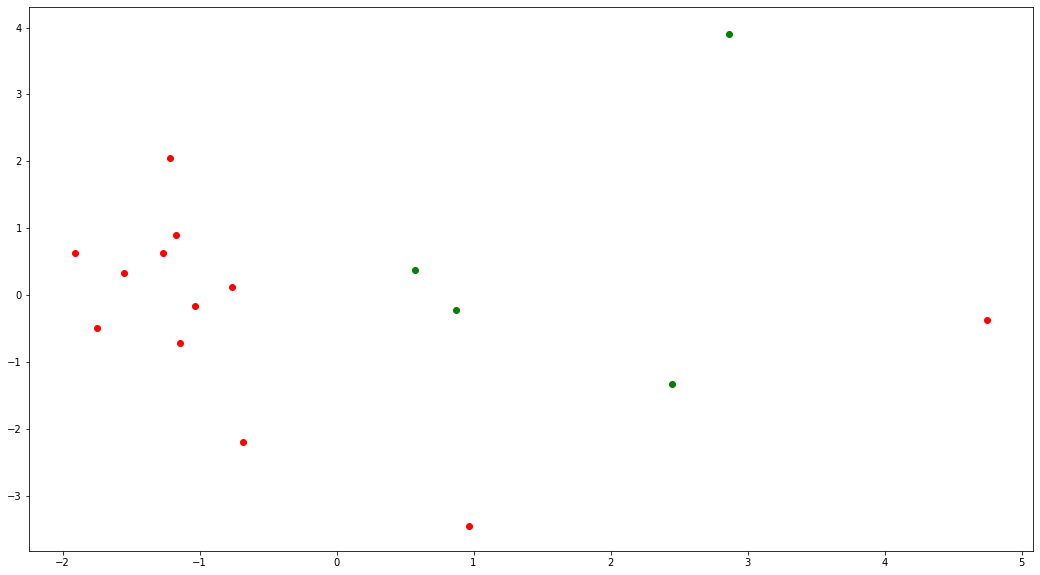

79 deu_other_1


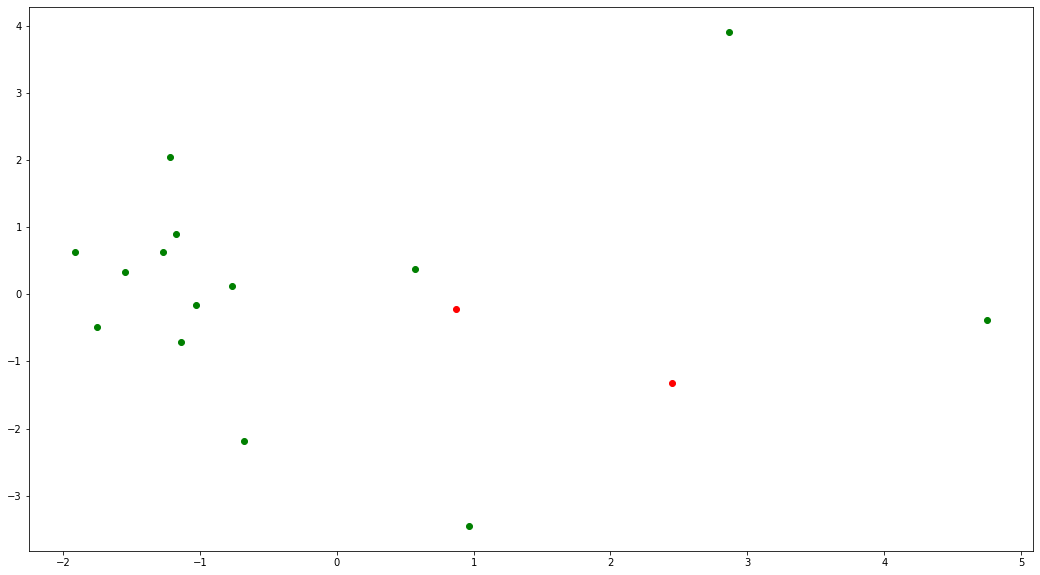

80 deu_other_2


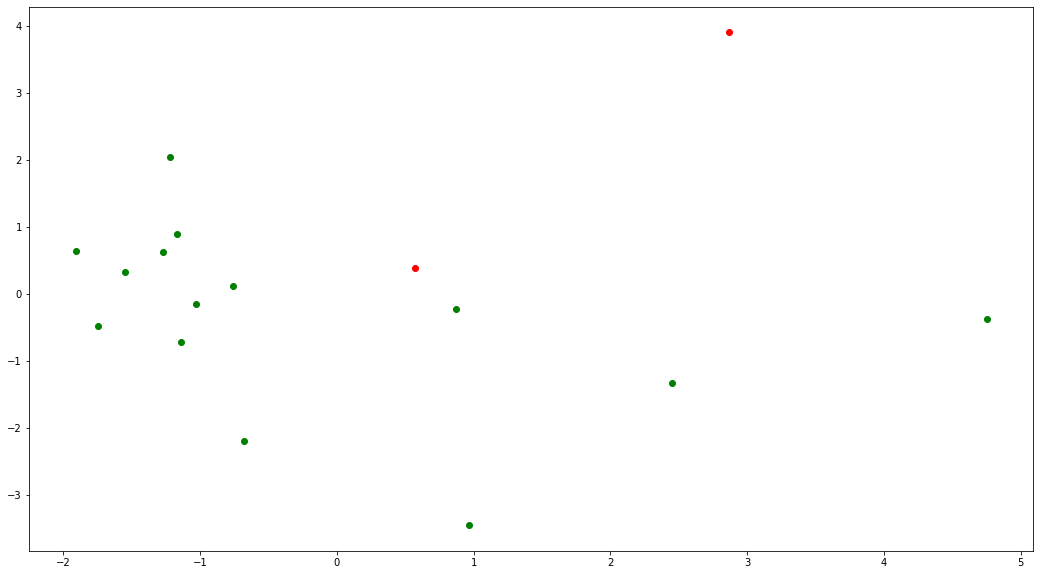

81 pol_w_7


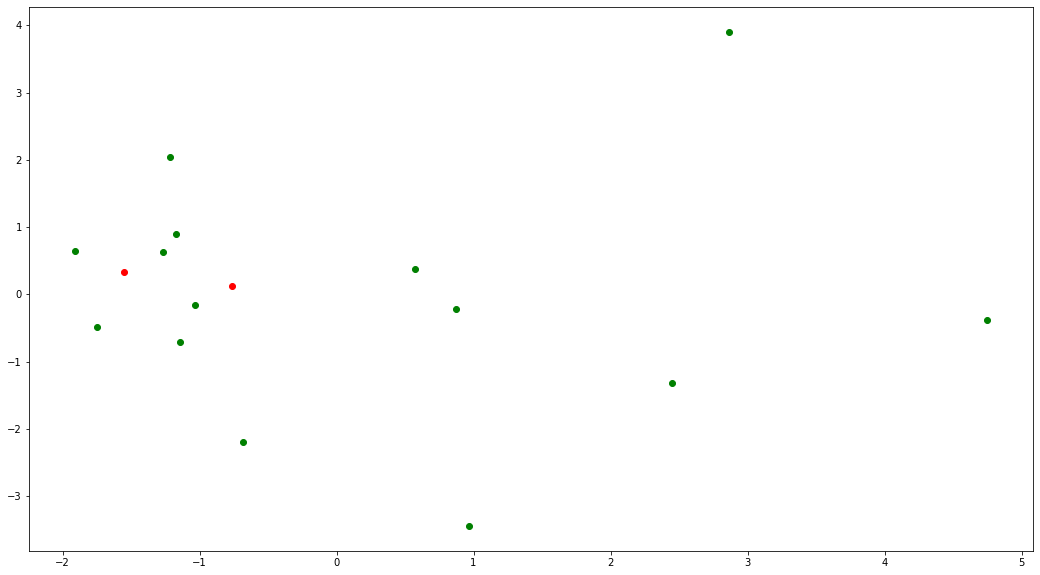

82 pol_w_1


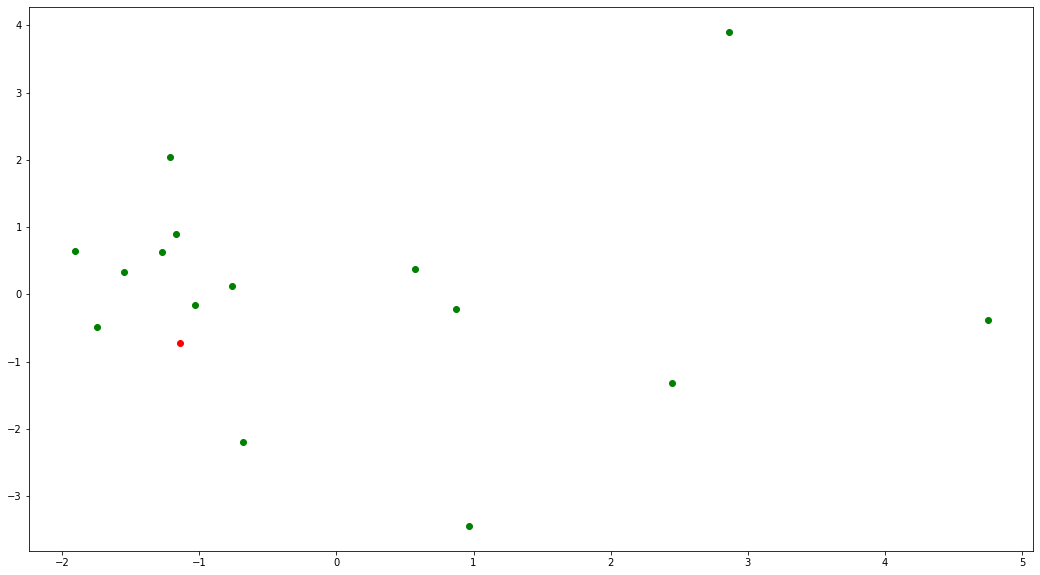

83 pol_w_0


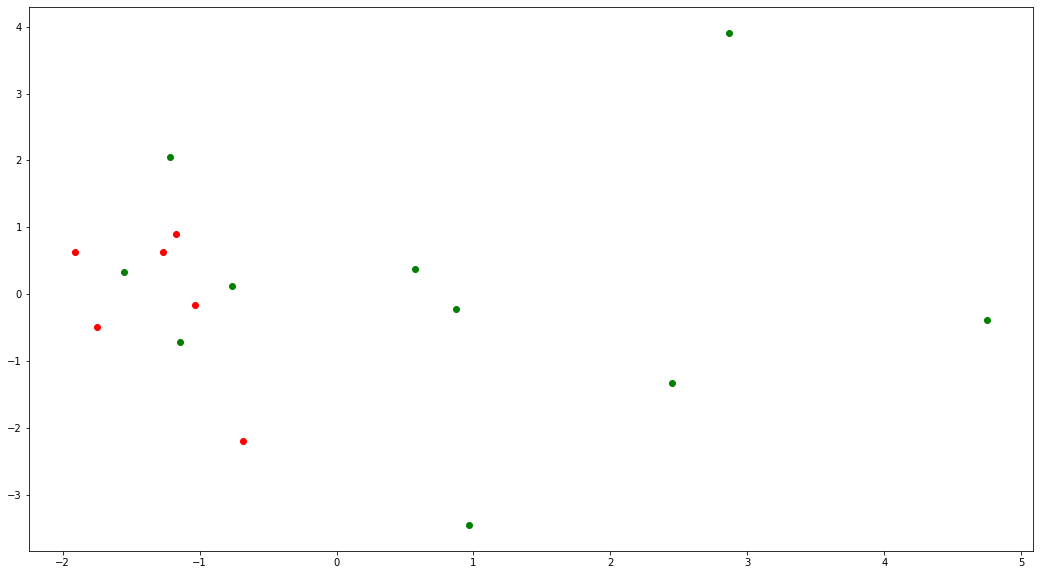

84 pol_w_3


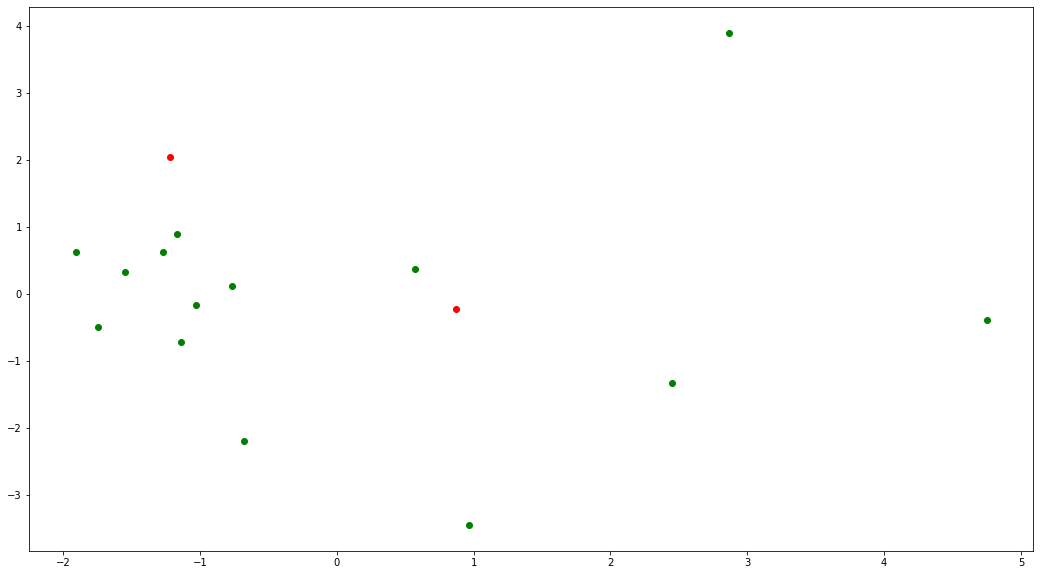

85 pol_w_2


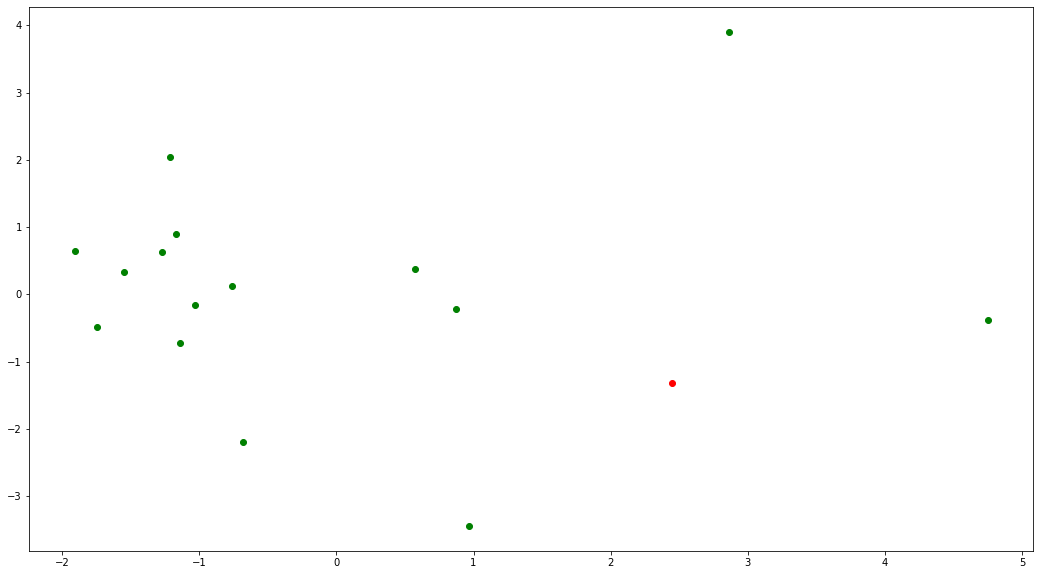

86 pol_w_20


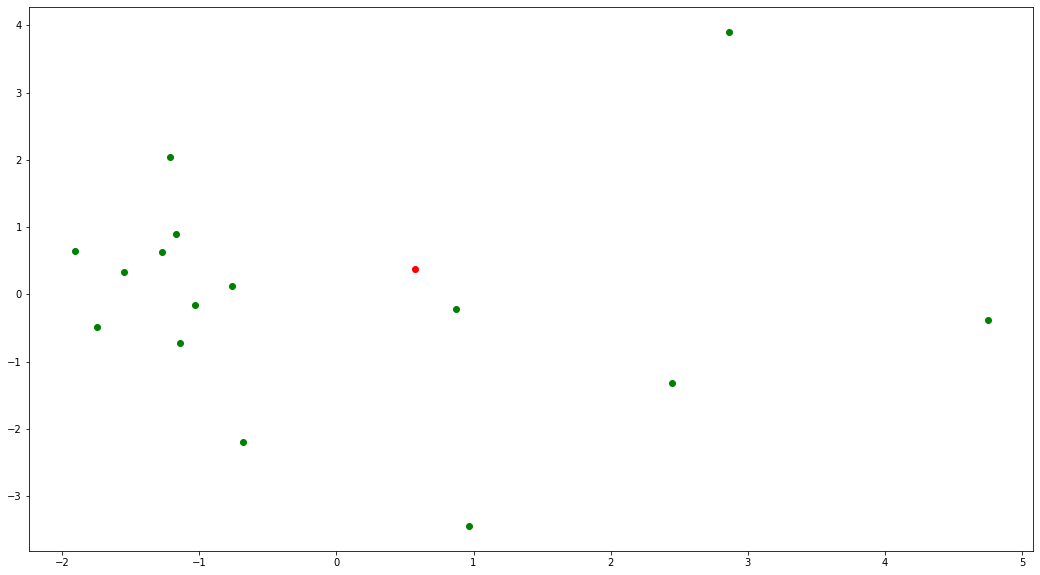

87 pol_w_14


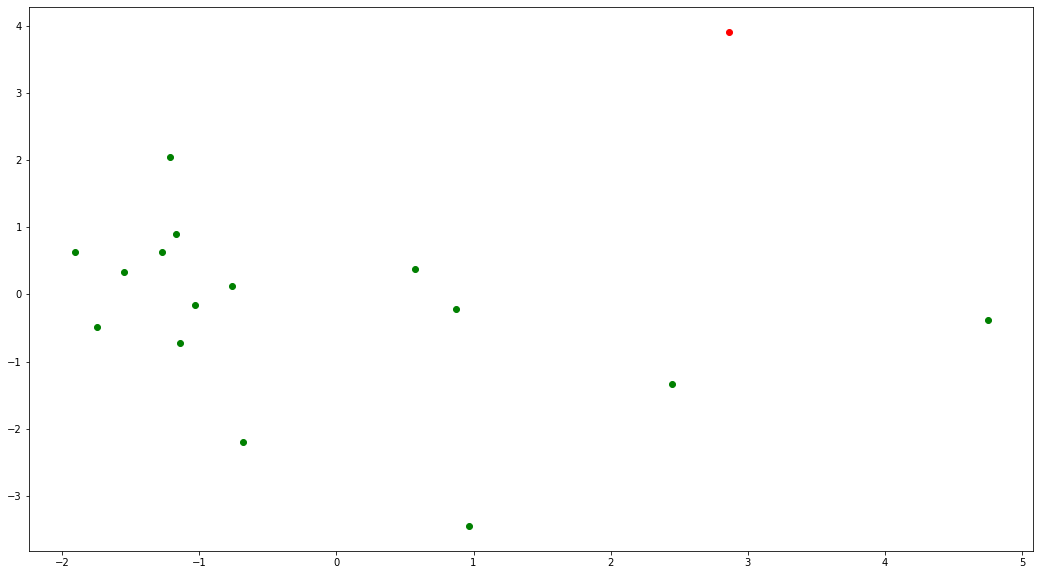

88 pol_w_19


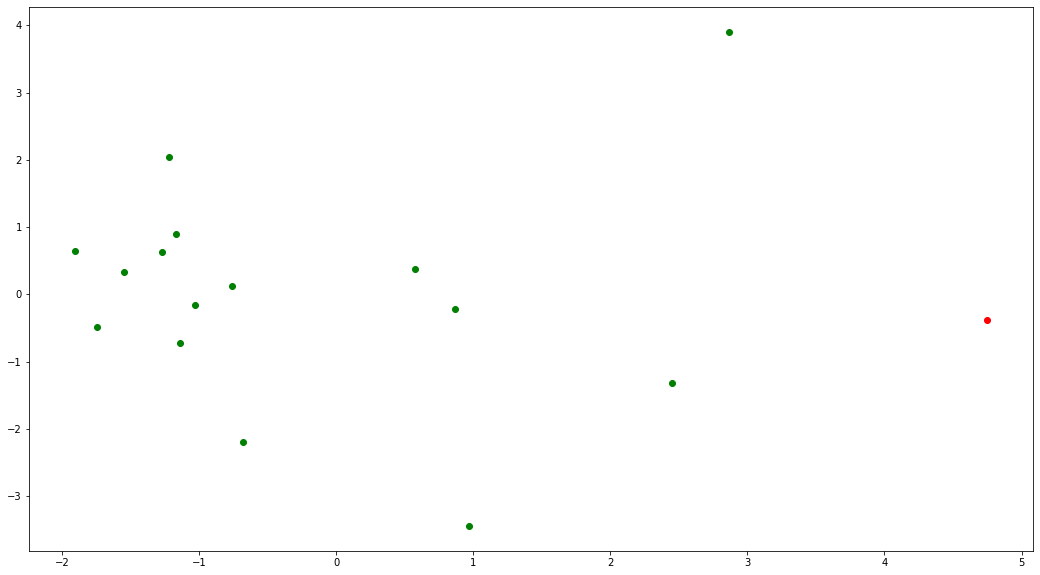

89 pol_w_6


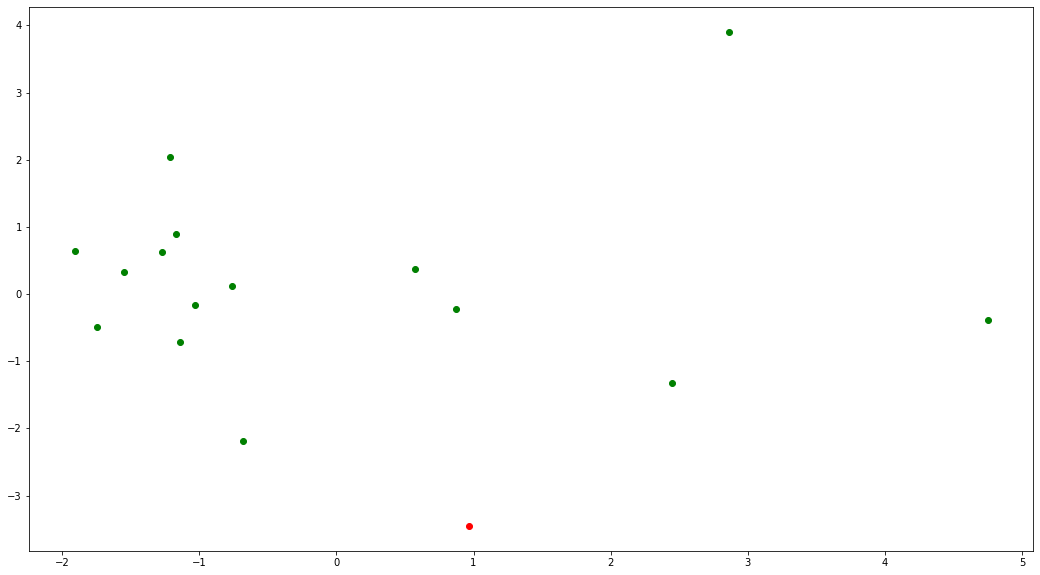

90 pol_na_5


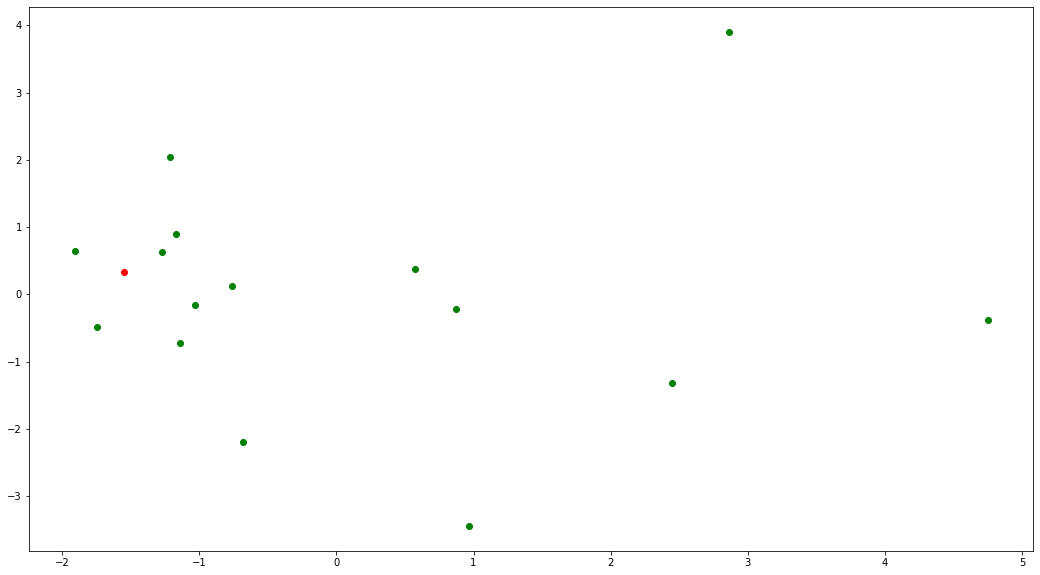

91 pol_na_0


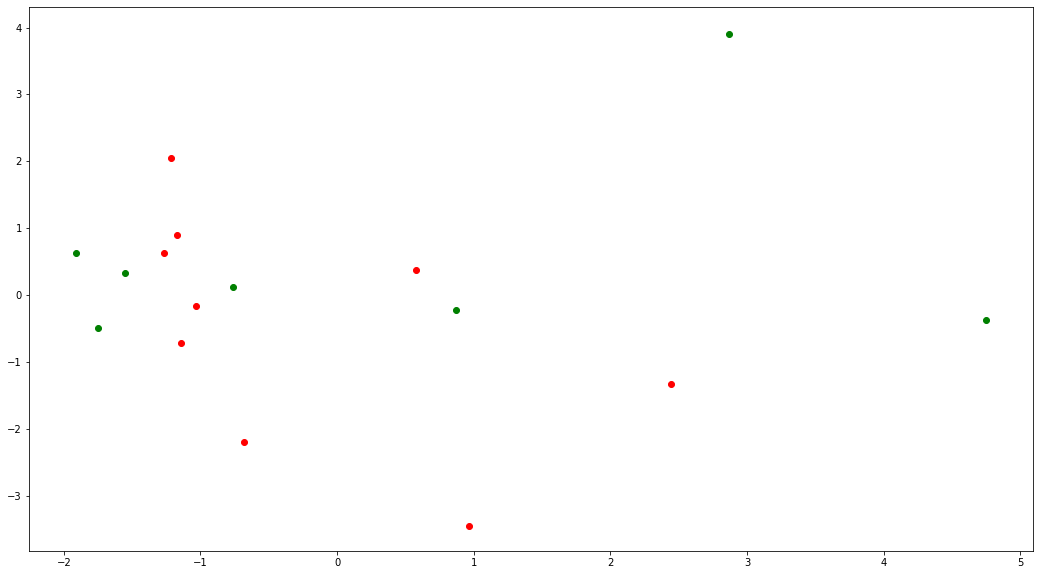

92 pol_na_1


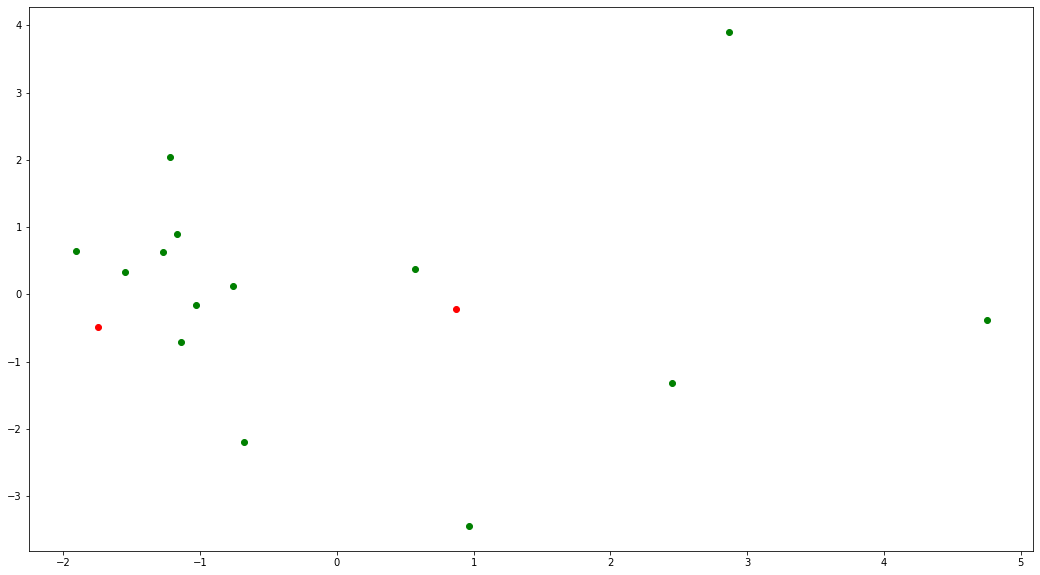

93 pol_na_2


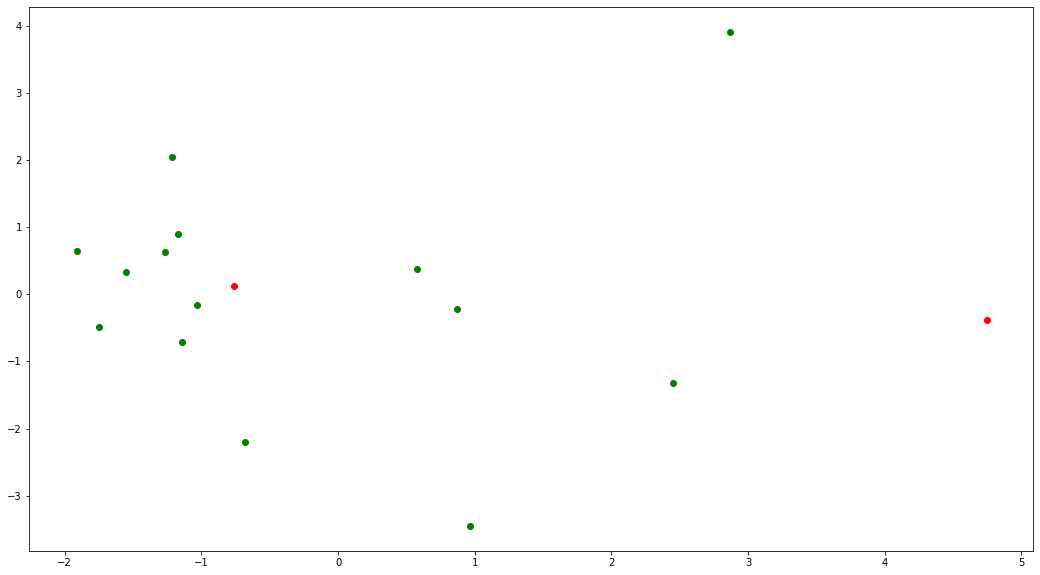

94 pol_na_6


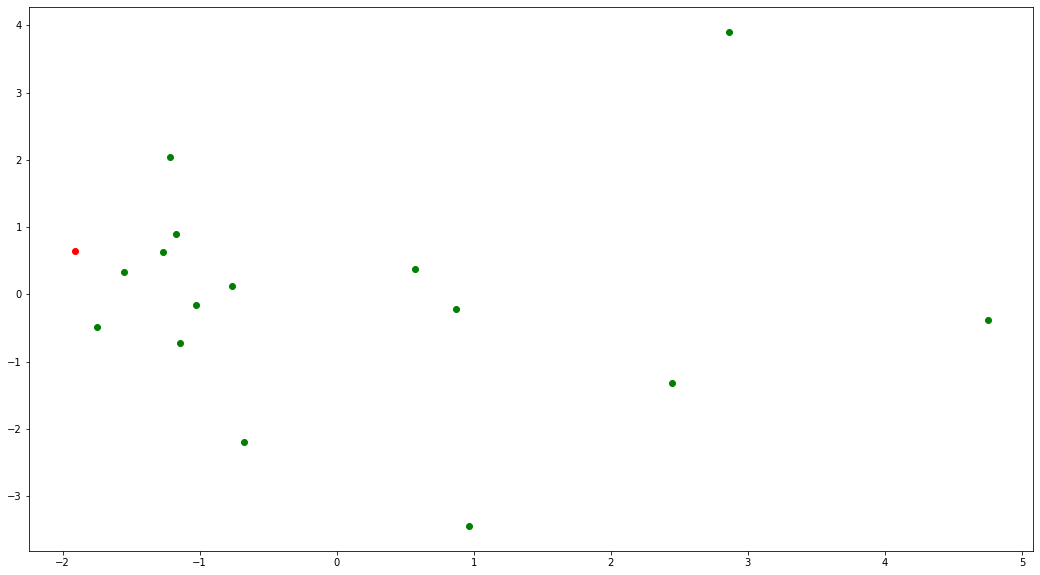

95 pol_na_3


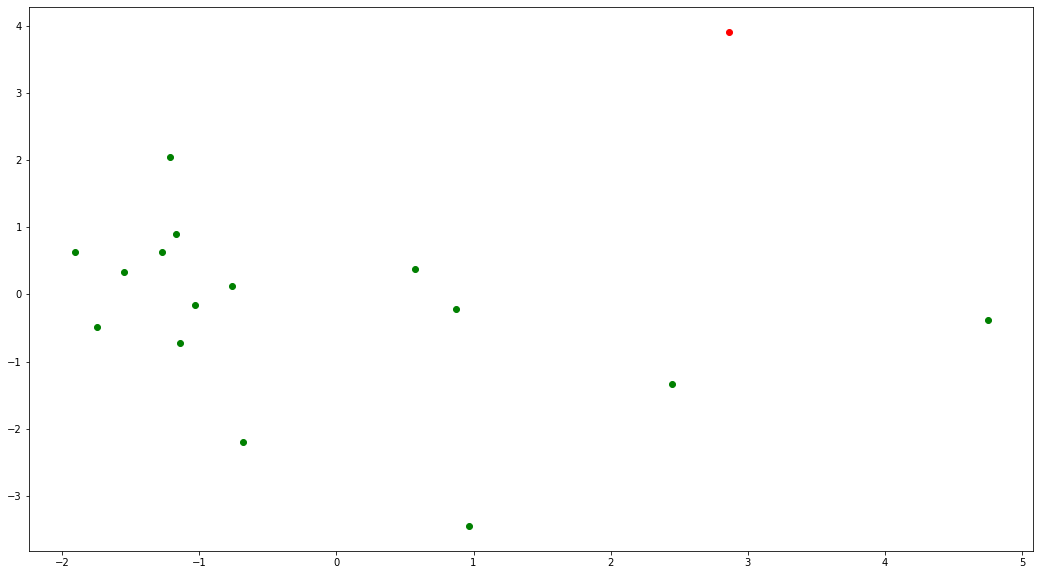

96 pol_z_0


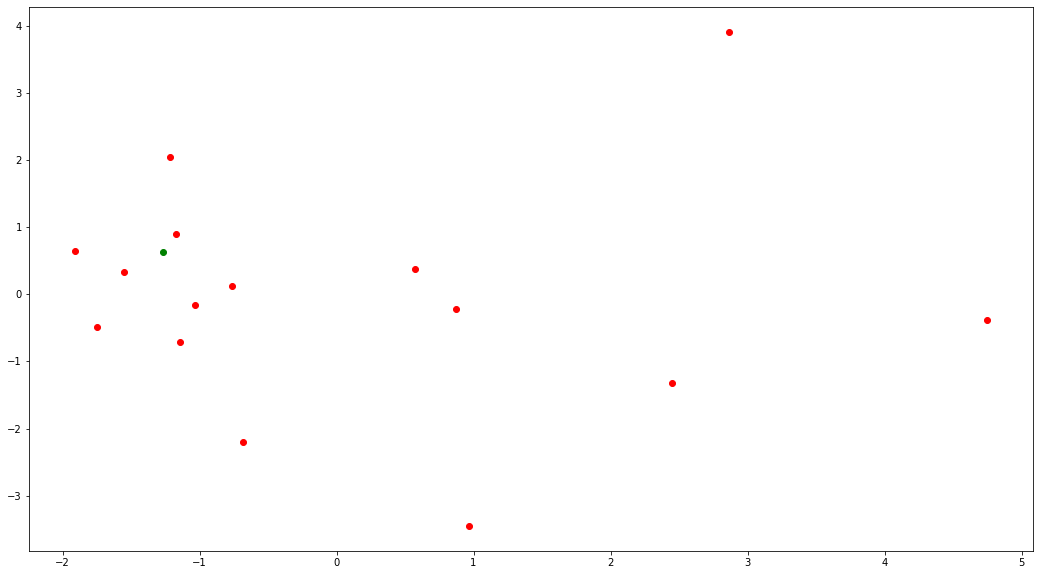

97 pol_z_2


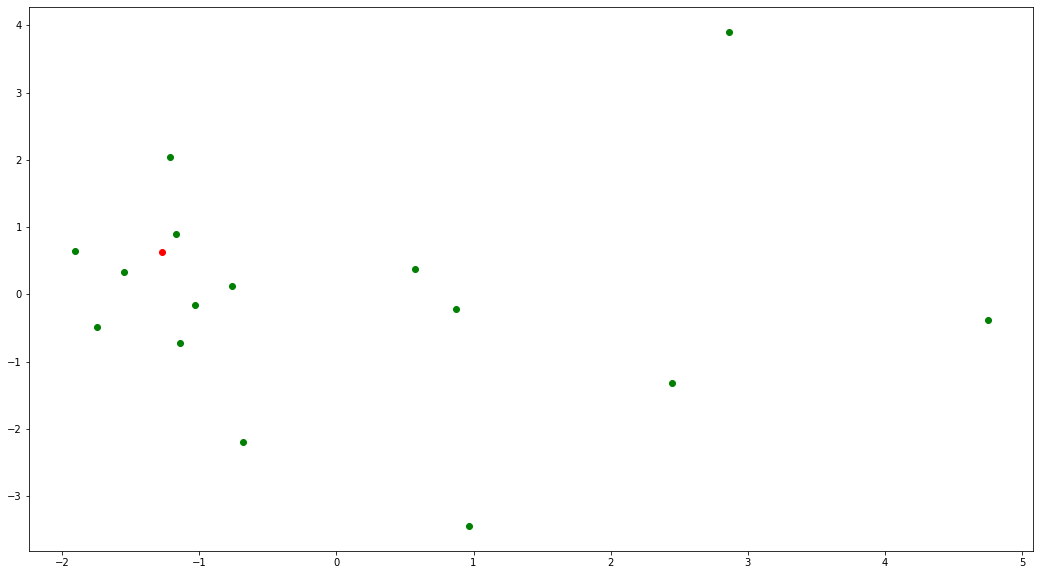

98 pol_u_0


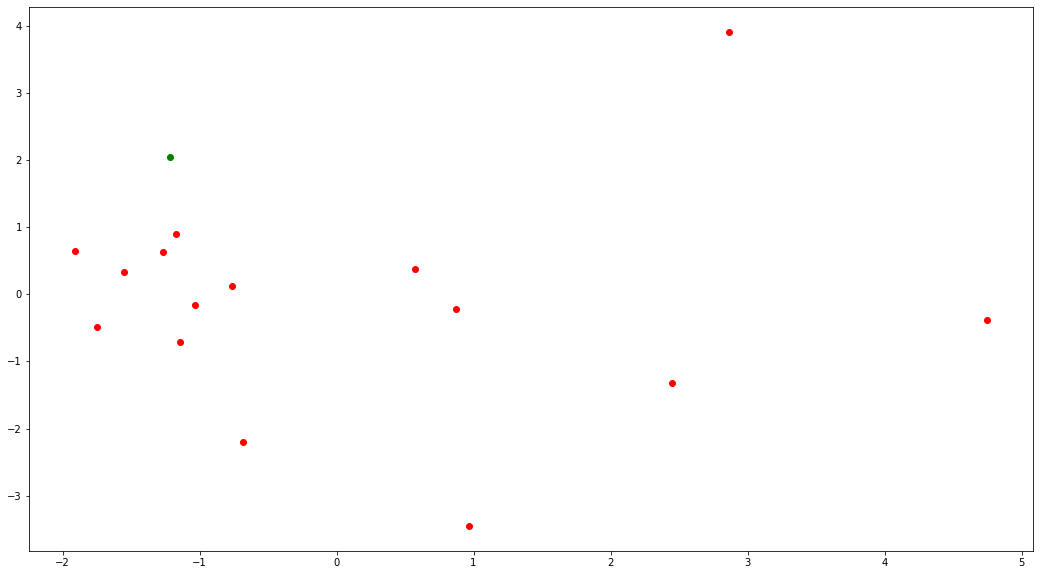

99 pol_u_1


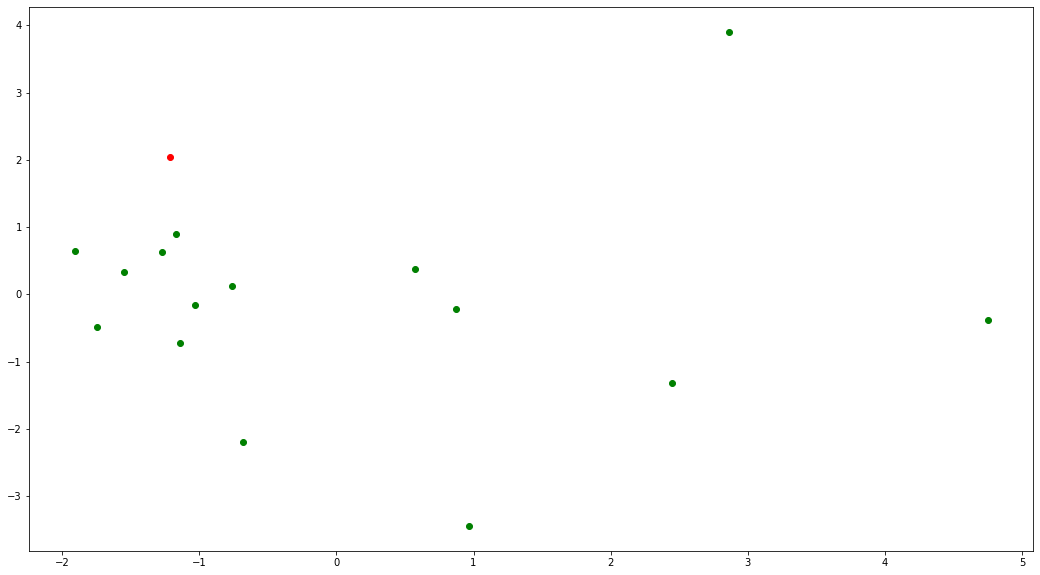

100 pol_przy_0


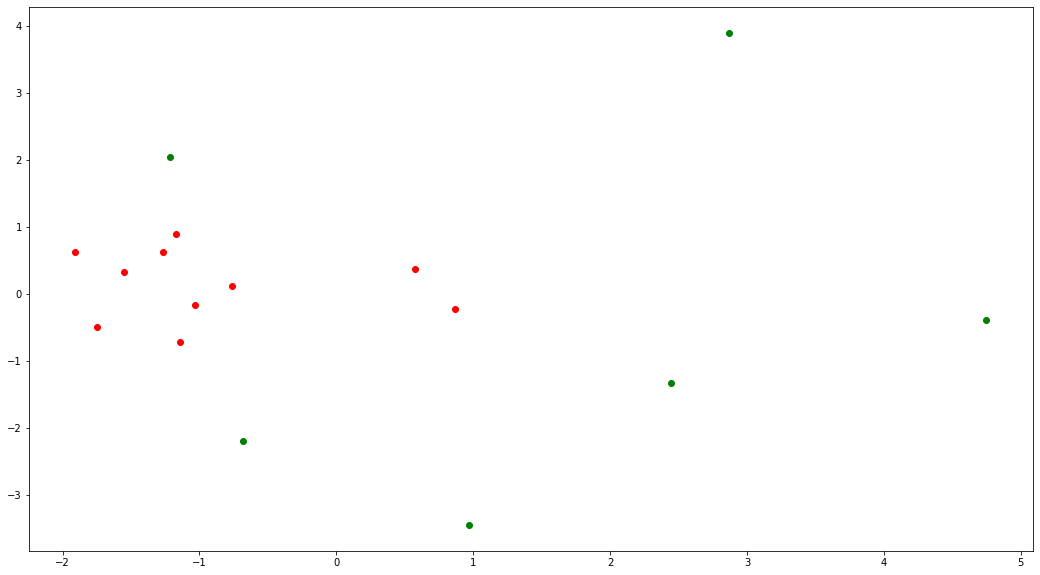

101 pol_przy_2


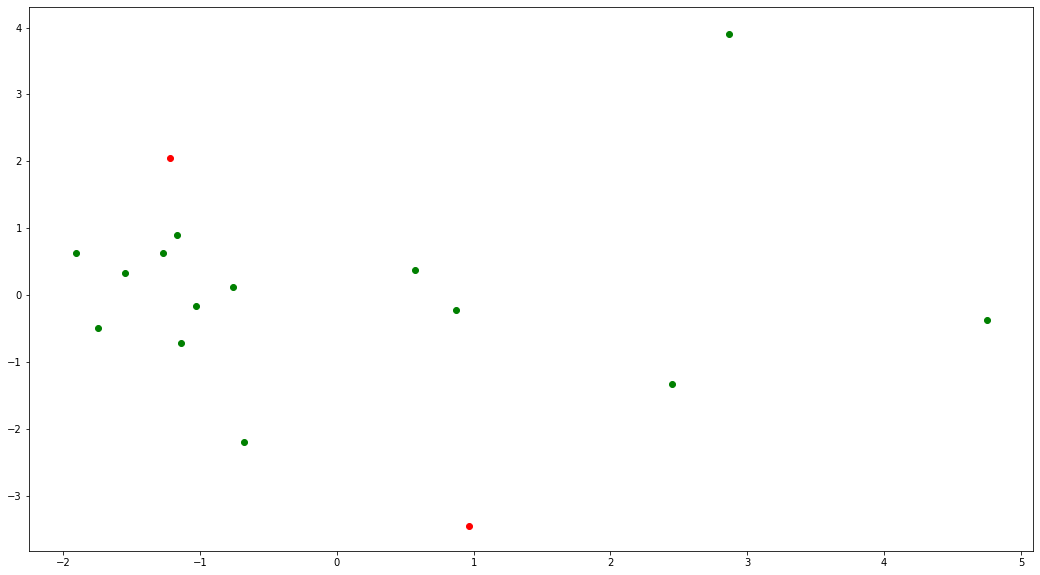

102 pol_przy_1


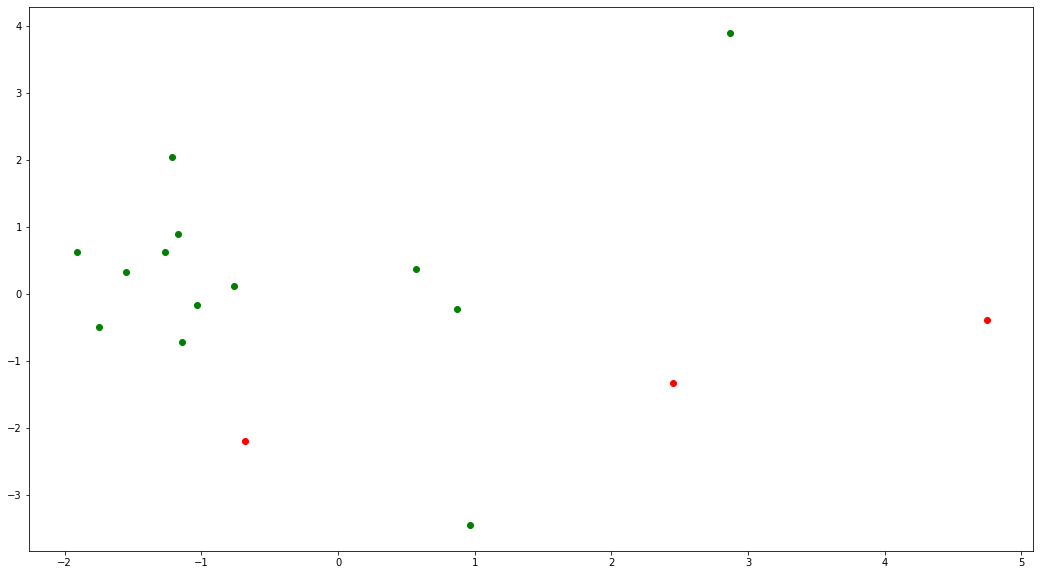

103 pol_przy_5


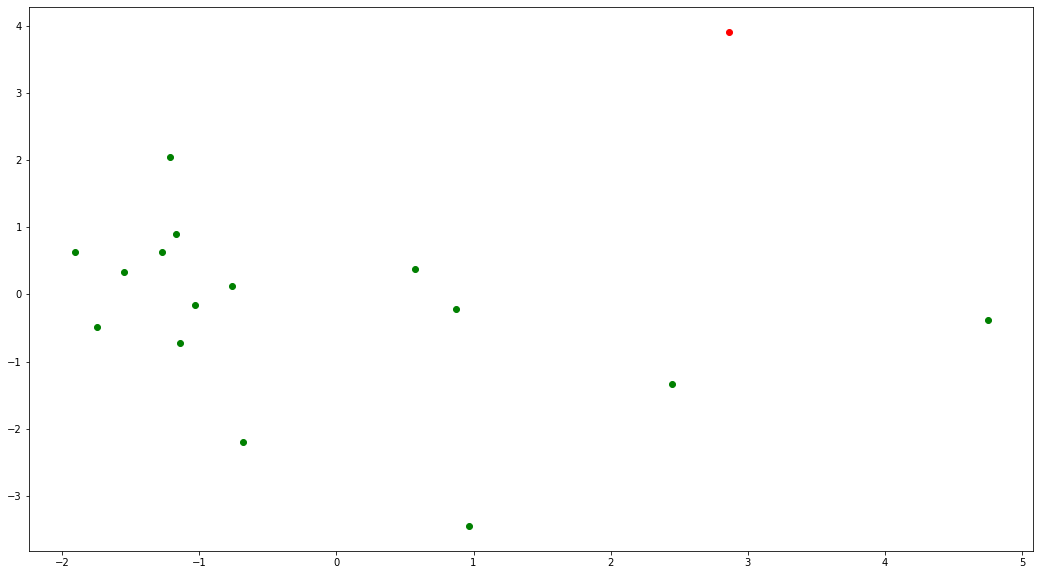

104 pol_podczas_0


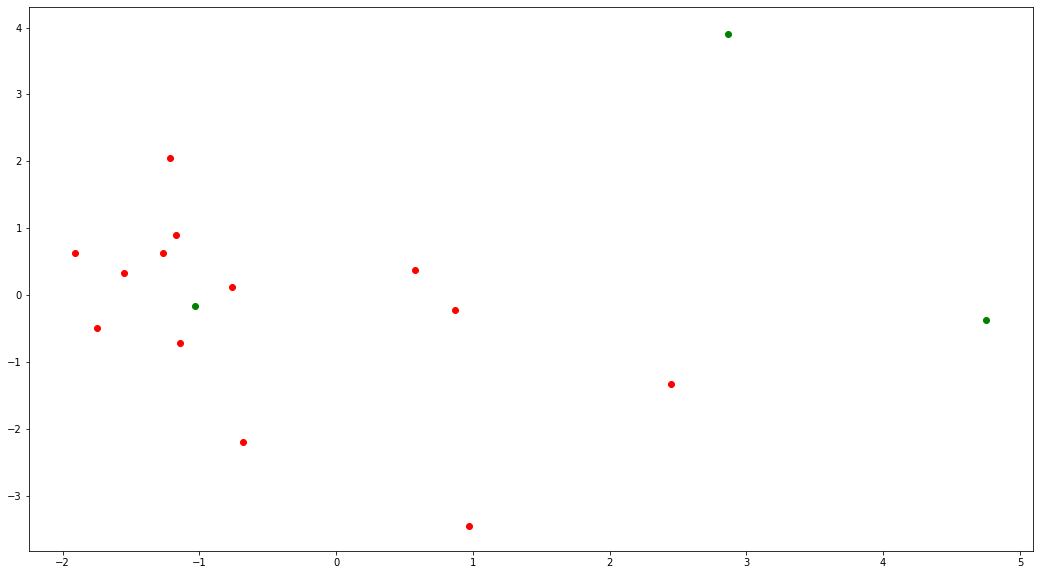

105 pol_podczas_2


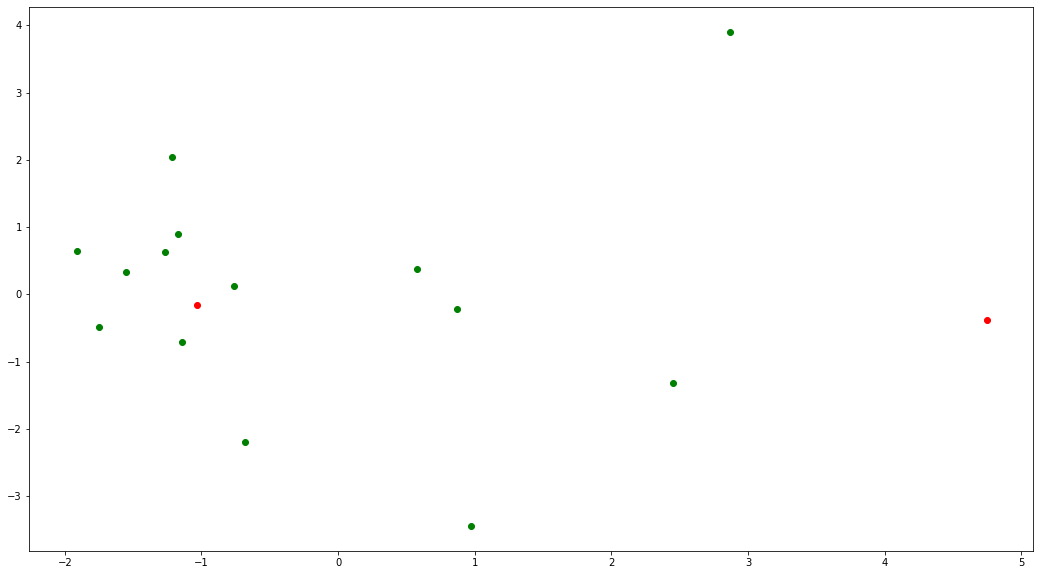

106 pol_podczas_1


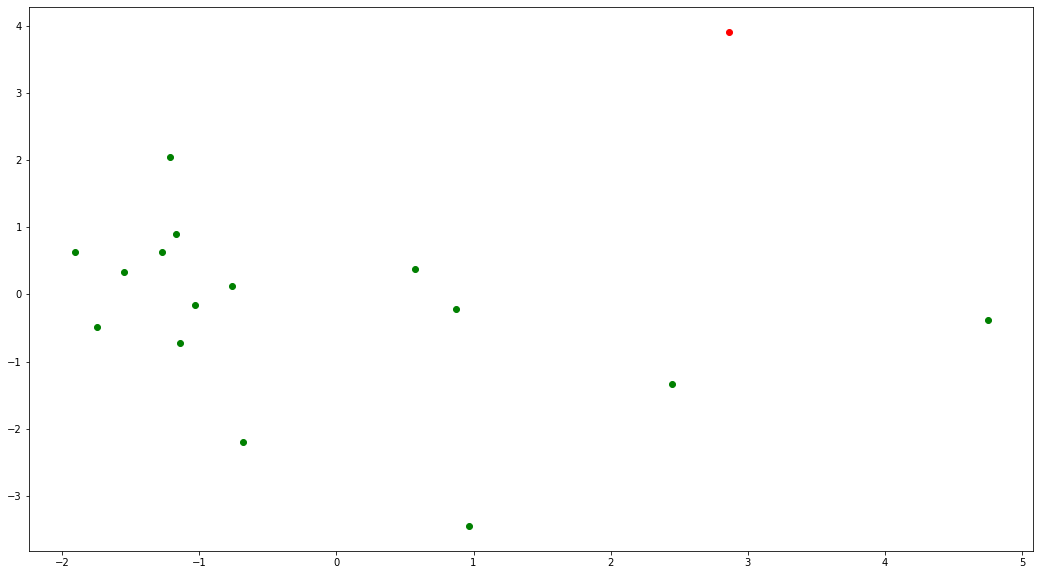

107 pol_zaś_0


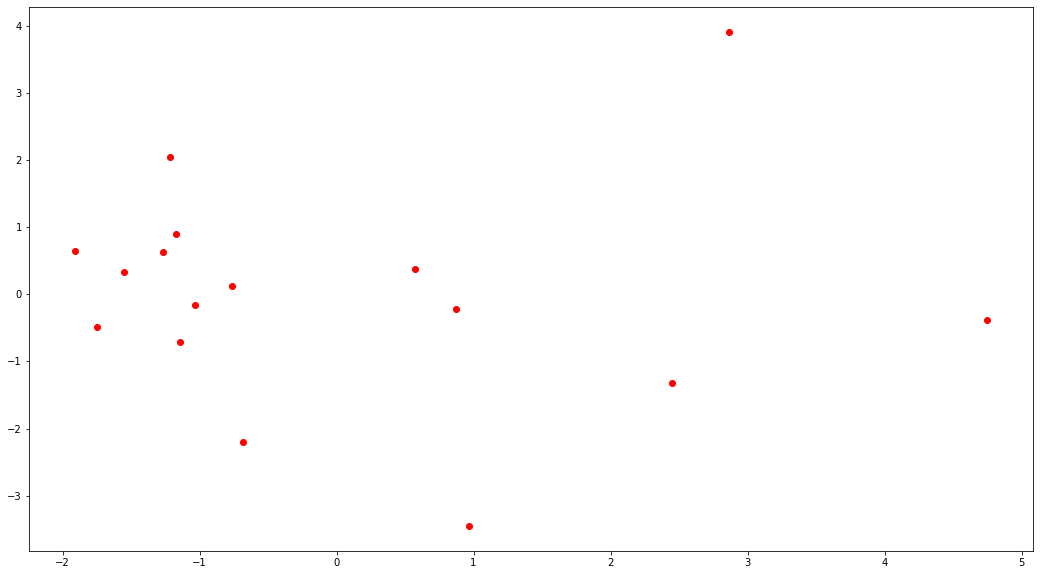

108 pol_zero_0


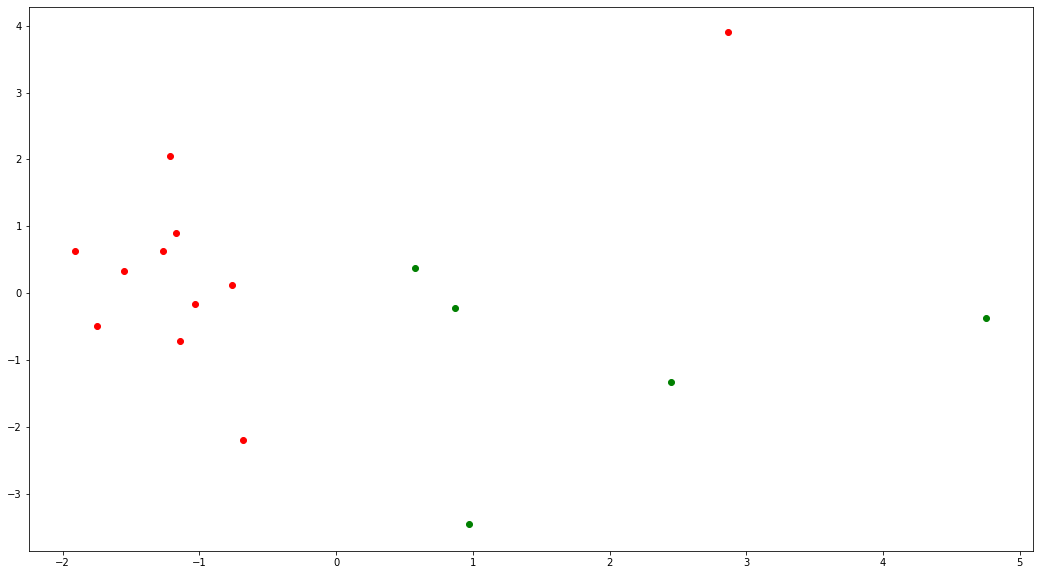

109 pol_zero_2


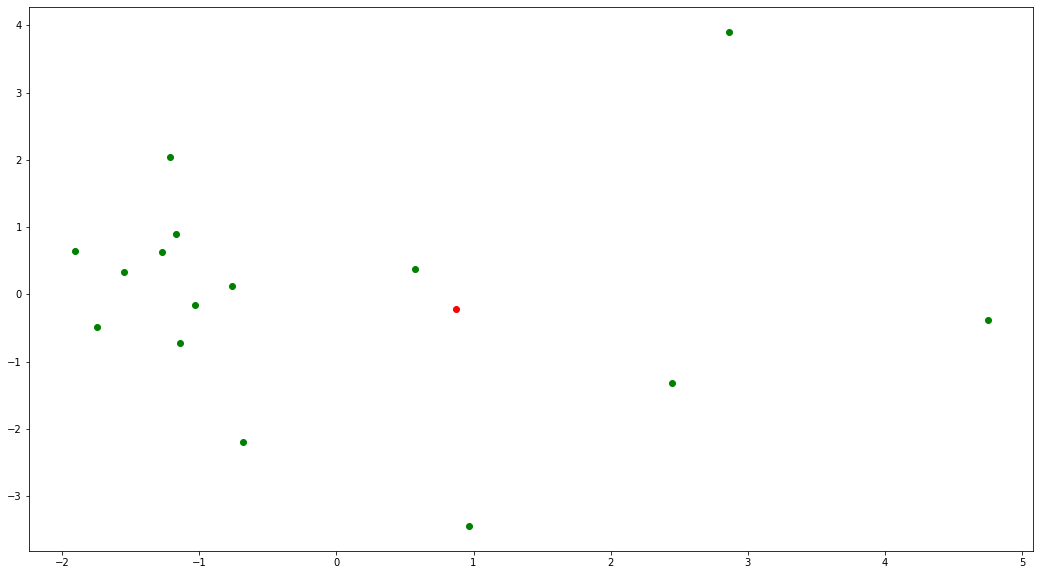

110 pol_zero_8


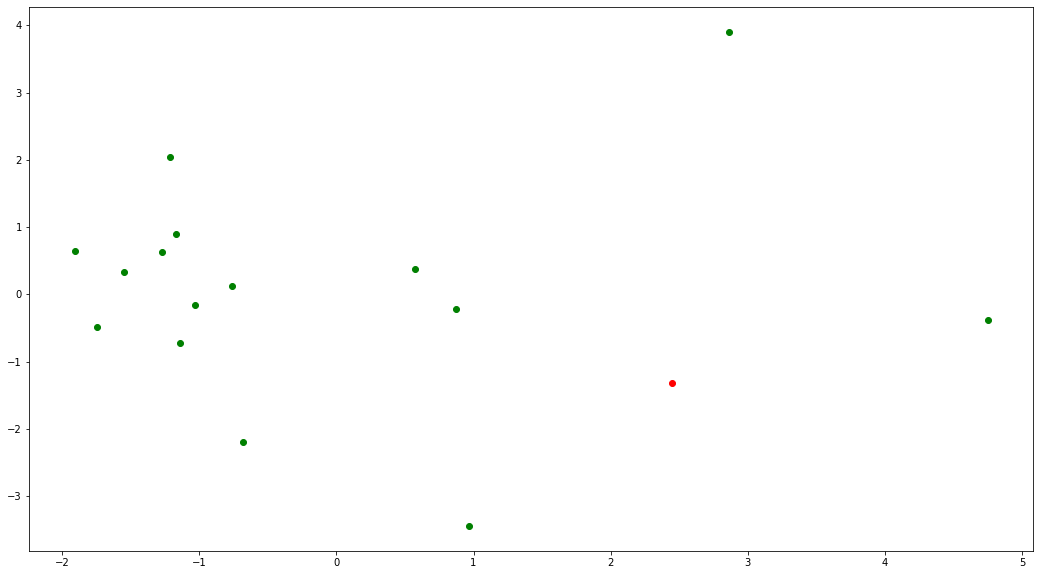

111 pol_zero_3


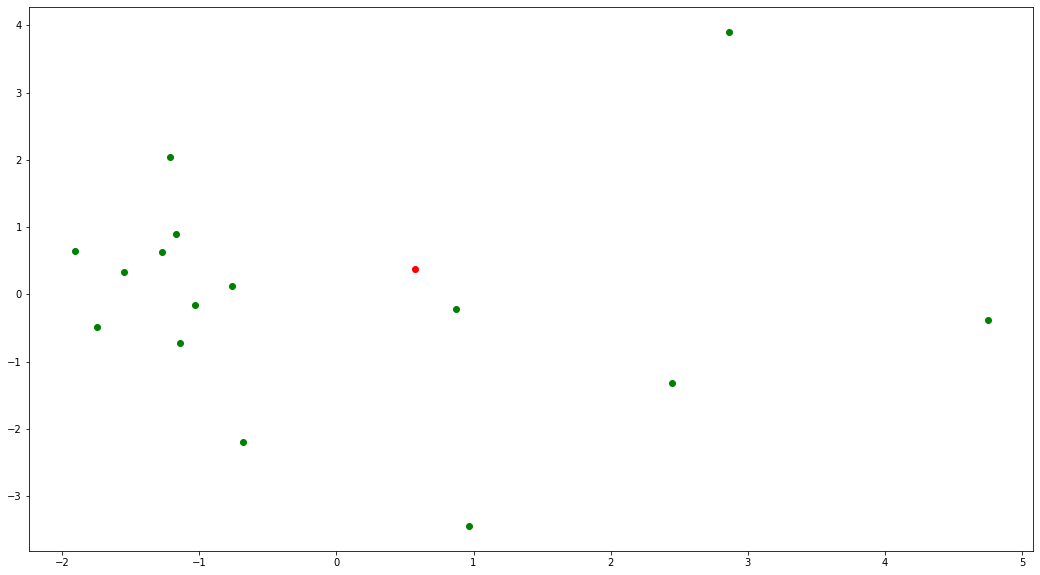

112 pol_zero_1


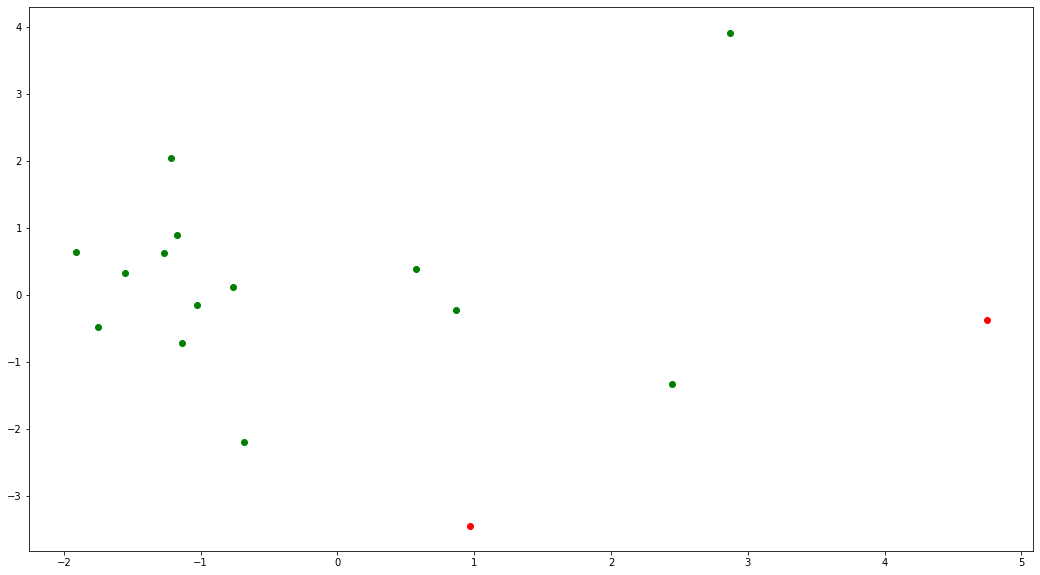

113 pol_other_0


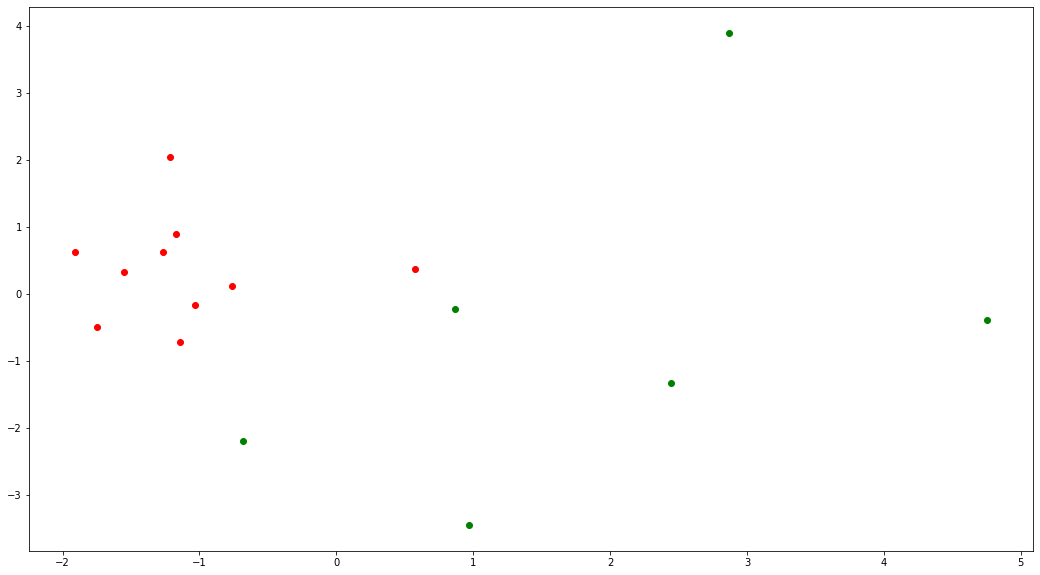

114 pol_other_3


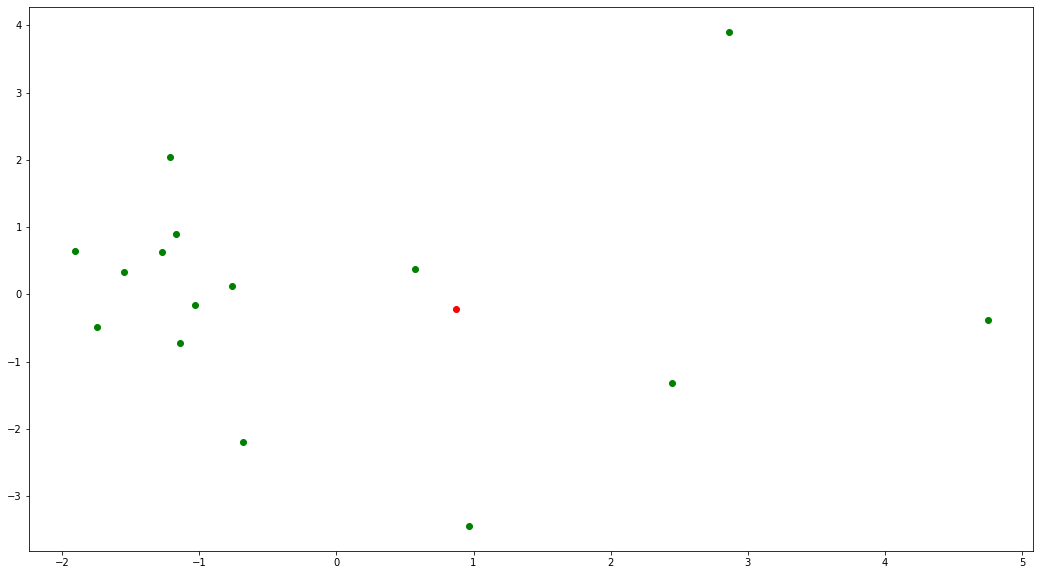

115 pol_other_1


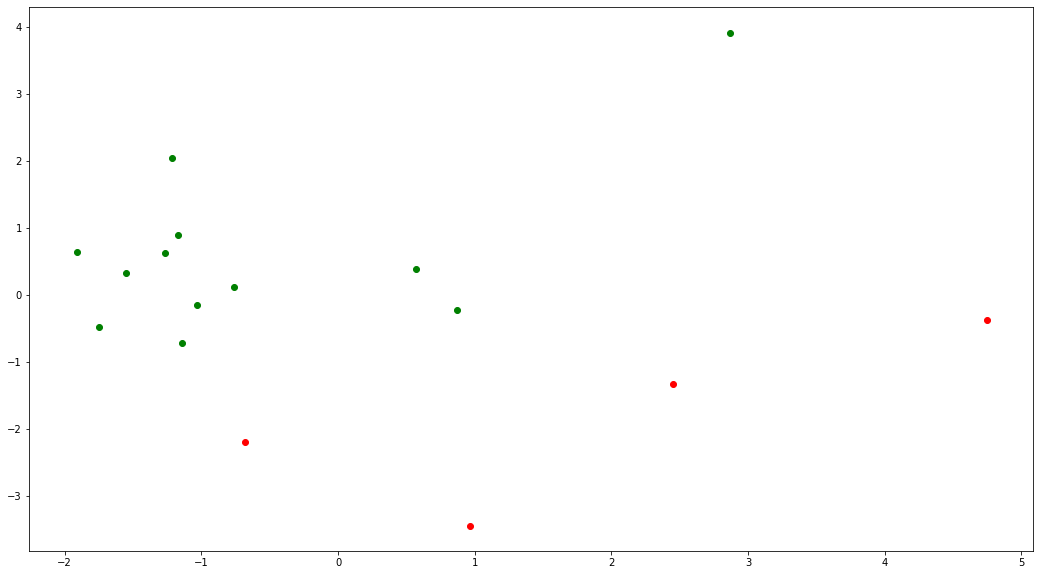

116 pol_other_2


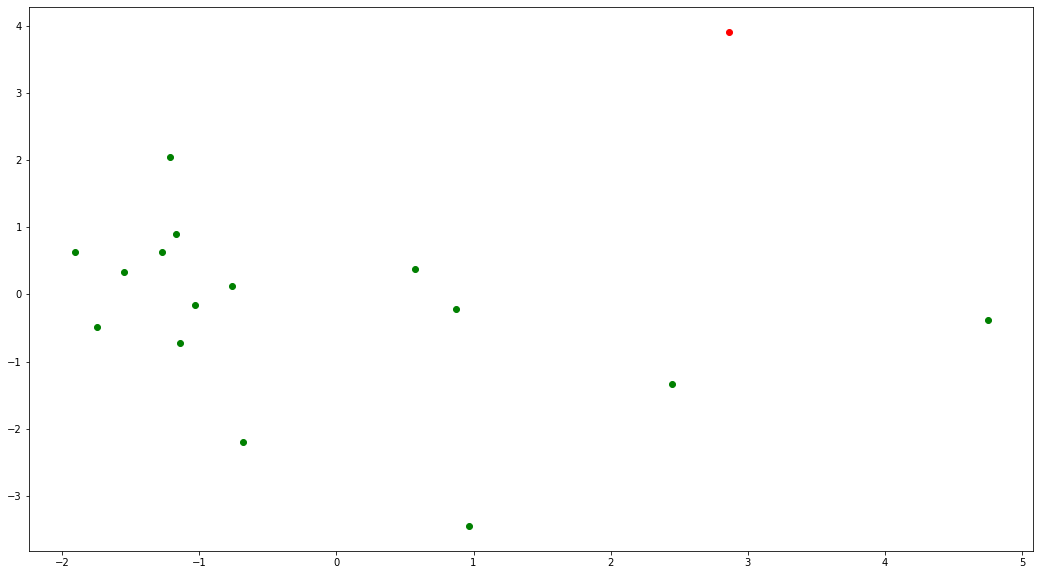

117 fra_en_1


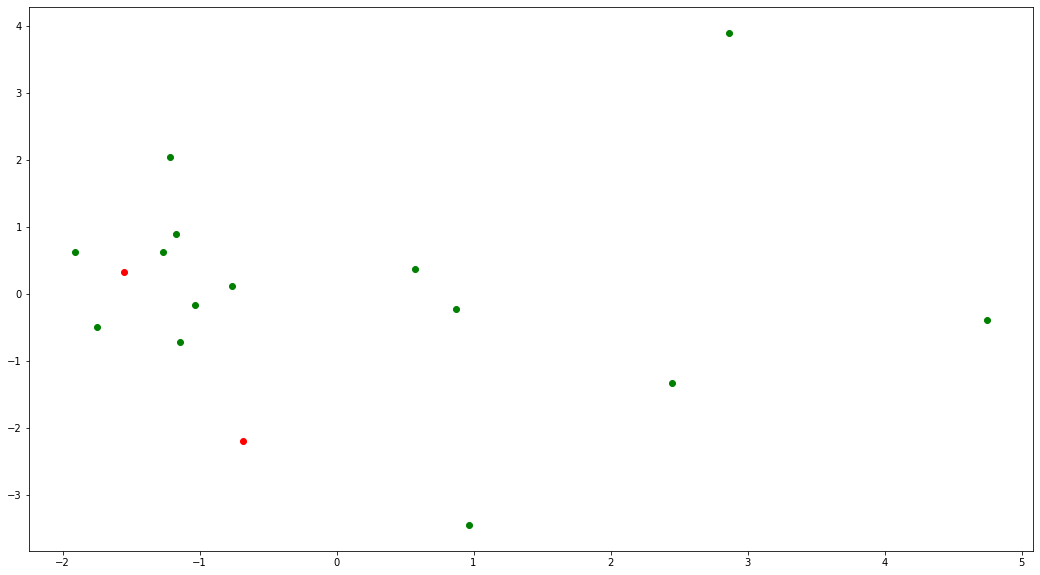

118 fra_en_0


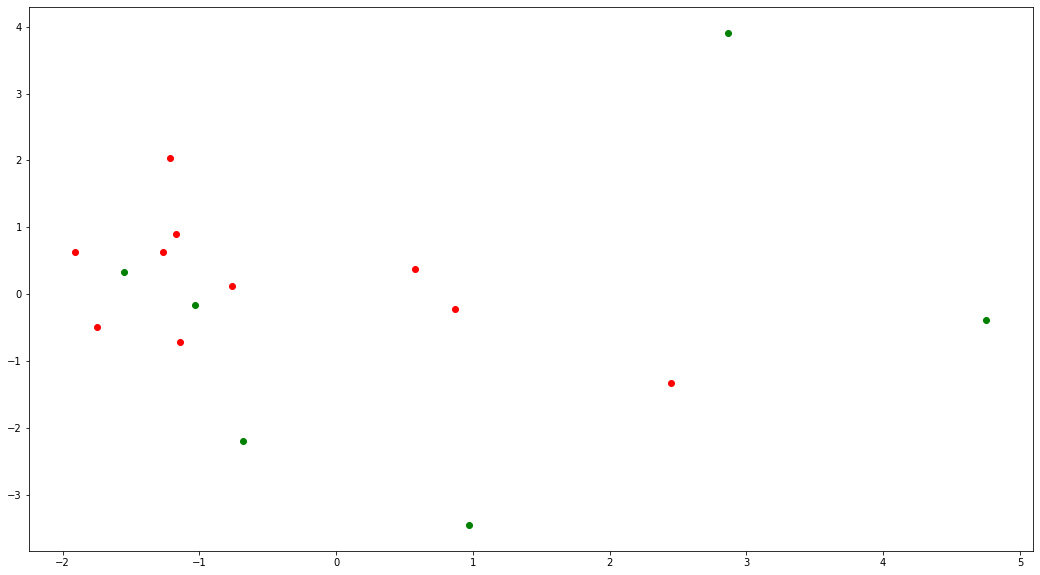

119 fra_en_2


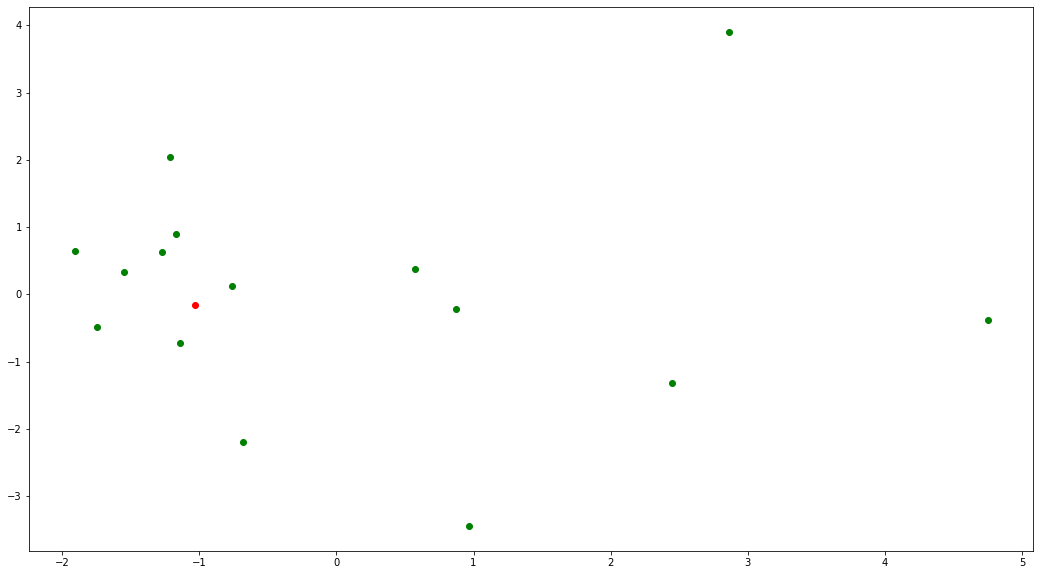

120 fra_en_8


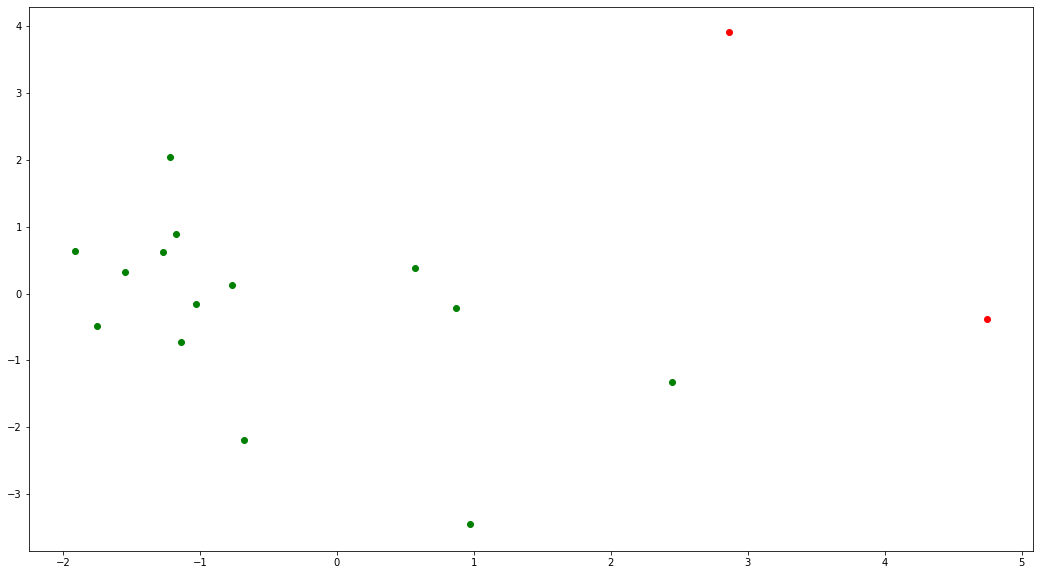

121 fra_en_7


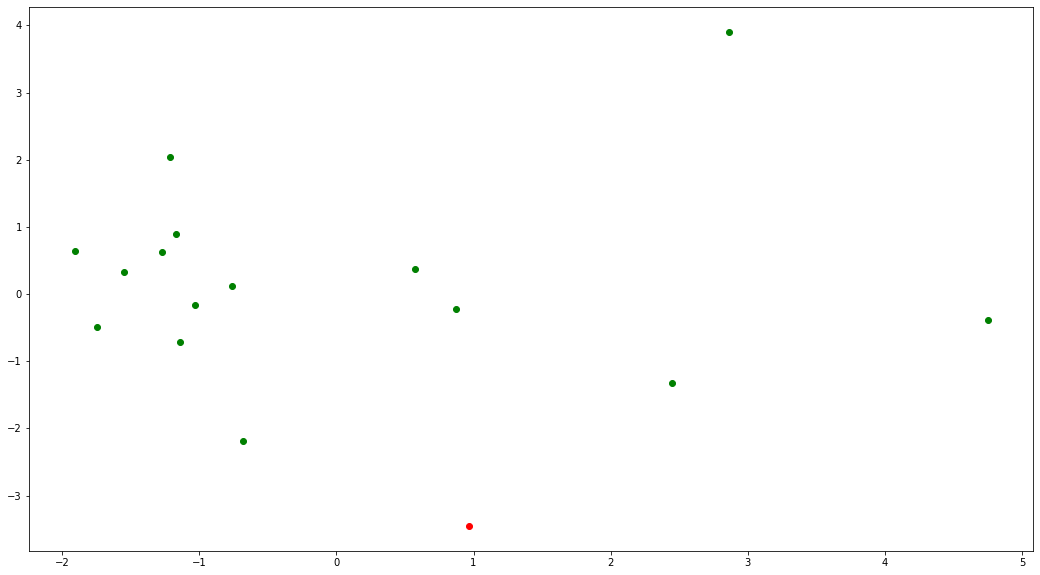

122 fra_à_4


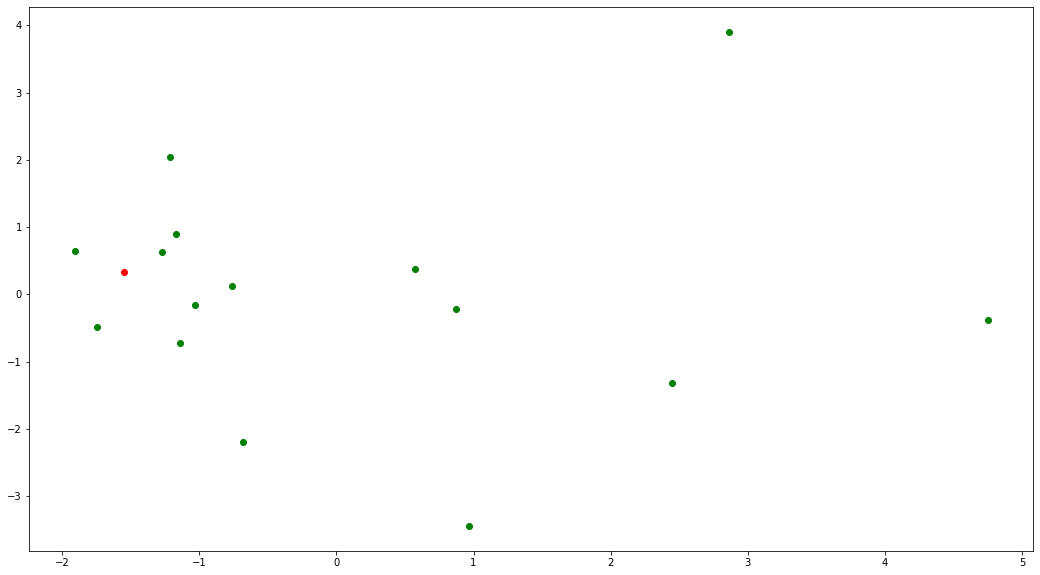

123 fra_à_0


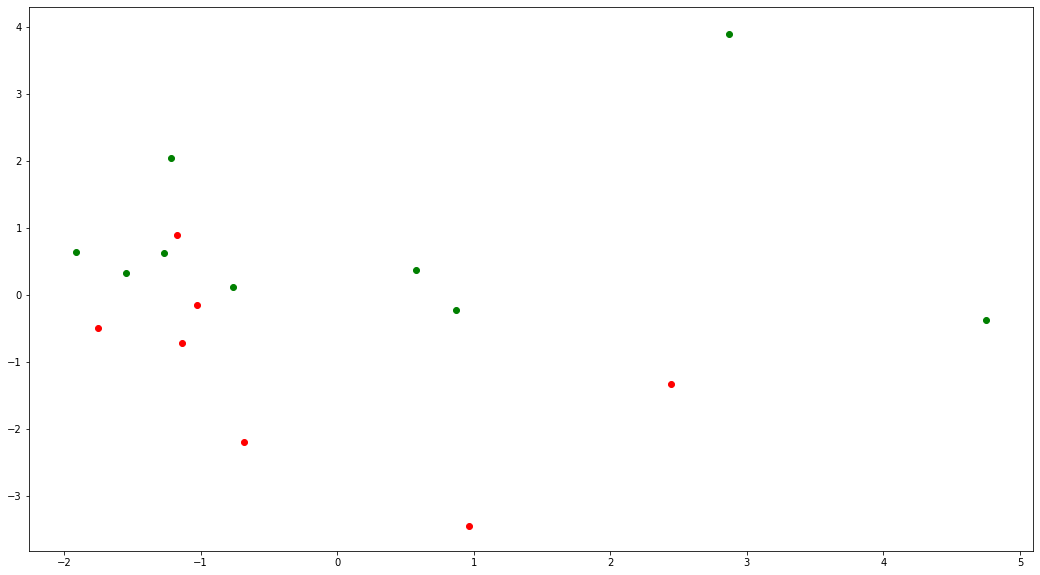

124 fra_à_3


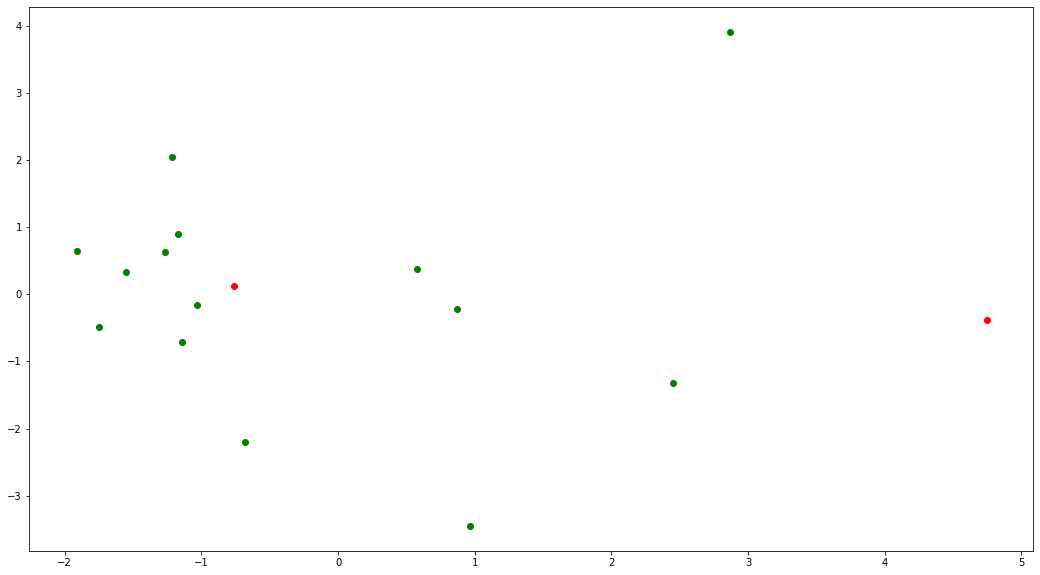

125 fra_à_1


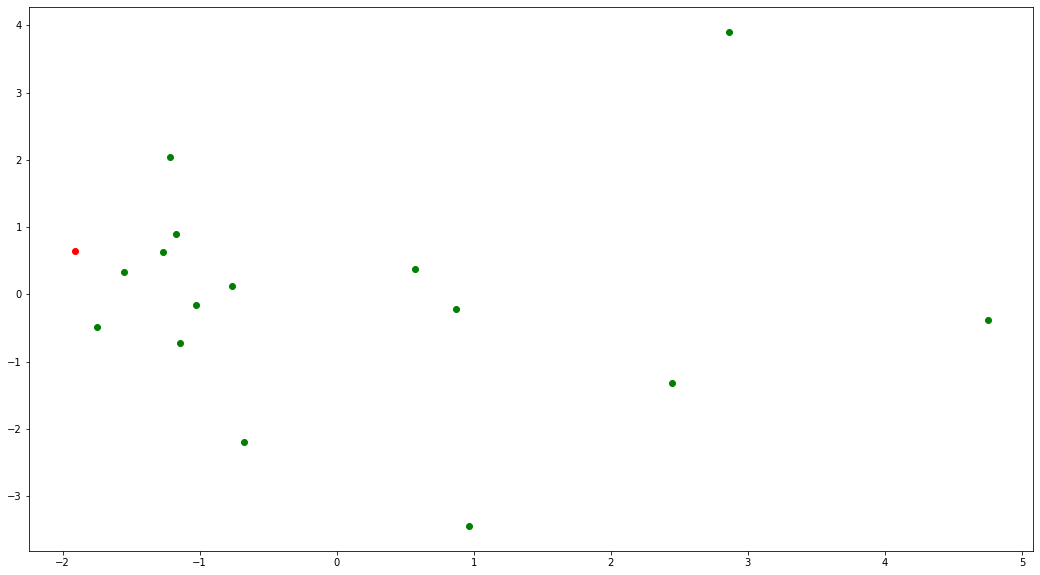

126 fra_à_2


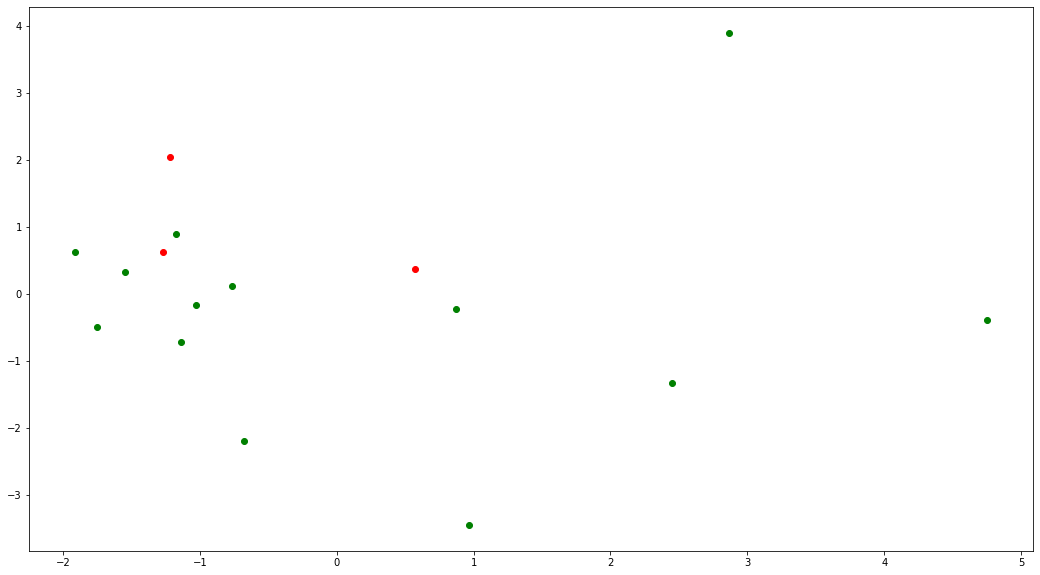

127 fra_à_7


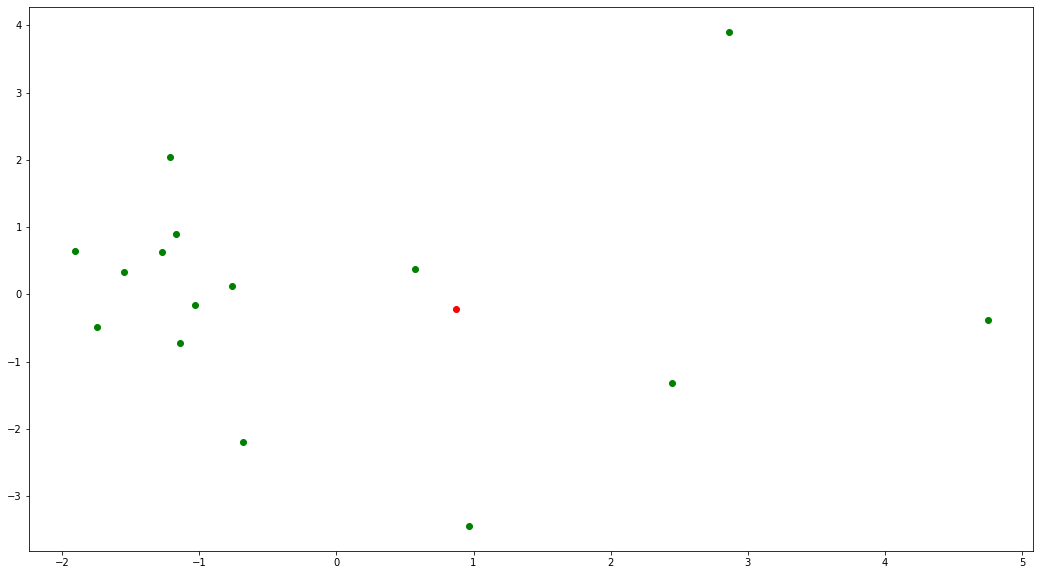

128 fra_à_13


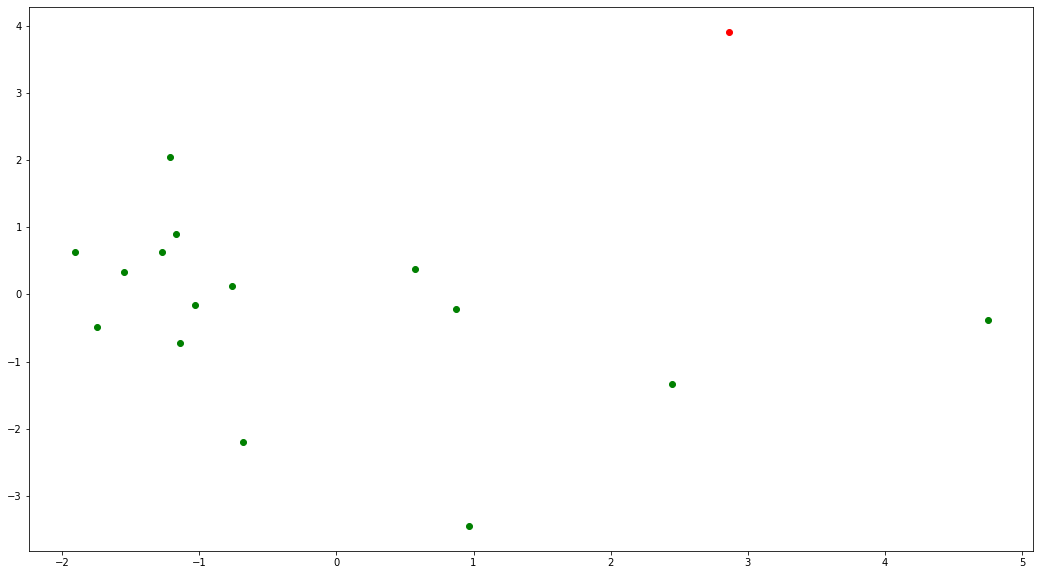

129 fra_dans_6


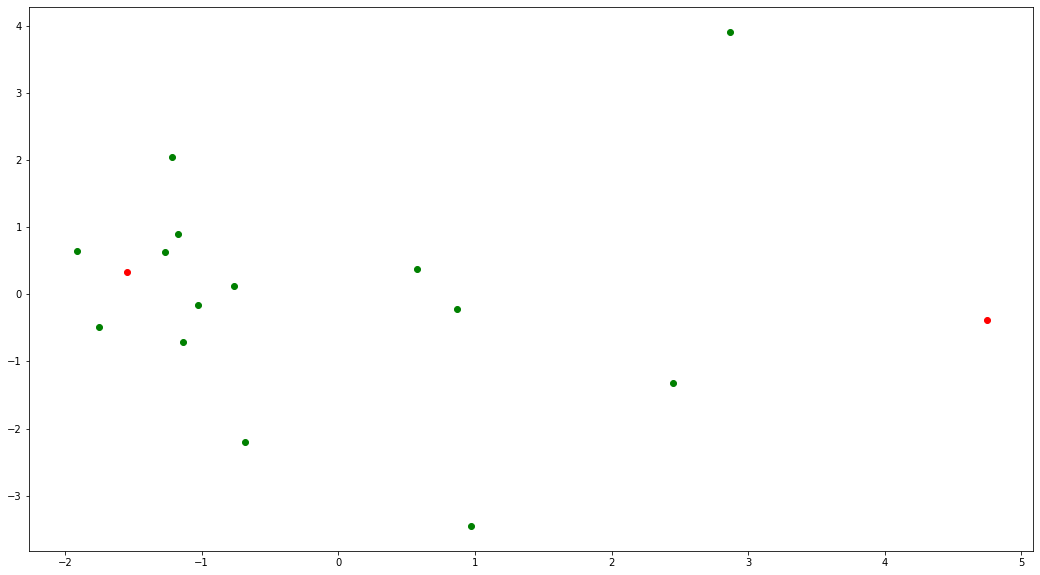

130 fra_dans_1


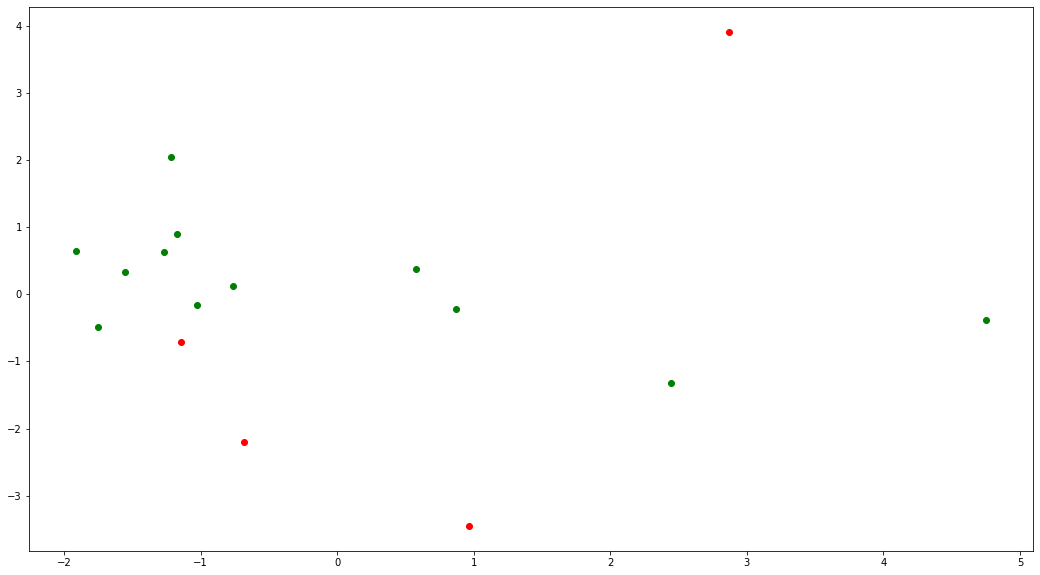

131 fra_dans_0


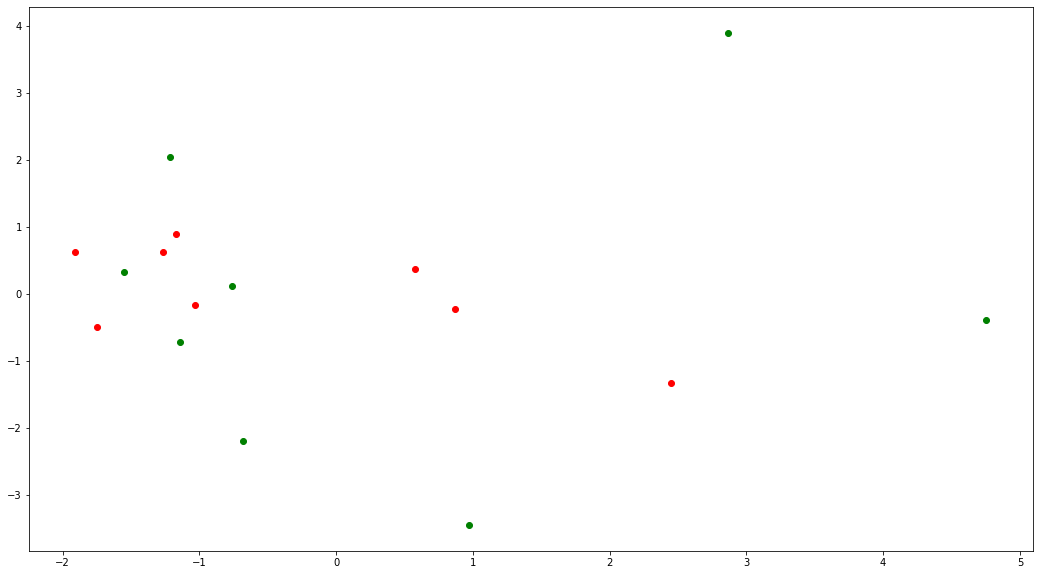

132 fra_dans_5


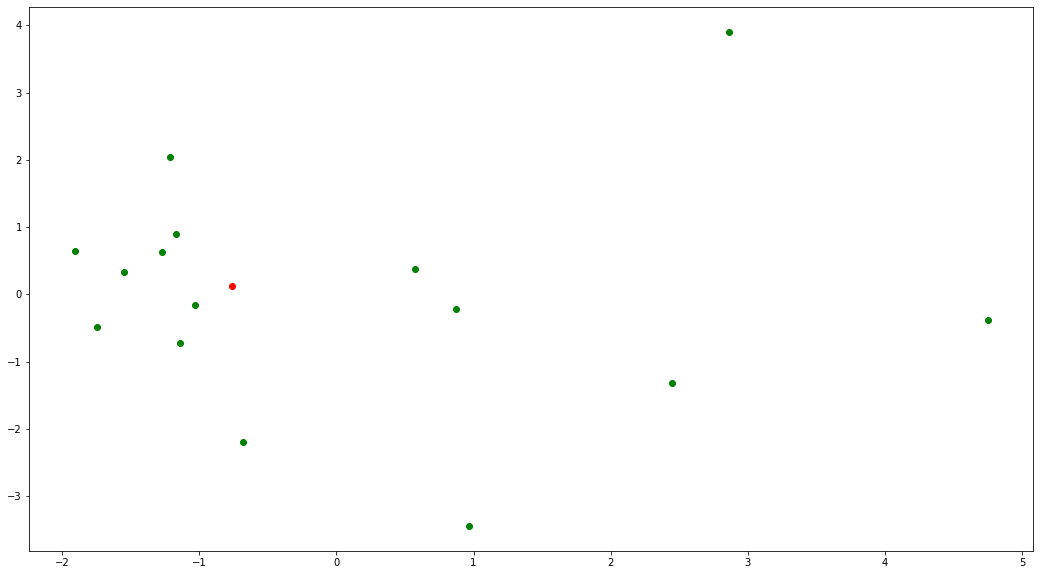

133 fra_dans_2


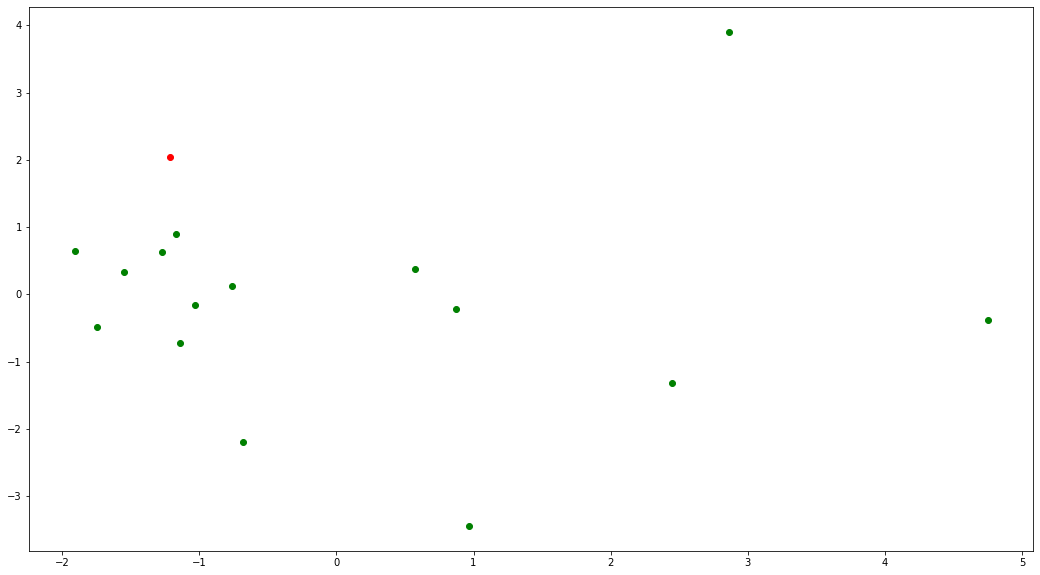

134 fra_lors_de_0


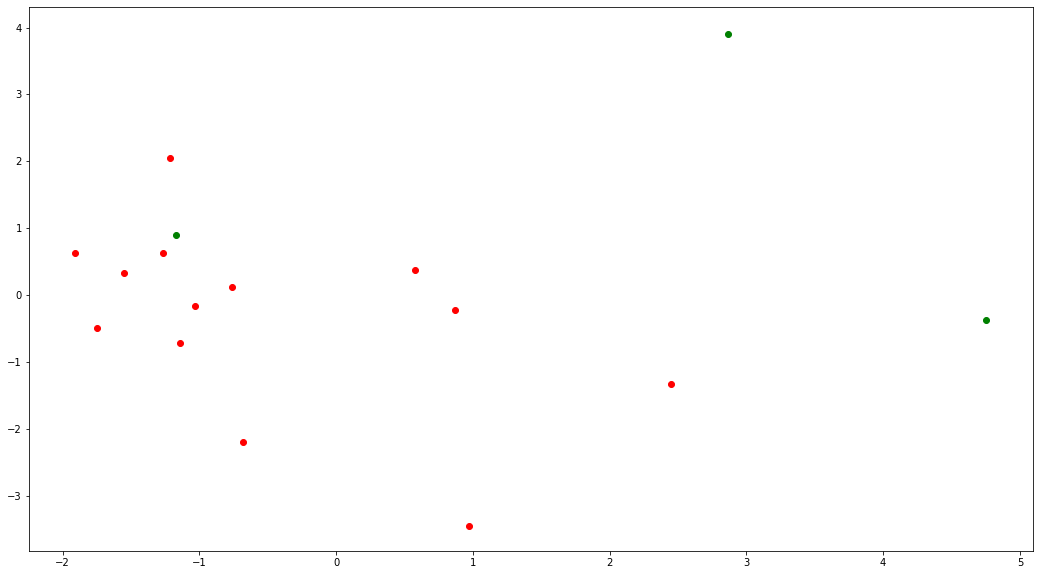

135 fra_lors_de_1


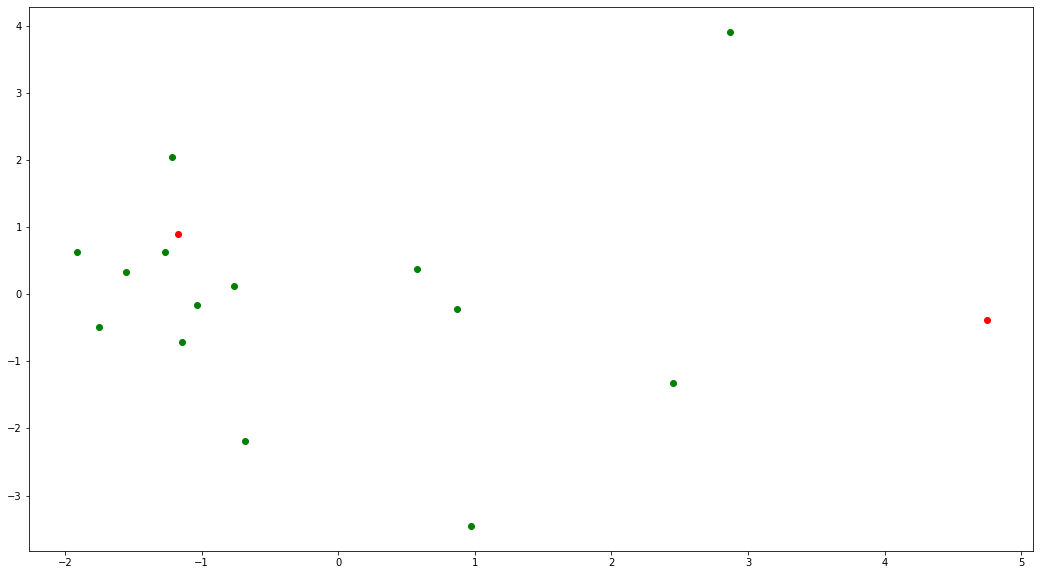

136 fra_lors_de_4


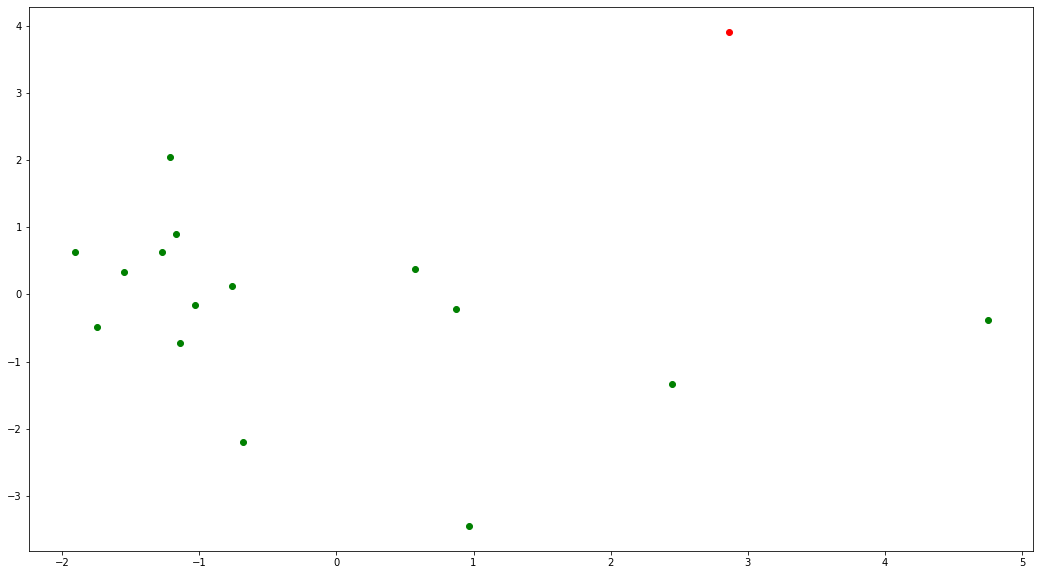

137 fra_de_0


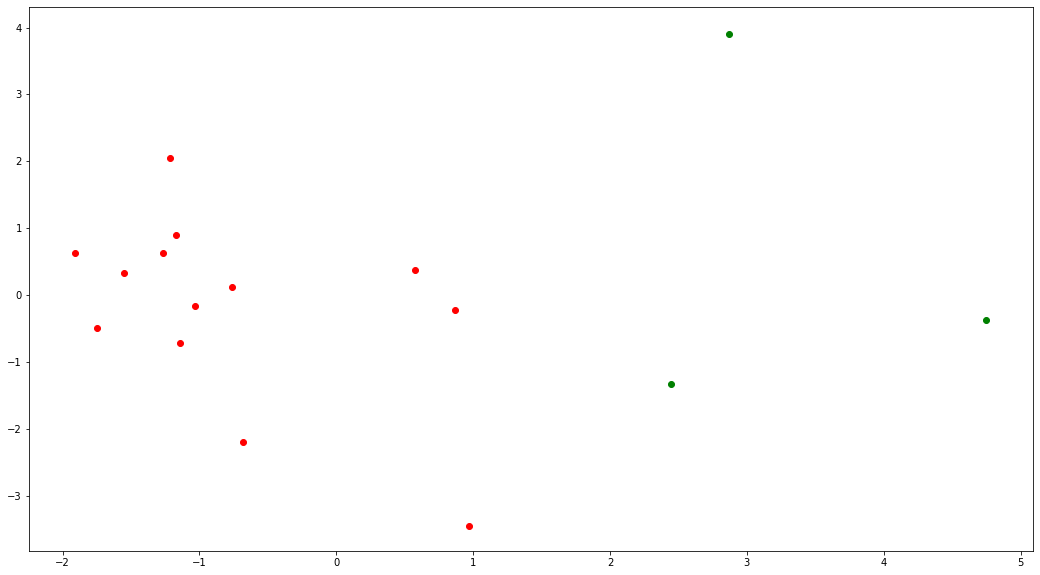

138 fra_de_6


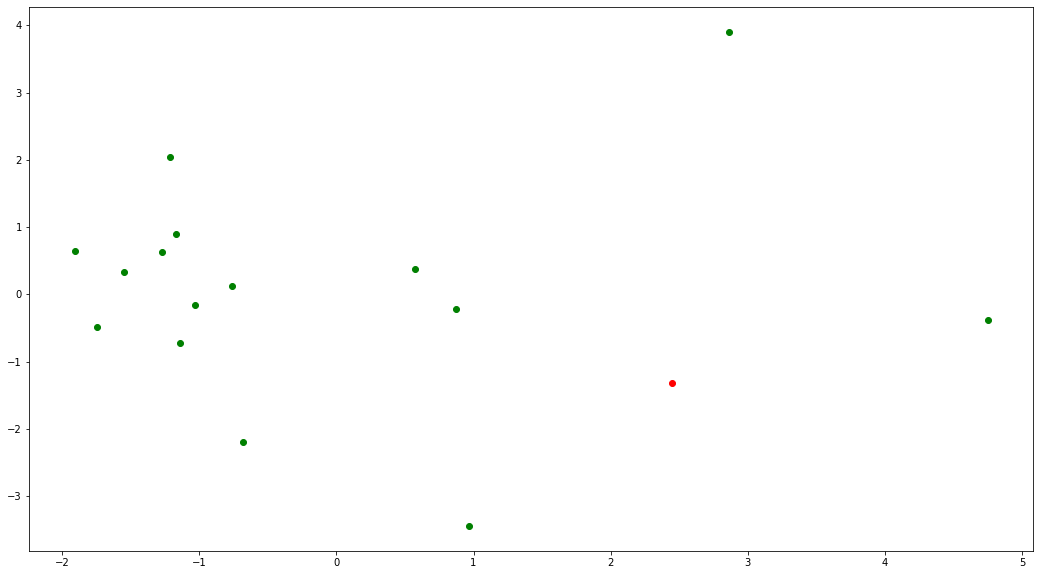

139 fra_de_1


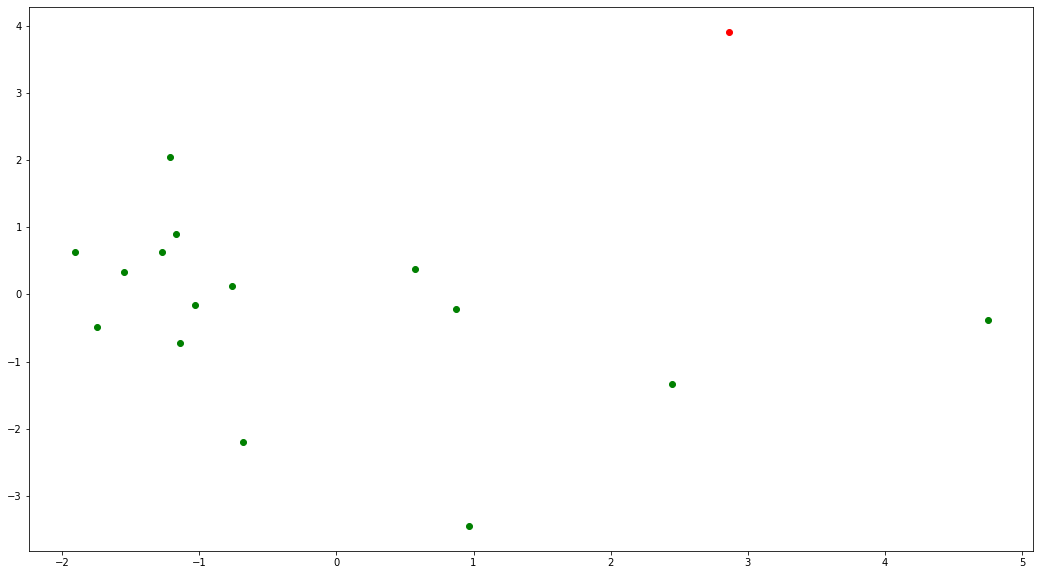

140 fra_de_2


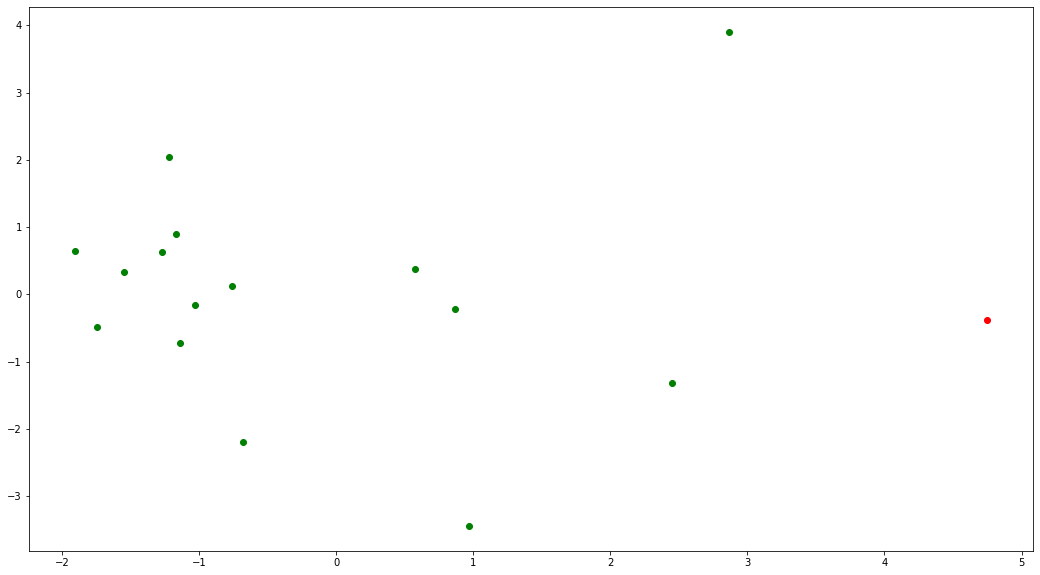

141 fra_sur_1


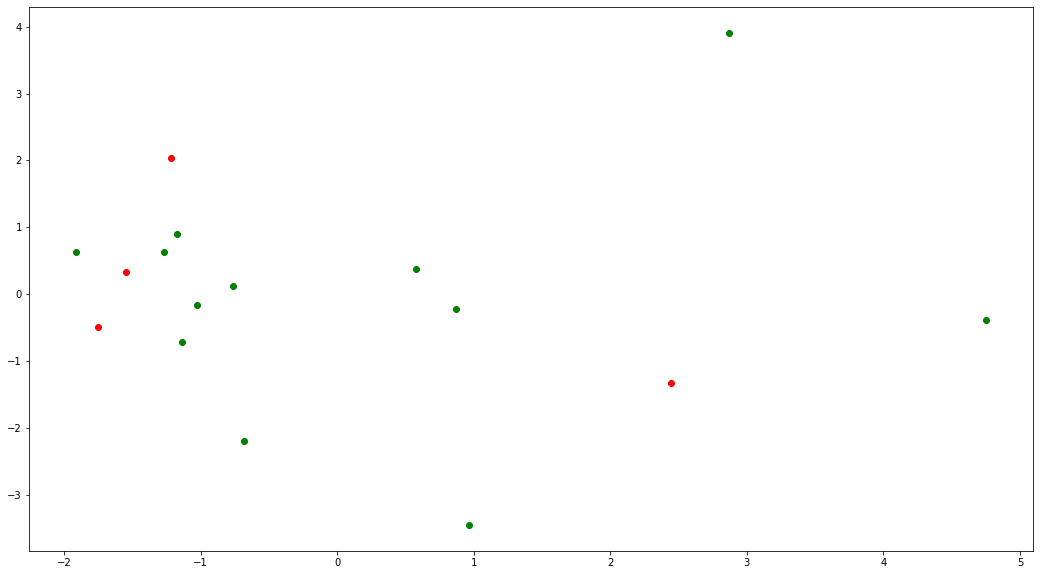

142 fra_sur_0


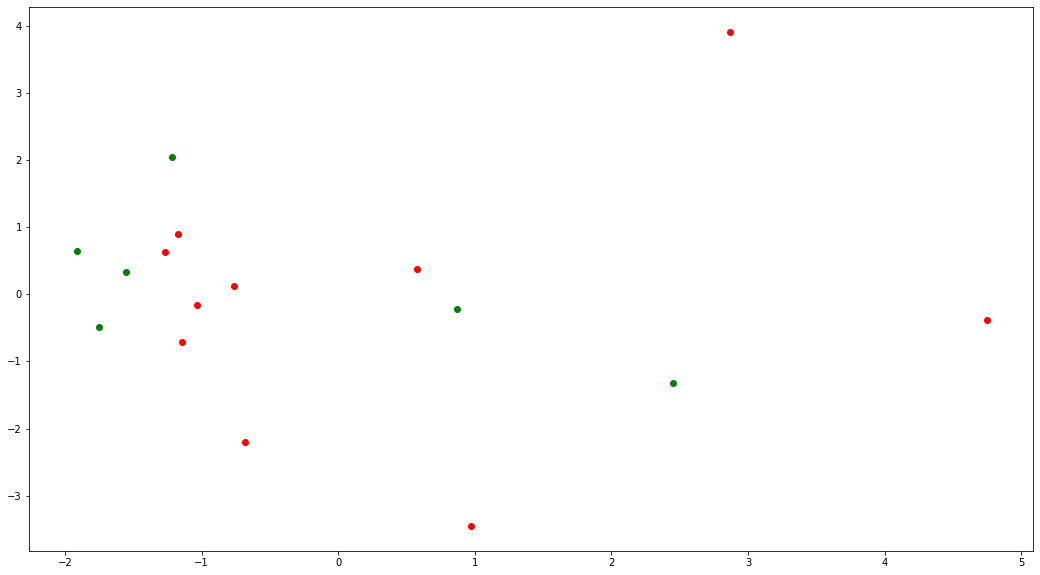

143 fra_sur_4


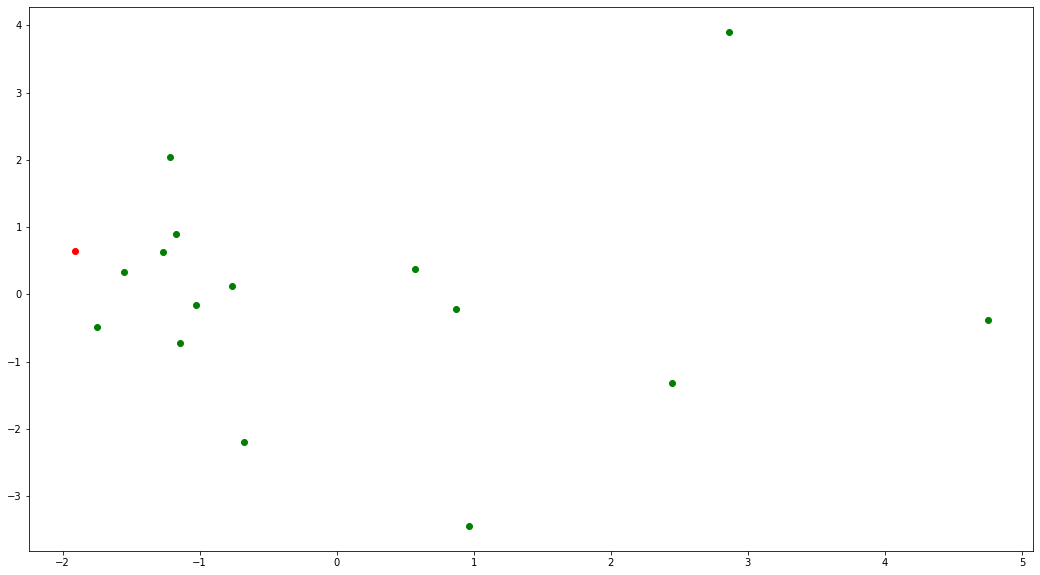

144 fra_sur_2


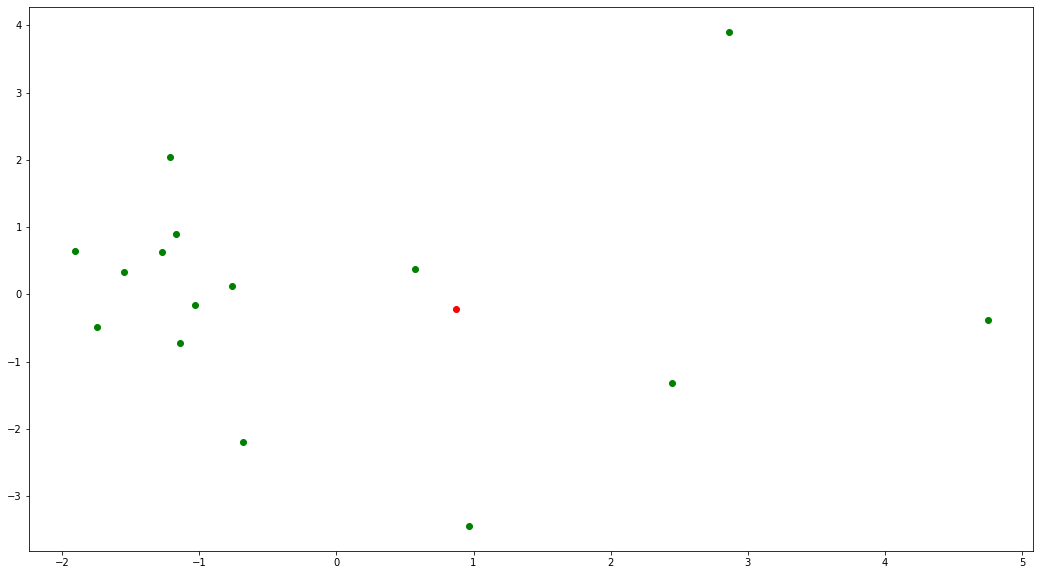

145 fra_zero_0


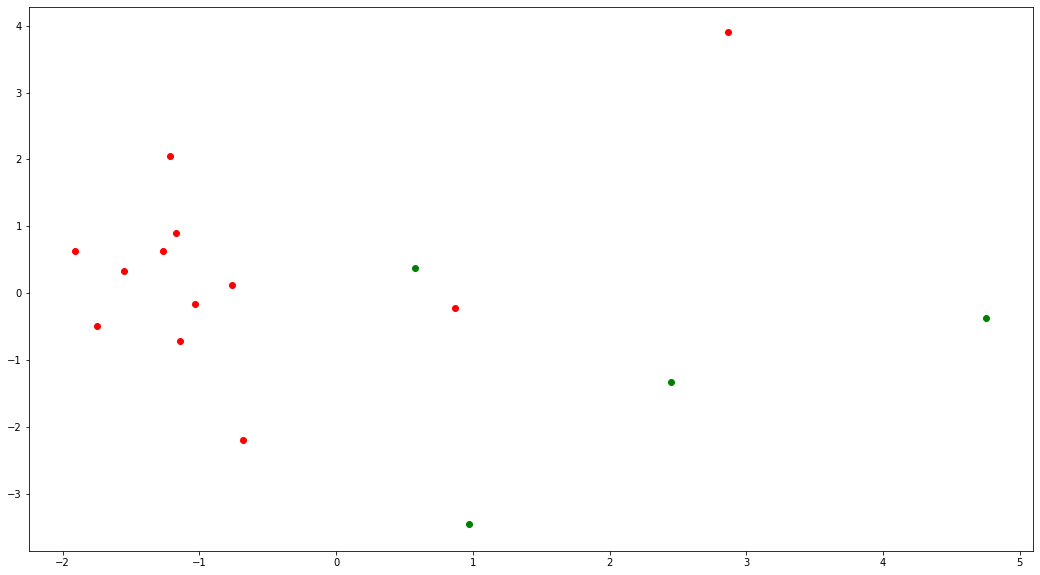

146 fra_zero_4


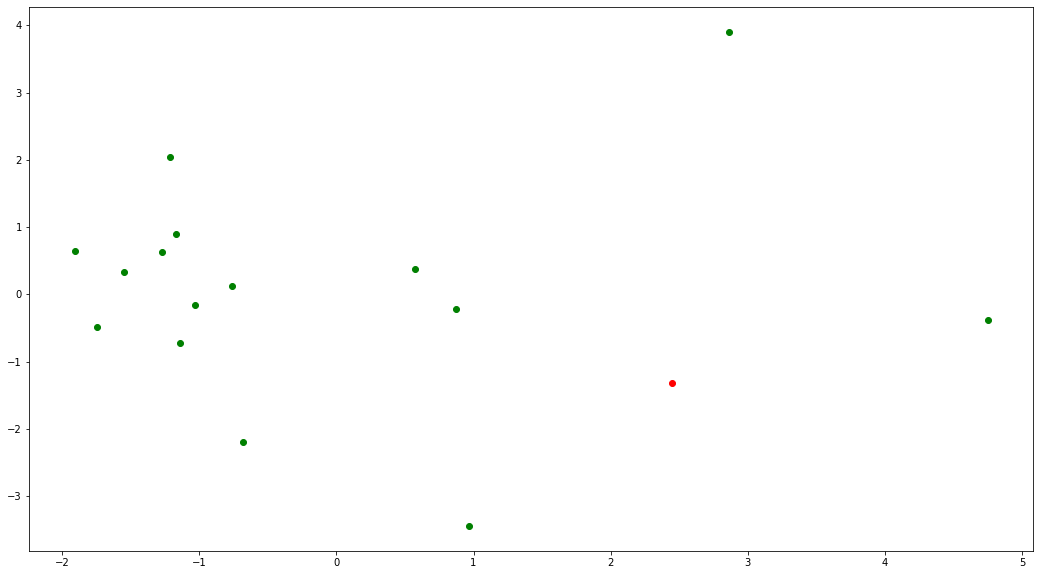

147 fra_zero_25


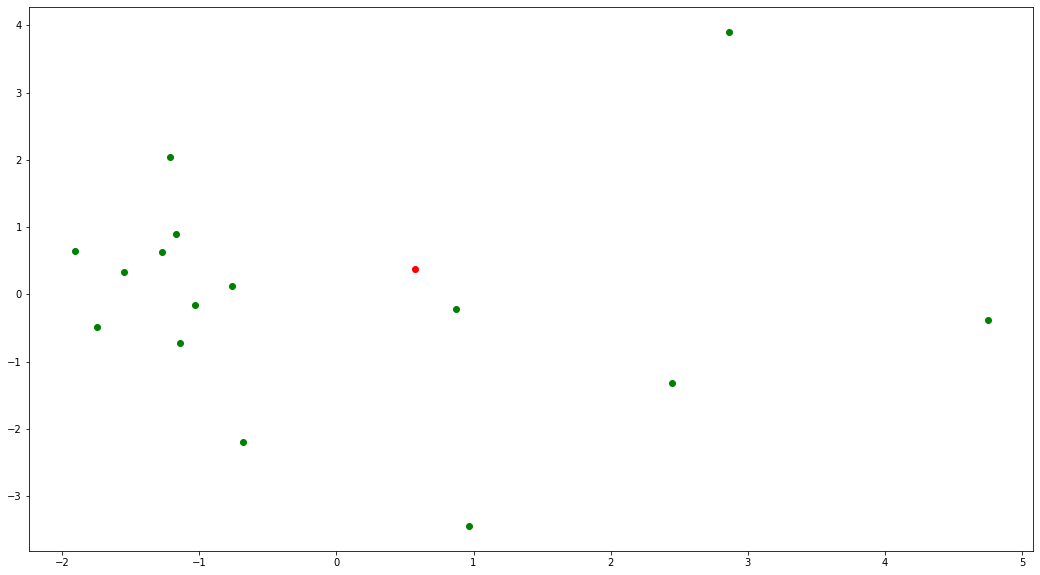

148 fra_zero_2


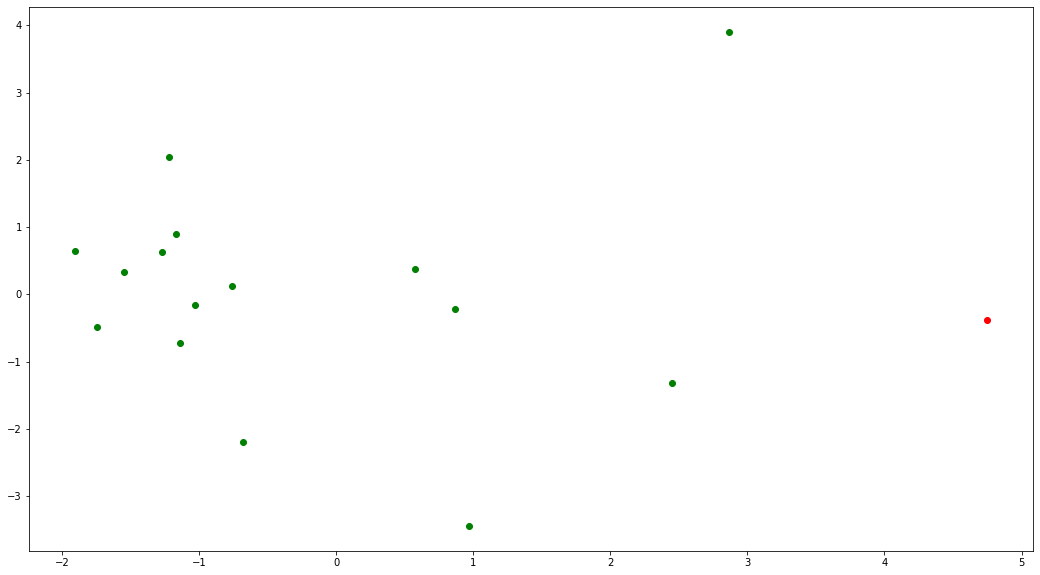

149 fra_zero_1


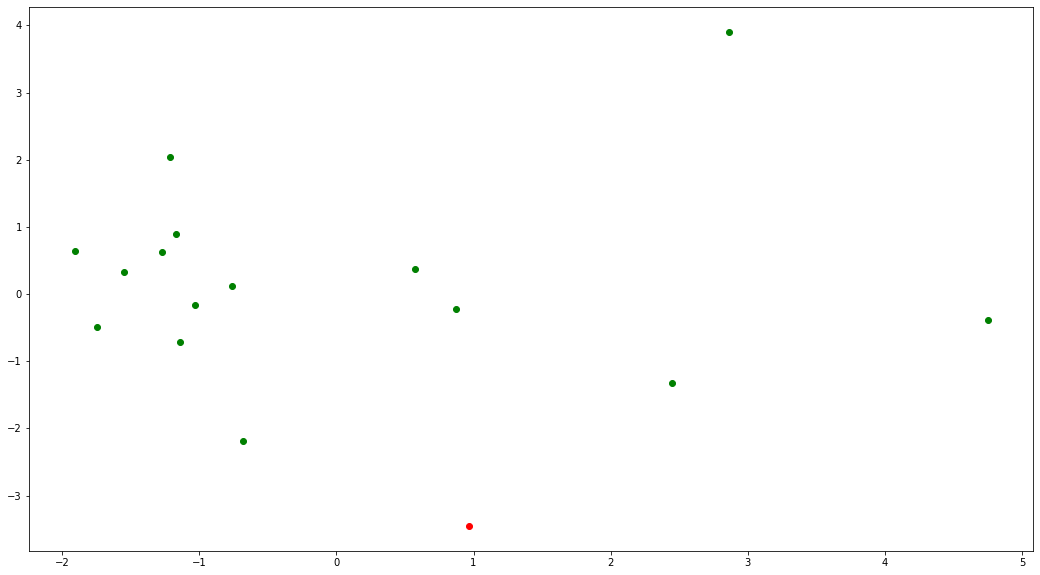

150 fra_other_0


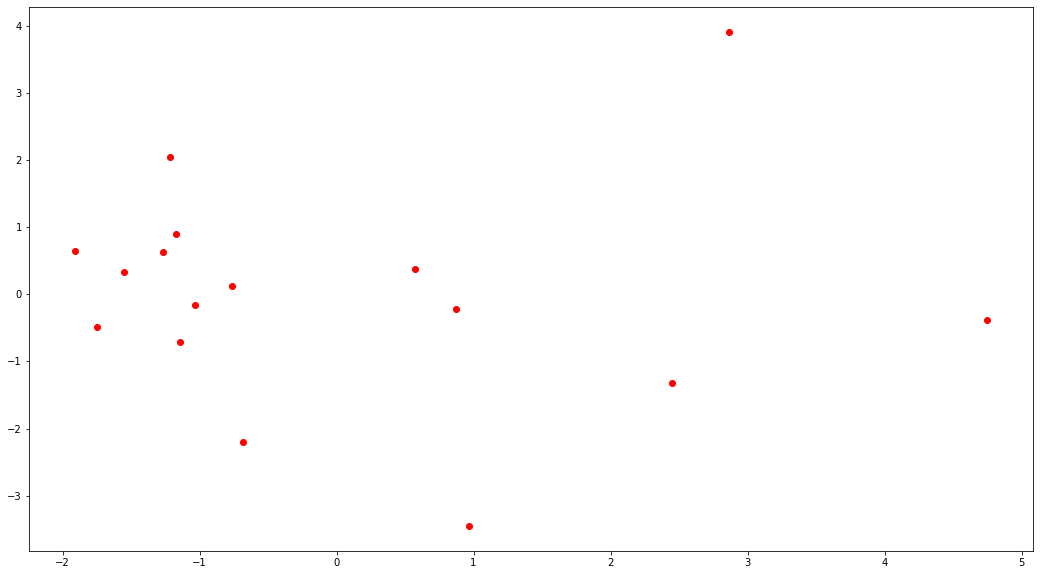

151 spa_en_12


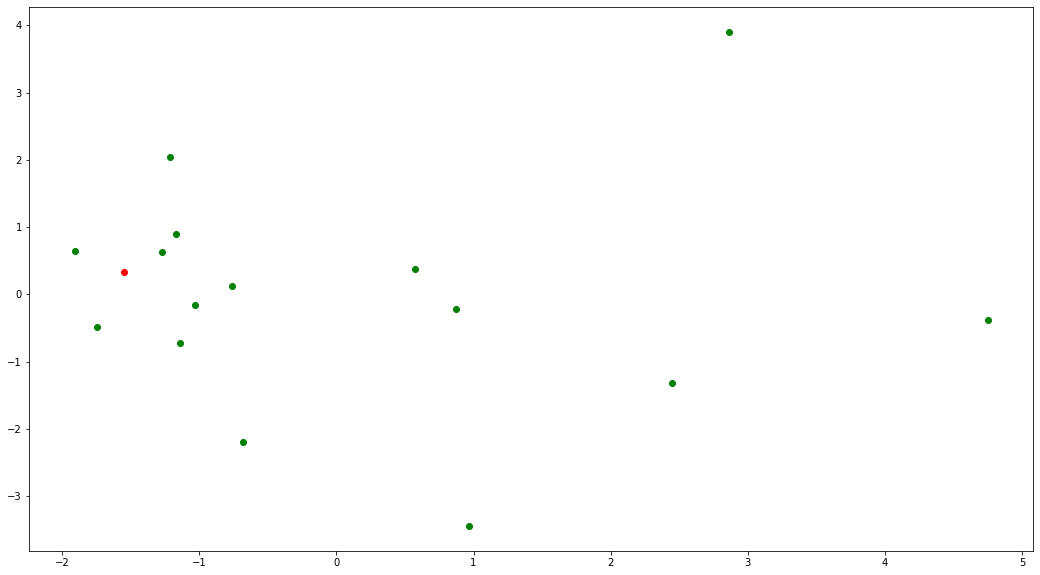

152 spa_en_1


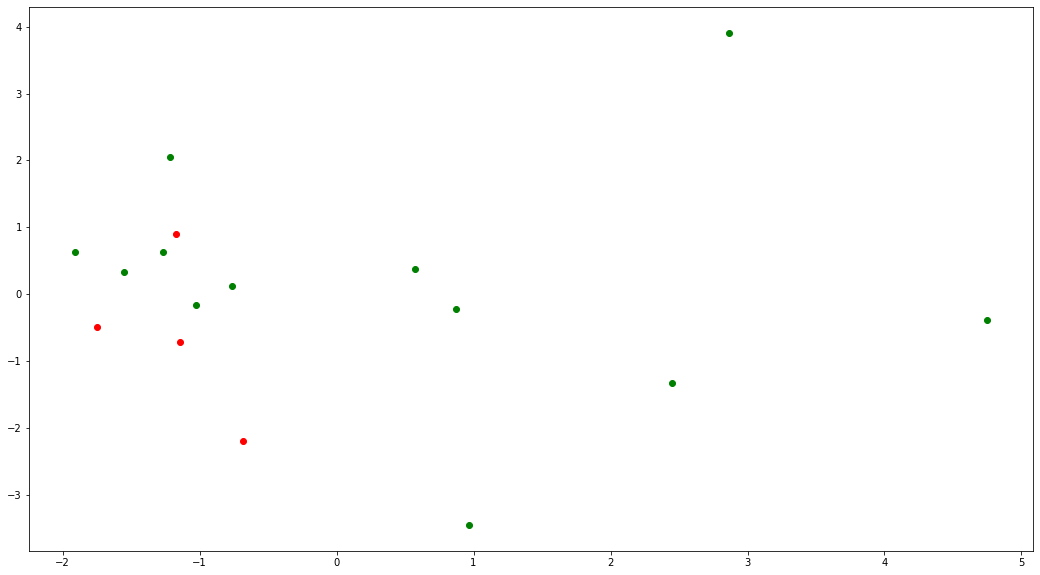

153 spa_en_8


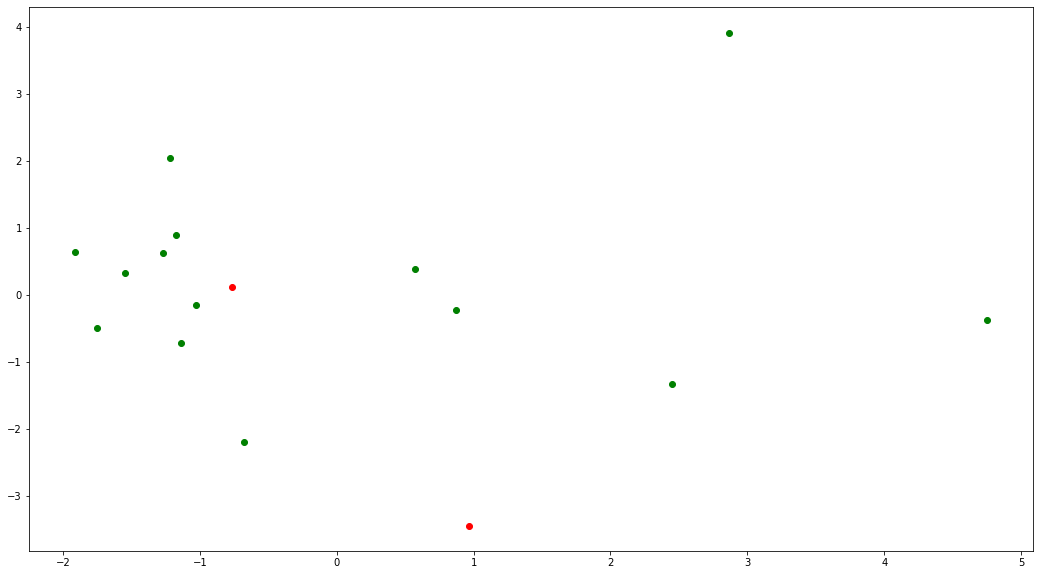

154 spa_en_4


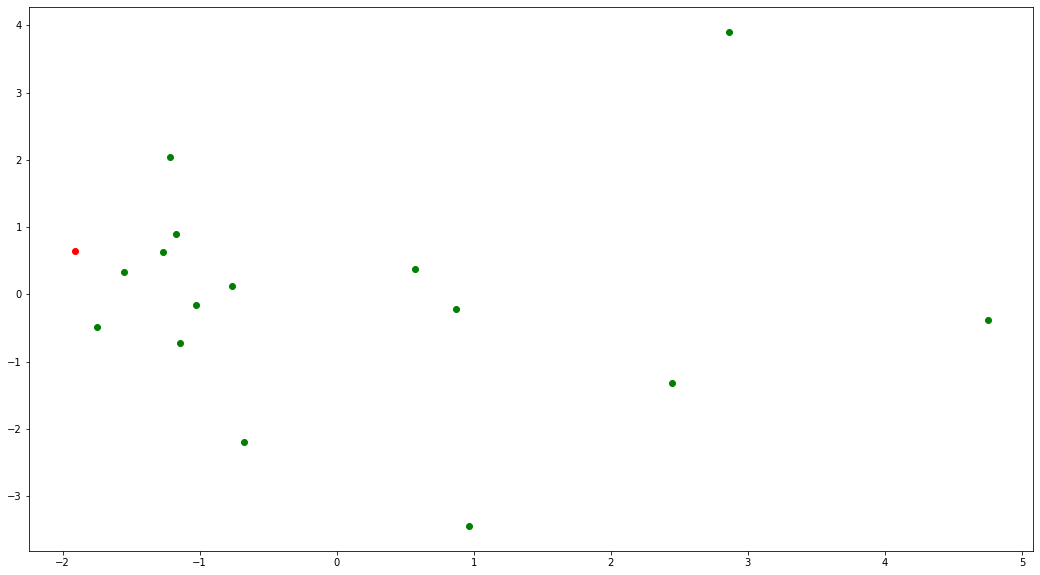

155 spa_en_0


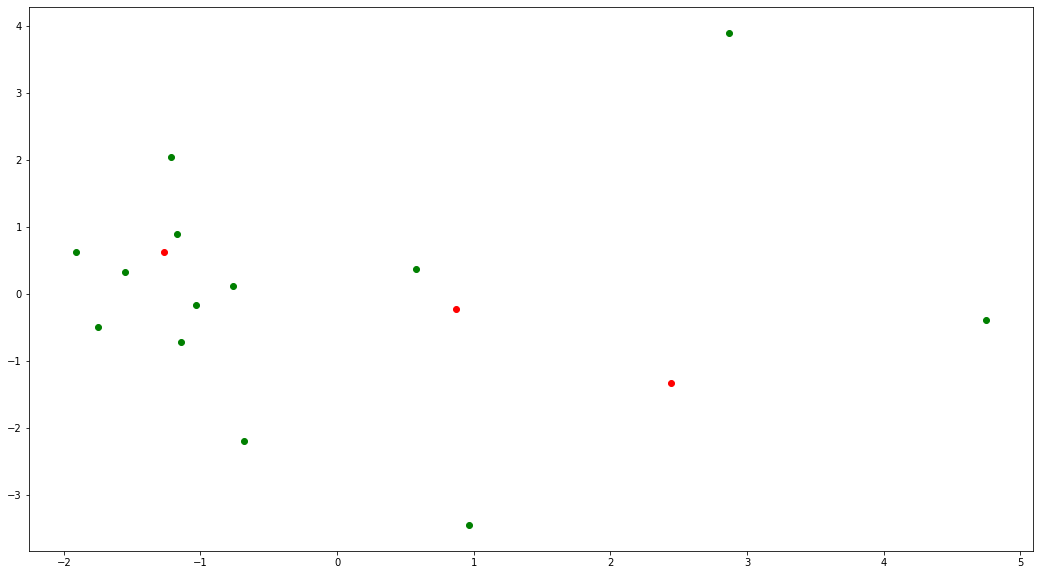

156 spa_en_5


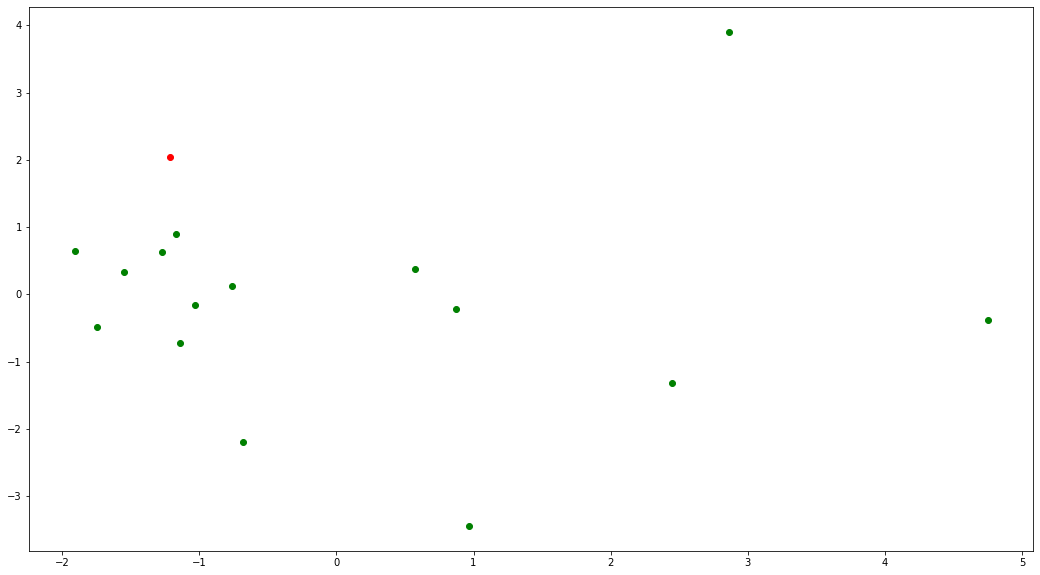

157 spa_en_13


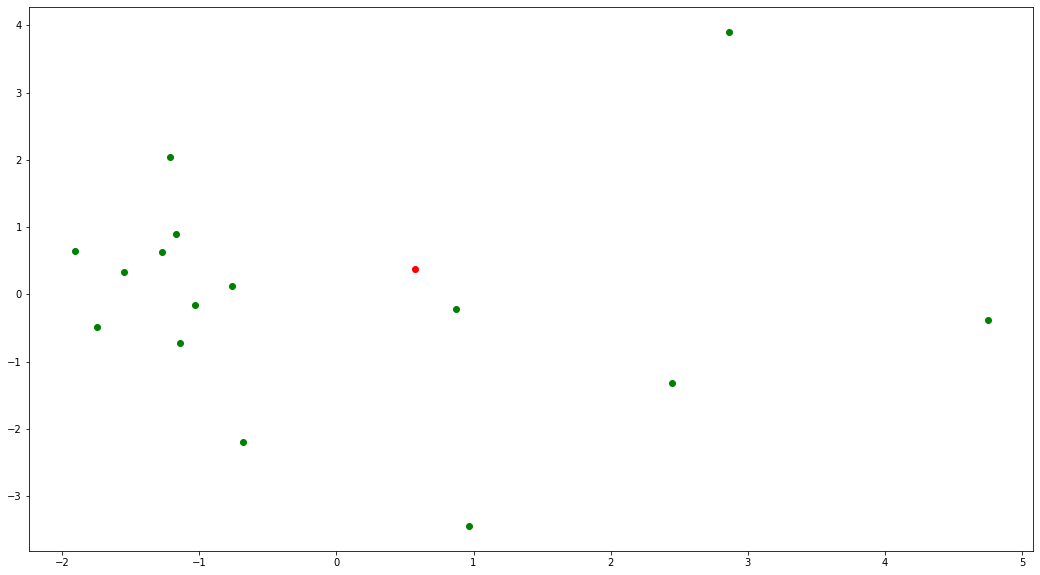

158 spa_en_2


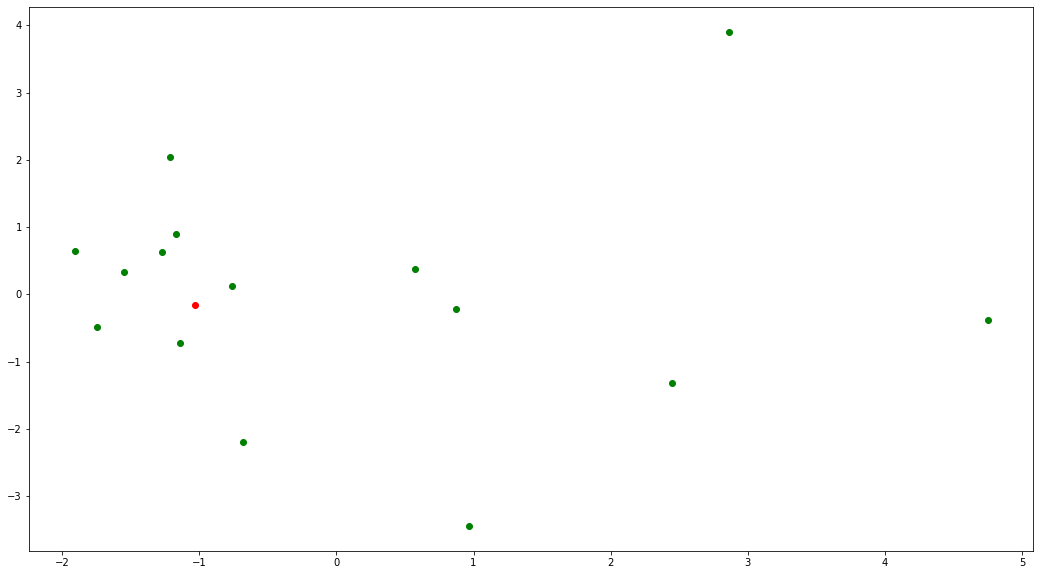

159 spa_en_16


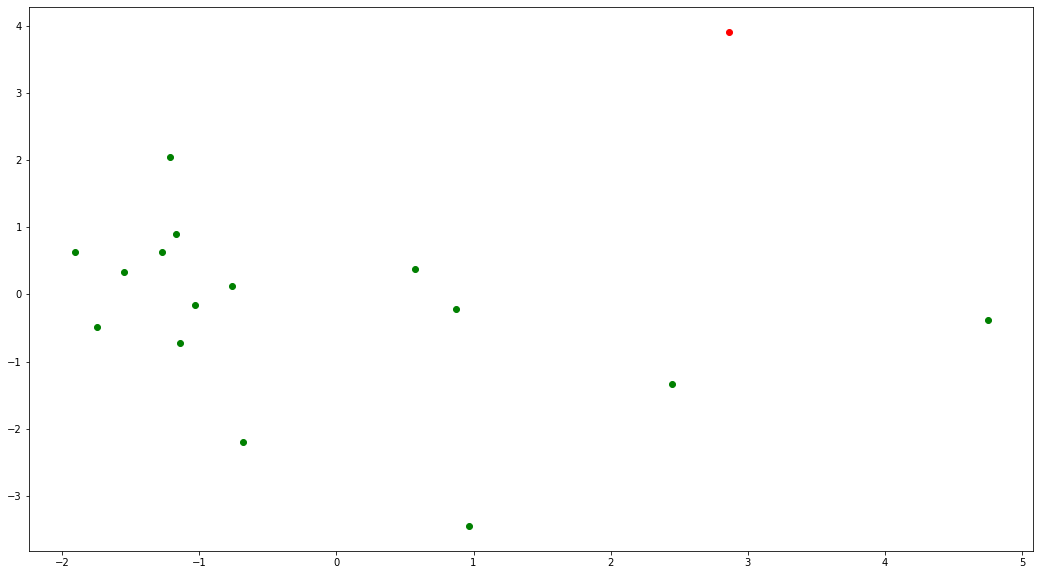

160 spa_en_21


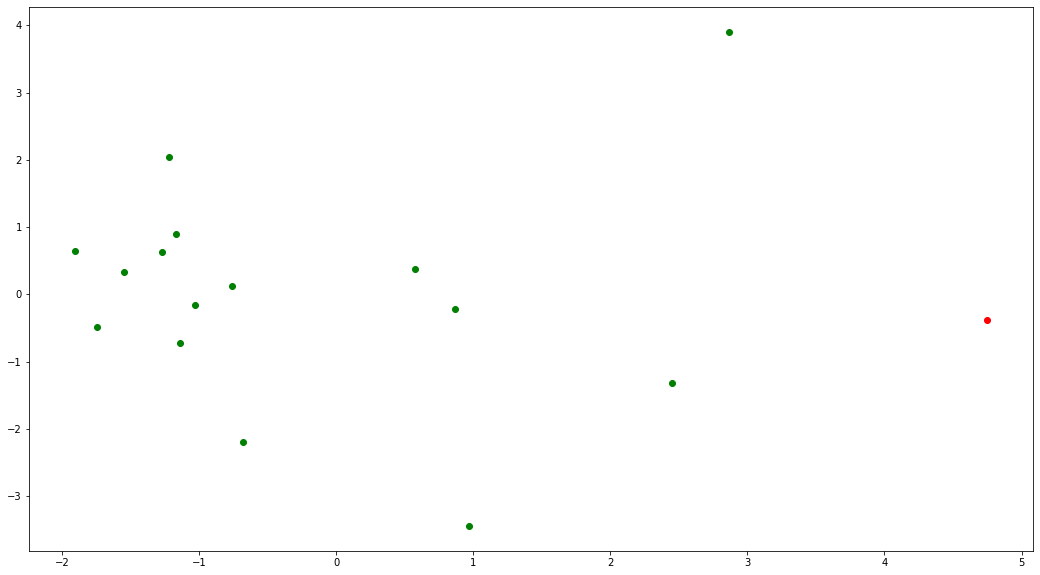

161 spa_a_1


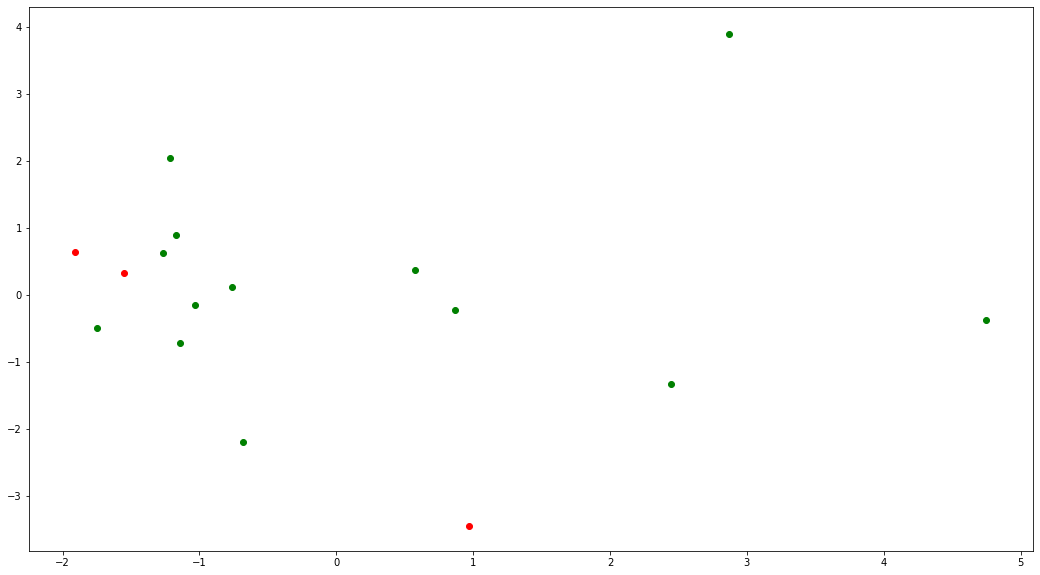

162 spa_a_0


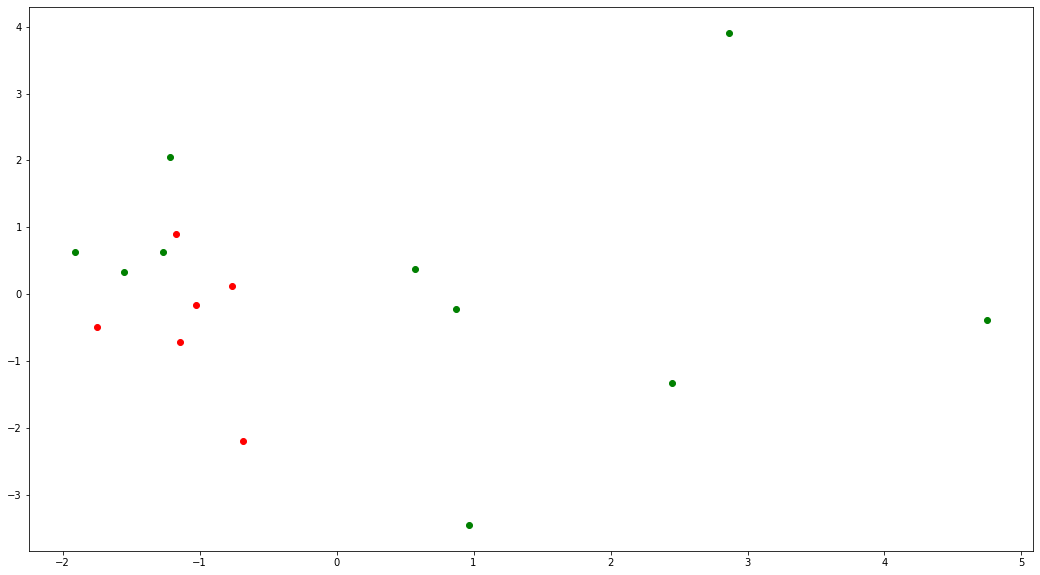

163 spa_a_2


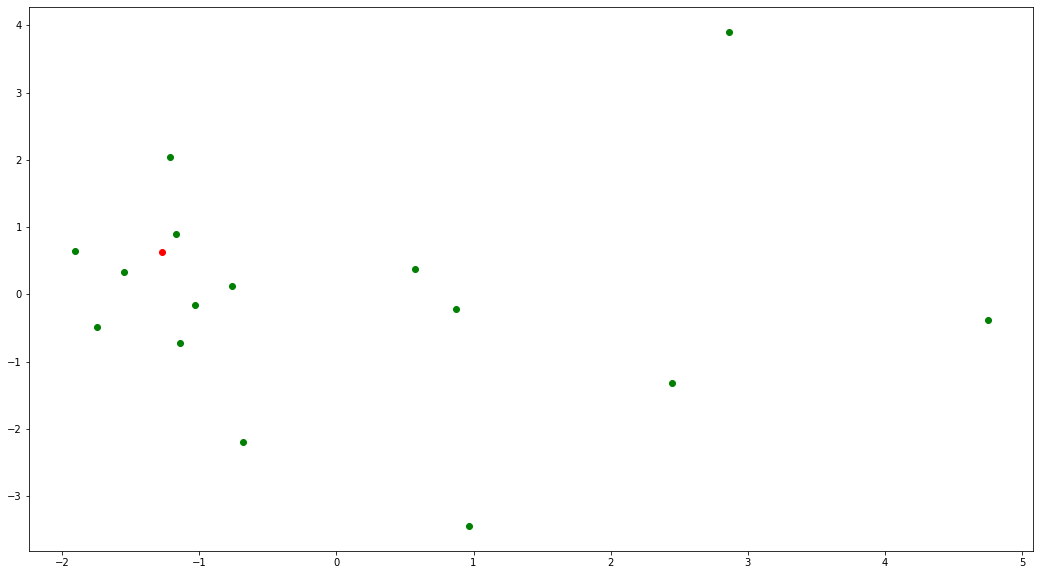

164 spa_a_3


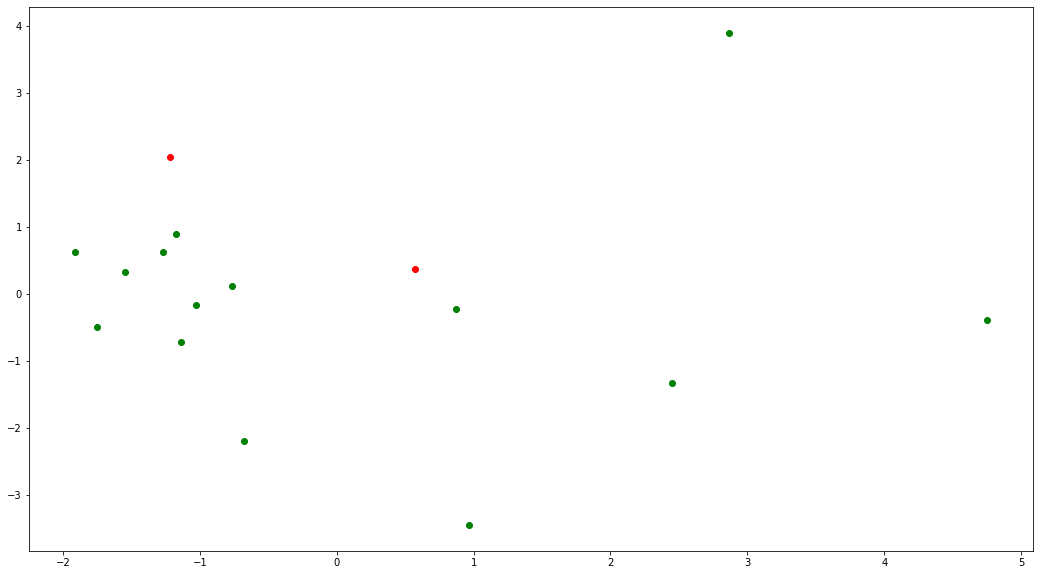

165 spa_a_8


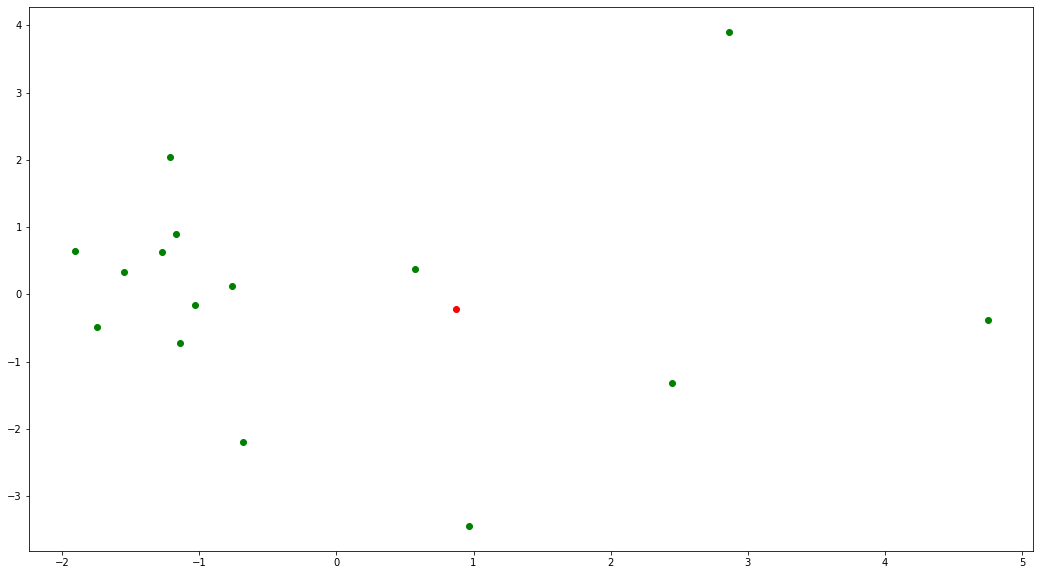

166 spa_a_4


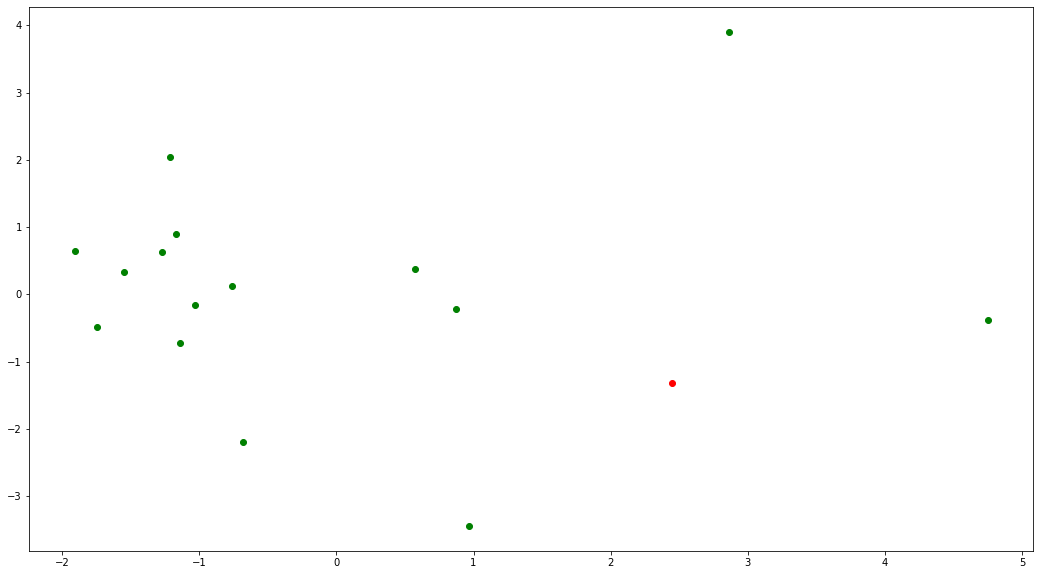

167 spa_a_9


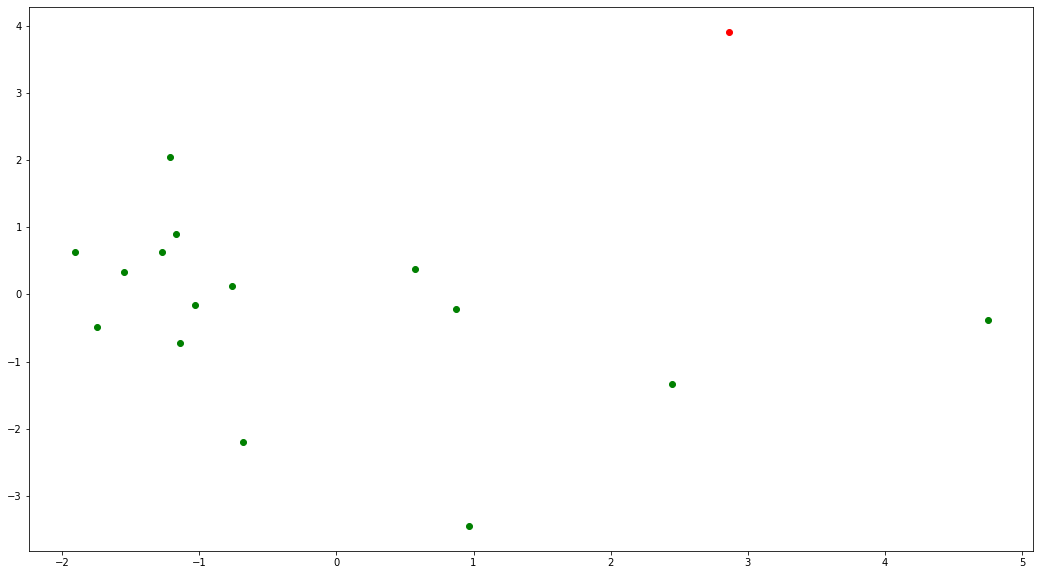

168 spa_a_5


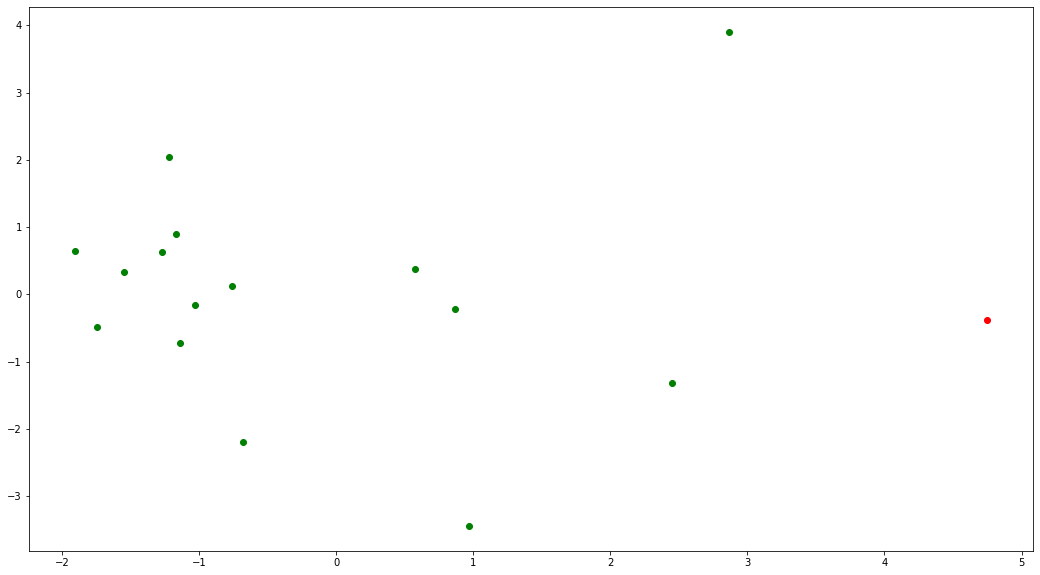

169 spa_sobre_0


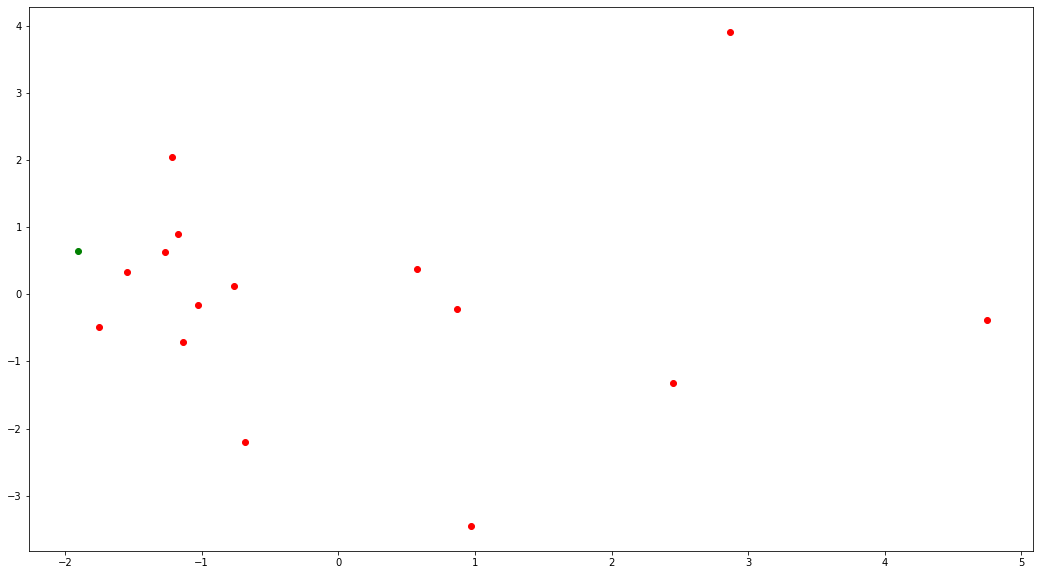

170 spa_sobre_2


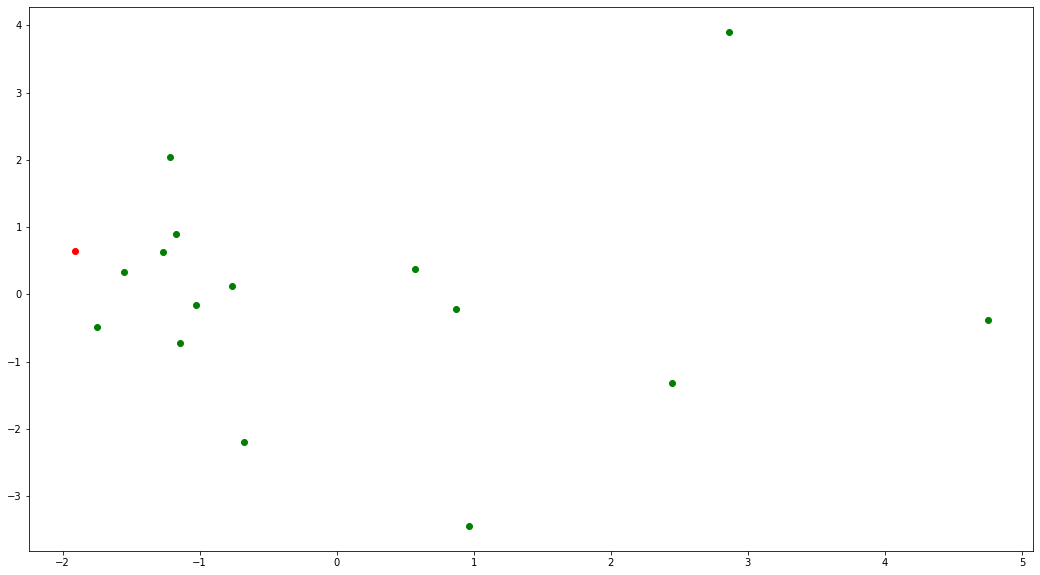

171 spa_de_0


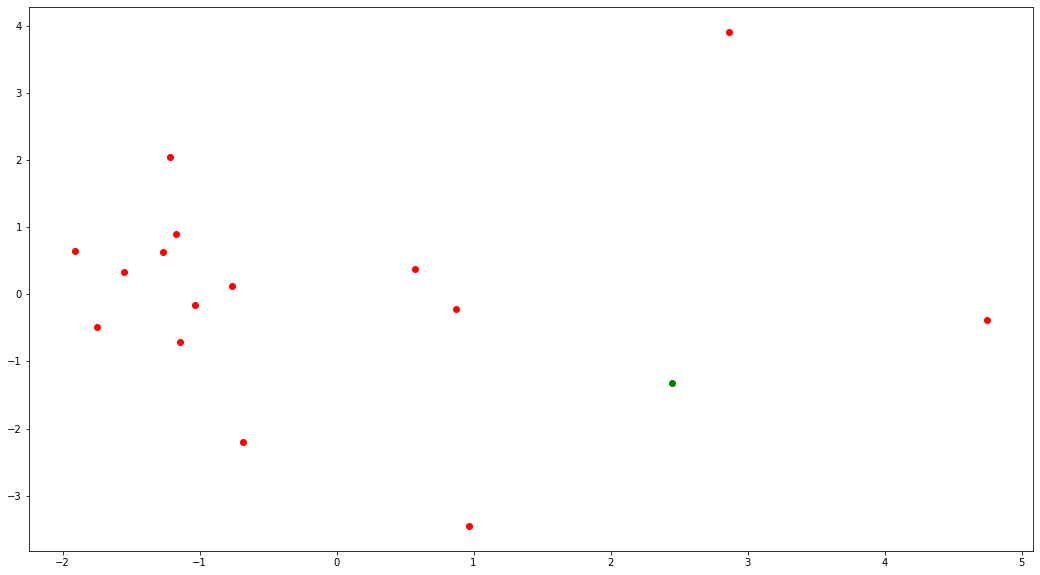

172 spa_de_5


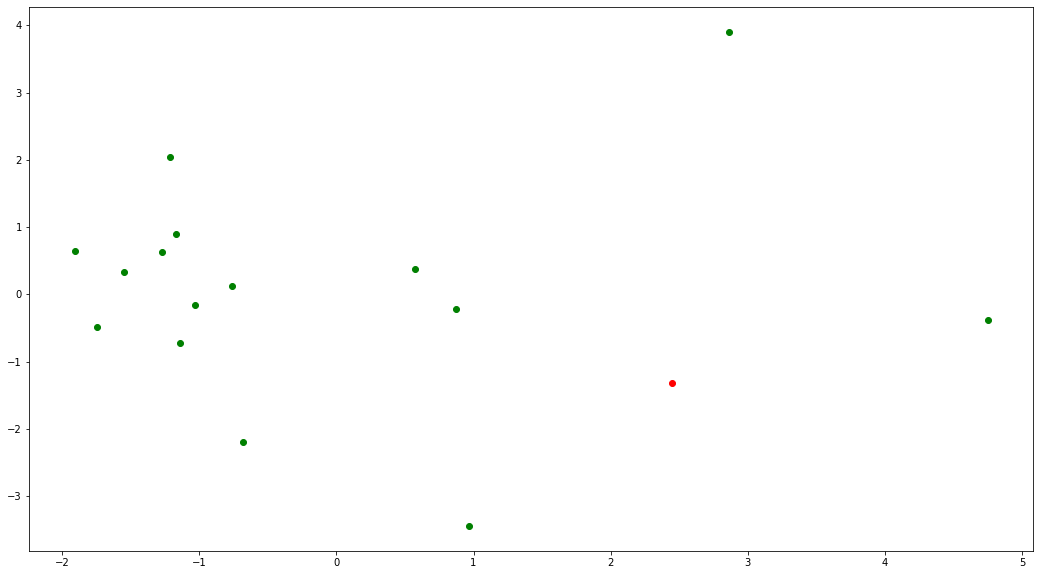

173 spa_por_0


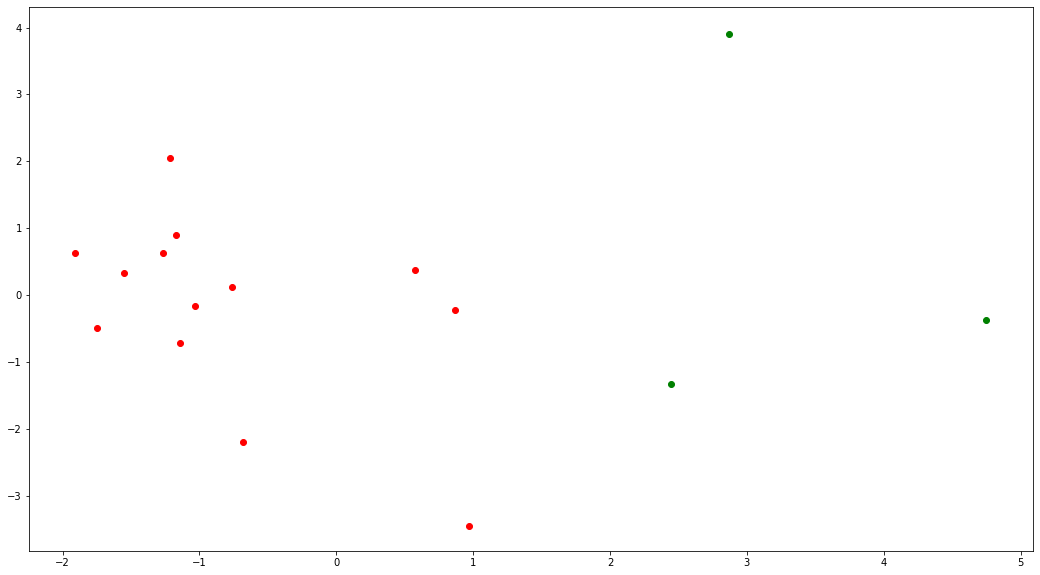

174 spa_por_3


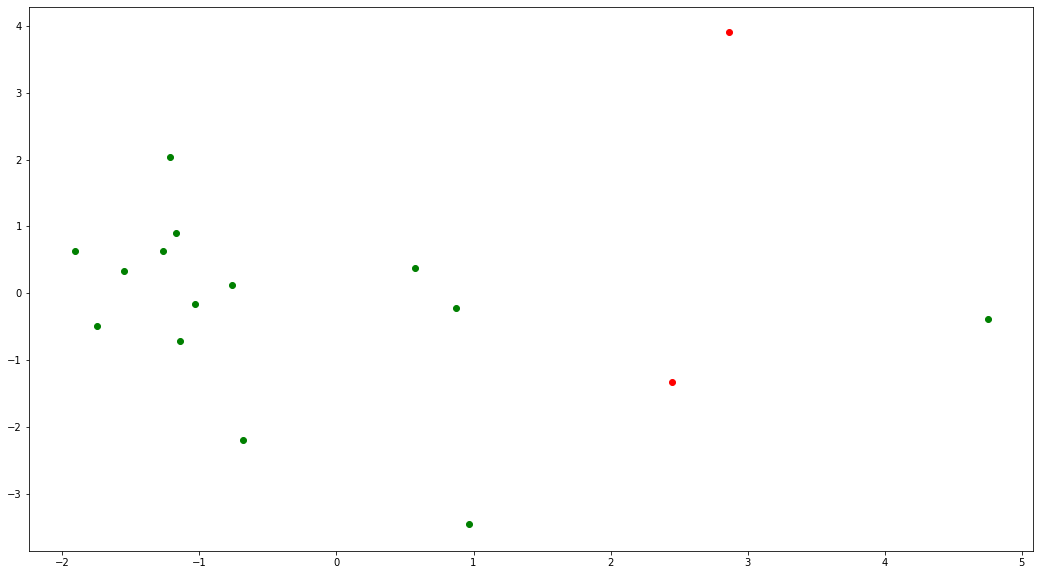

175 spa_por_1


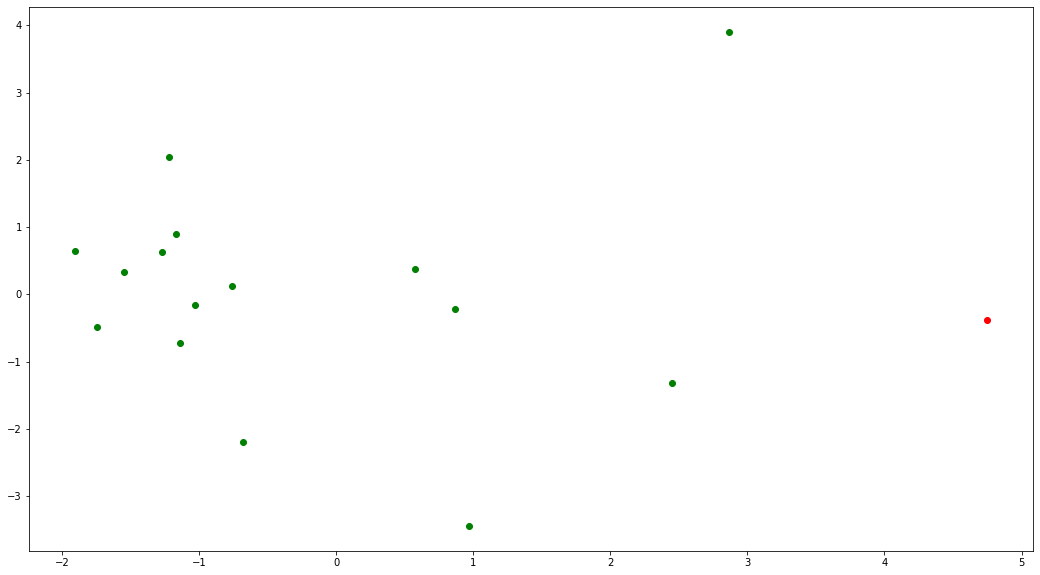

176 spa_zero_0


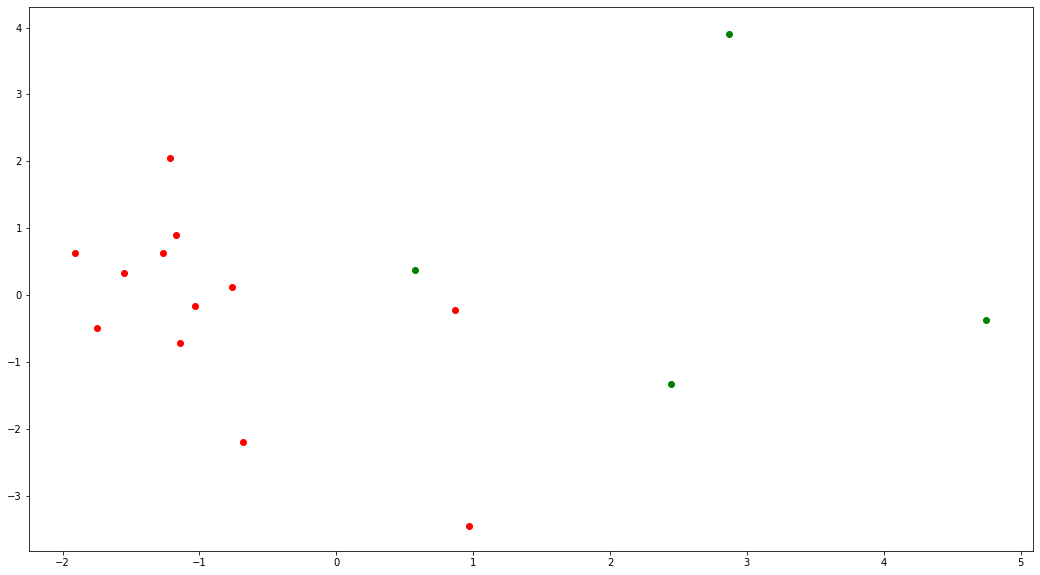

177 spa_zero_1


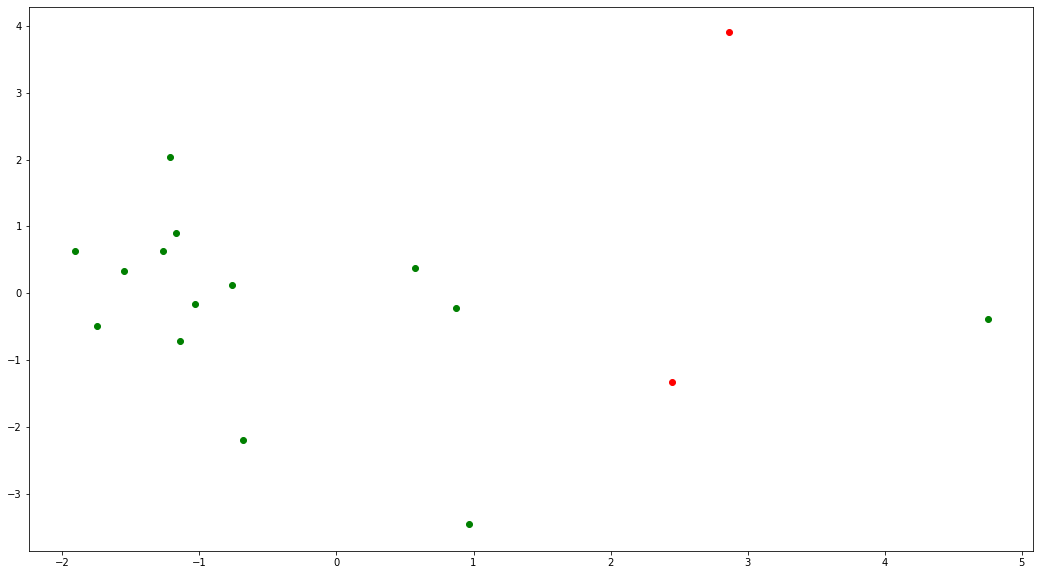

178 spa_zero_9


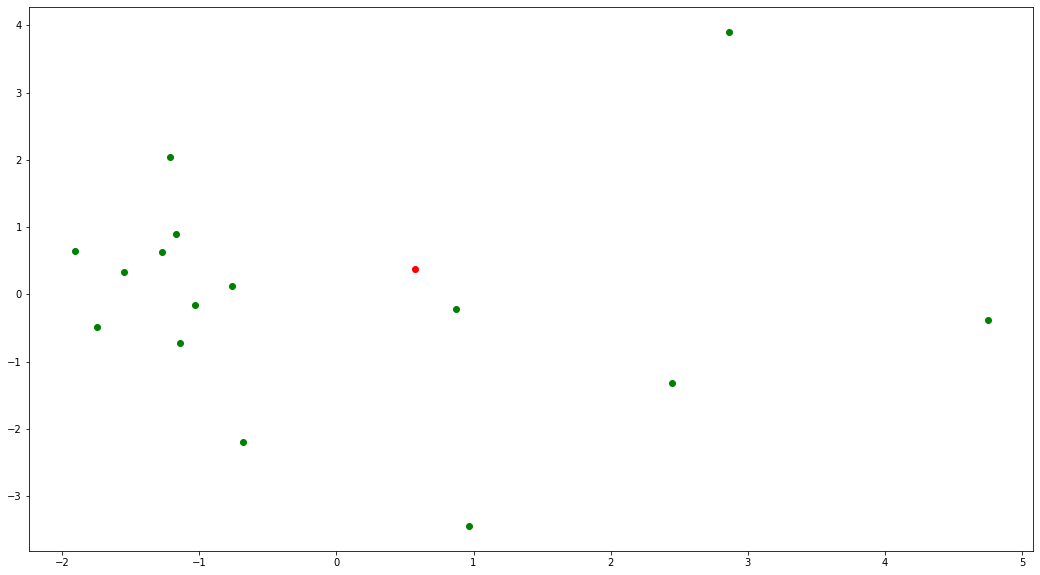

179 spa_zero_2


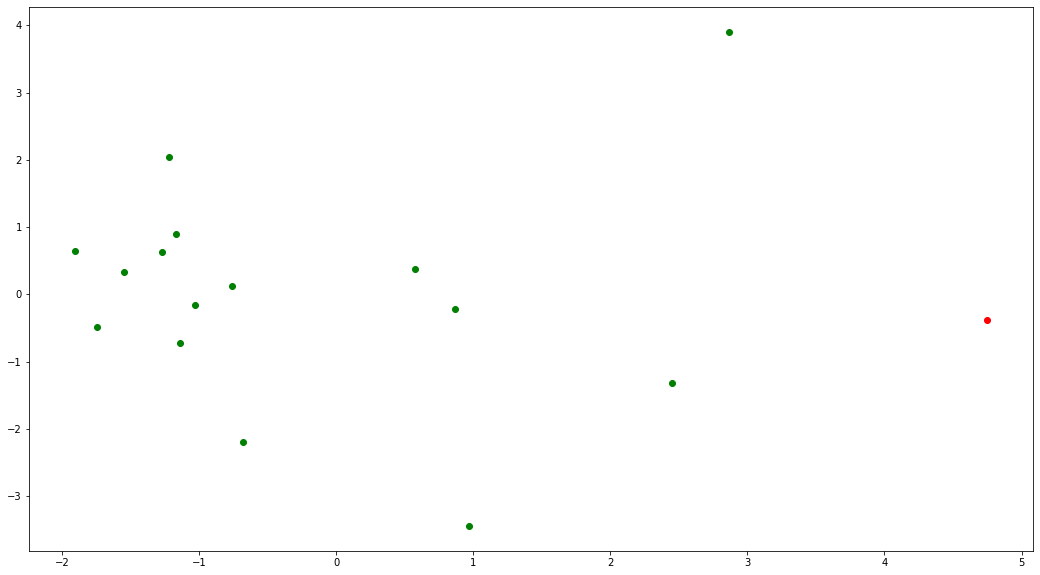

180 spa_other_0


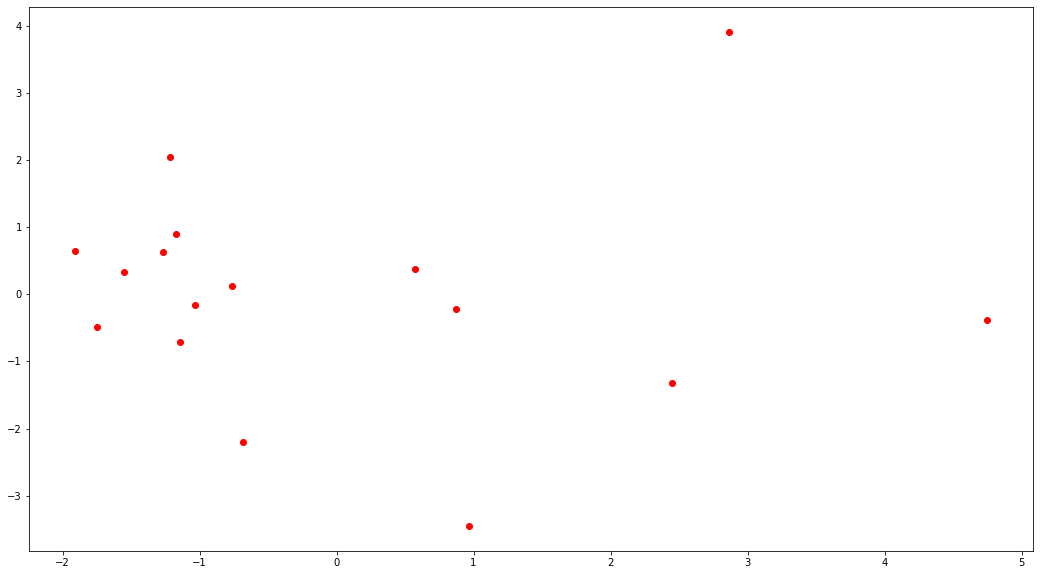

181 srp_u_9


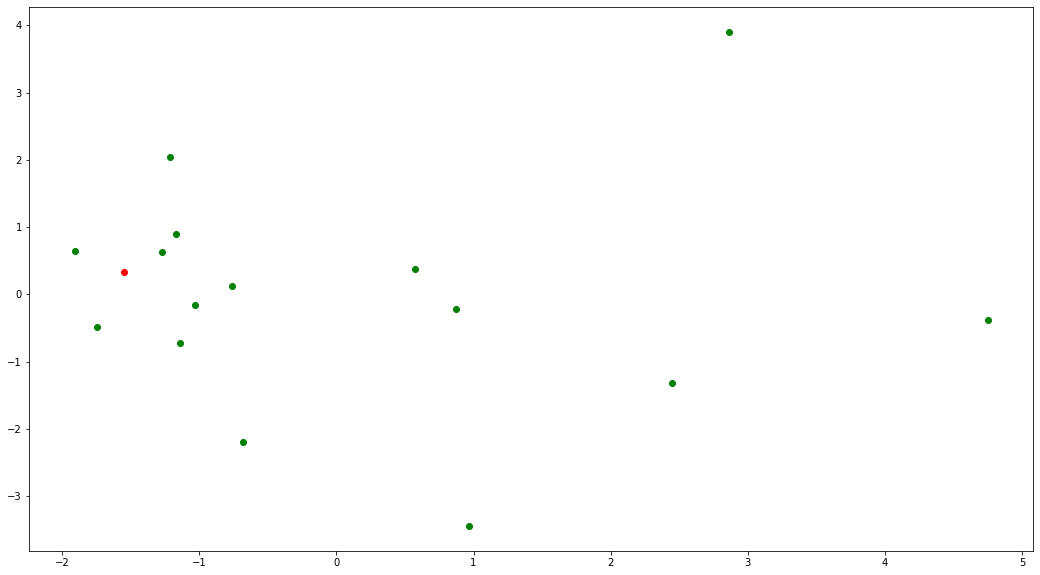

182 srp_u_1


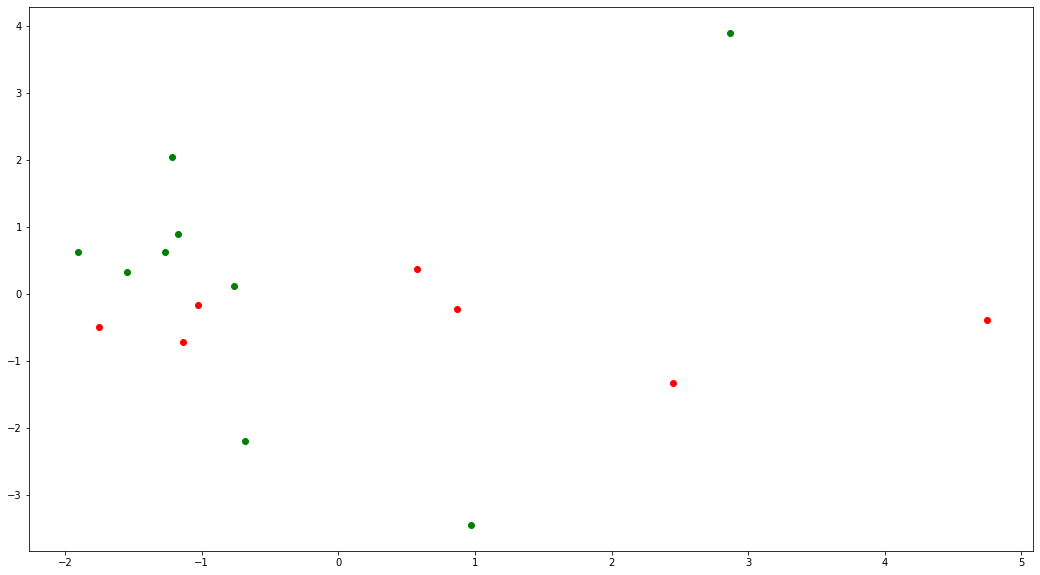

183 srp_u_8


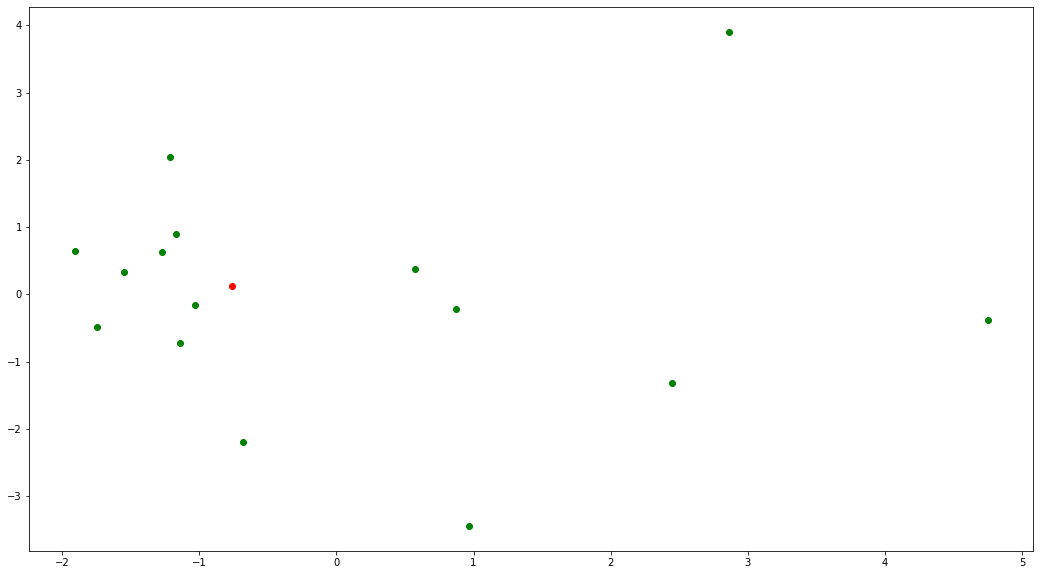

184 srp_u_0


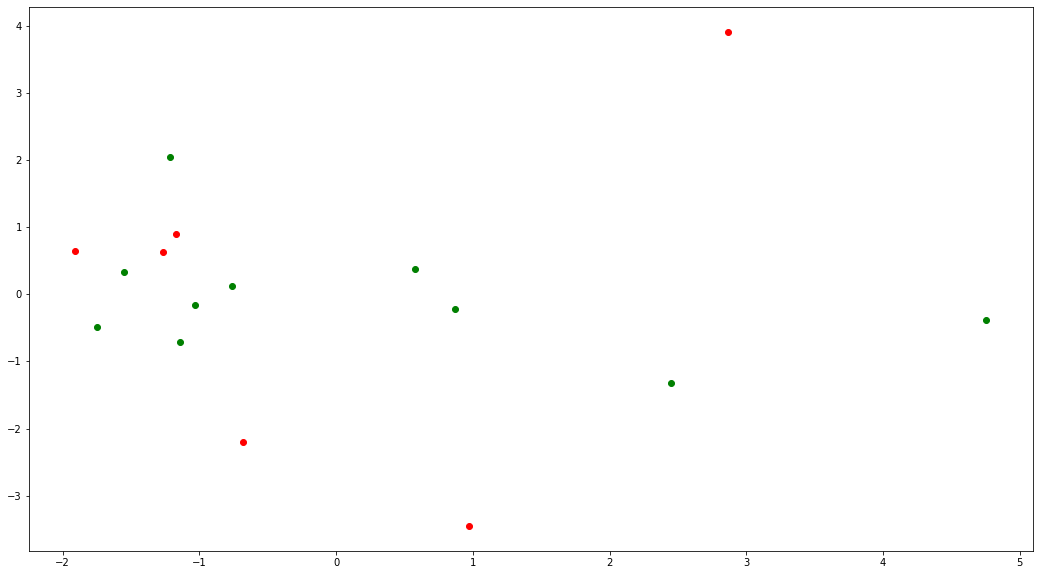

185 srp_u_2


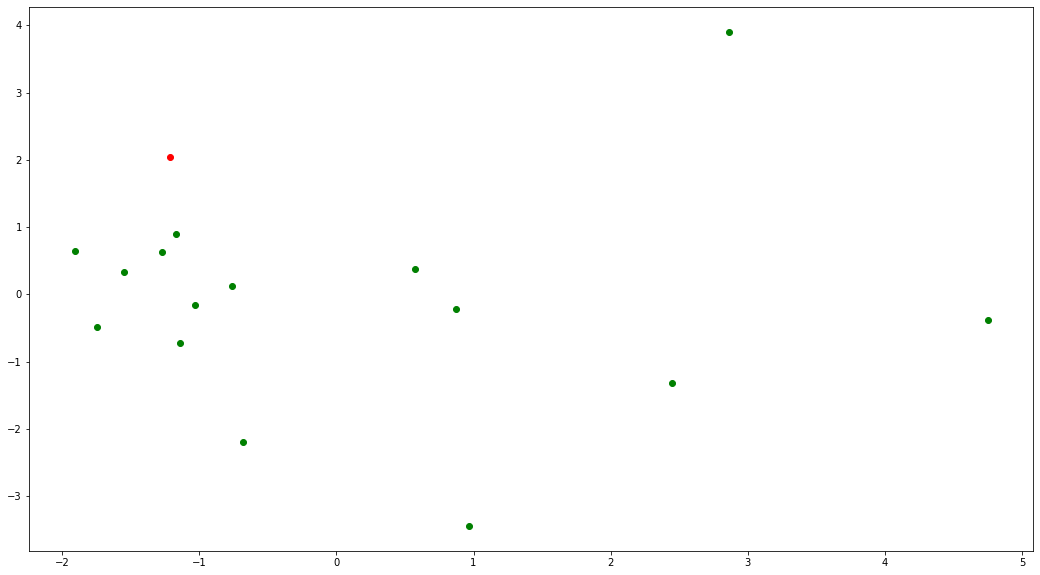

186 srp_na_3


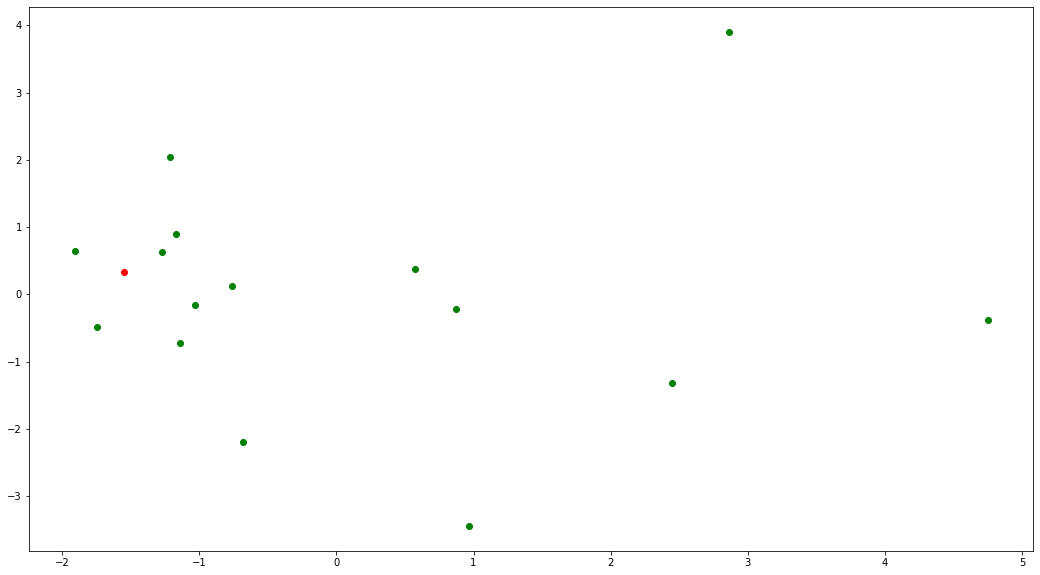

187 srp_na_0


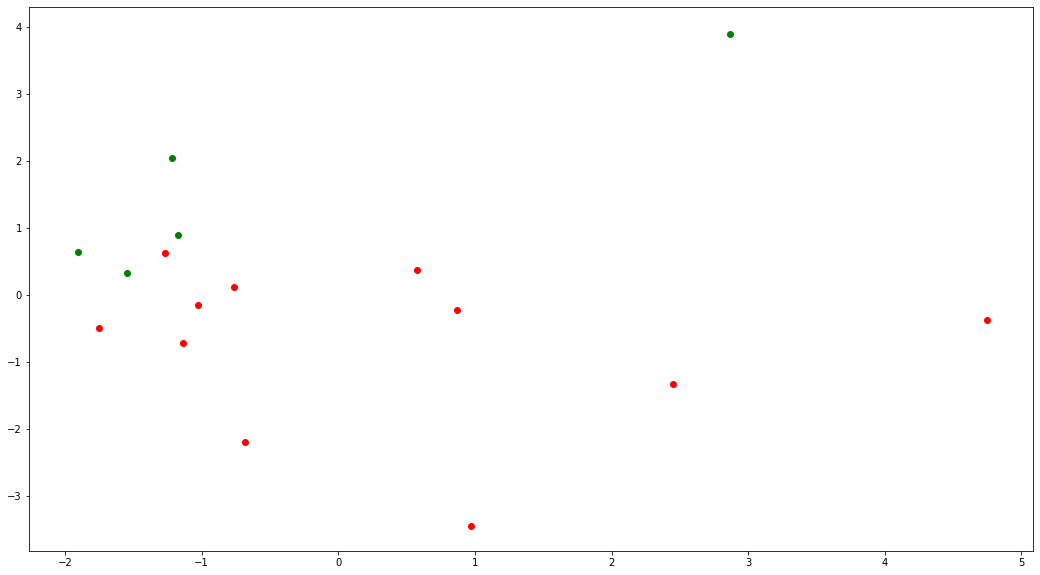

188 srp_na_6


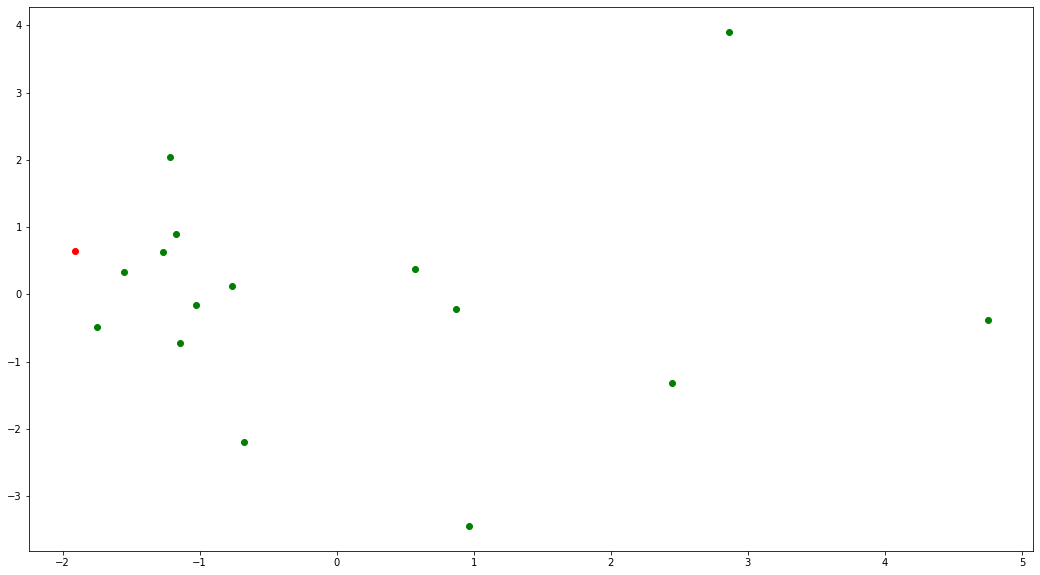

189 srp_na_2


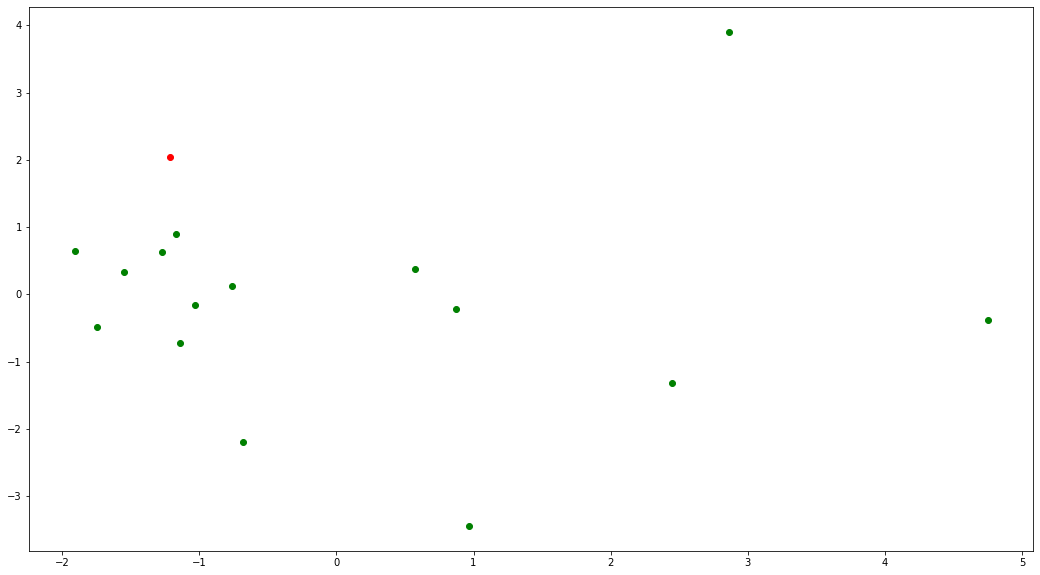

190 srp_na_1


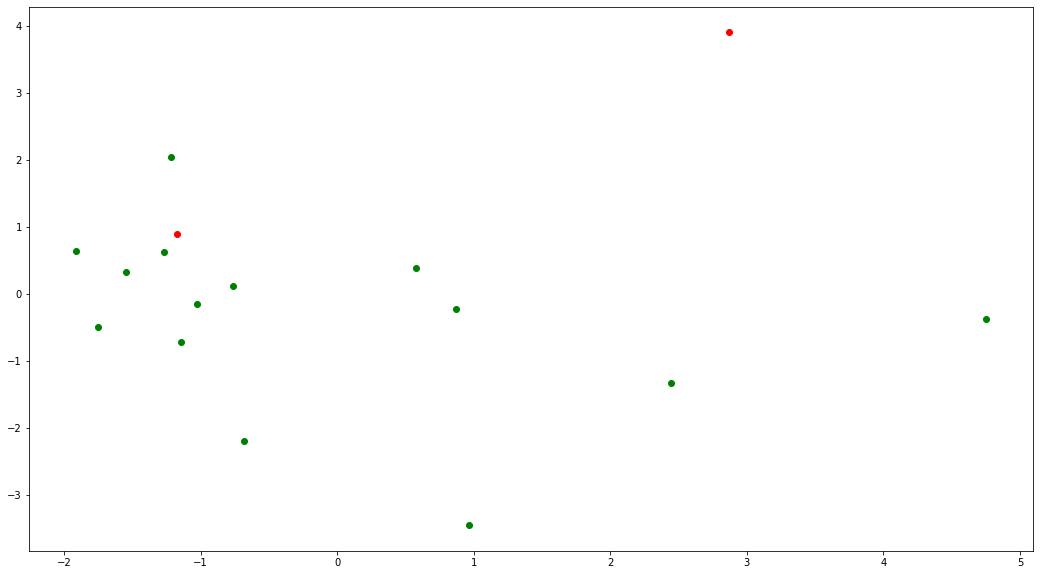

191 srp_za_0


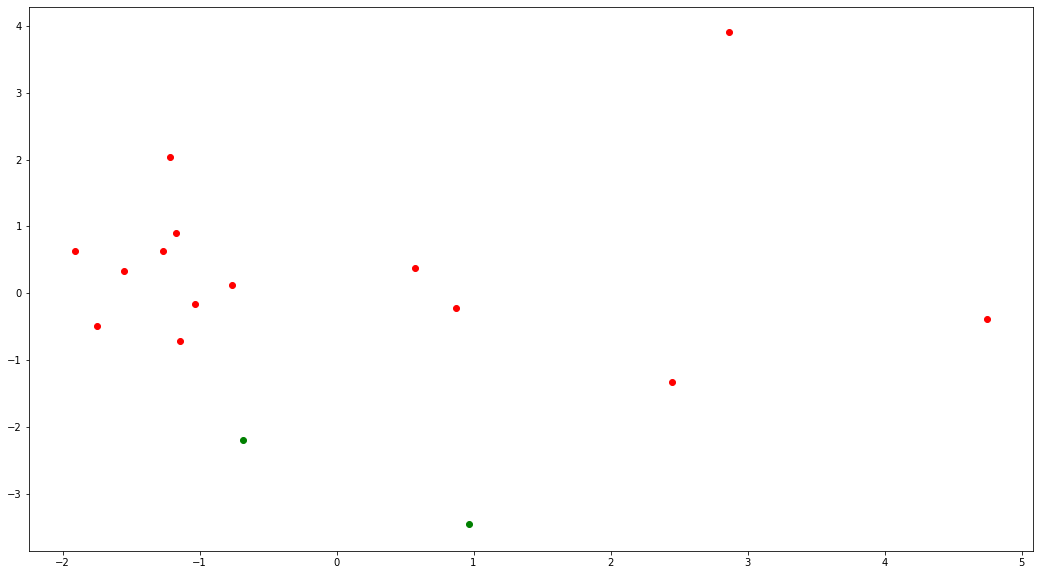

192 srp_za_1


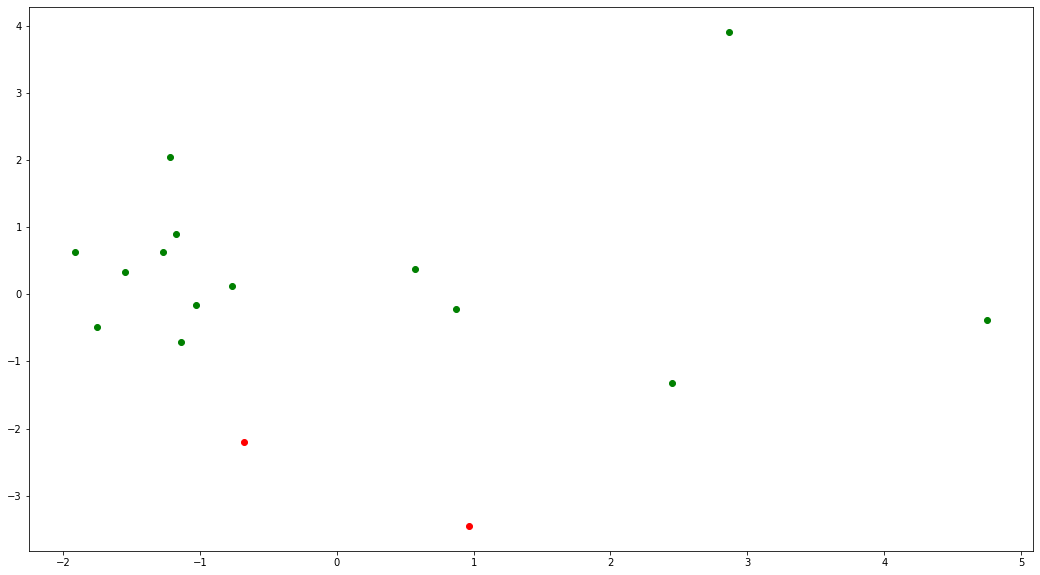

193 srp_zero_0


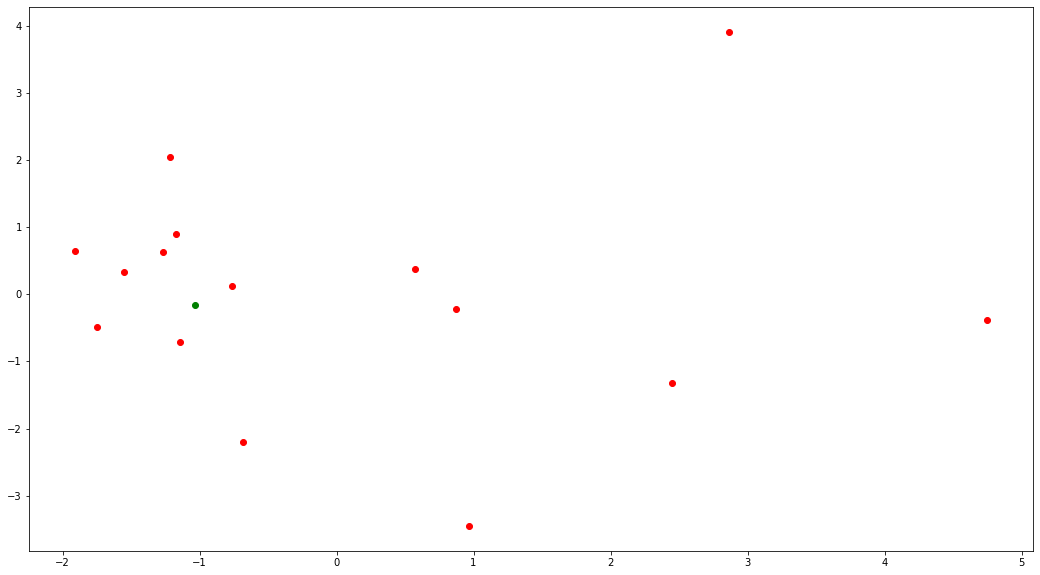

194 srp_zero_1


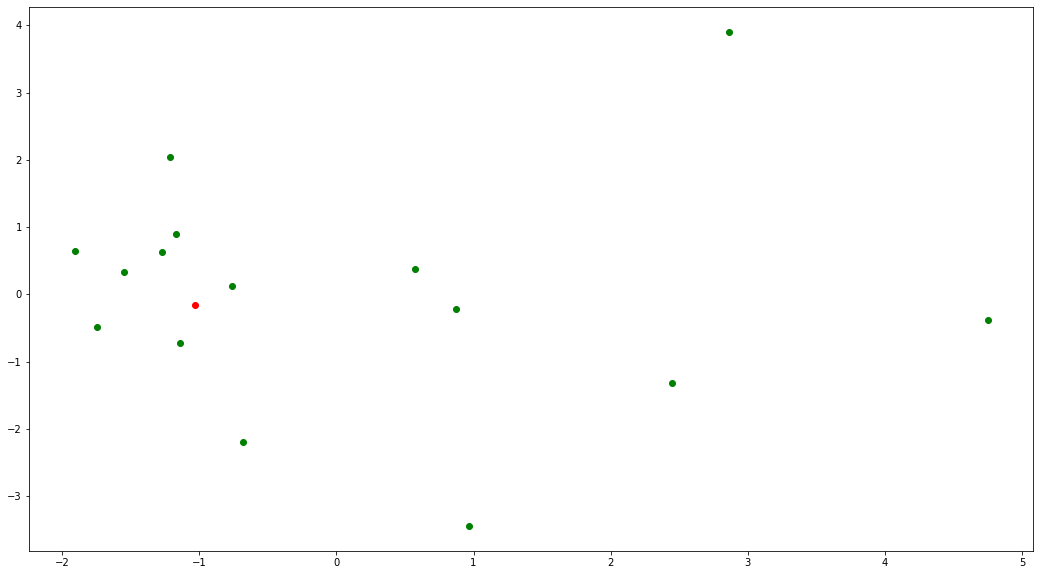

195 hun_-ban_7


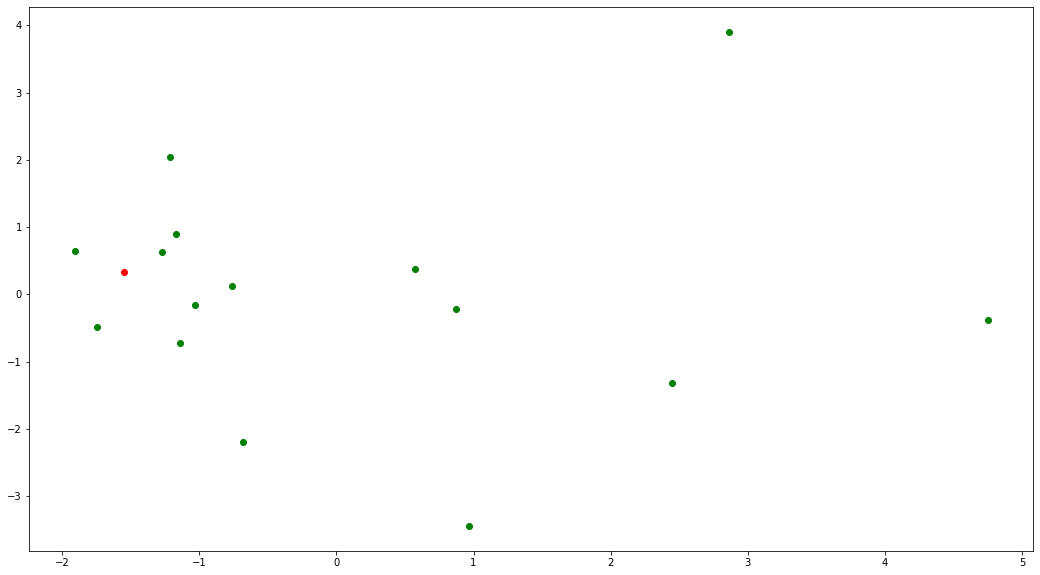

196 hun_-ban_1


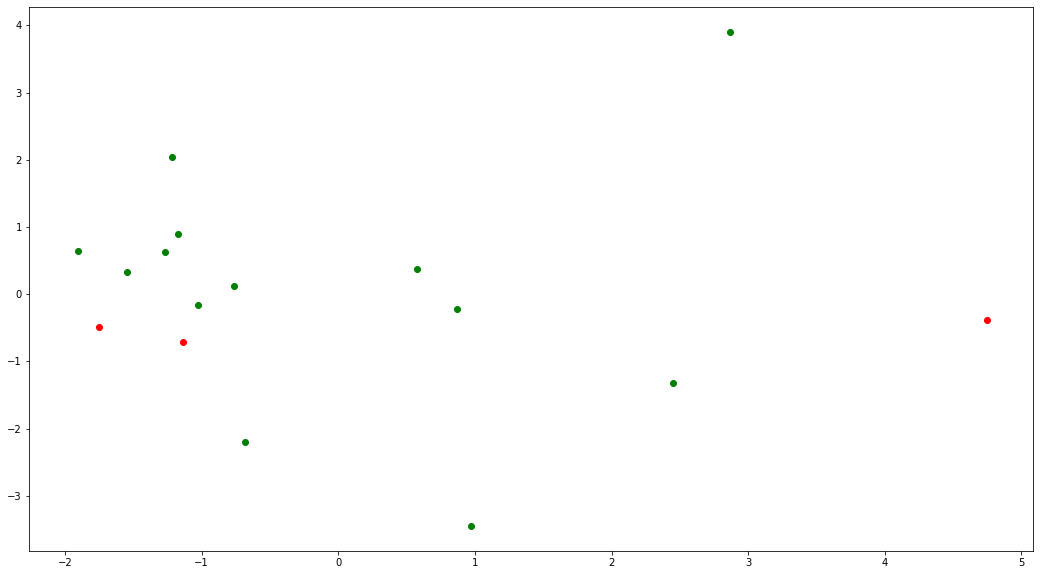

197 hun_-ban_6


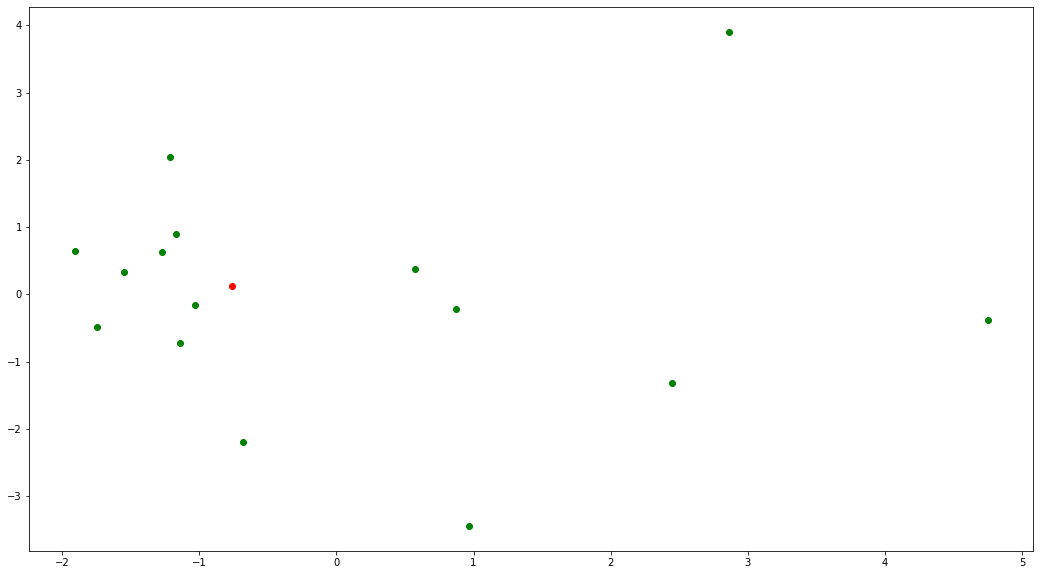

198 hun_-ban_0


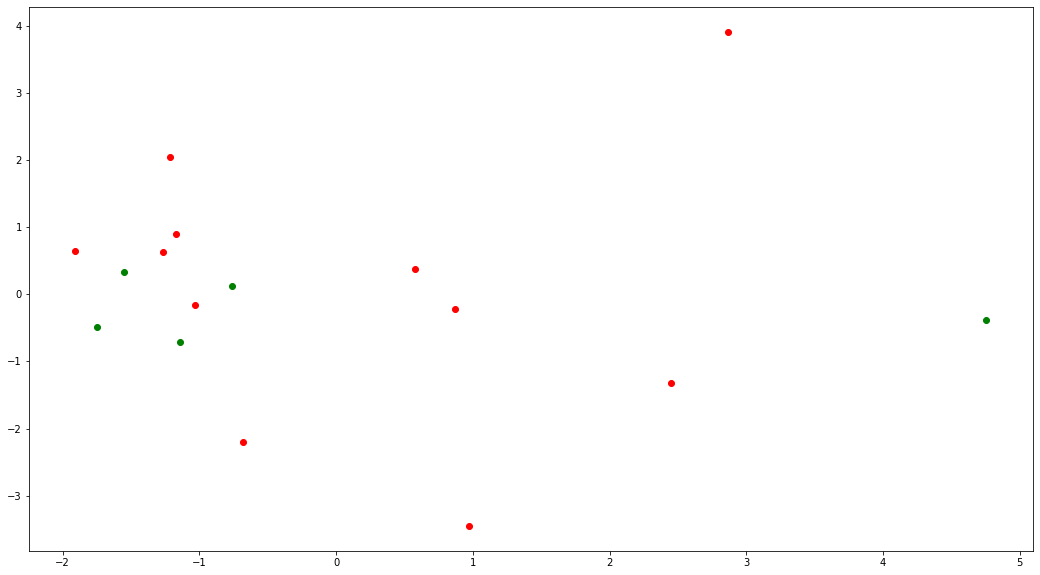

199 hun_-n_3


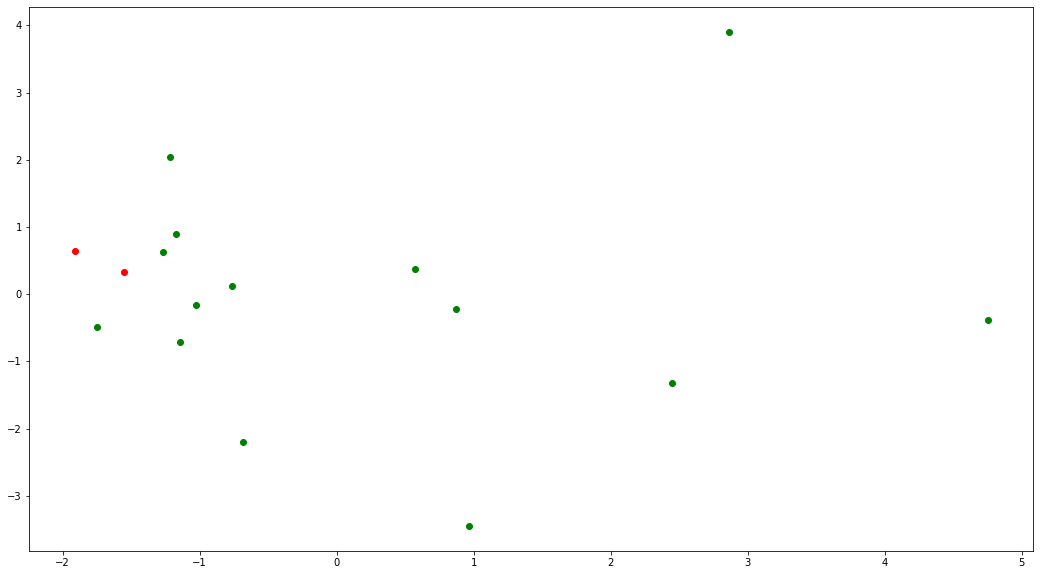

200 hun_-n_0


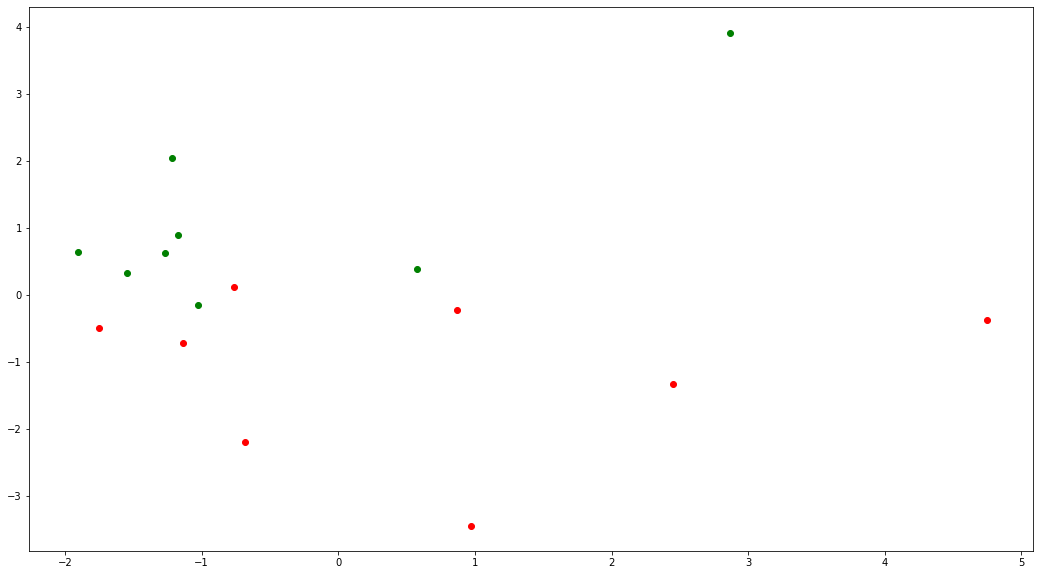

201 hun_-n_2


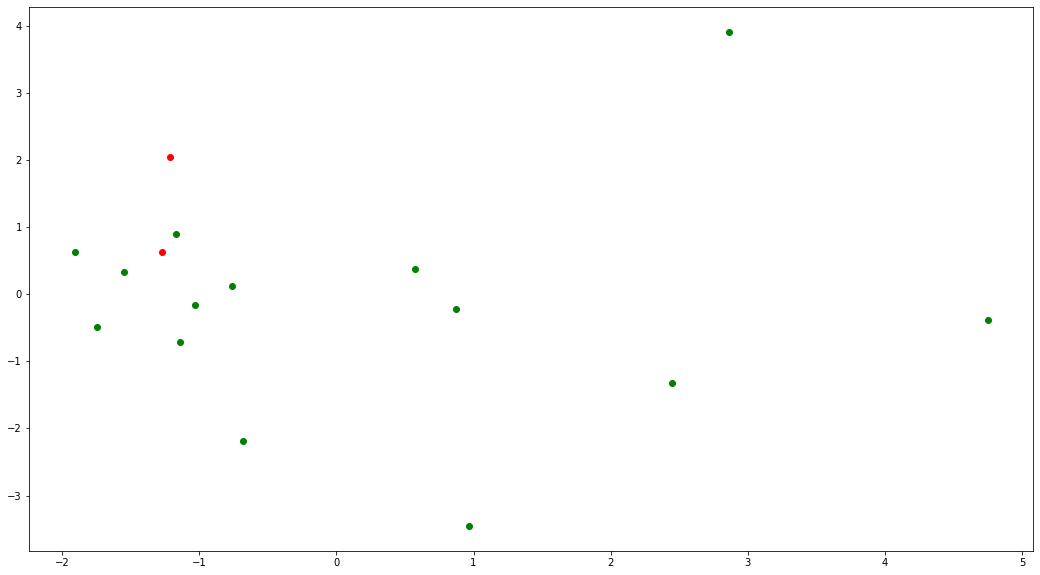

202 hun_-n_1


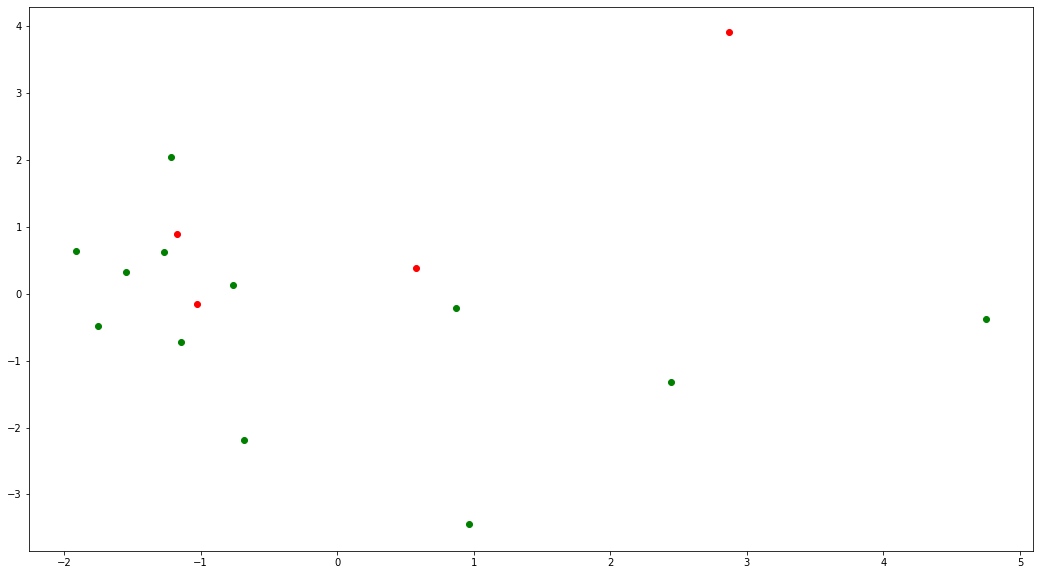

203 hun_-kor_0


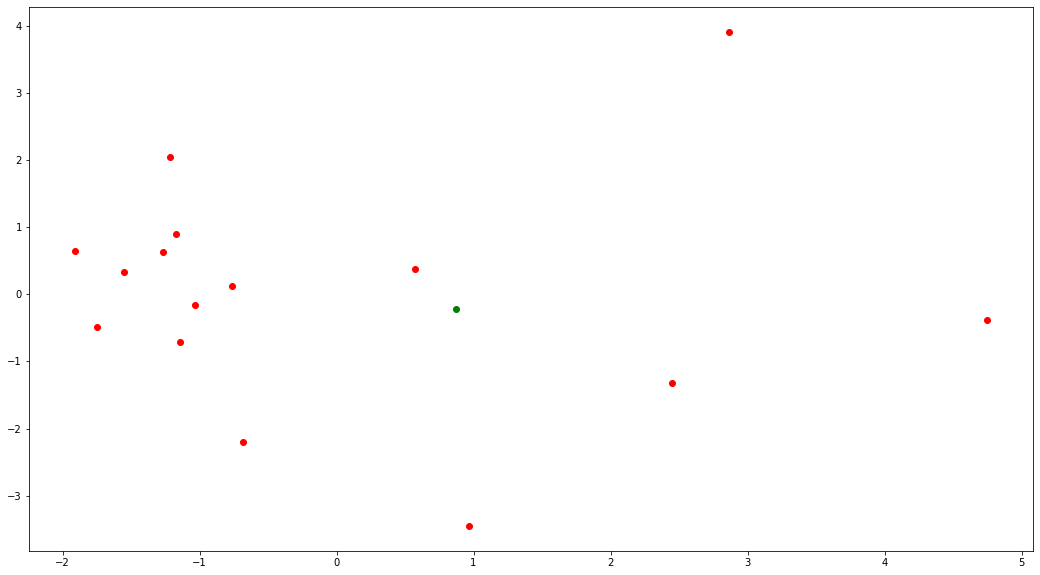

204 hun_-kor_1


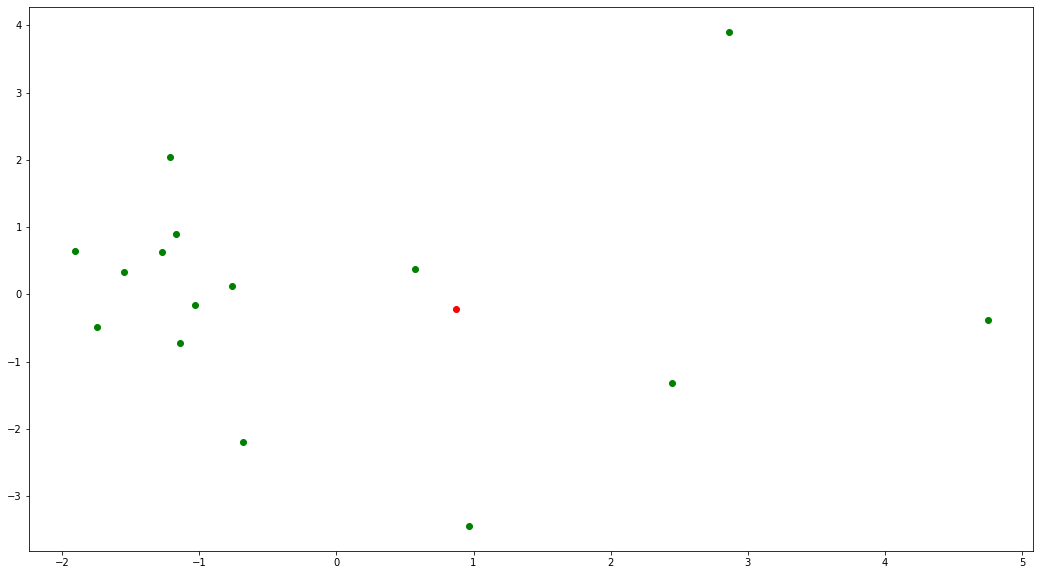

205 hun_szal_0


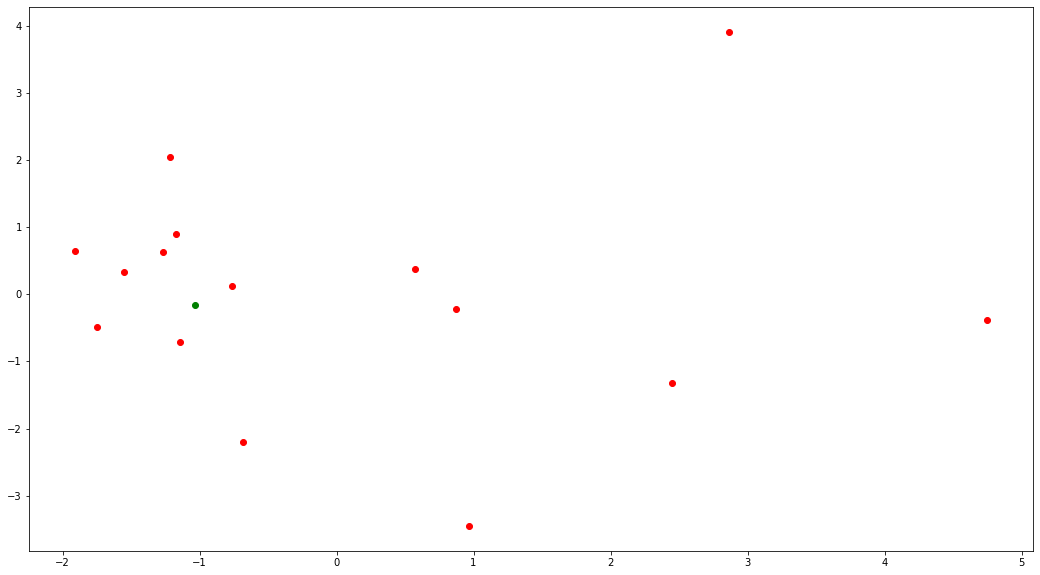

206 hun_szal_1


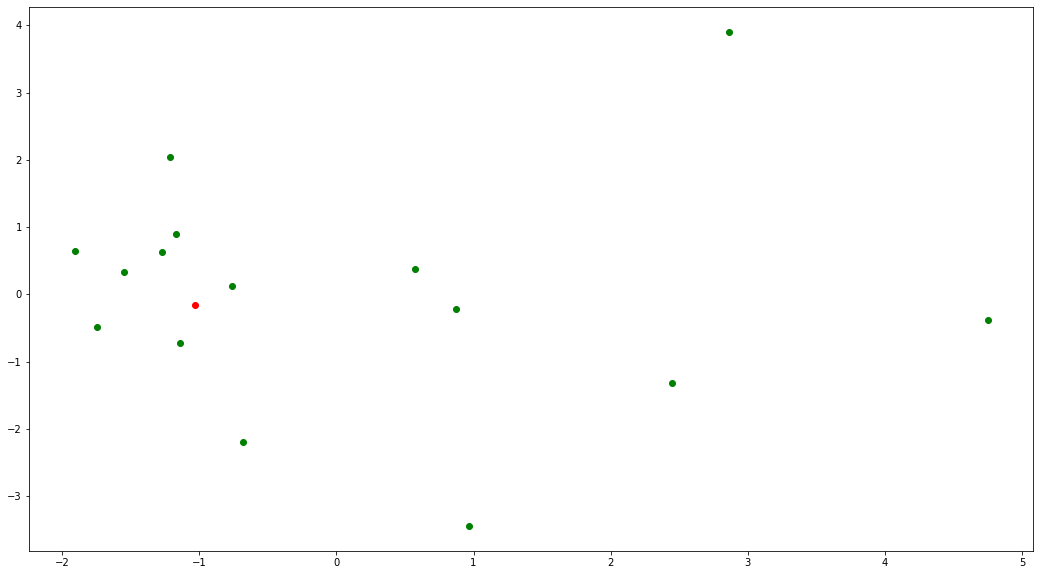

207 hun_mulva_0


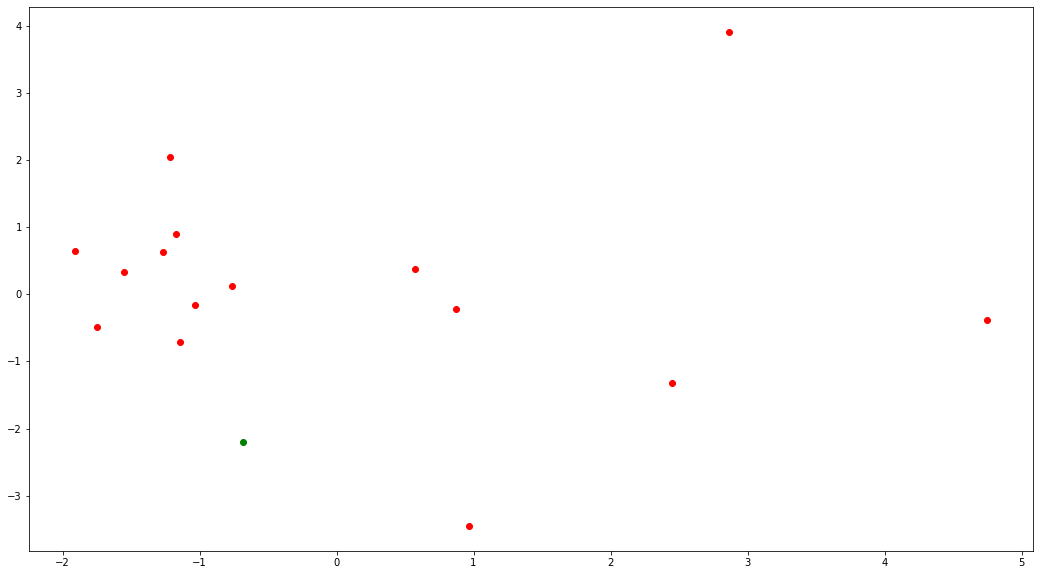

208 hun_mulva_1


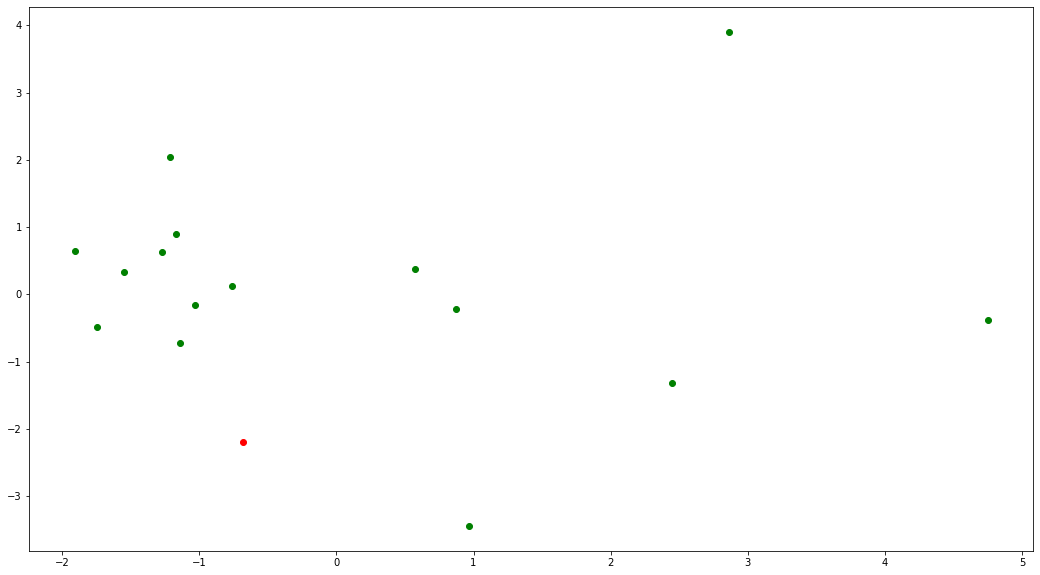

209 hun_alatt_0


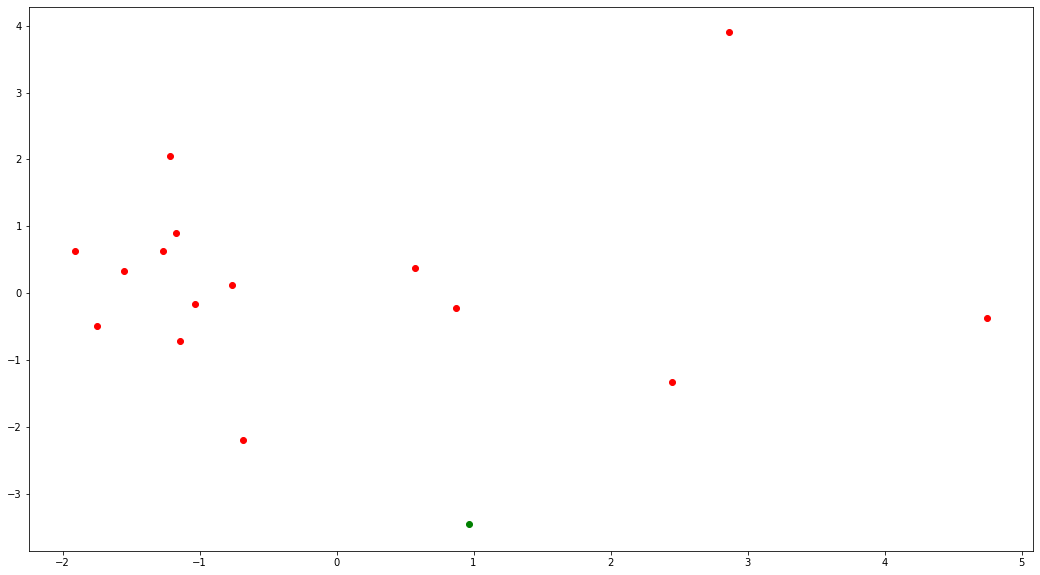

210 hun_alatt_1


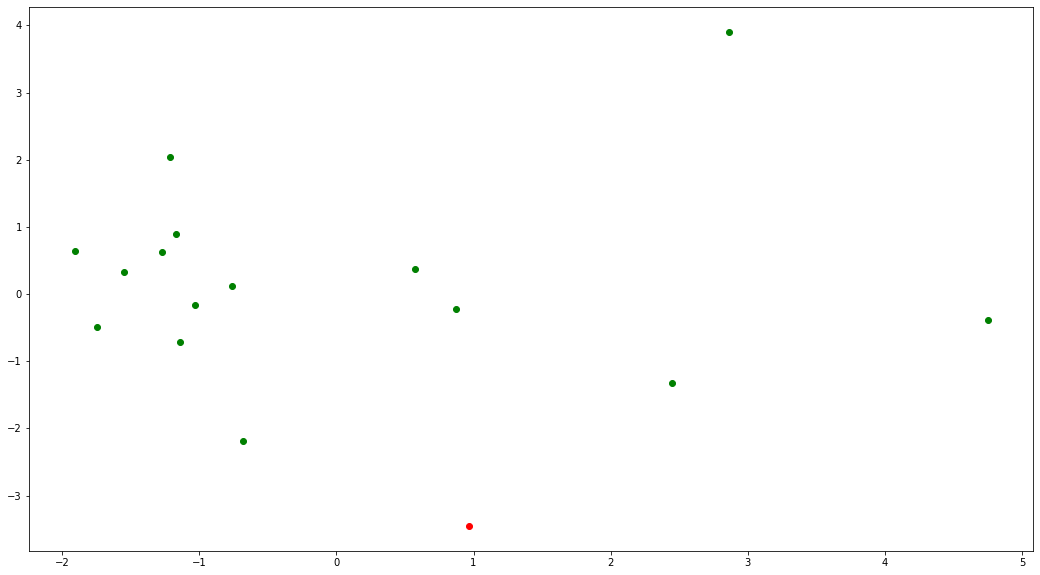

211 hun_other_0


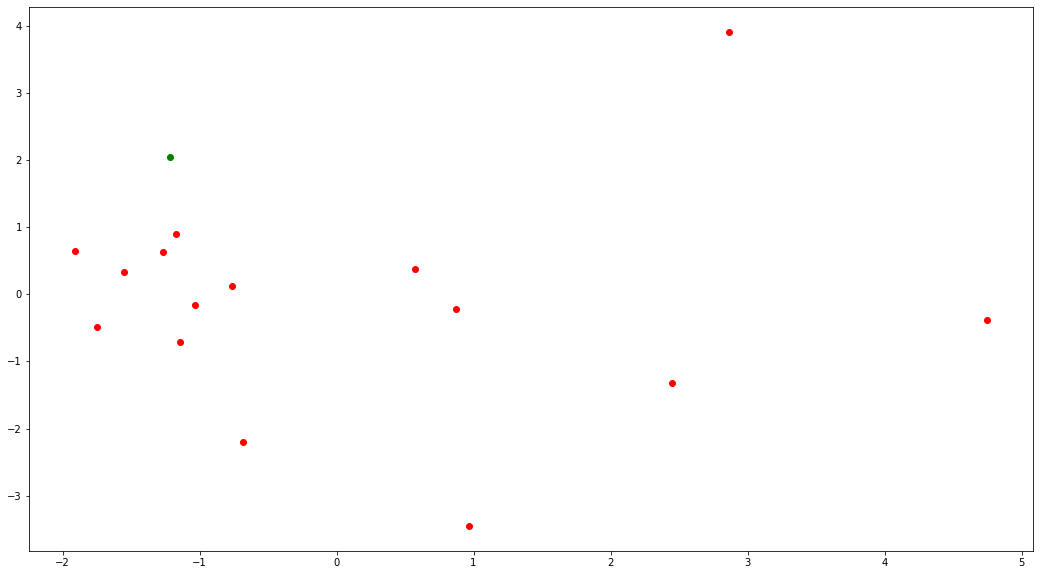

212 hun_other_1


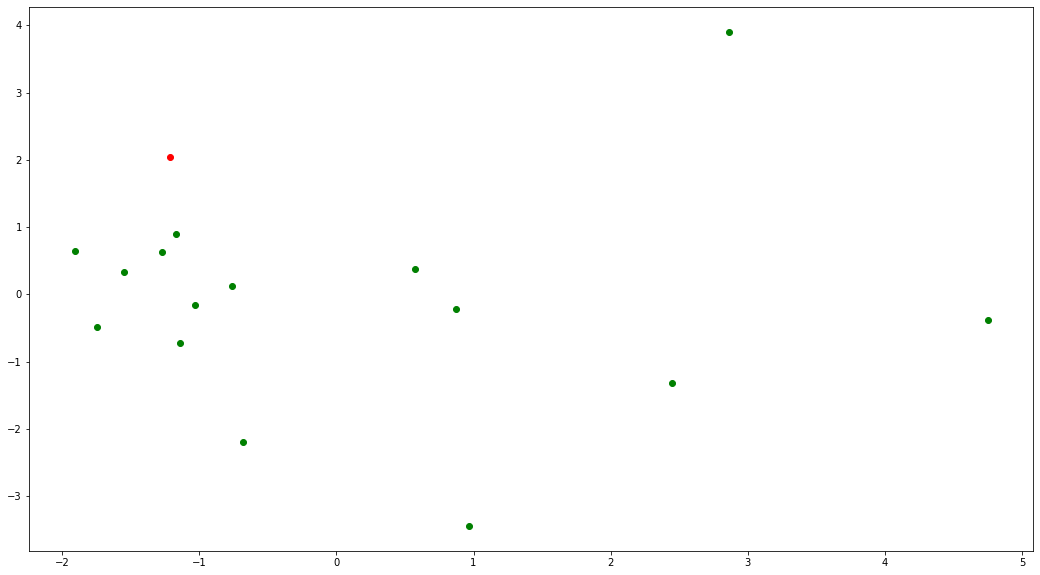

213 hun_zero_0


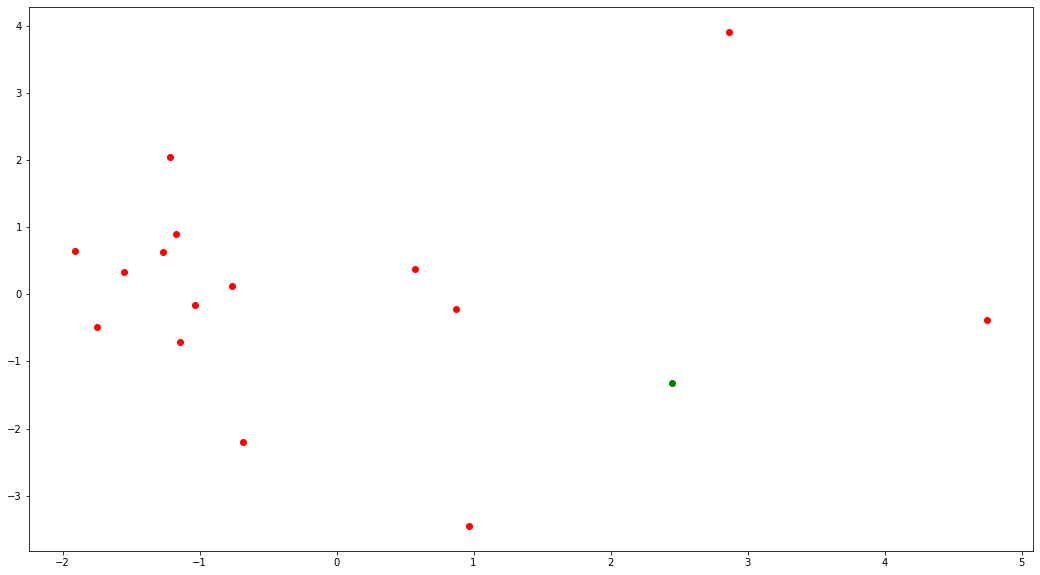

214 hun_zero_1


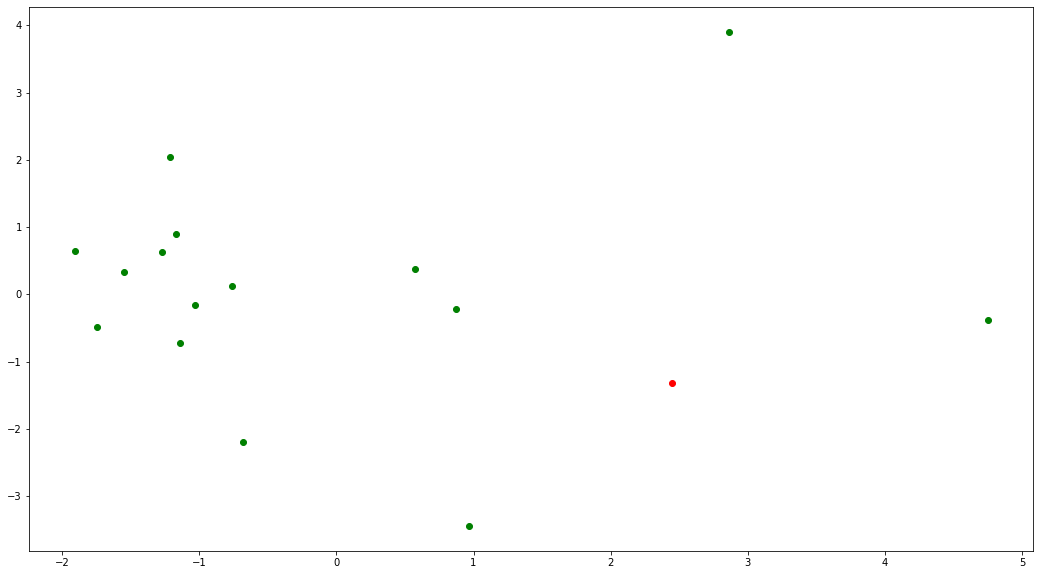

215 swe_i_7


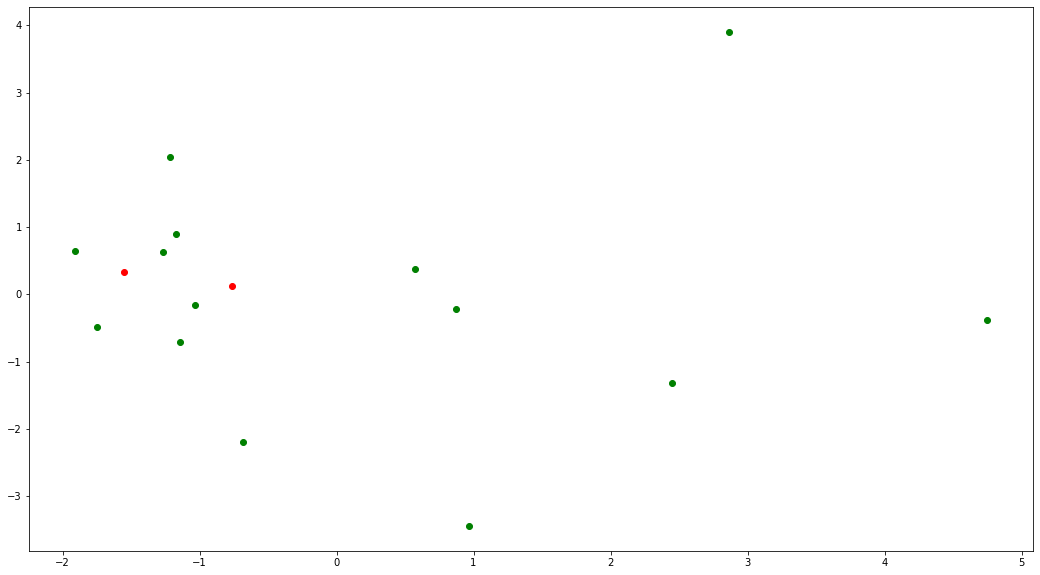

216 swe_i_1


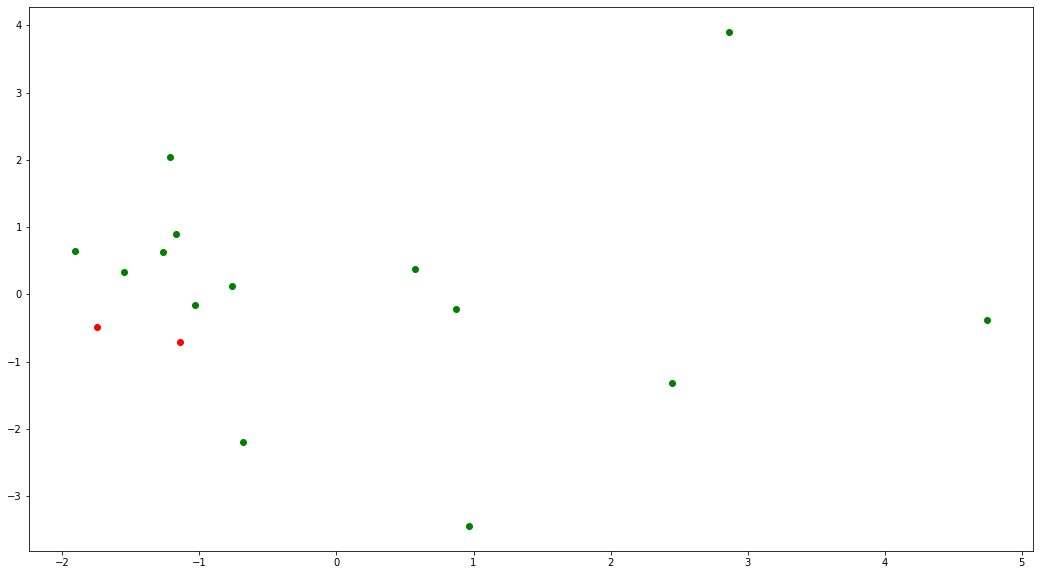

217 swe_i_0


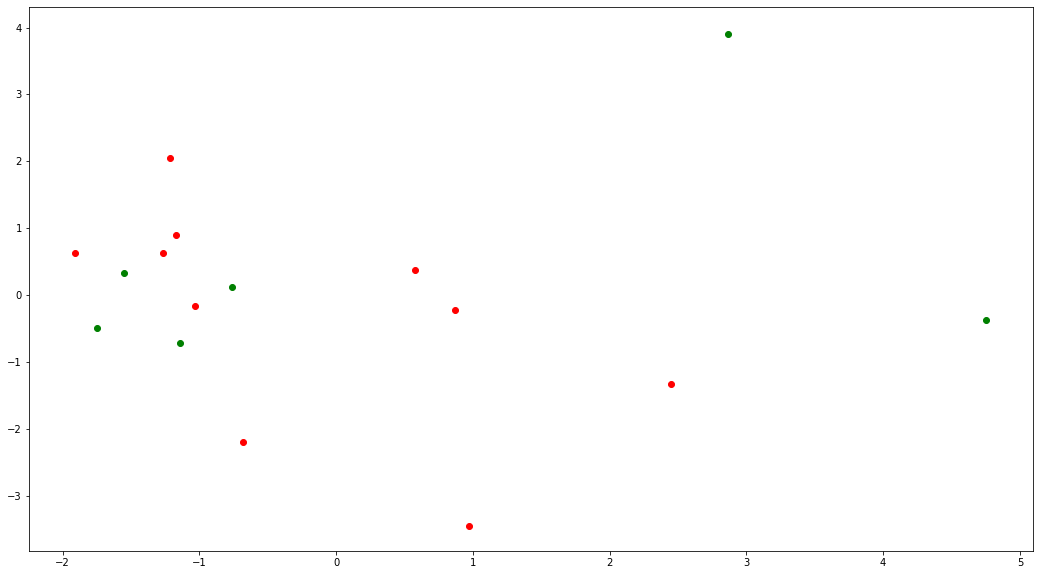

218 swe_i_14


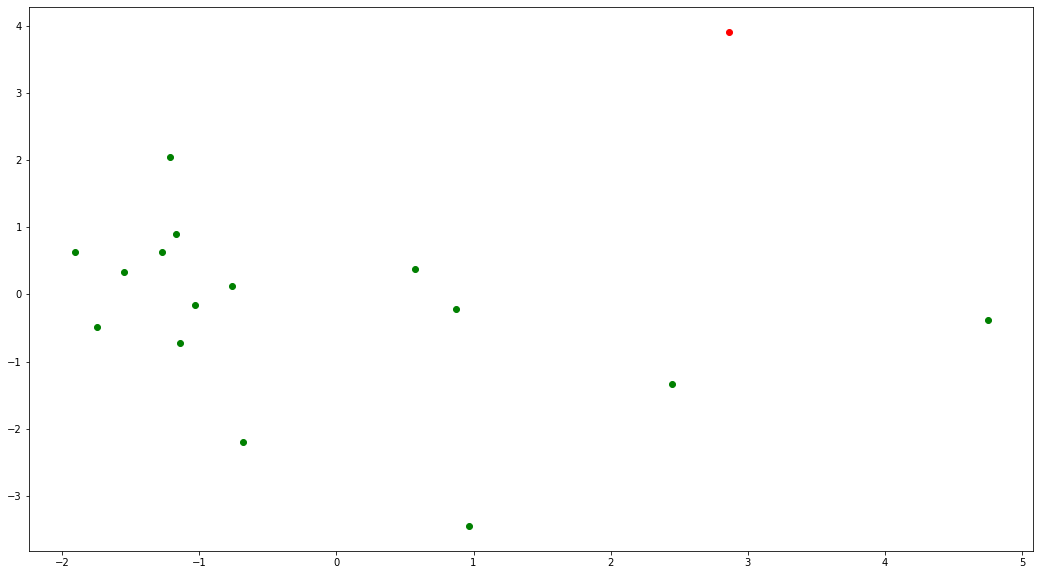

219 swe_i_13


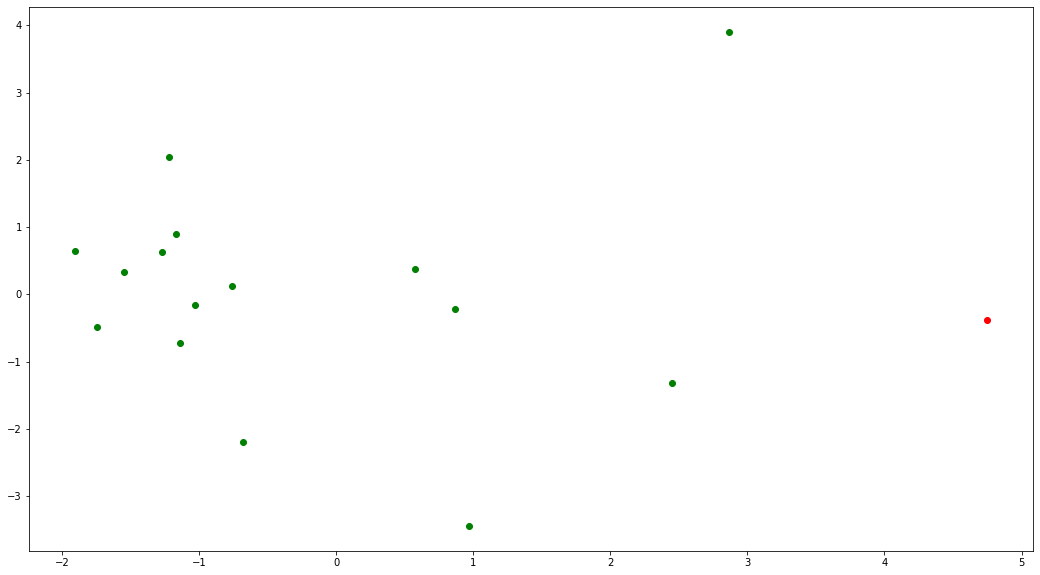

220 swe_på_4


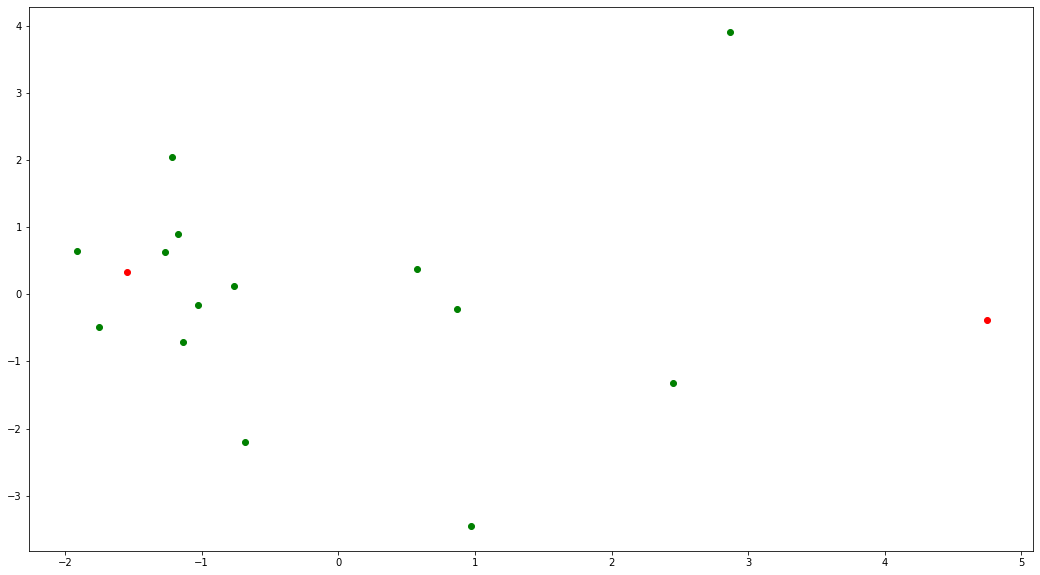

221 swe_på_0


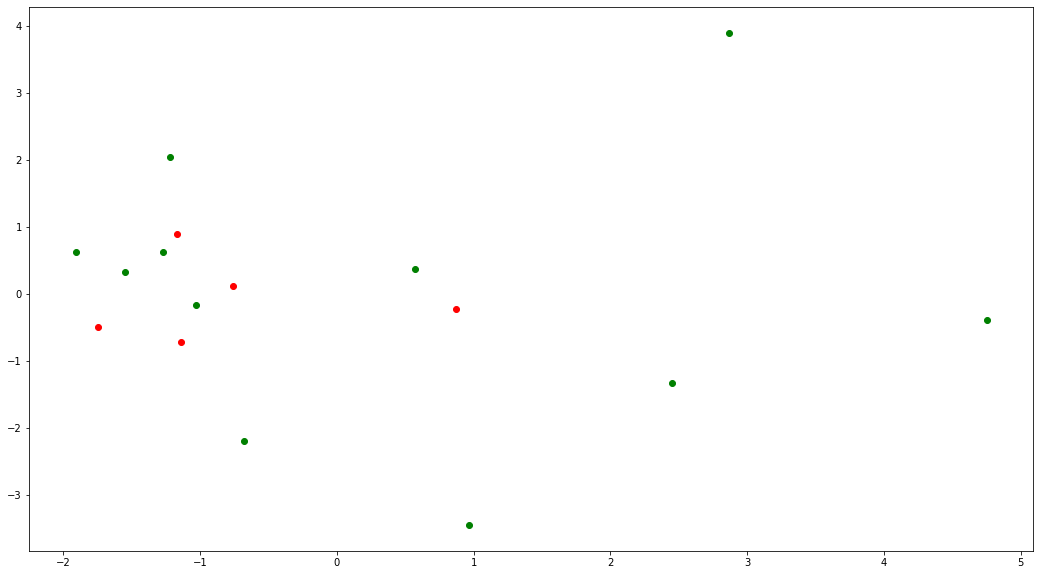

222 swe_på_7


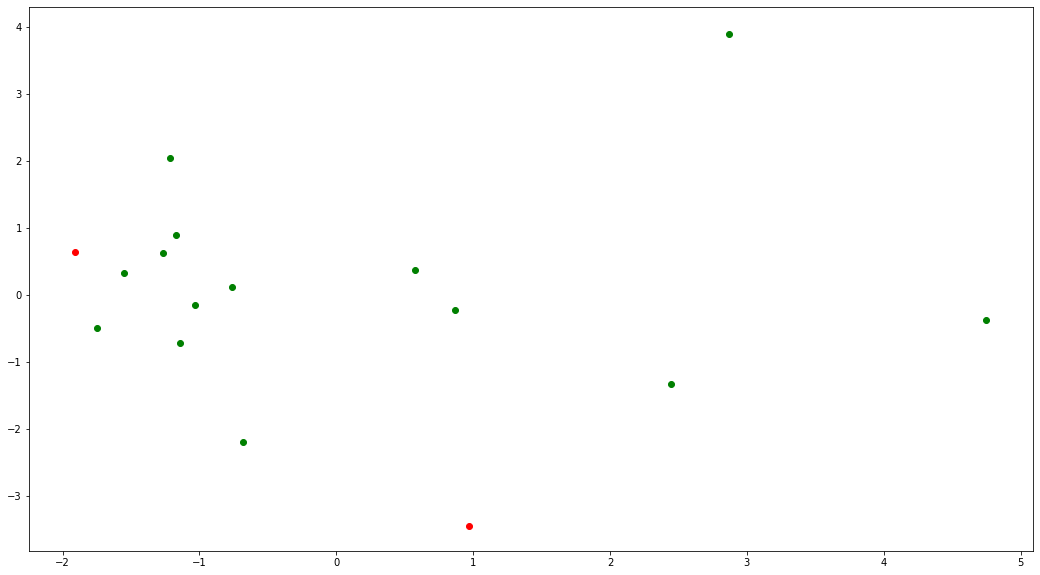

223 swe_på_2


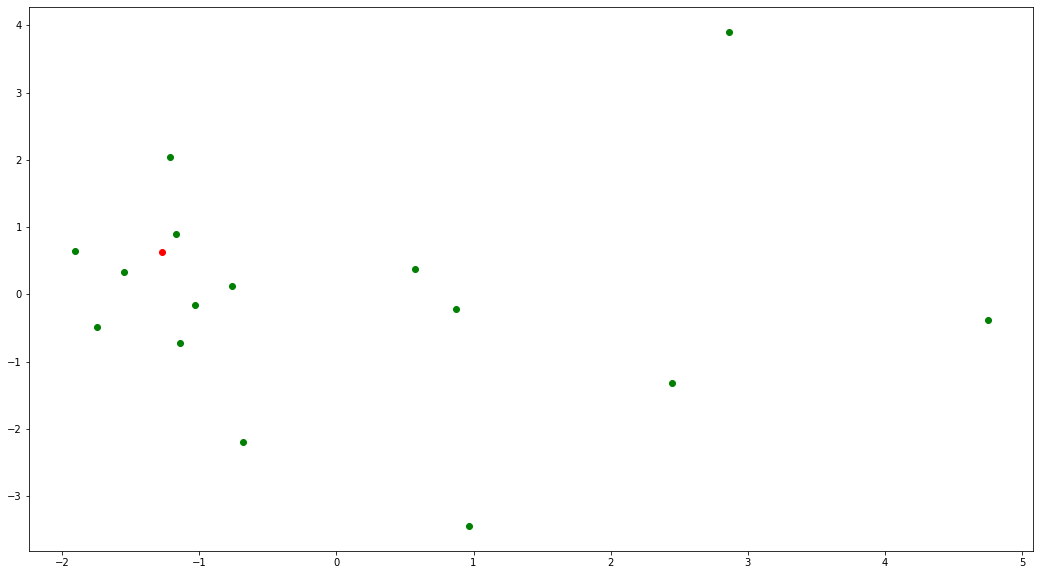

224 swe_på_3


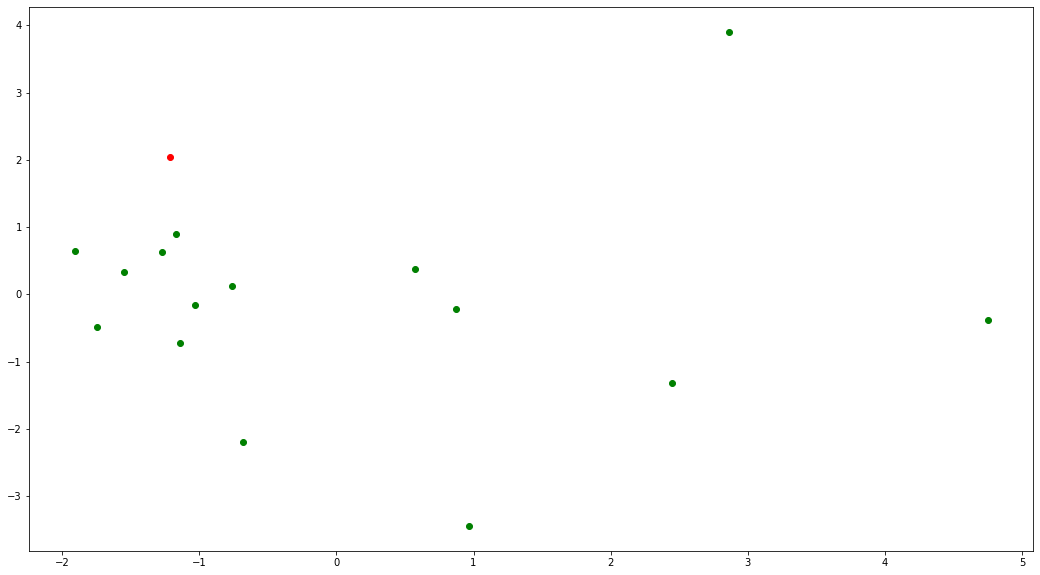

225 swe_på_13


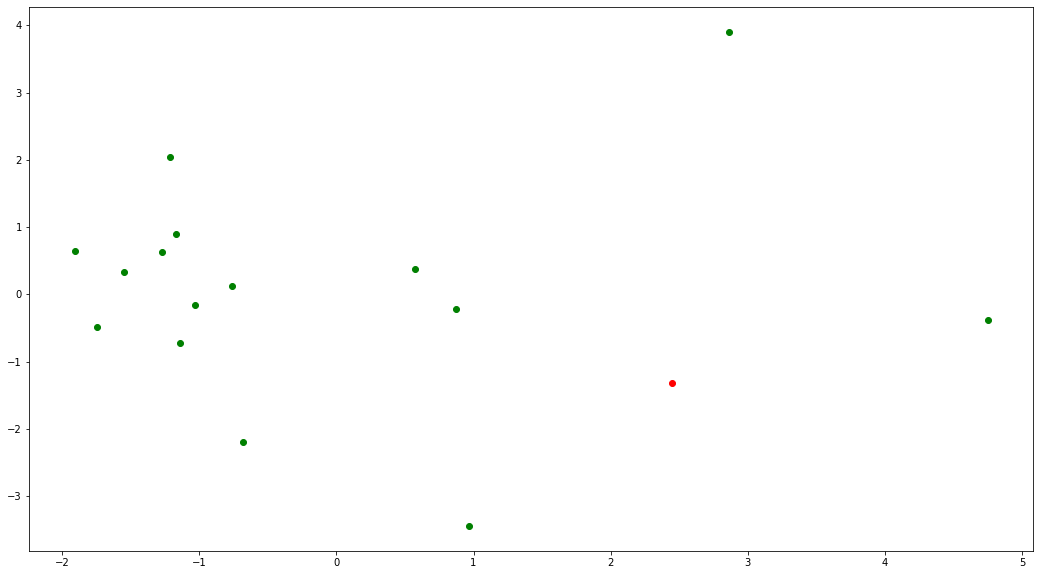

226 swe_på_15


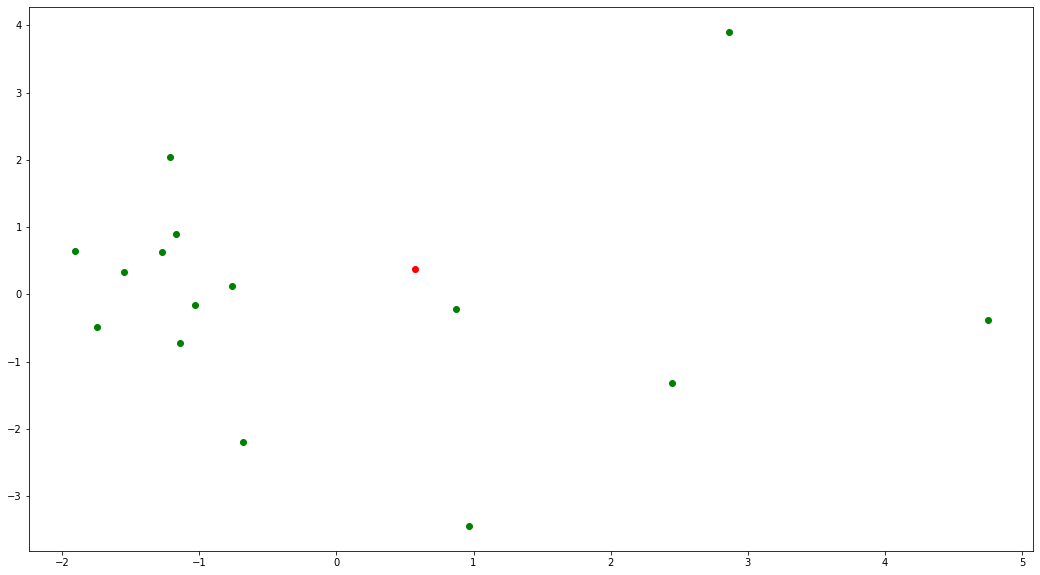

227 swe_på_1


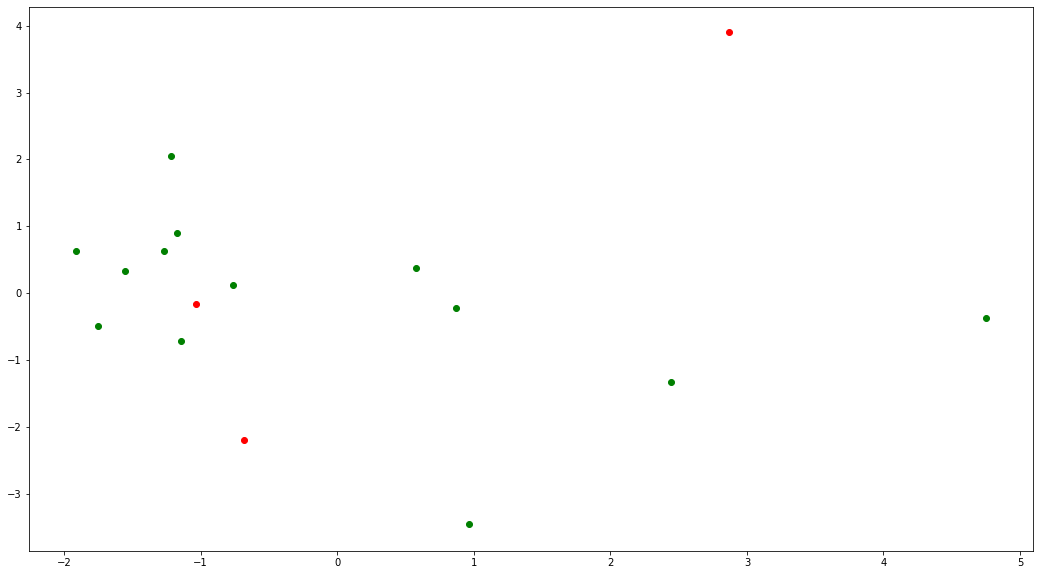

228 swe_vid_0


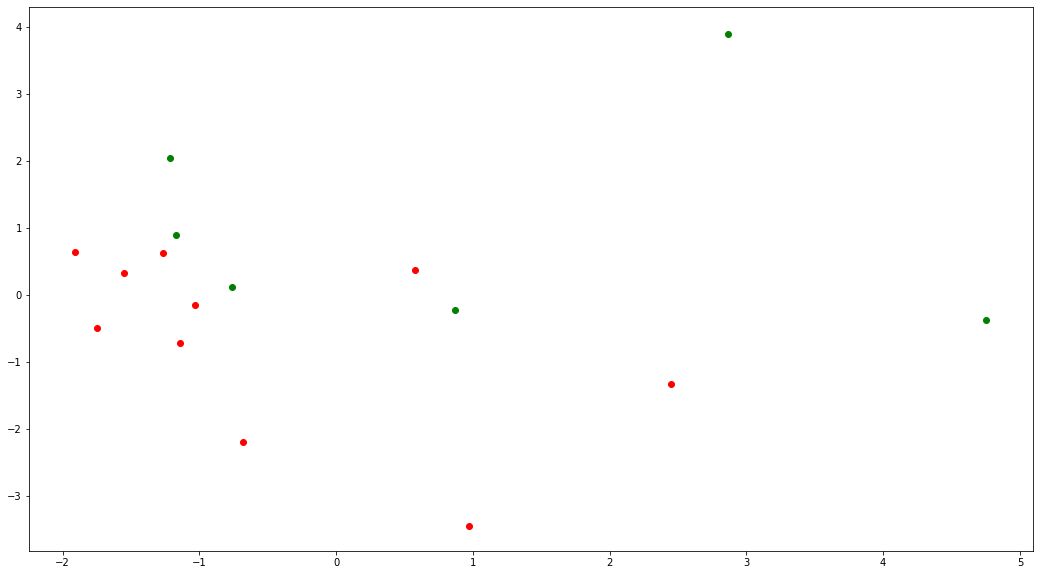

229 swe_vid_1


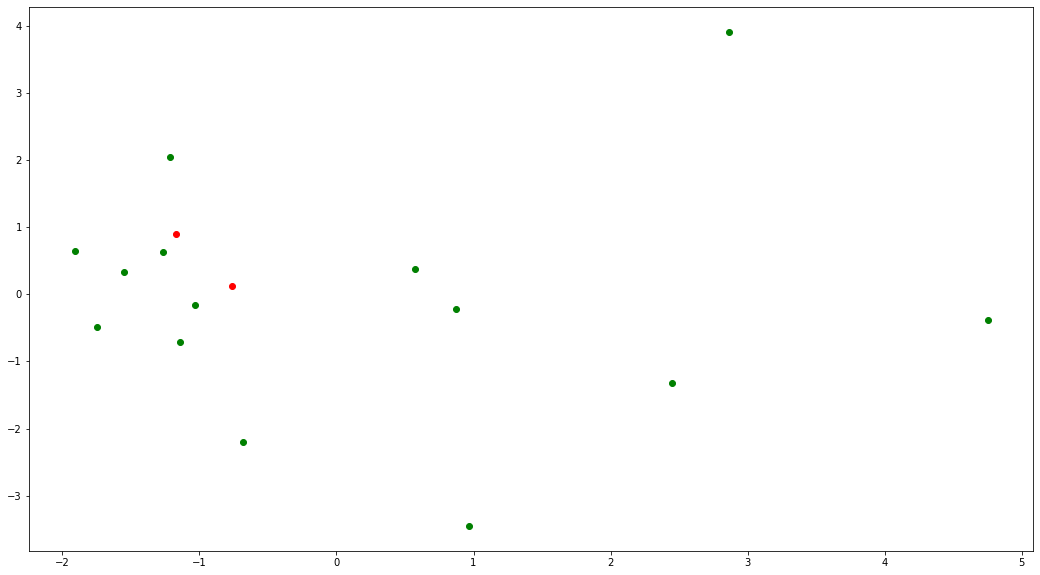

230 swe_vid_3


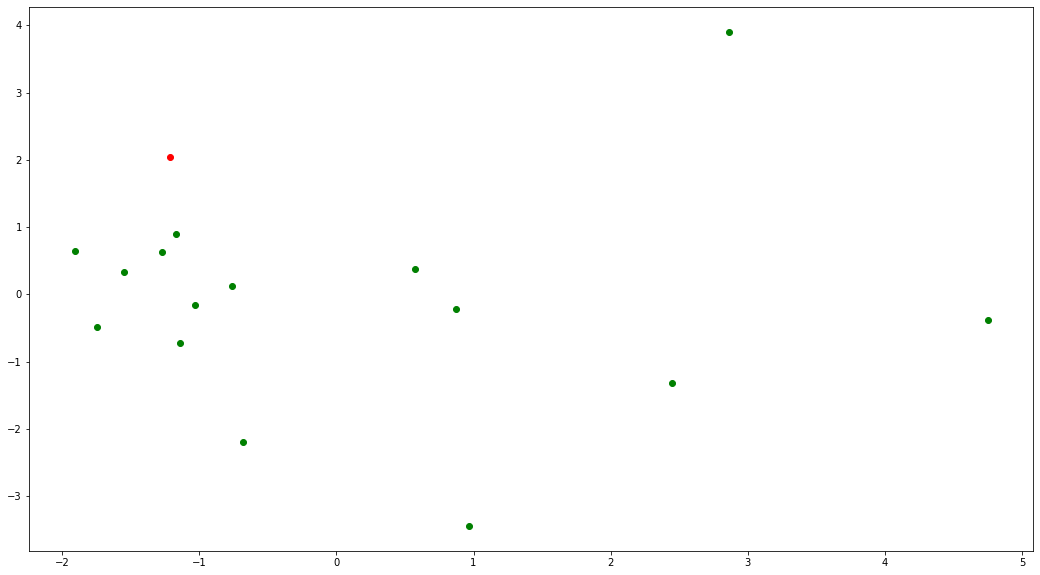

231 swe_vid_6


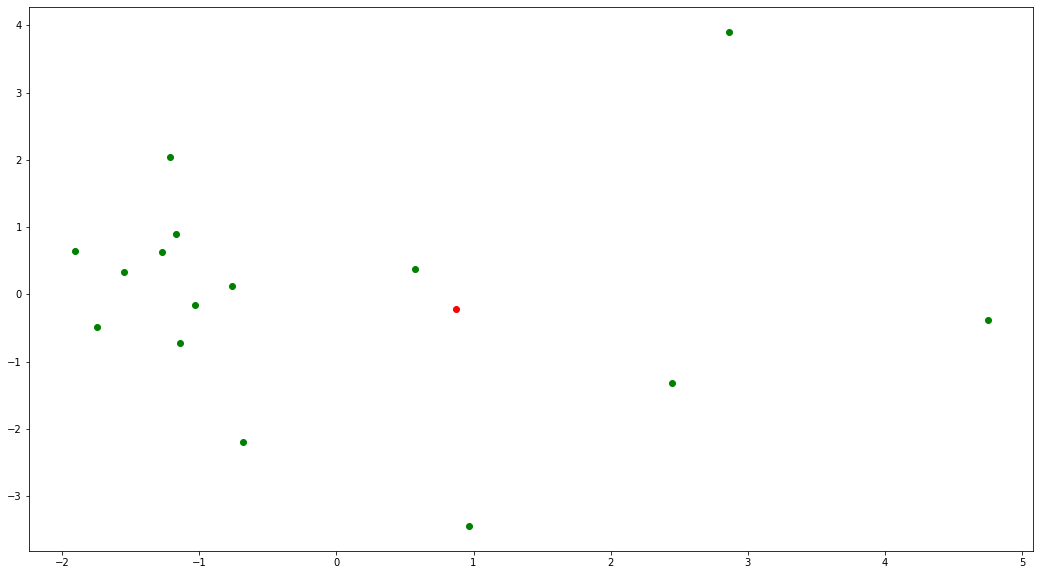

232 swe_vid_8


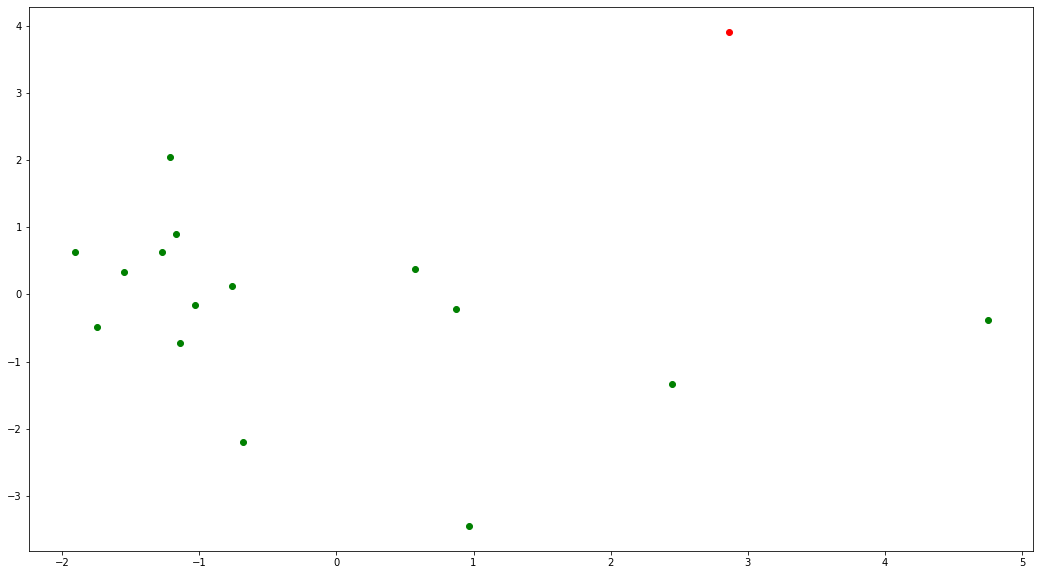

233 swe_vid_2


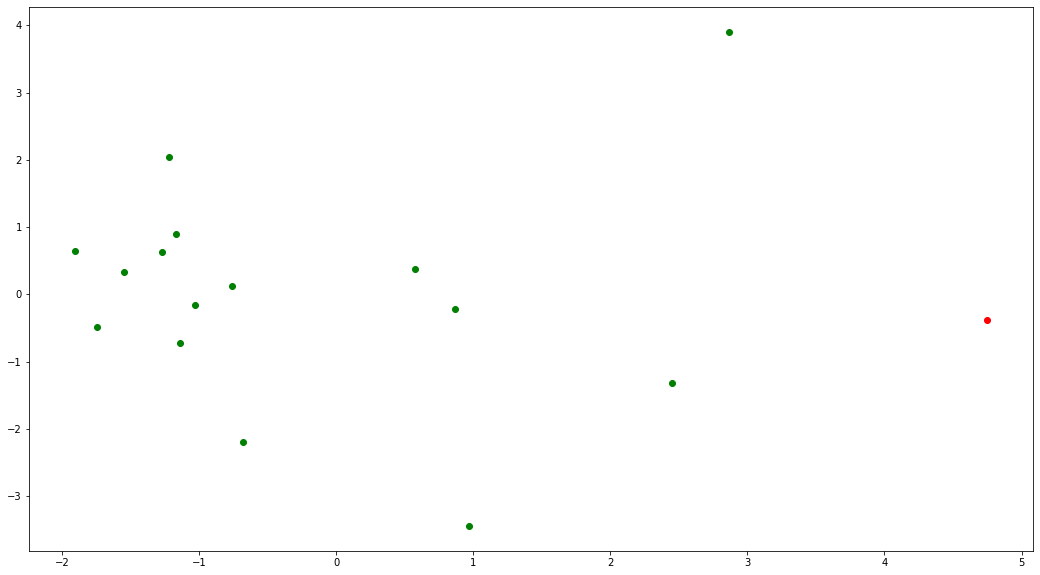

234 swe_om_0


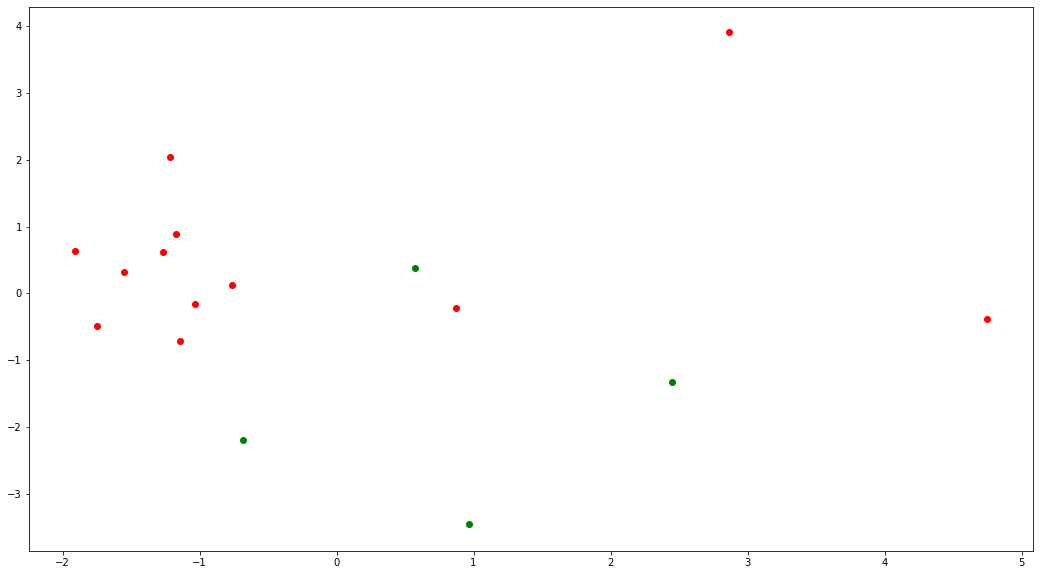

235 swe_om_2


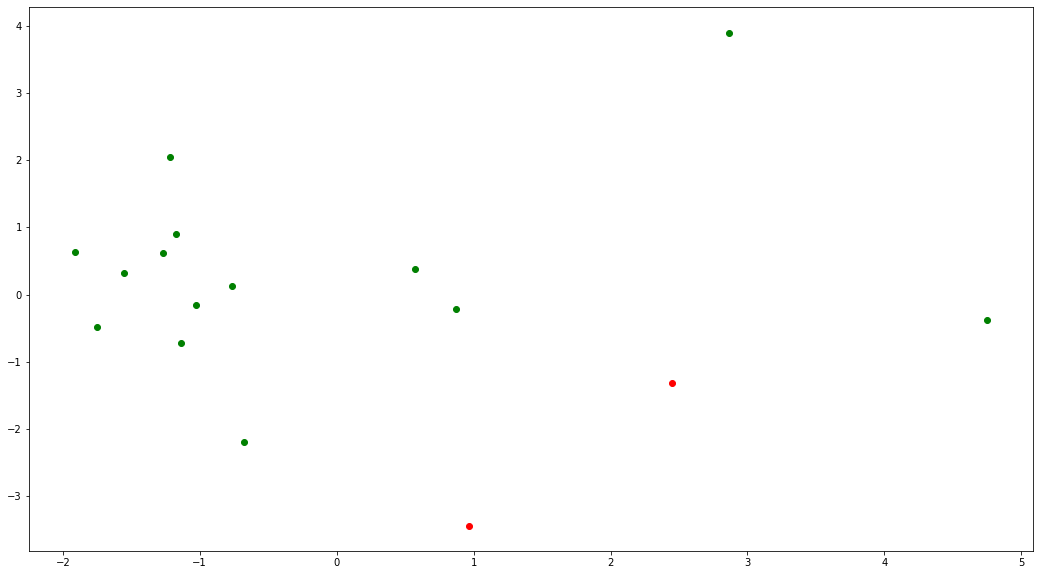

236 swe_om_1


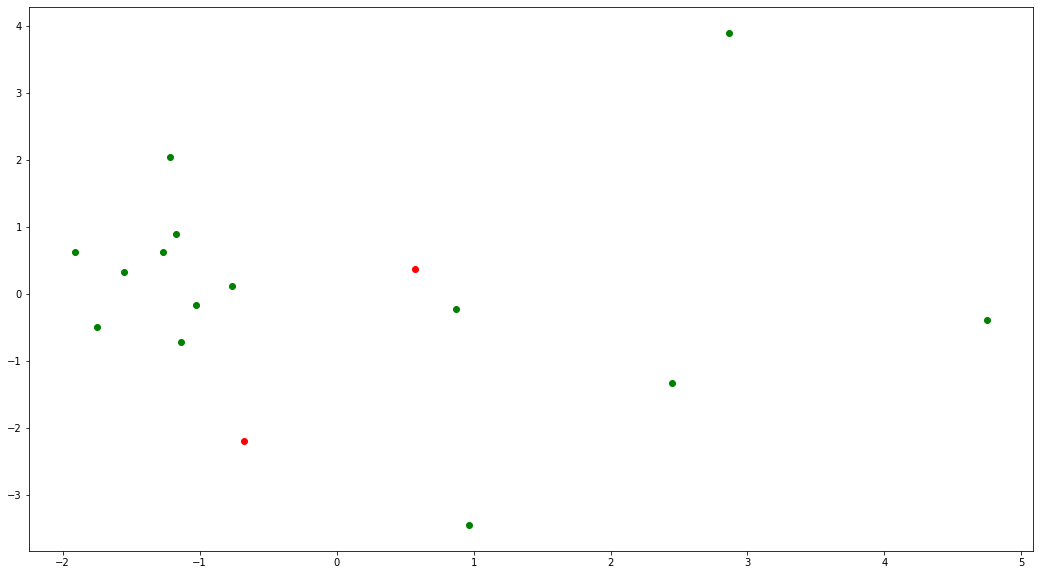

237 swe_under_0


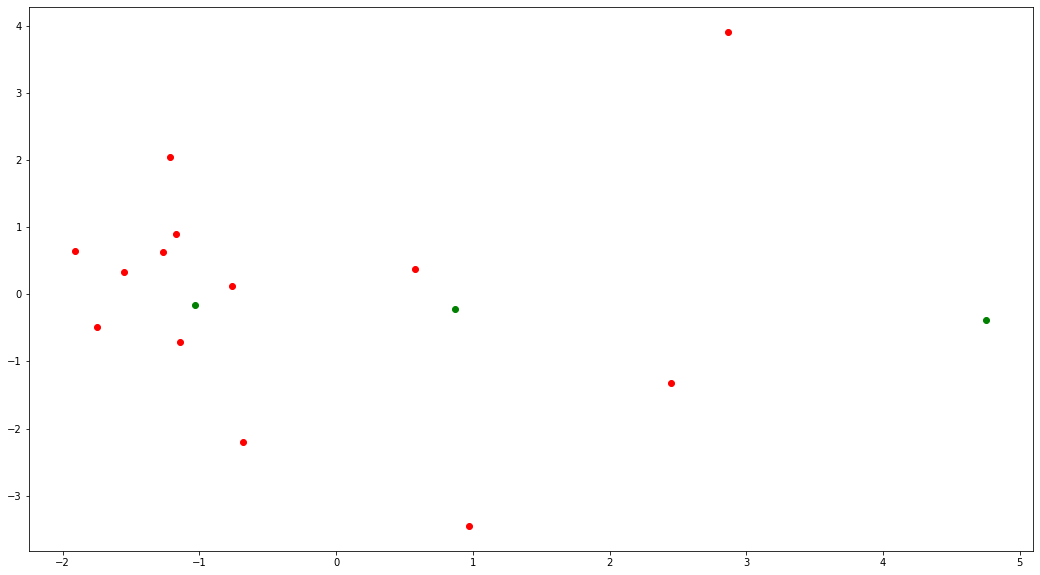

238 swe_under_1


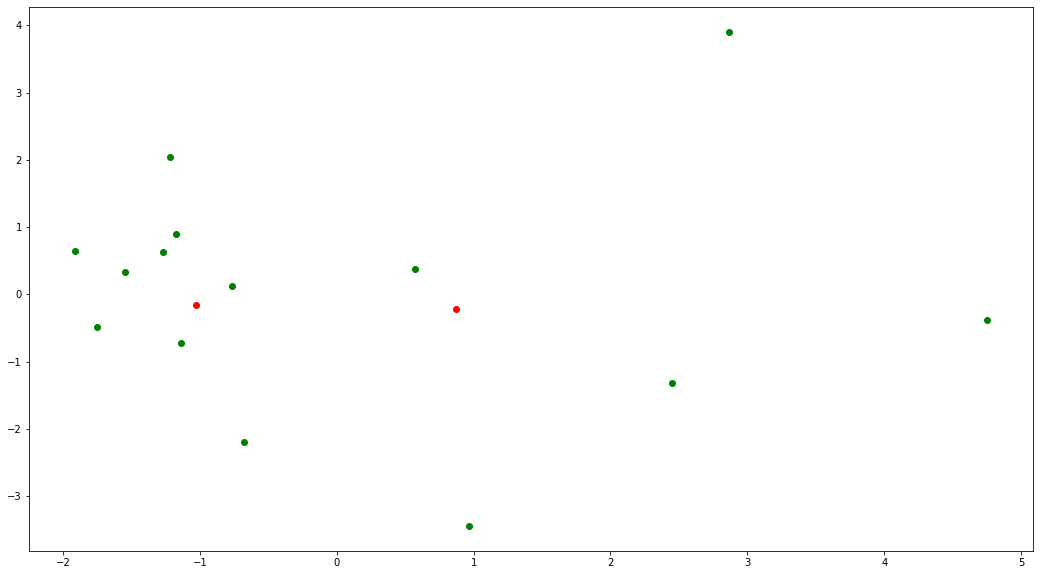

239 swe_under_5


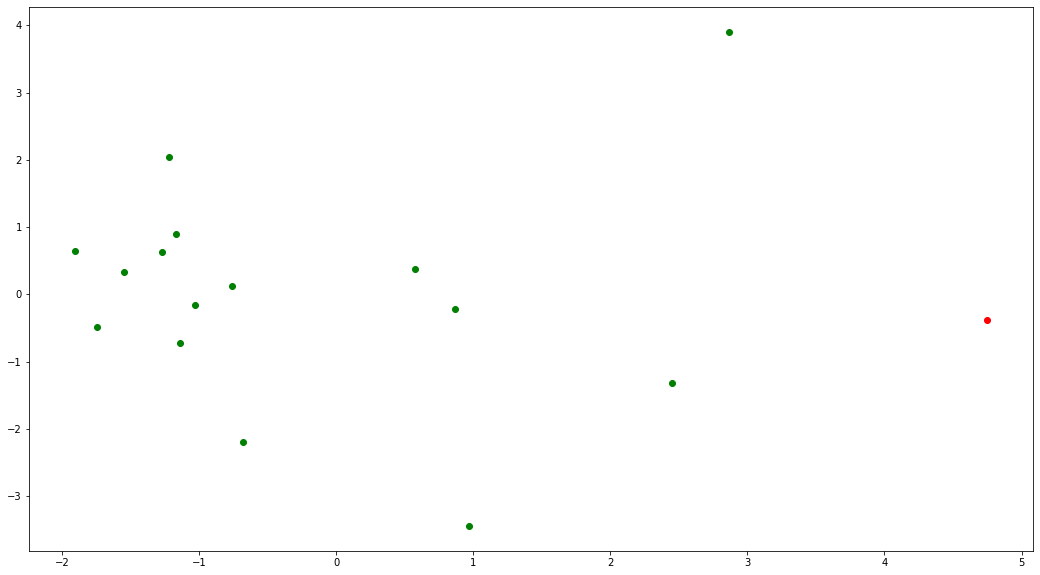

240 swe_other_0


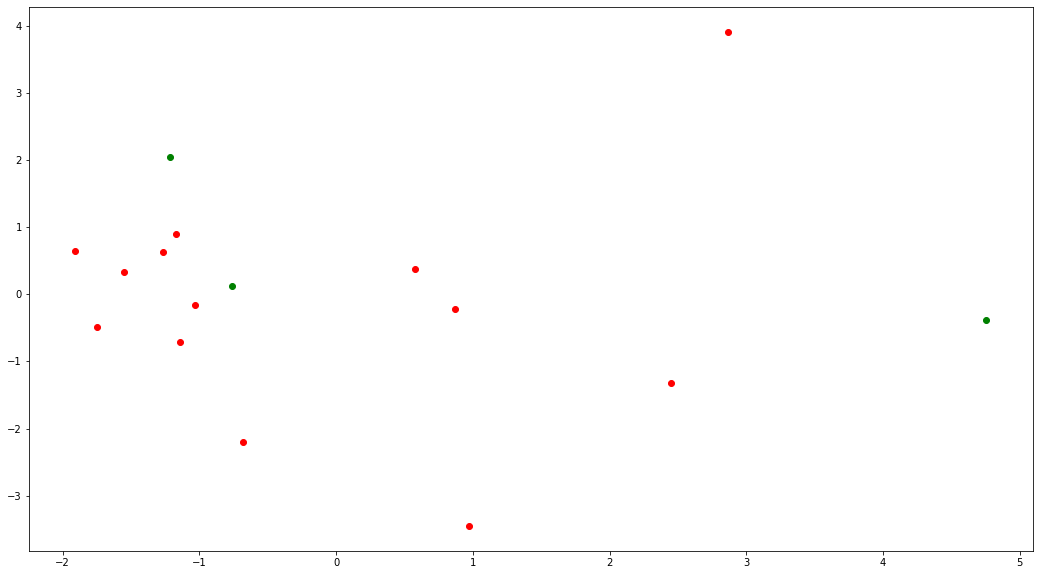

241 swe_other_1


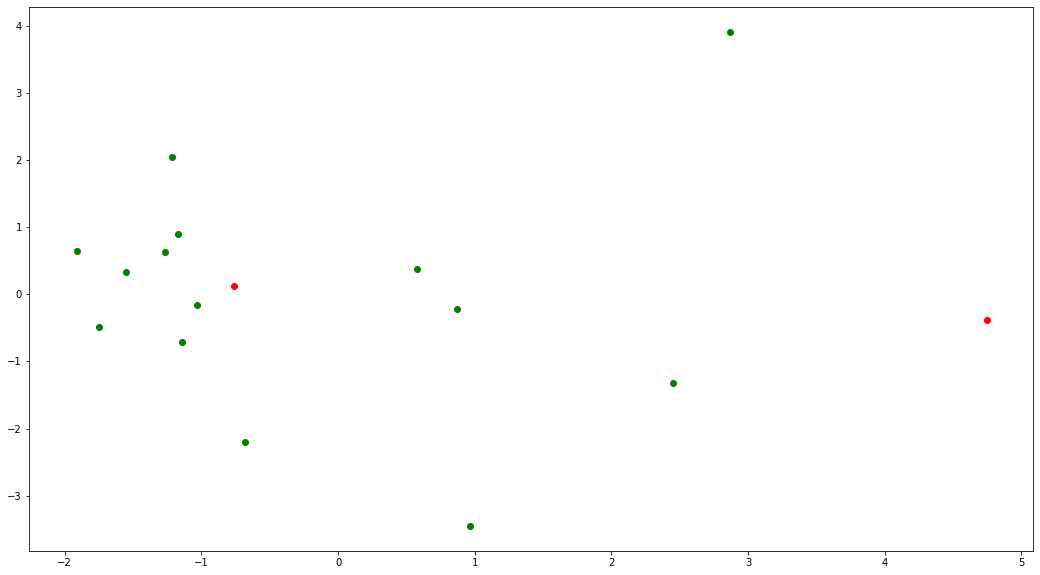

242 swe_other_3


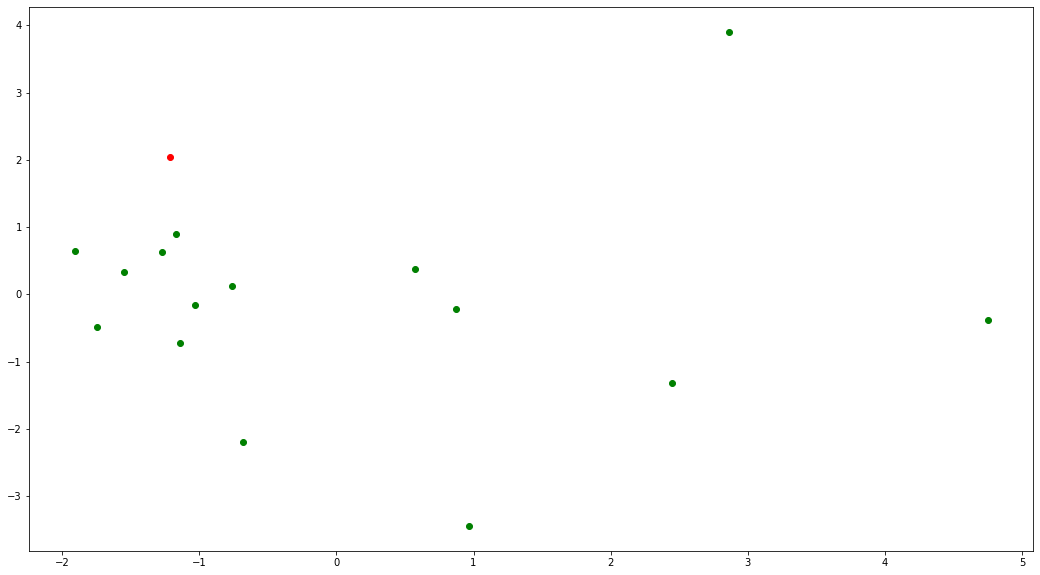

243 swe_zero_0


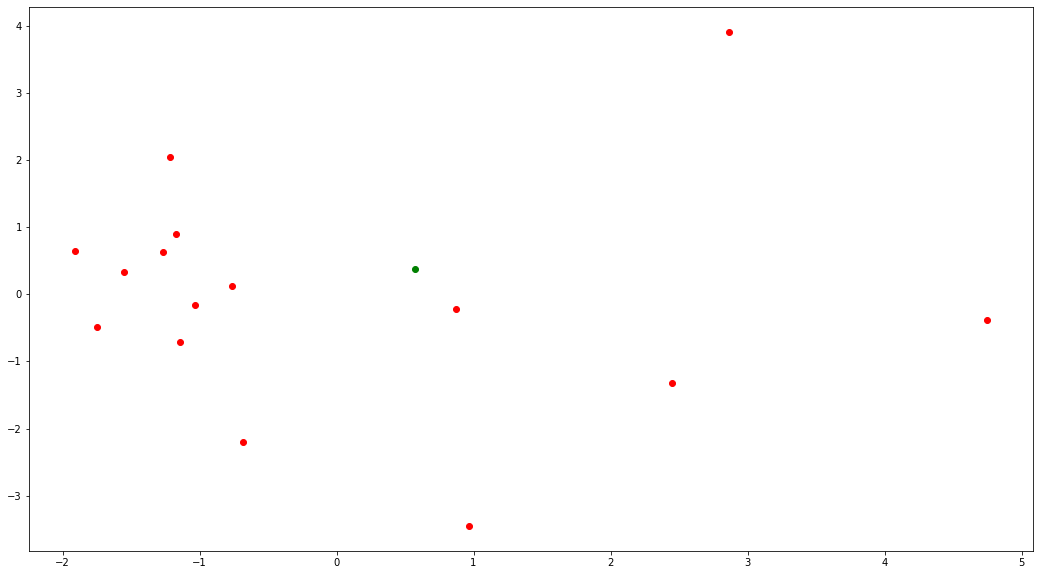

244 swe_zero_6


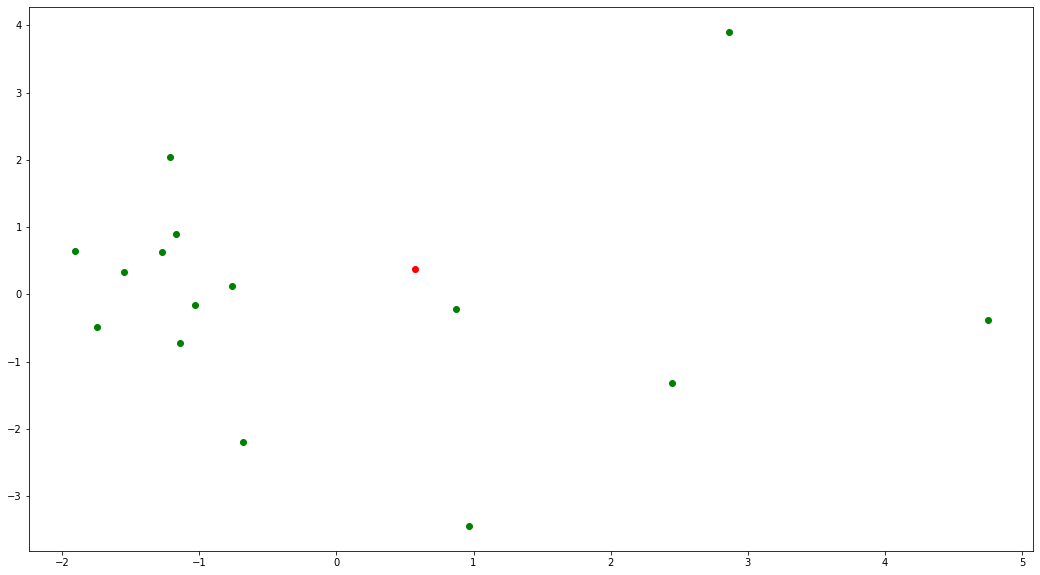

In [6]:
from matplotlib import pyplot as plt
dimension_x = 0
dimension_y = 2
plt.rcParams["figure.figsize"] = (18,10)
plt.scatter(x=coordinates[:,dimension_x],y=coordinates[:,dimension_y])
for i,row in enumerate(dense_coding_table[1:]):
    plt.text(x=coordinates[i,dimension_x],y=coordinates[i,dimension_y],s=dense_coding_table[i+1][0])
    print(coordinates[i,dimension_x],coordinates[i,dimension_y],dense_coding_table[i+1][0])
plt.show()
for i,term in enumerate(header):
    print(i,term)
    present = [j for j,row in enumerate(sparse_coding_table) if row[i] == 1]
    absent  = [j for j,row in enumerate(sparse_coding_table) if row[i] == 0]
    plt.scatter(x=coordinates[present,dimension_x], y=coordinates[present,dimension_y], c = 'r')
    plt.scatter(x=coordinates[absent,dimension_x], y=coordinates[absent,dimension_y], c = 'g')
    plt.show()
    plt.close()